In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Clone your collaboration repository
# Replace with your actual GitHub URL
#!git clone https://github.com/nmorok/Teleconnections-ViT.git
!git clone -b spatial_mask --single-branch https://github.com/nmorok/Teleconnections-ViT.git

# 2. Enter the repository directory
import os
os.chdir('Teleconnections-ViT')
# 3. Add the current directory to sys.path so 'import model' works
import sys
sys.path.append(os.getcwd())

# 4. Verify the files are present
print("Files in current directory:", os.listdir())

Cloning into 'Teleconnections-ViT'...
remote: Enumerating objects: 616, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 616 (delta 14), reused 0 (delta 0), pack-reused 582 (from 4)
Receiving objects: 100% (616/616), 1.28 GiB | 28.03 MiB/s, done.
Resolving deltas: 100% (280/280), done.
Updating files: 100% (141/141), done.
Files in current directory: ['data', 'notebook', '.gitignore', 'LICENSE', 'change_log.md', 'README.md', 'requirements.txt', 'grid_mask_verification.png', '.git', 'models', 'Pipeline.md', 'Methods.md', '0']


In [3]:
from google.colab import drive
import torch
import math


# 2. Define your data path (Update this to your actual Drive folder)
# Usually formatted as: /content/drive/MyDrive/Folder_Name
DATA_PATH = '/content/drive/MyDrive/Teleconnection_ViT/data'
REPO_DIR = '/content/Teleconnections-ViT'

# 3. Quick verification check
if os.path.exists(DATA_PATH):
    print(f"✓ Data folder found at: {DATA_PATH}")
    print("Files available:", os.listdir(DATA_PATH))
else:
    print(f"✗ ERROR: Could not find folder at {DATA_PATH}. Check your Drive path.")

# 4. Hardware Check
# 1. Check if CUDA (GPU support) is available
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 2. Get the name of the GPU assigned by Colab Pro
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: Using CPU. Check your Colab Runtime settings.")

✗ ERROR: Could not find folder at /content/drive/MyDrive/Teleconnection_ViT/data. Check your Drive path.
Is CUDA available? True
GPU Name: Tesla T4


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import math

from torch.utils.data import DataLoader
from models.model import CrabTransformer
from models.losses import TweedieLoss, MSELoss_cm
from data.data_helper import CrabDataset, get_dataloaders

The below is looking to make sure the transformations and the dataloaders aren't impacting the data.

I'll eventually look at the data post transformer model to make sure it looks similar

In [ ]:
from pickle import load
# testing the data loader
SEED = 2026

torch.manual_seed(SEED)
np.random.seed(SEED)
levels = ['easy', 'medium', 'hard']

for level in levels:
  print(f'level: {level}')
  print('\n' *2)
  train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=18, val_years=9, test_years=3,
        transform='log', level = level
      )

  ######################
  # Training data
  ######################

  data_iterator = iter(train_loader)
  inputs, targets, temporal_mask, year_idx = next(data_iterator)
  print('\n' * 3)
  print('Training data information \n')
  print(f'the shape of the inputs is\n{inputs.shape}\n')
  print(f'the shape of the targets is\n{targets.shape}\n')
  print(f'the shape of the termporal mask is\n{temporal_mask.shape}\n')
  print(f'the shape of the year index is\n{year_idx.shape}\n')


  print(f'the values of the temporal mask are:\n{temporal_mask}\n')
  print(f'the values of the year index are:\n{year_idx}\n')


  data_r = np.load(f'{DATA_PATH}/{level}/train_recruits_{level}.npy')
  print(f'\nthe size of the recruit training data is:{data_r.shape}')
  mean_r = data_r.mean()
  std_r = data_r.std()
  max_r = data_r.max()
  min_r = data_r.min()
  r_25 = np.quantile(data_r, 0.25)
  r_50 = np.quantile(data_r, 0.50)
  r_75 = np.quantile(data_r, 0.75)
  r_95 = np.quantile(data_r, 0.95)
  print(f'\nthe mean of the recruit training data is:{mean_r:.2f} and the std of the recruit training data is: {std_r:.2f}')
  print(f'\nthe max of the recruit training data is:{max_r:.2f} and the min of the recruit training data is: {min_r:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the recruit training data are: {r_25:.2f}, {r_50:.2f}, {r_75:.2f}, {r_95:.2f}')

  data_s = np.load(f'{DATA_PATH}/{level}/train_spawners_{level}.npy')
  print(f'\nthe size of the spawners training data is:{data_s.shape}')
  mean_s = data_s.mean()
  std_s = data_s.std()
  max_s = data_s.max()
  min_s = data_s.min()
  s_25 = np.quantile(data_s, 0.25)
  s_50 = np.quantile(data_s, 0.50)
  s_75 = np.quantile(data_s, 0.75)
  s_95 = np.quantile(data_s, 0.95)
  print(f'\nthe mean of the spawners training data is:{mean_s:.2f} and the std of the spanwers training data is: {std_s:.2f}')
  print(f'\nthe max of the spanwers training data is:{max_s:.2f} and the min of the spawners training data is: {min_s:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the spawners training data are: {s_25:.2f}, {s_50:.2f}, {s_75:.2f}, {s_95:.2f}')


  loader_sum_r = 0
  loader_sq_sum_r = 0
  loader_count_r = 0
  loader_max_r = 0
  loader_min_r = float('inf')
  loader_sum_s = 0
  loader_sq_sum_s = 0
  loader_count_s = 0
  loader_max_s = 0
  loader_min_s = float('inf')

  for inputs, targets, temporal_mask, year_idx in train_loader:
    data_r = targets.reshape(-1)
    data_r = torch.expm1(data_r)
    loader_sum_r += data_r.sum()
    loader_sq_sum_r += data_r.pow(2).sum()
    loader_count_r += data_r.numel()
    loader_max_r = max(loader_max_r, data_r.max().item())
    loader_min_r = min(loader_min_r, data_r.min().item())

    inputs_curr = inputs[:,0,:,:]
    data_s = inputs_curr.reshape(-1)
    data_s = torch.expm1(data_s)
    loader_sum_s += data_s.sum()
    loader_sq_sum_s += data_s.pow(2).sum()
    loader_count_s += data_s.numel()
    loader_max_s = max(loader_max_s, data_s.max().item())
    loader_min_s = min(loader_min_s, data_s.min().item())

  loader_mean_r = loader_sum_r / loader_count_r
  loader_std_r = (loader_sq_sum_r / loader_count_r - loader_mean_r ** 2) ** 0.5

  loader_mean_s = loader_sum_s / loader_count_s
  loader_std_s = (loader_sq_sum_s / loader_count_s - loader_mean_s ** 2) ** 0.5

  print(f"\nthe mean of the data loader training recruits is: {loader_mean_r:.2f} and the std of the loader training recruits is: {loader_std_r:.2f}")
  print(f"\nthe mean of the data loader training spawners is: {loader_mean_s:.2f} and the std of the loader training spawners is: {loader_std_s:.2f}")
  print(f'\nthe max of the data loader training recruits is: {loader_max_r:.2f} and the min of the loader training recruits is: {loader_min_r:.2f}')
  print(f'\nthe max of the data loader training spawners is: {loader_max_s:.2f} and the min of the loader training spawners is: {loader_min_s:.2f}')


  ######################
  # Validation data
  ######################

  data_iterator = iter(val_loader)
  inputs, targets, temporal_mask, year_idx = next(data_iterator)
  print('\n' * 3)
  print('Validation data information \n')
  print(f'the shape of the inputs is\n{inputs.shape}\n')
  print(f'the shape of the targets is\n{targets.shape}\n')
  print(f'the shape of the termporal mask is\n{temporal_mask.shape}\n')
  print(f'the shape of the year index is\n{year_idx.shape}\n')


  print(f'the values of the temporal mask are:\n{temporal_mask}\n')
  print(f'the values of the year index are:\n{year_idx}\n')

  print(inputs.view(-1))

  data_r = np.load(f'{DATA_PATH}/{level}/val_recruits_{level}.npy')
  print(f'\nthe size of the recruit validation data is:{data_r.shape}')
  mean_r = data_r.mean()
  std_r = data_r.std()
  max_r = data_r.max()
  min_r = data_r.min()
  r_25 = np.quantile(data_r, 0.25)
  r_50 = np.quantile(data_r, 0.50)
  r_75 = np.quantile(data_r, 0.75)
  r_95 = np.quantile(data_r, 0.95)
  print(f'\nthe mean of the recruit validation data is:{mean_r:.2f} and the std of the recruit validation data is: {std_r:.2f}')
  print(f'\nthe max of the recruit validation data is:{max_r:.2f} and the min of the recruit validation data is: {min_r:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the recruit validation data are: {r_25:.2f}, {r_50:.2f}, {r_75:.2f}, {r_95:.2f}')

  data_s = np.load(f'{DATA_PATH}/{level}/val_spawners_{level}.npy')
  print(f'\nthe size of the spawners validation data is:{data_s.shape}')
  mean_s = data_s.mean()
  std_s = data_s.std()
  max_s = data_s.max()
  min_s = data_s.min()
  s_25 = np.quantile(data_s, 0.25)
  s_50 = np.quantile(data_s, 0.50)
  s_75 = np.quantile(data_s, 0.75)
  s_95 = np.quantile(data_s, 0.95)
  print(f'\nthe mean of the spawners validation data is:{mean_s:.2f} and the std of the spanwers validation data is: {std_s:.2f}')
  print(f'\nthe max of the spanwers validation data is:{max_s:.2f} and the min of the spawners validation data is: {min_s:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the spawners validation data are: {s_25:.2f}, {s_50:.2f}, {s_75:.2f}, {s_95:.2f}')


  loader_sum_r = 0
  loader_sq_sum_r = 0
  loader_count_r = 0
  loader_max_r = 0
  loader_min_r = float('inf')
  loader_sum_s = 0
  loader_sq_sum_s = 0
  loader_count_s = 0
  loader_max_s = 0
  loader_min_s = float('inf')
  for inputs, targets, temporal_mask, year_idx in val_loader:
    data_r = targets.reshape(-1)
    data_r = torch.expm1(data_r)
    loader_sum_r += data_r.sum()
    loader_sq_sum_r += data_r.pow(2).sum()
    loader_count_r += data_r.numel()
    loader_max_r = max(loader_max_r, data_r.max().item())
    loader_min_r = min(loader_min_r, data_r.min().item())

    inputs_curr = inputs[:,0,:,:]
    data_s = inputs_curr.reshape(-1)
    data_s = torch.expm1(data_s)
    loader_sum_s += data_s.sum()
    loader_sq_sum_s += data_s.pow(2).sum()
    loader_count_s += data_s.numel()
    loader_max_s = max(loader_max_s, data_s.max().item())
    loader_min_s = min(loader_min_s, data_s.min().item())

  loader_mean_r = loader_sum_r / loader_count_r
  loader_std_r = (loader_sq_sum_r / loader_count_r - loader_mean_r ** 2) ** 0.5

  loader_mean_s = loader_sum_s / loader_count_s
  loader_std_s = (loader_sq_sum_s / loader_count_s - loader_mean_s ** 2) ** 0.5

  print(f"\nthe mean of the data loader validation recruits is: {loader_mean_r:.2f} and the std of the loader validation recruits is: {loader_std_r:.2f}")
  print(f"\nthe mean of the data loader validation spawners is: {loader_mean_s:.2f} and the std of the loader validation spawners is: {loader_std_s:.2f}")
  print(f'\nthe max of the data loader validation recruits is: {loader_max_r:.2f} and the min of the loader validation recruits is: {loader_min_r:.2f}')
  print(f'\nthe max of the data loader validation spawners is: {loader_max_s:.2f} and the min of the loader validaiton spawners is: {loader_min_s:.2f}')

  ######################
  # Testing data
  ######################

  data_iterator = iter(test_loader)
  inputs, targets, temporal_mask, year_idx = next(data_iterator)
  print('\n' * 3)
  print('Testing data information \n')
  print(f'the shape of the inputs is\n{inputs.shape}\n')
  print(f'the shape of the targets is\n{targets.shape}\n')
  print(f'the shape of the termporal mask is\n{temporal_mask.shape}\n')
  print(f'the shape of the year index is\n{year_idx.shape}\n')


  print(f'the values of the temporal mask are:\n{temporal_mask}\n')
  print(f'the values of the year index are:\n{year_idx}\n')

  print(inputs.view(-1))

  data_r = np.load(f'{DATA_PATH}/{level}/test_recruits_{level}.npy')
  print(f'\nthe size of the recruit testing data is:{data_r.shape}')
  mean_r = data_r.mean()
  std_r = data_r.std()
  max_r = data_r.max()
  min_r = data_r.min()
  r_25 = np.quantile(data_r, 0.25)
  r_50 = np.quantile(data_r, 0.50)
  r_75 = np.quantile(data_r, 0.75)
  r_95 = np.quantile(data_r, 0.95)
  print(f'\nthe mean of the recruit testing data is:{mean_r:.2f} and the std of the recruit testing data is: {std_r:.2f}')
  print(f'\nthe max of the recruit testing data is:{max_r:.2f} and the min of the recruit testing data is: {min_r:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the recruit testing data are: {r_25:.2f}, {r_50:.2f}, {r_75:.2f}, {r_95:.2f}')

  data_s = np.load(f'{DATA_PATH}/{level}/test_spawners_{level}.npy')
  print(f'\nthe size of the spawners testing data is:{data_s.shape}')
  mean_s = data_s.mean()
  std_s = data_s.std()
  max_s = data_s.max()
  min_s = data_s.min()
  s_25 = np.quantile(data_s, 0.25)
  s_50 = np.quantile(data_s, 0.50)
  s_75 = np.quantile(data_s, 0.75)
  s_95 = np.quantile(data_s, 0.95)
  print(f'\nthe mean of the spawners testing data is:{mean_s:.2f} and the std of the spanwers testing data is: {std_s:.2f}')
  print(f'\nthe max of the spanwers testing data is:{max_s:.2f} and the min of the spawners testing data is: {min_s:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the spawners testing data are: {s_25:.2f}, {s_50:.2f}, {s_75:.2f}, {s_95:.2f}')


  loader_sum_r = 0
  loader_sq_sum_r = 0
  loader_count_r = 0
  loader_max_r = 0
  loader_min_r = float('inf')
  loader_sum_s = 0
  loader_sq_sum_s = 0
  loader_count_s = 0
  loader_max_s = 0
  loader_min_s = float('inf')
  for inputs, targets, temporal_mask, year_idx in test_loader:
    data_r = targets.reshape(-1)
    data_r = torch.expm1(data_r)
    loader_sum_r += data_r.sum()
    loader_sq_sum_r += data_r.pow(2).sum()
    loader_count_r += data_r.numel()
    loader_max_r = max(loader_max_r, data_r.max().item())
    loader_min_r = min(loader_min_r, data_r.min().item())

    inputs_curr = inputs[:,0,:,:]
    data_s = inputs_curr.reshape(-1)
    data_s = torch.expm1(data_s)
    loader_sum_s += data_s.sum()
    loader_sq_sum_s += data_s.pow(2).sum()
    loader_count_s += data_s.numel()
    loader_max_s = max(loader_max_s, data_s.max().item())
    loader_min_s = min(loader_min_s, data_s.min().item())

  loader_mean_r = loader_sum_r / loader_count_r
  loader_std_r = (loader_sq_sum_r / loader_count_r - loader_mean_r ** 2) ** 0.5

  loader_mean_s = loader_sum_s / loader_count_s
  loader_std_s = (loader_sq_sum_s / loader_count_s - loader_mean_s ** 2) ** 0.5

  print(f"\nthe mean of the data loader testing recruits is: {loader_mean_r:.2f} and the std of the loader testing recruits is: {loader_std_r:.2f}")
  print(f"\nthe mean of the data loader testing spawners is: {loader_mean_s:.2f} and the std of the loader testing spawners is: {loader_std_s:.2f}")
  print(f'\nthe max of the data loader testing recruits is: {loader_max_r:.2f} and the min of the loader testing recruits is: {loader_min_r:.2f}')
  print(f'\nthe max of the data loader testing spawners is: {loader_max_s:.2f} and the min of the loader testing spawners is: {loader_min_s:.2f}')

  print("=" * 16)
  print('\n' *3)



level: easy



Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 18 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 9 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sample input shape (train): torch.Size([11, 50, 50])
Sample target shape (train): torch.Size([1, 50, 50])
Mask shape (train): torch.Size([6])
Year index (train): 0




Training data information 

the shape of the inputs is
torch.Size([8, 11, 50, 50])

the shape of the targets is
torch.Size([8, 1, 50, 50])

the shape of the termporal mask is
torch.Size([8, 6])

the

In [9]:
from pickle import load
# testing the data loader
SEED = 2026

torch.manual_seed(SEED)
np.random.seed(SEED)

for i in range(1):
  level = 'real'
  print('\n' *2)
  train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=24, val_years=8, test_years=4,
        transform='log', level = level, data_type='real'
      )

  ######################
  # Training data
  ######################
  DATA_PATH = '/content/Teleconnections-ViT/data/real/splits'
 # /content/Teleconnections-ViT/data/real/splits/real/train_recruits_real.npy
  data_iterator = iter(train_loader)
  inputs, targets, temporal_mask, year_idx, spatial_mask, valid_years = next(data_iterator)
  print('\n' * 3)
  print('Training data information \n')
  print(f'the shape of the inputs is\n{inputs.shape}\n')
  print(f'the shape of the targets is\n{targets.shape}\n')
  print(f'the shape of the termporal mask is\n{temporal_mask.shape}\n')
  print(f'the shape of the year index is\n{year_idx.shape}\n')
  print(f'the shape of the spatial mask is\n{spatial_mask.shape}\n')
  print(f'the shape of the valid years is\n{valid_years.shape}\n')


  print(f'the values of the temporal mask are:\n{temporal_mask}\n')
  print(f'the values of the year index are:\n{year_idx}\n')


  data_r = np.load(f'{DATA_PATH}/{level}/train_recruits_{level}.npy')
  print(f'\nthe size of the recruit training data is:{data_r.shape}')
  mean_r = data_r.mean()
  std_r = data_r.std()
  max_r = data_r.max()
  min_r = data_r.min()
  r_25 = np.quantile(data_r, 0.25)
  r_50 = np.quantile(data_r, 0.50)
  r_75 = np.quantile(data_r, 0.75)
  r_95 = np.quantile(data_r, 0.95)
  print(f'\nthe mean of the recruit training data is:{mean_r:.2f} and the std of the recruit training data is: {std_r:.2f}')
  print(f'\nthe max of the recruit training data is:{max_r:.2f} and the min of the recruit training data is: {min_r:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the recruit training data are: {r_25:.2f}, {r_50:.2f}, {r_75:.2f}, {r_95:.2f}')

  data_s = np.load(f'{DATA_PATH}/{level}/train_spawners_{level}.npy')
  print(f'\nthe size of the spawners training data is:{data_s.shape}')
  mean_s = data_s.mean()
  std_s = data_s.std()
  max_s = data_s.max()
  min_s = data_s.min()
  s_25 = np.quantile(data_s, 0.25)
  s_50 = np.quantile(data_s, 0.50)
  s_75 = np.quantile(data_s, 0.75)
  s_95 = np.quantile(data_s, 0.95)
  print(f'\nthe mean of the spawners training data is:{mean_s:.2f} and the std of the spanwers training data is: {std_s:.2f}')
  print(f'\nthe max of the spanwers training data is:{max_s:.2f} and the min of the spawners training data is: {min_s:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the spawners training data are: {s_25:.2f}, {s_50:.2f}, {s_75:.2f}, {s_95:.2f}')


  loader_sum_r = 0
  loader_sq_sum_r = 0
  loader_count_r = 0
  loader_max_r = 0
  loader_min_r = float('inf')
  loader_sum_s = 0
  loader_sq_sum_s = 0
  loader_count_s = 0
  loader_max_s = 0
  loader_min_s = float('inf')

  for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in train_loader:
    data_r = targets.reshape(-1)
    data_r = torch.expm1(data_r)
    loader_sum_r += data_r.sum()
    loader_sq_sum_r += data_r.pow(2).sum()
    loader_count_r += data_r.numel()
    loader_max_r = max(loader_max_r, data_r.max().item())
    loader_min_r = min(loader_min_r, data_r.min().item())

    inputs_curr = inputs[:,0,:,:]
    data_s = inputs_curr.reshape(-1)
    data_s = torch.expm1(data_s)
    loader_sum_s += data_s.sum()
    loader_sq_sum_s += data_s.pow(2).sum()
    loader_count_s += data_s.numel()
    loader_max_s = max(loader_max_s, data_s.max().item())
    loader_min_s = min(loader_min_s, data_s.min().item())

  loader_mean_r = loader_sum_r / loader_count_r
  loader_std_r = (loader_sq_sum_r / loader_count_r - loader_mean_r ** 2) ** 0.5

  loader_mean_s = loader_sum_s / loader_count_s
  loader_std_s = (loader_sq_sum_s / loader_count_s - loader_mean_s ** 2) ** 0.5

  print(f"\nthe mean of the data loader training recruits is: {loader_mean_r:.2f} and the std of the loader training recruits is: {loader_std_r:.2f}")
  print(f"\nthe mean of the data loader training spawners is: {loader_mean_s:.2f} and the std of the loader training spawners is: {loader_std_s:.2f}")
  print(f'\nthe max of the data loader training recruits is: {loader_max_r:.2f} and the min of the loader training recruits is: {loader_min_r:.2f}')
  print(f'\nthe max of the data loader training spawners is: {loader_max_s:.2f} and the min of the loader training spawners is: {loader_min_s:.2f}')


  ######################
  # Validation data
  ######################

  data_iterator = iter(val_loader)
  inputs, targets, temporal_mask, year_idx, spatial_mask, valid_years = next(data_iterator)
  print('\n' * 3)
  print('Validation data information \n')
  print(f'the shape of the inputs is\n{inputs.shape}\n')
  print(f'the shape of the targets is\n{targets.shape}\n')
  print(f'the shape of the termporal mask is\n{temporal_mask.shape}\n')
  print(f'the shape of the year index is\n{year_idx.shape}\n')
  print(f'the shape of the spatial mask is\n{spatial_mask.shape}\n')
  print(f'the shape of the valid years is\n{valid_years.shape}\n')


  print(f'the values of the temporal mask are:\n{temporal_mask}\n')
  print(f'the values of the year index are:\n{year_idx}\n')

  print(inputs.view(-1))

  data_r = np.load(f'{DATA_PATH}/{level}/val_recruits_{level}.npy')
  print(f'\nthe size of the recruit validation data is:{data_r.shape}')
  mean_r = data_r.mean()
  std_r = data_r.std()
  max_r = data_r.max()
  min_r = data_r.min()
  r_25 = np.quantile(data_r, 0.25)
  r_50 = np.quantile(data_r, 0.50)
  r_75 = np.quantile(data_r, 0.75)
  r_95 = np.quantile(data_r, 0.95)
  print(f'\nthe mean of the recruit validation data is:{mean_r:.2f} and the std of the recruit validation data is: {std_r:.2f}')
  print(f'\nthe max of the recruit validation data is:{max_r:.2f} and the min of the recruit validation data is: {min_r:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the recruit validation data are: {r_25:.2f}, {r_50:.2f}, {r_75:.2f}, {r_95:.2f}')

  data_s = np.load(f'{DATA_PATH}/{level}/val_spawners_{level}.npy')
  print(f'\nthe size of the spawners validation data is:{data_s.shape}')
  mean_s = data_s.mean()
  std_s = data_s.std()
  max_s = data_s.max()
  min_s = data_s.min()
  s_25 = np.quantile(data_s, 0.25)
  s_50 = np.quantile(data_s, 0.50)
  s_75 = np.quantile(data_s, 0.75)
  s_95 = np.quantile(data_s, 0.95)
  print(f'\nthe mean of the spawners validation data is:{mean_s:.2f} and the std of the spanwers validation data is: {std_s:.2f}')
  print(f'\nthe max of the spanwers validation data is:{max_s:.2f} and the min of the spawners validation data is: {min_s:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the spawners validation data are: {s_25:.2f}, {s_50:.2f}, {s_75:.2f}, {s_95:.2f}')


  loader_sum_r = 0
  loader_sq_sum_r = 0
  loader_count_r = 0
  loader_max_r = 0
  loader_min_r = float('inf')
  loader_sum_s = 0
  loader_sq_sum_s = 0
  loader_count_s = 0
  loader_max_s = 0
  loader_min_s = float('inf')
  for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in val_loader:
    data_r = targets.reshape(-1)
    data_r = torch.expm1(data_r)
    loader_sum_r += data_r.sum()
    loader_sq_sum_r += data_r.pow(2).sum()
    loader_count_r += data_r.numel()
    loader_max_r = max(loader_max_r, data_r.max().item())
    loader_min_r = min(loader_min_r, data_r.min().item())

    inputs_curr = inputs[:,0,:,:]
    data_s = inputs_curr.reshape(-1)
    data_s = torch.expm1(data_s)
    loader_sum_s += data_s.sum()
    loader_sq_sum_s += data_s.pow(2).sum()
    loader_count_s += data_s.numel()
    loader_max_s = max(loader_max_s, data_s.max().item())
    loader_min_s = min(loader_min_s, data_s.min().item())

  loader_mean_r = loader_sum_r / loader_count_r
  loader_std_r = (loader_sq_sum_r / loader_count_r - loader_mean_r ** 2) ** 0.5

  loader_mean_s = loader_sum_s / loader_count_s
  loader_std_s = (loader_sq_sum_s / loader_count_s - loader_mean_s ** 2) ** 0.5

  print(f"\nthe mean of the data loader validation recruits is: {loader_mean_r:.2f} and the std of the loader validation recruits is: {loader_std_r:.2f}")
  print(f"\nthe mean of the data loader validation spawners is: {loader_mean_s:.2f} and the std of the loader validation spawners is: {loader_std_s:.2f}")
  print(f'\nthe max of the data loader validation recruits is: {loader_max_r:.2f} and the min of the loader validation recruits is: {loader_min_r:.2f}')
  print(f'\nthe max of the data loader validation spawners is: {loader_max_s:.2f} and the min of the loader validaiton spawners is: {loader_min_s:.2f}')

  ######################
  # Testing data
  ######################

  data_iterator = iter(test_loader)
  inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year = next(data_iterator)
  print('\n' * 3)
  print('Testing data information \n')
  print(f'the shape of the inputs is\n{inputs.shape}\n')
  print(f'the shape of the targets is\n{targets.shape}\n')
  print(f'the shape of the termporal mask is\n{temporal_mask.shape}\n')
  print(f'the shape of the year index is\n{year_idx.shape}\n')
  print(f'the shape of the spatial mask is\n{spatial_mask.shape}\n')
  print(f'the shape of the valid years is\n{valid_years.shape}\n')


  print(f'the values of the temporal mask are:\n{temporal_mask}\n')
  print(f'the values of the year index are:\n{year_idx}\n')

  print(inputs.view(-1))

  data_r = np.load(f'{DATA_PATH}/{level}/test_recruits_{level}.npy')
  print(f'\nthe size of the recruit testing data is:{data_r.shape}')
  mean_r = data_r.mean()
  std_r = data_r.std()
  max_r = data_r.max()
  min_r = data_r.min()
  r_25 = np.quantile(data_r, 0.25)
  r_50 = np.quantile(data_r, 0.50)
  r_75 = np.quantile(data_r, 0.75)
  r_95 = np.quantile(data_r, 0.95)
  print(f'\nthe mean of the recruit testing data is:{mean_r:.2f} and the std of the recruit testing data is: {std_r:.2f}')
  print(f'\nthe max of the recruit testing data is:{max_r:.2f} and the min of the recruit testing data is: {min_r:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the recruit testing data are: {r_25:.2f}, {r_50:.2f}, {r_75:.2f}, {r_95:.2f}')

  data_s = np.load(f'{DATA_PATH}/{level}/test_spawners_{level}.npy')
  print(f'\nthe size of the spawners testing data is:{data_s.shape}')
  mean_s = data_s.mean()
  std_s = data_s.std()
  max_s = data_s.max()
  min_s = data_s.min()
  s_25 = np.quantile(data_s, 0.25)
  s_50 = np.quantile(data_s, 0.50)
  s_75 = np.quantile(data_s, 0.75)
  s_95 = np.quantile(data_s, 0.95)
  print(f'\nthe mean of the spawners testing data is:{mean_s:.2f} and the std of the spanwers testing data is: {std_s:.2f}')
  print(f'\nthe max of the spanwers testing data is:{max_s:.2f} and the min of the spawners testing data is: {min_s:.2f}')
  print(f'\nthe 0.25, 0.5, 0.75, and 0.95 quantiles of the spawners testing data are: {s_25:.2f}, {s_50:.2f}, {s_75:.2f}, {s_95:.2f}')


  loader_sum_r = 0
  loader_sq_sum_r = 0
  loader_count_r = 0
  loader_max_r = 0
  loader_min_r = float('inf')
  loader_sum_s = 0
  loader_sq_sum_s = 0
  loader_count_s = 0
  loader_max_s = 0
  loader_min_s = float('inf')
  for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in test_loader:
    data_r = targets.reshape(-1)
    data_r = torch.expm1(data_r)
    loader_sum_r += data_r.sum()
    loader_sq_sum_r += data_r.pow(2).sum()
    loader_count_r += data_r.numel()
    loader_max_r = max(loader_max_r, data_r.max().item())
    loader_min_r = min(loader_min_r, data_r.min().item())

    inputs_curr = inputs[:,0,:,:]
    data_s = inputs_curr.reshape(-1)
    data_s = torch.expm1(data_s)
    loader_sum_s += data_s.sum()
    loader_sq_sum_s += data_s.pow(2).sum()
    loader_count_s += data_s.numel()
    loader_max_s = max(loader_max_s, data_s.max().item())
    loader_min_s = min(loader_min_s, data_s.min().item())

  loader_mean_r = loader_sum_r / loader_count_r
  loader_std_r = (loader_sq_sum_r / loader_count_r - loader_mean_r ** 2) ** 0.5

  loader_mean_s = loader_sum_s / loader_count_s
  loader_std_s = (loader_sq_sum_s / loader_count_s - loader_mean_s ** 2) ** 0.5

  print(f"\nthe mean of the data loader testing recruits is: {loader_mean_r:.2f} and the std of the loader testing recruits is: {loader_std_r:.2f}")
  print(f"\nthe mean of the data loader testing spawners is: {loader_mean_s:.2f} and the std of the loader testing spawners is: {loader_std_s:.2f}")
  print(f'\nthe max of the data loader testing recruits is: {loader_max_r:.2f} and the min of the loader testing recruits is: {loader_min_r:.2f}')
  print(f'\nthe max of the data loader testing spawners is: {loader_max_s:.2f} and the min of the loader testing spawners is: {loader_min_s:.2f}')

  print("=" * 16)
  print('\n' *3)






Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)




Training data information 

the shape of the inputs is
torch.Size([8, 11, 50, 50])

the shape of the targets is
torch.Size([8, 1, 50, 50])

the shape of the termporal mask is
torch.Size([8, 6])

the shape of the year index is
torch.Size([8])

the shape of the spatial mask is
torch.Size([8, 50, 50])

the shape of the valid years is
torch.Size([8])

the values of the temporal mask are:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1

--- Initializing Data ---
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Trainable parameters: 1,320,625
Decoder bias set to 2.819
Batch Ratio: 0.9906
Epoch   1 | Loss criterion Tweedie |Train: 1829.2984 | Val: 1920.3234 | LR: 9.30e-05 | Patience: 0/20 ✓ Saved
Batch Ratio: 1.1505
Epoch   2 | Loss criterion Tweedie |Train: 1673.4617 | Val: 1910.5203 | LR: 2.06e-04 | Patience: 0/20 ✓ Saved
Batch Ratio: 1.8097
Epoch   3 | Loss criterion Tweed

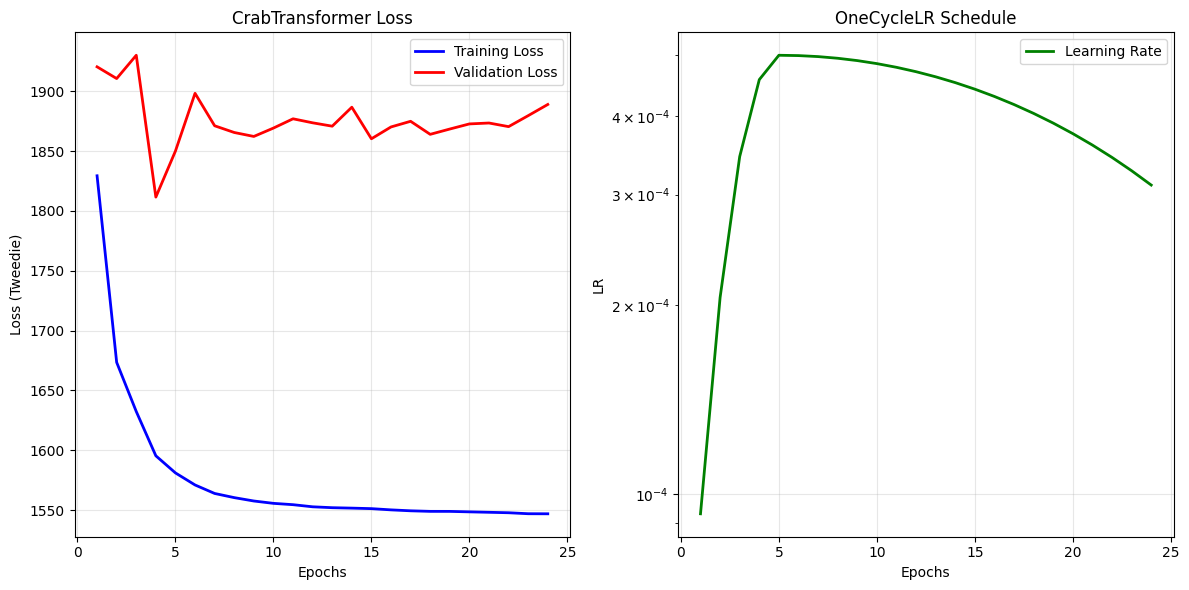

--- Initializing Data ---
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Trainable parameters: 1,320,625
Decoder bias set to 2.819
Batch Ratio: 1.4646
Epoch   1 | Loss criterion MSE |Train: 2.6168 | Val: 2.9137 | LR: 9.30e-05 | Patience: 0/20 ✓ Saved
Batch Ratio: 0.8452
Epoch   2 | Loss criterion MSE |Train: 0.9077 | Val: 2.3697 | LR: 2.06e-04 | Patience: 0/20 ✓ Saved
Batch Ratio: 0.9827
Epoch   3 | Loss criterion MSE |Train: 0.5571 | Val:

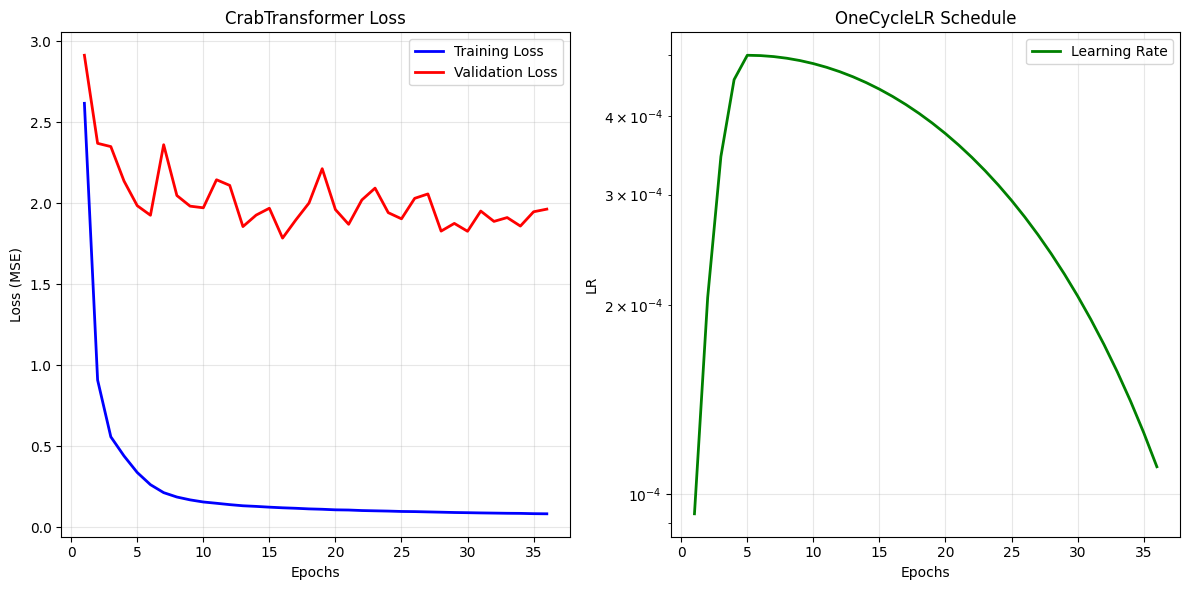

In [12]:

import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR, OneCycleLR
import json

def train_model_max_scaled(data_type='dummy', level='easy', loss_criterion = 'MSE'):
    print("--- Initializing Data ---")

    if data_type == 'dummy':
      print('Data generated from these parameters:')
      params_path = os.path.join(REPO_DIR, f'data/dummy/output/gmrf_params_{level}.json')
      params = json.load(open(params_path))
      print(json.dumps(params, indent=2))

    if data_type == 'real':
      level = 'real'

    checkpoint_dir = '/content/drive/MyDrive/Teleconnection_ViT/checkpoints'




    train_loader, val_loader, test_loader = get_dataloaders(
      batch_size=8, memory_years=5,
      train_years=24, val_years=8, test_years=4,
      transform='log', level = level, data_type = data_type
    )

    # 2. Setup Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.1
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")


    all_targets = []
    for _, targets, _, _, spatial_mask, valid_year in train_loader:
        # Loop through the batch and only keep valid years
        for i in range(targets.shape[0]):
            if valid_year[i] > 0: # If it's NOT 2020
                # THE FIX: Add the , 0 to drop the channel dim, and use [i] for the mask
                valid = targets[i, 0][spatial_mask[i] > 0]
                all_targets.append(valid.cpu().numpy())

    mean_log_target = np.concatenate(all_targets).mean()
    nn.init.constant_(model.decoder.conv_out.bias, mean_log_target)
    print(f"Decoder bias set to {mean_log_target:.3f}")



    # 3. Setup Tweedie Loss (Works because data is now positive 0-1)
    # Power 1.5 is standard for compound Poisson-Gamma (Fisheries data)
    if loss_criterion == 'Tweedie':
        criterion = TweedieLoss(power=1.2)
    elif loss_criterion == 'MSE':
        criterion = MSELoss_cm()



    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

    # 4. Linear Warmup + Plateau
    # This prevents the "Identity Trap" in early epochs -- which I was seeing
    def warmup_lambda(epoch):
        if epoch < 5:
            return (epoch + 1) / 5  # Ramp up: 0.2, 0.4, 0.6, 0.8, 1.0
        return 1.0


    scheduler = OneCycleLR(
        optimizer,
        max_lr=5e-4,
        epochs=50,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,          # 10% warmup
        anneal_strategy="cos",
        div_factor=10,          # initial_lr = max_lr / 10
        final_div_factor=100,   # final_lr  = max_lr / 1000
    )

    # Training Loop
    best_val_loss = float('inf')
    epochs = 50
    early_stop_patience = 20
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in train_loader:
            inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year = inputs.to(device), targets.to(device), temporal_mask.to(device), year_idx.to(device), spatial_mask.to(device), valid_year.to(device)

            optimizer.zero_grad()

            # --- MODEL FORWARD ---

            outputs = model(inputs, year_idx, temporal_mask, spatial_mask=spatial_mask)

            if loss_criterion == 'Tweedie':
              outputs = torch.expm1(outputs).clamp(min=1e-6)
              targets_real = torch.expm1(targets).clamp(min=1e-6)
              loss = criterion(outputs, targets_real, mask=spatial_mask, sample_mask=valid_year)
            elif loss_criterion == 'MSE':
              loss = criterion(outputs, targets, mask=spatial_mask, sample_mask=valid_year)



            loss.backward()

            # Clip gradients (Safety)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()
            total_loss += loss.item()


        avg_train = total_loss / len(train_loader)

        # ---- Validate ----
        model.eval()
        total_val_loss = 0.0
        all_pred_totals = 0.0
        all_target_totals = 0.0



        with torch.no_grad():
            for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in val_loader:
                inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year  = inputs.to(device), targets.to(device), temporal_mask.to(device), year_idx.to(device), spatial_mask.to(device), valid_year.to(device)


                outputs = model(inputs, year_idx, temporal_mask, spatial_mask=spatial_mask)

                if loss_criterion == 'Tweedie':
                  outputs_exp = torch.expm1(outputs).clamp(min=1e-6)
                  targets_real = torch.expm1(targets).clamp(min=1e-6)
                  total_val_loss += criterion(outputs_exp, targets_real, mask=spatial_mask, sample_mask=valid_year).item()

                  # Multiply by valid_year to ensure 2020 adds 0 to the totals
                  all_pred_totals += (outputs_exp.sum(dim=(1,2,3)) * valid_year).sum().item()
                  all_target_totals += (targets_real.sum(dim=(1,2,3)) * valid_year).sum().item()

                elif loss_criterion == 'MSE':
                  total_val_loss += criterion(outputs, targets, mask=spatial_mask, sample_mask=valid_year).item()

                  # Multiply by valid_year to ensure 2020 adds 0 to the totals
                  all_pred_totals += (torch.expm1(outputs).sum(dim=(1,2,3)) * valid_year).sum().item()
                  all_target_totals += (torch.expm1(targets).sum(dim=(1,2,3)) * valid_year).sum().item()









        avg_val = total_val_loss / len(val_loader)

        batch_ratio = all_pred_totals / (all_target_totals + 1e-6)
        print(f"Batch Ratio: {batch_ratio:.4f}")




        # ---- Bookkeeping ----
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["lr"].append(current_lr)


        improved = ""
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, f"best_model_{level}_{loss_criterion}.pt"))
            improved = " ✓ Saved"
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss criterion {loss_criterion} |"
            f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"Patience: {patience_counter}/{early_stop_patience}{improved}"
        )

        # ---- Early stopping ----
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1} (best val: {best_val_loss:.4f})")
            break

    # ==================================================================
    # 5. LOAD BEST MODEL & EVALUATE ON TEST
    # ==================================================================
    print("\n--- Evaluating best model on test set ---")
    model.load_state_dict(torch.load(os.path.join(checkpoint_dir, f"best_model_{level}_{loss_criterion}.pt"),
                                     map_location=device))
    model.eval()

    # ==================================================================
    # 5.5 COMPUTE LOGNORMAL BIAS CORRECTION (MSE only)
    # ==================================================================
    bias_correction = 1.0  # No correction for Tweedie/L1

    if loss_criterion == 'MSE':
        print("\n--- Computing lognormal bias correction ---")
        residuals = []
        with torch.no_grad():
            for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in train_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                temporal_mask = temporal_mask.to(device)
                year_idx = year_idx.to(device)
                spatial_mask = spatial_mask.to(device)
                valid_year = valid_year.to(device)

                outputs = model(inputs, year_idx, temporal_mask, spatial_mask=spatial_mask)

                for i in range(targets.shape[0]):
                    if valid_year[i] > 0: # If it's NOT 2020
                        # target[i] is [1, 50, 50], spatial_mask[i] is [50, 50]
                        valid_mask = spatial_mask[i].unsqueeze(0) > 0
                        res = (targets[i][valid_mask] - outputs[i][valid_mask]).cpu().numpy().flatten()
                        residuals.append(res)

        residuals = np.concatenate(residuals)
        sigma2 = residuals.var()
        bias_correction = float(np.exp(0.5 * sigma2))
        print(f"  σ² (log-space):           {sigma2:.4f}")
        print(f"  Bias correction factor:   {bias_correction:.4f}")


    total_test_loss = 0.0

    with torch.no_grad():
        for inputs, targets, temporal_mask, year_idx, spatial_mask, valid_year in test_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)
            temporal_mask = temporal_mask.to(device)
            year_idx = year_idx.to(device)
            spatial_mask = spatial_mask.to(device)
            valid_year = valid_year.to(device)

            outputs = model(inputs, year_idx, temporal_mask, spatial_mask=spatial_mask)

            if loss_criterion == 'Tweedie':
              outputs = torch.expm1(outputs).clamp(min=1e-6)
              targets_real = torch.expm1(targets).clamp(min=1e-6)
              total_test_loss += criterion(outputs, targets_real, mask=spatial_mask, sample_mask=valid_year).item()
            elif loss_criterion == 'MSE':
              total_test_loss += criterion(outputs, targets, mask=spatial_mask, sample_mask=valid_year).item()


    avg_test = total_test_loss / len(test_loader)

    print(f"Test Loss: {avg_test:.4f}")

    history['bias_correction'] = bias_correction
    # Save training history
    with open(os.path.join(checkpoint_dir, f"training_history_{level}_{loss_criterion}.json"), "w") as f:
        json.dump(history, f)

    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 6))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label='Training Loss', color='blue', lw=2)
    plt.plot(epochs_range, history["val_loss"], label='Validation Loss', color='red', lw=2)
    plt.title('CrabTransformer Loss')
    plt.xlabel('Epochs')
    plt.ylabel(f'Loss ({loss_criterion})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Learning Rate Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["lr"], label='Learning Rate', color='green', lw=2)
    plt.title('OneCycleLR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('LR')
    plt.yscale('log') # Log scale helps see the annealing
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(checkpoint_dir, f"training_curves_{level}_{loss_criterion}.png")
    plt.savefig(plot_path)
    print(f"Plot saved to: {plot_path}")
    plt.show()

    return model, history

if __name__ == "__main__":
    #model_easy, history_easy = train_model_max_scaled(level = 'easy', loss_criterion='MSE')
    #model_medium, history_medium = train_model_max_scaled(level = 'medium', loss_criterion='MSE')
    #model_hard, history_hard = train_model_max_scaled(level = 'hard', loss_criterion='MSE')

    #model_easy, history_easy = train_model_max_scaled(level = 'easy', loss_criterion='Tweedie')
    #model_medium, history_medium = train_model_max_scaled(level = 'medium', loss_criterion='Tweedie')
    #model_hard, history_hard = train_model_max_scaled(level = 'hard', loss_criterion='Tweedie')

    model_real, history_real = train_model_max_scaled(data_type='real', level = 'easy', loss_criterion='Tweedie')
    model_real, history_real = train_model_max_scaled(data_type='real', level = 'easy', loss_criterion='MSE')



In [14]:

def test_overfit_on_real_data(data_type='dummy', level='easy', loss_criterion='MSE'):
    print("=" * 70)
    print(f"🔬 OVERFITTING TEST ({data_type}/{level}, {loss_criterion})")
    print("=" * 70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if data_type == 'real':
        level = 'real'

    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=24, val_years=8, test_years=4,
        transform='log', level=level, data_type=data_type
    )

    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0 # Dropout 0 is correct for overfitting!
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    # Compute bias init (Unpacking all 6 variables safely)
    all_targets = []
    for inputs, tgts, temp_mask, y_idx, spat_mask, val_year in train_loader:
        for i in range(tgts.shape[0]):
            if val_year[i] > 0: # Skip 2020
                valid = tgts[i, 0][spat_mask[i] > 0]
                all_targets.append(valid.cpu().numpy())

    mean_log_target = np.concatenate(all_targets).mean()
    nn.init.constant_(model.decoder.conv_out.bias, mean_log_target)
    print(f"Decoder bias set to {mean_log_target:.3f}")

    # =======================================================
    # Grab ONE sample that is GUARANTEED to not be 2020
    # =======================================================
    for inputs_b, targets_b, temp_mask_b, y_idx_b, spat_mask_b, val_year_b in train_loader:
        # Find the indices in this batch where the year is valid
        valid_indices = torch.where(val_year_b > 0)[0]

        if len(valid_indices) > 0:
            idx = valid_indices[0] # Pick the first valid sample
            inputs = inputs_b[idx:idx+1].to(device)
            targets = targets_b[idx:idx+1].to(device)
            temporal_mask = temp_mask_b[idx:idx+1].to(device)
            year_idx = y_idx_b[idx:idx+1].to(device)
            spatial_mask = spat_mask_b[idx:idx+1].to(device)
            valid_year = val_year_b[idx:idx+1].to(device)
            break

    print(f"Selected Year Index {year_idx.item()} for overfitting test.")

    # Loss setup
    if loss_criterion == 'Tweedie':
        criterion = TweedieLoss(power=1.2)
        # Note: We transform the true targets to exp space here once
        targets = torch.expm1(targets).clamp(min=1e-6)
    elif loss_criterion == 'MSE':
        criterion = MSELoss_cm()
    elif loss_criterion == 'L1':
        criterion = nn.L1Loss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    print("\n🚀 Training for 1000 epochs on a single sample...")
    model.train()

    for epoch in range(1000):
        optimizer.zero_grad()

        output = model(inputs, year_idx, temporal_mask, spatial_mask=spatial_mask)

        if loss_criterion == 'Tweedie':
            output_loss = torch.expm1(output).clamp(min=1e-6)
            loss = criterion(output_loss, targets, mask=spatial_mask, sample_mask=valid_year)
        elif loss_criterion == 'MSE':
            # FIXED: Added sample_mask
            loss = criterion(output, targets, mask=spatial_mask, sample_mask=valid_year)
        elif loss_criterion == 'L1':
            loss = criterion(output, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f"   Epoch {epoch+1:4d} | Loss: {loss.item():.8f}")

    # Final verification
    model.eval()
    with torch.no_grad():
        final_output = model(inputs, year_idx, temporal_mask, spatial_mask=spatial_mask)

        # Ensure spatial mask matches the 4D output [1, 1, 50, 50]
        valid_mask = spatial_mask.unsqueeze(1) > 0

        if loss_criterion == 'Tweedie':
            pred_np = torch.expm1(final_output)[valid_mask].cpu().numpy().flatten()
        else:
            pred_np = final_output[valid_mask].cpu().numpy().flatten()

        targ_np = targets[valid_mask].cpu().numpy().flatten()

        corr = np.corrcoef(pred_np, targ_np)[0, 1]

    print("\n" + "=" * 70)
    print("🏁 FINAL DIAGNOSTIC VERDICT:")
    print("=" * 70)

    if corr > 0.98:
        print(f"✅ SUCCESS! Final Correlation: {corr:.4f}")
        print("   The architecture CAN learn the spatial patterns.")
    else:
        print(f"❌ FAILURE. Final Correlation: {corr:.4f}")
        print("   The model cannot overfit a single sample.")

if __name__ == "__main__":
    test_overfit_on_real_data(data_type='real', loss_criterion='MSE')
    test_overfit_on_real_data(data_type='real', loss_criterion='Tweedie')

🔬 OVERFITTING TEST (real/easy, MSE)
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Trainable parameters: 1,320,625
Decoder bias set to 2.819
Selected Year Index 18 for overfitting test.

🚀 Training for 1000 epochs on a single sample...
   Epoch  100 | Loss: 0.29022911
   Epoch  200 | Loss: 0.13402642
   Epoch  300 | Loss: 0.08138207
   Epoch  400 | Loss: 0.02400494
   Epoch  500 | Loss: 0.02203222
   Epoch  600 | Loss: 0.02000090
   Epoch 

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
from torch.utils.data import DataLoader
from models.model import CrabTransformer
from data.data_helper import CrabDataset, get_dataloaders

def test_overfit_on_real_data(level = "easy", loss_criterion = "Tweedie"):
    """
    Diagnostic: Can the model overfit to ONE actual GMRF sample?
    Uses MSE loss to isolate architecture performance.
    """
    print("=" * 70)
    print("🔬 GMRF DATA OVERFITTING TEST (MSE Loss)")
    print("=" * 70)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DATA_PATH = f"/content/drive/MyDrive/Teleconnection_ViT/data/{level}"

    # 1. Load data using your actual Dataset class logic
    print(f"\n📂 Loading GMRF data from {DATA_PATH}...")

    # Matching your training loop's n_years=22
    train_loader, val_loader, test_loader = get_dataloaders(
      batch_size=8, memory_years=5,
      train_years=22, val_years=5, test_years=3,
      transform='log', level = level
    )


    # 2. Setup Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")


    all_targets = []
    for _, targets, _, _ in train_loader:
        # targets is already log(1+x), so just collect the values
        all_targets.append(targets.cpu().numpy())

    # Flatten and get the mean of the already-logged data
    mean_log_target = np.concatenate(all_targets).mean()

    # This is your bias_init. Do NOT log1p it again.
    nn.init.constant_(model.decoder.conv_out.bias, mean_log_target)
    print(f"Decoder bias set to {mean_log_target:.3f}")

    # Grab ONE sample to overfit on
    inputs, targets, temporal_mask, year_idx = next(iter(train_loader))
    # Take just the first sample from the batch
    inputs = inputs[:1].to(device)
    targets = targets[:1].to(device)
    temporal_mask = temporal_mask[:1].to(device)
    year_idx = year_idx[:1].to(device)

    # 3. Optimization Setup
    if loss_criterion == "Tweedie":
      criterion = TweedieLoss(power=1.5)
      targets = torch.expm1(targets).clamp(min=1e-6)
    elif loss_criterion == "MSE":
      criterion = nn.MSELoss()
    elif loss_criterion == "L1":
      criterion = nn.L1Loss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3) # Higher LR for fast overfitting

    print("\n🚀 Training for 1000 epochs on a single sample...")
    model.train()

    for epoch in range(1000):
        optimizer.zero_grad()

        # Model Forward
        output = model(inputs, year_idx, temporal_mask)

        if loss_criterion == 'Tweedie':
          output = torch.expm1(output).clamp(min=1e-6)
          loss = criterion(output, targets)
        elif loss_criterion == 'MSE':
          loss = criterion(output, targets)
        elif loss_criterion == 'L1':
          loss = criterion(output, targets)



        loss.backward()

        # Gradient clipping as used in your real loop
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f"   Epoch {epoch+1:4d} | Loss: {loss.item():.8f}")

    # 4. Final Verification
    model.eval()
    with torch.no_grad():
        final_output = model(inputs, year_idx)
        if loss_criterion == 'Tweedie':
          final_output = torch.expm1(final_output)
        pred_np = final_output.cpu().numpy().flatten()
        targ_np = targets.cpu().numpy().flatten()

        corr = np.corrcoef(pred_np, targ_np)[0, 1]

    print("\n" + "=" * 70)
    print("🏁 FINAL DIAGNOSTIC VERDICT:")
    print("=" * 70)

    if corr > 0.98:
        print(f"✅ SUCCESS! Final Correlation: {corr:.4f}")
        print("   The architecture CAN learn your GMRF spatial patterns.")
        print("   If real training fails, focus on Tweedie Power or Warmup.")
    else:
        print(f"❌ FAILURE. Final Correlation: {corr:.4f}")
        print("   The model cannot overfit a single sample.")
        print("   Check if model output has a Sigmoid/Softplus (Tweedie likes positive outputs).")

if __name__ == "__main__":
  test_overfit_on_real_data(level = "easy", loss_criterion="MSE")
  test_overfit_on_real_data(level = "medium", loss_criterion="MSE")
  test_overfit_on_real_data(level = "hard", loss_criterion="MSE")

  test_overfit_on_real_data(level = "easy", loss_criterion="Tweedie")
  test_overfit_on_real_data(level = "medium", loss_criterion="Tweedie")
  test_overfit_on_real_data(level = "hard", loss_criterion="Tweedie")

In [17]:
import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader
from scipy.stats import spearmanr
from models.model import CrabTransformer
from data.data_helper import get_dataloaders
import json

# --- CONFIGURATION ---
REPO_DIR = '/content/Teleconnections-ViT'
DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"
SAVE_DIR = os.path.join(DRIVE_DIR, "analysis/batch_evaluation")
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def phase_of(year, train_end, val_end):
    if year < train_end:
        return "TRAIN", "green"
    elif year < val_end:
        return "VAL", "darkorange"
    else:
        return "TEST", "red"

def add_phase_regions(ax, train_end, val_end, n_years):
    ax.axvline(train_end - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    ax.axvline(val_end   - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    trans = ax.get_xaxis_transform()
    ax.text(train_end / 2 - 0.5,              0.95, "TRAIN", transform=trans,
            ha="center", fontsize=9, color="green",      fontweight="bold", alpha=0.7)
    ax.text((train_end + val_end) / 2 - 0.5,  0.95, "VAL",   transform=trans,
            ha="center", fontsize=9, color="darkorange", fontweight="bold", alpha=0.7)
    ax.text((val_end + n_years) / 2 - 0.5,    0.95, "TEST",  transform=trans,
            ha="center", fontsize=9, color="red",        fontweight="bold", alpha=0.7)

def plot_channel_importance(model, channel_names=None):
    if channel_names is None:
        channel_names = [f"Ch {i}" for i in range(11)]

    importances = []
    for c in range(len(model.patch_embed.channel_projections)):
        linear_layer = model.patch_embed.channel_projections[c][0]
        weight_mag = linear_layer.weight.data.abs().mean().item()
        importances.append(weight_mag)

    importances = np.array(importances)
    normalized_importance = (importances - importances.min()) / (importances.max() - importances.min() + 1e-6)

    plt.figure(figsize=(10, 6))
    plt.bar(channel_names, normalized_importance, color='teal', edgecolor='black', alpha=0.8)
    plt.title("Input Channel Priority (Based on Projection Weights)", fontsize=14, fontweight='bold')
    plt.ylabel("Relative Importance (Normalized)")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.gca().get_xticklabels()[0].set_color('red')
    plt.gca().get_xticklabels()[0].set_fontweight('bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "channel_importance_fixed.png"))
    plt.close()

def run_batch_evaluation(levels=['easy', 'medium', 'hard'], criteria=['MSE', 'Tweedie'],
                         data_type='dummy'):
    all_summary_results = []

    # DYNAMIC SPLIT SIZES
    if data_type == 'real':
        t_years, v_years, te_years = 24, 8, 4
    else:
        t_years, v_years, te_years = 18, 9, 3

    train_end = t_years
    val_end = t_years + v_years
    n_years_total = t_years + v_years + te_years

    for level in levels:
        for criterion in criteria:
            eval_level = 'real' if data_type == 'real' else level
            print(f"\n🚀 ANALYZING: Data={data_type} | Level={eval_level.upper()} | Criterion={criterion}")

            # Load spatial mask once
            if data_type == 'real':
                # Update path if necessary!
                valid_mask = np.load("data/real/output/spatial_mask.npy") > 0  # [50, 50] bool
            else:
                valid_mask = np.ones((50, 50), dtype=bool)

            CHECKPOINT_PATH = os.path.join(DRIVE_DIR, f"checkpoints/best_model_{eval_level}_{criterion}.pt")
            if not os.path.exists(CHECKPOINT_PATH):
                print(f"  ⚠️ Checkpoint not found: {CHECKPOINT_PATH}")
                continue

            history_path = os.path.join(DRIVE_DIR, f'checkpoints/training_history_{eval_level}_{criterion}.json')
            bias_correction = 1.0
            if os.path.exists(history_path):
                with open(history_path) as f:
                    hist = json.load(f)
                bias_correction = hist.get("bias_correction", 1.0)
                print(f"  Bias correction factor: {bias_correction:.4f}")

            train_loader, val_loader, test_loader = get_dataloaders(
                batch_size=8, memory_years=5,
                train_years=t_years, val_years=v_years, test_years=te_years,
                transform='log', level=eval_level, data_type=data_type
            )

            model = CrabTransformer(
                grid_size=50, patch_size=5, in_channels=11,
                embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0
            ).to(device)

            model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
            model.eval()

            channel_list = [
                'Spawner (t)', 'Spawner (t-1)', 'Spawner (t-2)', 'Spawner (t-3)',
                'Spawner (t-4)', 'Spawner (t-5)', 'Recruit (t-1)', 'Recruit (t-2)',
                'Recruit (t-3)', 'Recruit (t-4)', 'Recruit (t-5)'
            ]
            plot_channel_importance(model, channel_list)

            records = []
            loaders = [("TRAIN", train_loader), ("VAL", val_loader), ("TEST", test_loader)]

            with torch.no_grad():
                for phase, loader in loaders:
                    plotted_attention_this_phase = False

                    # FIX 1: UNPACK 6 ITEMS
                    for batch in loader:
                        inputs = batch[0].to(device)
                        targets = batch[1].to(device)
                        mask = batch[2].to(device)
                        year_idx = batch[3].to(device)
                        spatial_mask = batch[4].to(device)
                        valid_year = batch[5].to(device)

                        outputs, attn_maps = model(
                            inputs, year_idx, temporal_mask=mask,
                            return_attention=True, spatial_mask=spatial_mask
                        )

                        p_log = outputs.cpu().numpy()
                        t_log = targets.cpu().numpy()
                        s_log = inputs[:, 0].cpu().numpy()
                        y_idx_abs = year_idx.cpu().numpy()
                        v_year_arr = valid_year.cpu().numpy()

                        for i in range(p_log.shape[0]):
                            # FIX 2: IF YEAR IS 2020, SKIP IT! DO NOT ADD TO RECORDS!
                            if v_year_arr[i] == 0:
                                continue

                            yr = int(y_idx_abs[i])
                            p_raw = np.expm1(p_log[i, 0]) * bias_correction
                            t_raw = np.expm1(t_log[i, 0])

                            # Use spatial mask for correlation — only valid cells
                            p_flat = p_log[i, 0][valid_mask].flatten()
                            t_flat = t_log[i, 0][valid_mask].flatten()

                            # Attention plotting
                            if not plotted_attention_this_phase:
                                plot_multi_head_attribution(
                                    attention_weights=attn_maps[-1][i],
                                    input_grid=s_log[i],
                                    level=eval_level, criterion=criterion,
                                    year=yr, phase=phase
                                )
                                plotted_attention_this_phase = True

                            # Adjusted spearman
                            nonzero_mask = t_flat > 0
                            p_adj = p_flat.copy()
                            if np.any(nonzero_mask):
                                min_nonzero = t_flat[nonzero_mask].min()
                                p_adj[p_adj < min_nonzero] = 0

                            corr, _ = spearmanr(p_flat, t_flat)
                            corr_adj, _ = spearmanr(p_adj, t_flat)

                            # MAE only over valid cells
                            mae = np.mean(np.abs(p_raw[valid_mask] - t_raw[valid_mask]))

                            records.append({
                                "year": yr, "phase": phase,
                                "pred_log": p_log[i, 0], "target_log": t_log[i, 0],
                                "spawner_log": s_log[i],
                                "pred_raw": p_raw, "target_raw": t_raw,
                                "mae": mae,
                                "spearman": corr if not np.isnan(corr) else 0.0,
                                "adjusted_Spearman": corr_adj if not np.isnan(corr_adj) else 0.0
                            })

            print(f"--- Generating Visuals for {eval_level}_{criterion} ---")
            plot_abundance_and_devs(records, eval_level, criterion, train_end, val_end, n_years_total)
            plot_spatial_trajectory(records, eval_level, criterion, train_end, val_end)

            df = pd.DataFrame(records)
            for phase in ["TRAIN", "VAL", "TEST"]:
                phase_df = df[df['phase'] == phase]
                if len(phase_df) == 0:
                    continue

                # Only use valid cells for all statistics
                all_preds = np.stack([p[valid_mask] for p in phase_df['pred_raw'].values])
                all_targets = np.stack([t[valid_mask] for t in phase_df['target_raw'].values])

                total_pred = all_preds.sum()
                total_target = all_targets.sum()

                all_summary_results.append({
                    "Level": eval_level,
                    "Criterion": criterion,
                    "Phase": phase,
                    "Prediction_mean": all_preds.mean(),
                    "Target_mean": all_targets.mean(),
                    "Prediction_max": all_preds.max(),
                    "Target_max": all_targets.max(),
                    "Prediction_min": all_preds.min(),
                    "Target_min": all_targets.min(),
                    "Pred_SD": all_preds.std(),
                    "Pred_P25": np.quantile(all_preds, 0.25),
                    "Pred_P50": np.quantile(all_preds, 0.50),
                    "Pred_P75": np.quantile(all_preds, 0.75),
                    "Pred_P95": np.quantile(all_preds, 0.95),
                    "Abundance_Capture": total_pred / (total_target + 1e-6),
                    "MAE": phase_df['mae'].mean(),
                    "Spatial_Correlation": phase_df['spearman'].mean(),
                    "Adjusted_Spatial_Correlation": phase_df['adjusted_Spearman'].mean(),
                    "N_valid_cells": int(valid_mask.sum())
                })

    return pd.DataFrame(all_summary_results)


# --- PLOTTING FUNCTIONS ---

def plot_abundance_and_devs(records, level, criterion, train_end, val_end, n_years):
    df = pd.DataFrame(records)
    df['p_sum'] = df['pred_raw'].map(np.sum)
    df['t_sum'] = df['target_raw'].map(np.sum)
    df['s_sum'] = df['spawner_log'].map(lambda x: np.sum(np.expm1(x)))
    df['rec_dev'] = (df['p_sum'] - df['t_sum']) / (df['t_sum'] + df['p_sum'] + 1e-6)
    df_annual = df.groupby('year').mean(numeric_only=True).reset_index()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    for ax in [ax1, ax2]:
        add_phase_regions(ax, train_end, val_end, n_years)
        ax.axvspan(-0.5, train_end - 0.5, color="green", alpha=0.05)
        ax.axvspan(train_end - 0.5, val_end - 0.5, color="darkorange", alpha=0.05)
        ax.axvspan(val_end - 0.5, n_years - 0.5, color="red", alpha=0.05)

    ax1.scatter(df['year'], df['rec_dev'], alpha=0.2, s=10, c='gray')
    ax1.plot(df_annual['year'], df_annual['rec_dev'], 'r-o', lw=2)
    ax1.axhline(0, color='black', lw=1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_title(f"MRE in Recruitment: {level} ({criterion})")

    ax2.plot(df_annual['year'], df_annual['t_sum'], 'k-', lw=3, label='Target')
    ax2.plot(df_annual['year'], df_annual['p_sum'], 'b--', lw=2, label='Pred')
    ax2.plot(df_annual['year'], df_annual['s_sum'], 'g:', alpha=0.5, label='Spawner')
    ax2.legend()
    ax2.set_title("Annual Total Abundance")

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"abundance_devs_{level}_{criterion}.png"))
    plt.close()

def plot_spatial_trajectory(records, level, criterion, train_end, val_end):
    years_to_show = sorted(list(set([r['year'] for r in records])))
    boot_rows = [r for r in records if r['year'] in years_to_show]

    n_rows = len(years_to_show)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, n_rows * 2))

    # Handle single-year edge case (e.g., just testing on 1 year)
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, yr in enumerate(years_to_show):
        r = [row for row in boot_rows if row['year'] == yr][0]
        phase_label, border_color = phase_of(yr, train_end, val_end)
        axes[i, 0].imshow(r['spawner_log'], cmap='viridis', vmin=0, vmax=8)
        axes[i, 0].set_ylabel(f"Yr {yr}")
        axes[i, 1].imshow(r['target_log'], cmap='plasma', vmin=0, vmax=8)
        axes[i, 2].imshow(r['pred_log'], cmap='plasma', vmin=0, vmax=8)

        for spine in axes[i, 2].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3.5)
            spine.set_visible(True)

        axes[i, 2].text(0.95, 0.95, phase_label, transform=axes[i, 2].transAxes,
                        fontsize=7, color=border_color, ha='right', va='top',
                        fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        if i == 0:
            axes[i, 0].set_title("Spawner")
            axes[i, 1].set_title("True Recruits")
            axes[i, 2].set_title("Pred Recruits")

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"spatial_{level}_{criterion}.png"))
    plt.close()

def plot_multi_head_attribution(attention_weights, input_grid, level, criterion, year, phase):
    num_heads = attention_weights.shape[0]
    num_patches = attention_weights.shape[1]
    side = int(np.sqrt(num_patches))

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    from scipy.ndimage import zoom

    axes[0].imshow(input_grid, cmap='viridis')
    axes[0].set_title(f"Input Spawner\nYear {year} ({phase})", fontweight='bold')
    axes[0].axis('off')

    for h in range(num_heads):
        ax = axes[h + 1]
        head_attn = attention_weights[h].sum(axis=0).cpu().numpy()
        attrib_reshaped = head_attn.reshape(side, side)
        attrib_full = zoom(attrib_reshaped, 50 / side, order=1)
        im = ax.imshow(attrib_full, cmap='inferno')
        ax.set_title(f"Head {h}")
        ax.axis('off')

    plt.suptitle(f"Spatial Attention Attribution: {level.upper()} | {criterion}", fontsize=20, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(SAVE_DIR, f"multihead_{level}_{criterion}_{year}.png"))
    plt.close()

if __name__ == "__main__":
    # Real data evaluation
    summary_report = run_batch_evaluation(
        levels=['real'],
        criteria=['MSE', 'Tweedie'],
        data_type='real'
    )
    print(summary_report)


🚀 ANALYZING: Data=real | Level=REAL | Criterion=MSE
  Bias correction factor: 1.0533
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
--- Generating Visuals for real_MSE ---

🚀 ANALYZING: Data=real | Level=REAL | Criterion=Tweedie
  Bias correction factor: 1.0000
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous 

In [ ]:
import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader
from scipy.stats import spearmanr
from models.model import CrabTransformer
from data.data_helper import get_dataloaders
import json

# --- CONFIGURATION ---
REPO_DIR = '/content/Teleconnections-ViT'
DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"
SAVE_DIR = os.path.join(DRIVE_DIR, "analysis/batch_evaluation")
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_END = 18
VAL_END   = 27
N_YEARS   = 30


def phase_of(year):
    if year < TRAIN_END:
        return "TRAIN", "green"
    elif year < VAL_END:
        return "VAL", "darkorange"
    else:
        return "TEST", "red"


def add_phase_regions(ax):
    ax.axvline(TRAIN_END - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    ax.axvline(VAL_END   - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    trans = ax.get_xaxis_transform()
    ax.text(TRAIN_END / 2 - 0.5,              0.95, "TRAIN", transform=trans,
            ha="center", fontsize=9, color="green",      fontweight="bold", alpha=0.7)
    ax.text((TRAIN_END + VAL_END) / 2 - 0.5,  0.95, "VAL",   transform=trans,
            ha="center", fontsize=9, color="darkorange", fontweight="bold", alpha=0.7)
    ax.text((VAL_END + N_YEARS) / 2 - 0.5,    0.95, "TEST",  transform=trans,
            ha="center", fontsize=9, color="red",         fontweight="bold", alpha=0.7)

def plot_channel_importance(model, channel_names=None):
    """
    Visualizes importance for custom PatchEmbedding with channel_projections.
    """
    if channel_names is None:
        channel_names = [f"Ch {i}" for i in range(11)]

    importances = []

    # 1. Iterate through the ModuleList of 11 channels
    for c in range(len(model.patch_embed.channel_projections)):
        # Access the nn.Linear layer (which is at index 0 of the nn.Sequential)
        linear_layer = model.patch_embed.channel_projections[c][0]

        # Calculate the mean absolute magnitude of the weights
        # Higher magnitude = the model is 'listening' more to this specific channel
        weight_mag = linear_layer.weight.data.abs().mean().item()
        importances.append(weight_mag)

    # 2. Convert to numpy and normalize for easy comparison
    importances = np.array(importances)
    normalized_importance = (importances - importances.min()) / (importances.max() - importances.min() + 1e-6)

    # 3. Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(channel_names, normalized_importance, color='teal', edgecolor='black', alpha=0.8)
    plt.title("Input Channel Priority (Based on Projection Weights)", fontsize=14, fontweight='bold')
    plt.ylabel("Relative Importance (Normalized)")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Highlight the current spawner (Channel 0)
    plt.gca().get_xticklabels()[0].set_color('red')
    plt.gca().get_xticklabels()[0].set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "channel_importance_fixed.png"))
    plt.show()

def run_batch_evaluation(levels=['easy', 'medium', 'hard'], criteria=['MSE', 'Tweedie']):
    all_summary_results = []

    for level in levels:
        for criterion in criteria:
            print(f"\n🚀 ANALYZING: Level={level.upper()} | Criterion={criterion}")

            CHECKPOINT_PATH = os.path.join(DRIVE_DIR, f"checkpoints/best_model_{level}_{criterion}.pt")
            if not os.path.exists(CHECKPOINT_PATH):
                continue
            history_path = os.path.join(DRIVE_DIR, f'checkpoints/training_history_{level}_{criterion}.json')
            bias_correction = 1.0
            if os.path.exists(history_path):
                with open(history_path) as f:
                    hist = json.load(f)
                bias_correction = hist.get("bias_correction", 1.0)
                print(f"  Bias correction factor: {bias_correction:.4f}")

            train_loader, val_loader, test_loader = get_dataloaders(
                batch_size=8, memory_years=5, train_years=18, val_years=9, test_years=3, transform='log', level=level
            )

            model = CrabTransformer(
                grid_size=50, patch_size=5, in_channels=11,
                embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0
            ).to(device)

            model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
            model.eval()

            channel_list = ["Spawner", "Sp1", "Rec1", "Sp2", "Rec2", "Sp3", "Rec3", "Sp4", "Rec4", "Sp5", "Rec5"]
            plot_channel_importance(model, channel_list)

            records = []
            # year_offset is no longer needed for 'yr' calculation if using absolute year_idx
            loaders = [("TRAIN", train_loader), ("VAL", val_loader), ("TEST", test_loader)]

            with torch.no_grad():
                for phase, loader in loaders:
                  # Keep track if we've plotted attention for this phase yet
                    plotted_attention_this_phase = False

                    for inputs, targets, mask, year_idx in loader:
                        inputs, targets = inputs.to(device), targets.to(device)
                        outputs, attn_maps = model(inputs, year_idx.to(device), temporal_mask=mask.to(device), return_attention = True)

                        p_log = outputs.cpu().numpy()
                        t_log = targets.cpu().numpy()
                        s_log = inputs[:, 0].cpu().numpy()
                        y_idx_abs = year_idx.cpu().numpy()

                        for i in range(p_log.shape[0]):
                            # FIX: Use the absolute index directly from the loader
                            yr = int(y_idx_abs[i])
                            p_raw = np.expm1(p_log[i, 0]) * bias_correction
                            t_raw = np.expm1(t_log[i, 0])
                            corr, _ = spearmanr(p_log[i, 0].flatten(), t_log[i, 0].flatten())

                            # --- ATTENTION PLOTTING ---
                            # Plot attention for the first sample of each phase
                            if not plotted_attention_this_phase:
                                # We use the last layer's attention [attn_maps[-1]]
                                plot_multi_head_attribution(
                                    attention_weights=attn_maps[-1][i],
                                    input_grid=s_log[i],
                                    level=level,
                                    criterion=criterion,
                                    year=yr,
                                    phase=phase
                                )
                                plotted_attention_this_phase = True



                            current_p_log = p_log[i, 0]
                            current_t_log = t_log[i, 0]
                            nonzero_mask = current_t_log > 0
                            p_adj_log = current_p_log.copy()

                            if np.any(nonzero_mask):
                                min_nonzero = current_t_log[nonzero_mask].min()
                                # 2. Threshold the prediction (equivalent to pred[pred < min_nonzero] <- 0)
                                p_adj_log[p_adj_log < min_nonzero] = 0

                            # --- CALCULATE METRICS ---
                            # Standard Spearman (Log space)
                            corr, _ = spearmanr(current_p_log.flatten(), current_t_log.flatten())

                            # Adjusted Spearman (Log space)
                            corr_adj, _ = spearmanr(p_adj_log.flatten(), current_t_log.flatten())


                            records.append({
                                "year": yr, "phase": phase,
                                "pred_log": p_log[i, 0], "target_log": t_log[i, 0], "spawner_log": s_log[i],
                                "pred_raw": p_raw, "target_raw": t_raw,
                                "mae_raw": np.mean(np.abs(p_raw - t_raw)),
                                "spearman": corr if not np.isnan(corr) else 0.0,
                                "adjusted_Spearman": corr_adj
                            })

            # 3. Trigger Individual Plots for this Level/Criterion
            print(f"--- Generating Visuals for {level}_{criterion} ---")

            # Plot 1: RecDev & Abundance (The two-panel plot you liked)
            plot_abundance_and_devs(records, level, criterion)

            # Plot 2: Spatial Trajectory (First bootstrap)
            plot_spatial_trajectory(records, level, criterion)

            # 4. Aggregate Summary Stats
            df = pd.DataFrame(records)
            for phase in ["TRAIN", "VAL", "TEST"]:
                phase_df = df[df['phase'] == phase]
                all_preds = np.stack(phase_df['pred_raw'].values)
                all_targets = np.stack(phase_df['target_raw'].values)

                total_pred = all_preds.sum()
                total_target = all_targets.sum()

                all_summary_results.append({
                    "Level": level,
                    "Criterion": criterion,
                    "Phase": phase,
                    "Prediction_mean": all_preds.mean(),
                    "Target_mean": all_targets.mean(),
                    "Prediction_max": all_preds.max(),
                    "Target_max": all_targets.max(),
                    "Prediction_min": all_preds.min(),
                    "Target_min": all_targets.min(),
                    # Mean, SD, Min, Max

                    "Pred_SD":   all_preds.std(),

                    # Quantiles (Requested)
                    "Pred_P25": np.quantile(all_preds, 0.25),
                    "Pred_P50": np.quantile(all_preds, 0.50),
                    "Pred_P75": np.quantile(all_preds, 0.75),
                    "Pred_P95": np.quantile(all_preds, 0.95),
                    "Abundance_Capture": total_pred / (total_target + 1e-6),
                    "MAE": phase_df['mae_raw'].mean(),
                    "Spatial_Correlation": phase_df['spearman'].mean(),
                    "Adjusted_Spatial_Correlation": phase_df['adjusted_Spearman'].mean()
                })

    return pd.DataFrame(all_summary_results)

# --- RE-INTEGRATED PLOTTING FUNCTIONS ---

def plot_abundance_and_devs(records, level, criterion):
    df = pd.DataFrame(records)
    df['p_sum'] = df['pred_raw'].map(np.sum)
    df['t_sum'] = df['target_raw'].map(np.sum)
    df['s_sum'] = df['spawner_log'].map(lambda x: np.sum(np.expm1(x)))

    # Calculate RecDev: (Obs - Pred) / (Obs + Pred)
    df['rec_dev'] = (df['p_sum'] - df['t_sum']) / (df['t_sum'] + df['p_sum'] + 1e-6)
    df_annual = df.groupby('year').mean(numeric_only=True).reset_index()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    for ax in [ax1, ax2]:
        # Add the vertical lines and text labels using your helper
        add_phase_regions(ax)

        # Add colored background spans for extra clarity
        ax.axvspan(-0.5, TRAIN_END - 0.5, color="green", alpha=0.05)
        ax.axvspan(TRAIN_END - 0.5, VAL_END - 0.5, color="darkorange", alpha=0.05)
        ax.axvspan(VAL_END - 0.5, N_YEARS - 0.5, color="red", alpha=0.05)

    # Top: RecDev
    ax1.scatter(df['year'], df['rec_dev'], alpha=0.2, s=10, c='gray')
    ax1.plot(df_annual['year'], df_annual['rec_dev'], 'r-o', lw=2)
    ax1.axhline(0, color='black', lw=1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_title(f"Recruitment Deviations: {level} ({criterion})")

    # Bottom: Abundance
    ax2.plot(df_annual['year'], df_annual['t_sum'], 'k-', lw=3, label='Target')
    ax2.plot(df_annual['year'], df_annual['p_sum'], 'b--', lw=2, label='Pred')
    ax2.plot(df_annual['year'], df_annual['s_sum'], 'g:', alpha=0.5, label='Spawner')
    ax2.legend()
    ax2.set_title("Annual Total Abundance")

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"abundance_devs_{level}_{criterion}.png"))
    plt.show()

def plot_spatial_trajectory(records, level, criterion):
    # Filter for first few years to keep plot size manageable
    years_to_show = sorted(list(set([r['year'] for r in records])))
    boot_rows = [r for r in records if r['year'] in years_to_show]

    n_rows = len(years_to_show)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, n_rows * 2))

    for i, yr in enumerate(years_to_show):
        r = [row for row in boot_rows if row['year'] == yr][0]
        phase_label, border_color = phase_of(yr)
        axes[i, 0].imshow(r['spawner_log'], cmap='viridis', vmin=0, vmax=8); axes[i,0].set_ylabel(f"Yr {yr}")
        axes[i, 1].imshow(r['target_log'], cmap='plasma', vmin=0, vmax=8)
        axes[i, 2].imshow(r['pred_log'], cmap='plasma', vmin=0, vmax=8)

        # Apply the dynamic border
        for spine in axes[i, 2].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3.5)
            spine.set_visible(True)

            # Add a small text tag inside the prediction box for the phase
        axes[i, 2].text(0.95, 0.95, phase_label, transform=axes[i, 2].transAxes,
                        fontsize=7, color=border_color, ha='right', va='top',
                        fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        if i == 0:
            axes[i, 0].set_title("Spawner")
            axes[i, 1].set_title("True Recruits")
            axes[i, 2].set_title("Pred Recruits")

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"spatial_{level}_{criterion}.png"))
    plt.show()

def plot_attention_attribution(attention_weights, input_grid, level, criterion, year, phase):
    """
    attention_weights: shape (num_heads, seq_len, seq_len)
    input_grid: shape (50, 50) - e.g., Spawner density
    """
    # 1. Average across heads and take the last row (the [CLS] token or global attribution)
    # If your model uses a global token, it's index 0. If it's pure spatial, we mean across the spatial dim.
    avg_attn = attention_weights.mean(dim=0).cpu().numpy()

    # Let's assume we want the importance of each spatial patch
    # Taking the mean across the 'source' dimension to see 'destination' importance
    attribution_map = avg_attn.sum(axis=0)

    # 2. Reshape to the grid size (assuming 10x10 patches for a 50x50 grid)
    # Adjust the '10' based on your actual (grid_size // patch_size)
    side = int(np.sqrt(attribution_map.shape[0]))
    attribution_reshaped = attribution_map.reshape(side, side)

    # 3. Upsample to 50x50 for overlay
    from scipy.ndimage import zoom
    attrib_full = zoom(attribution_reshaped, 50/side, order=1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Left: The Spawner Input
    ax[0].imshow(input_grid, cmap='viridis')
    ax[0].set_title(f"Input Spawner (Year {year})")

    # Right: The Attention Heatmap
    im = ax[1].imshow(attrib_full, cmap='hot')
    plt.colorbar(im, ax=ax[1])
    ax[1].set_title(f"Attention Attribution ({phase})")

    plt.savefig(os.path.join(SAVE_DIR, f"attn_{level}_{criterion}_{year}.png"))
    plt.show()

def plot_multi_head_attribution(attention_weights, input_grid, level, criterion, year, phase):
    # attention_weights shape: (8, 100, 100)
    num_heads = attention_weights.shape[0]
    num_patches = attention_weights.shape[1]
    side = int(np.sqrt(num_patches))

    # Create a 3x3 grid (1 for Input + 8 for Heads)
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    from scipy.ndimage import zoom

    # Panel 0: The actual Spawner Input for context
    axes[0].imshow(input_grid, cmap='viridis')
    axes[0].set_title(f"Input Spawner\nYear {year} ({phase})", fontweight='bold')
    axes[0].axis('off')

    # Panels 1-8: The Attention Heads
    for h in range(num_heads):
        ax = axes[h+1] # Offset by 1 because index 0 is the input grid

        # Sum across 'source' to see 'destination' importance for this head
        head_attn = attention_weights[h].sum(axis=0).cpu().numpy()
        attrib_reshaped = head_attn.reshape(side, side)

        # Upsample 10x10 -> 50x50
        attrib_full = zoom(attrib_reshaped, 50/side, order=1)

        im = ax.imshow(attrib_full, cmap='inferno')
        ax.set_title(f"Head {h}")
        ax.axis('off')

    plt.suptitle(f"Spatial Attention Attribution: {level.upper()} | {criterion}", fontsize=20, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    save_path = os.path.join(SAVE_DIR, f"multihead_{level}_{criterion}_{year}.png")
    plt.savefig(save_path)
    plt.show()


if __name__ == "__main__":
    summary_report = run_batch_evaluation()
    print(summary_report)

In [ ]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Fix Agg
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import json
from data.data_helper import get_dataloaders

DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"
SAVE_DIR = os.path.join(DRIVE_DIR, "analysis/batch_evaluation")
os.makedirs(SAVE_DIR, exist_ok=True)

def generate_comparison_panel(levels=['easy', 'medium', 'hard'], num_reps=100,
                              data_type='dummy'):
    n_panels = len(levels)
    fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 8), sharey=True)
    if n_panels == 1:
        axes = [axes]

    TRAIN_YEARS = 22 if data_type == 'real' else 22
    VAL_YEARS = 9
    TEST_YEARS = 3
    N_YEARS = TRAIN_YEARS + VAL_YEARS + TEST_YEARS
    TRAIN_END = TRAIN_YEARS
    VAL_END = TRAIN_YEARS + VAL_YEARS

    # Load spatial mask for real data
    if data_type == 'real':
        valid_mask = np.load("data/real/output/spatial_mask.npy") > 0  # [50, 50]
    else:
        valid_mask = np.ones((50, 50), dtype=bool)

    def add_phase_regions(ax):
        ax.axvline(TRAIN_END - 0.5, color="grey", ls=":", lw=1.2, alpha=0.8)
        ax.axvline(VAL_END - 0.5, color="grey", ls=":", lw=1.2, alpha=0.8)
        ax.axvspan(-0.5, TRAIN_END - 0.5, color='green', alpha=0.03)
        ax.axvspan(TRAIN_END - 0.5, VAL_END - 0.5, color='orange', alpha=0.03)
        ax.axvspan(VAL_END - 0.5, N_YEARS - 0.5, color='red', alpha=0.03)

    for col, level in enumerate(levels):
        eval_level = 'real' if data_type == 'real' else level

        train_loader, val_loader, test_loader = get_dataloaders(
            batch_size=1, level=eval_level, transform='log',
            train_years=TRAIN_YEARS, val_years=VAL_YEARS, test_years=TEST_YEARS,
            data_type=data_type
        )

        full_truth, full_spawners = [], []

        with torch.no_grad():
            for loader in [train_loader, val_loader, test_loader]:
                for batch in loader:
                    inputs = batch[0]
                    targets = batch[1]

                    # Sum only over valid ocean cells
                    spawner_raw = torch.expm1(inputs[:, 0]).cpu().numpy()
                    recruit_raw = torch.expm1(targets[:, 0]).cpu().numpy()

                    full_spawners.append(
                        spawner_raw[:, valid_mask].sum(axis=1).flatten()
                    )
                    full_truth.append(
                        recruit_raw[:, valid_mask].sum(axis=1).flatten()
                    )

        def process_reps(data_list):
            arr = np.concatenate(data_list).reshape(num_reps, N_YEARS)
            return (
                np.percentile(arr, 50, axis=0),
                np.percentile(arr, 5, axis=0),
                np.percentile(arr, 95, axis=0),
            )

        mid_truth, lo_truth, hi_truth = process_reps(full_truth)
        mid_spwn,  lo_spwn,  hi_spwn  = process_reps(full_spawners)

        time_x = np.arange(N_YEARS)
        ax = axes[col]
        add_phase_regions(ax)

        ax.plot(time_x, mid_spwn, color='green', label='Spawners (median)',
                lw=2.5, ls='--')
        ax.fill_between(time_x, lo_spwn, hi_spwn, color='green', alpha=0.08)

        ax.plot(time_x, mid_truth, color='black', label='Recruits (median)',
                lw=2, zorder=10)
        ax.fill_between(time_x, lo_truth, hi_truth, color='black', alpha=0.08)

        ax.set_title(f"SCENARIO: {eval_level.upper()}", fontweight='bold')
        ax.set_xlabel("Year")
        if col == 0:
            ax.set_ylabel("Total Abundance")
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"data_comparison_panel_{data_type}.png"))
    plt.show()

# Dummy data
# generate_comparison_panel(levels=['easy', 'medium', 'hard'], data_type='dummy')

# Real data
generate_comparison_panel(levels=['real'], num_reps=100, data_type='real')

Plot for Maia

In [ ]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Fix Agg
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import json
from data.data_helper import get_dataloaders

DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"
SAVE_DIR = os.path.join(DRIVE_DIR, "analysis/batch_evaluation")
os.makedirs(SAVE_DIR, exist_ok=True)

def generate_comparison_panel(levels=['easy', 'medium', 'hard'], num_reps=100):
    fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
    TRAIN_END, VAL_END, N_YEARS = 22, 27, 30

    def add_phase_regions(ax):
        ax.axvline(TRAIN_END - 0.5, color="grey", ls=":", lw=1.2, alpha=0.8)
        ax.axvline(VAL_END - 0.5, color="grey", ls=":", lw=1.2, alpha=0.8)
        ax.axvspan(-0.5, TRAIN_END - 0.5, color='green', alpha=0.03)
        ax.axvspan(TRAIN_END - 0.5, VAL_END - 0.5, color='orange', alpha=0.03)
        ax.axvspan(VAL_END - 0.5, N_YEARS - 0.5, color='red', alpha=0.03)

    for col, level in enumerate(levels):
        train_loader, val_loader, test_loader = get_dataloaders(
            batch_size=1, level=level, transform='log'
        )

        full_truth, full_spawners = [], []

        with torch.no_grad():
            for loader in [train_loader, val_loader, test_loader]:
                for inputs, targets, mask, yr in loader:
                    full_spawners.append(
                        torch.expm1(inputs[:, 0]).cpu().numpy().sum(axis=(1, 2)).flatten()
                    )
                    full_truth.append(
                        torch.expm1(targets).cpu().numpy().sum(axis=(2, 3)).flatten()
                    )

        def process_reps(data_list):
            arr = np.concatenate(data_list).reshape(num_reps, N_YEARS)
            return (
                np.percentile(arr, 50, axis=0),
                np.percentile(arr, 5, axis=0),
                np.percentile(arr, 95, axis=0),
            )

        mid_truth, lo_truth, hi_truth = process_reps(full_truth)
        mid_spwn,  lo_spwn,  hi_spwn  = process_reps(full_spawners)

        time_x = np.arange(N_YEARS)
        ax = axes[col]
        add_phase_regions(ax)

        ax.plot(time_x, mid_spwn, color='green', label='Spawners (median)',
                lw=2.5, ls='--')
        ax.fill_between(time_x, lo_spwn, hi_spwn, color='green', alpha=0.08)

        ax.plot(time_x, mid_truth, color='black', label='Recruits (median)',
                lw=2, zorder=10)
        ax.fill_between(time_x, lo_truth, hi_truth, color='black', alpha=0.08)

        ax.set_title(f"SCENARIO: {level.upper()}", fontweight='bold')
        ax.set_xlabel("Year")
        if col == 0:
            ax.set_ylabel("Total Abundance")
        if col == 1:
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "data_comparison_panel.png"))
    plt.show()

generate_comparison_panel()

In [ ]:
"""
=============================================================================
Integrated Gradients for CrabTransformer (v2 — year-stratified)
=============================================================================
Post-hoc attribution analysis. Run AFTER training is complete.

For each validation year:
  - Averages IG attribution across all 100 bootstraps
  - Shows the mean input channels alongside attribution maps
  - Answers: "What spatial patterns drove recruitment prediction this year?"

Usage:
    from integrated_gradients import run_integrated_gradients
    run_integrated_gradients(level='easy', criterion='MSE')
"""

import os
import json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from models.model import CrabTransformer
from data.data_helper import get_dataloaders

# =============================================================================
# CONFIGURATION
# =============================================================================

REPO_DIR   = '/content/Teleconnections-ViT'
DRIVE_DIR  = '/content/drive/MyDrive/Teleconnection_ViT'
SAVE_DIR   = os.path.join(DRIVE_DIR, 'analysis/attribution')
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHANNEL_NAMES = [
    'Spawner (t)',
    'Spawner (t-1)',
    'Spawner (t-2)',
    'Spawner (t-3)',
    'Spawner (t-4)',
    'Spawner (t-5)',
    'Recruit (t-1)',
    'Recruit (t-2)',
    'Recruit (t-3)',
    'Recruit (t-4)',
    'Recruit (t-5)'
]


# =============================================================================
# STEP 1: COMPUTE BASELINE (mean field from training data)
# =============================================================================

def compute_baseline(train_loader):
    """
    Mean input field across all training samples.
    This is the "boring" reference — an average year.
    Returns: tensor [1, 11, 50, 50]
    """
    print('  Computing baseline (mean training field)...')
    all_inputs = []
    for inputs, _, _, _ in train_loader:
        all_inputs.append(inputs)

    stacked = torch.cat(all_inputs, dim=0)
    baseline = stacked.mean(dim=0, keepdim=True)

    print(f'    Baseline from {stacked.shape[0]} samples')
    print(f'    Range: [{baseline.min():.3f}, {baseline.max():.3f}]')
    return baseline


# =============================================================================
# STEP 2: ORGANIZE SAMPLES BY YEAR
# =============================================================================

def collect_samples_by_year(loader):
    """
    Iterate through loader and group samples by year index.

    Returns:
        dict: {year_int: [(input, target, mask, year_idx), ...]}
        Each value is a list of single-sample tuples (no batch dim).
    """
    by_year = {}

    for inputs, targets, mask, year_idx in loader:
        batch_size = inputs.shape[0]
        for i in range(batch_size):
            yr = int(year_idx[i].item())
            if yr not in by_year:
                by_year[yr] = []
            by_year[yr].append((
                inputs[i:i+1],      # [1, 11, 50, 50]
                targets[i:i+1],     # [1, 1, 50, 50]
                mask[i:i+1],        # [1, 6]
                year_idx[i:i+1],    # [1]
            ))

    for yr in sorted(by_year.keys()):
        print(f'    Year {yr}: {len(by_year[yr])} bootstrap samples')

    return by_year


# =============================================================================
# STEP 3: INTEGRATED GRADIENTS (core computation)
# =============================================================================

def integrated_gradients(model, actual_input, baseline, year_idx,
                         temporal_mask, n_steps=50, output_fn=None):
    """
    Compute integrated gradients for a SINGLE input sample.

    Returns:
        attribution: numpy array [11, 50, 50]
    """
    if output_fn is None:
        output_fn = lambda out: out.mean()

    delta = actual_input - baseline

    accumulated_grads = torch.zeros_like(actual_input)

    for step in range(n_steps):
        alpha = step / n_steps
        interpolated = baseline + alpha * delta
        interpolated = interpolated.detach().clone().requires_grad_(True)

        output = model(interpolated, year_idx, temporal_mask)
        scalar_output = output_fn(output)

        model.zero_grad()
        scalar_output.backward()

        accumulated_grads += interpolated.grad.detach()

    attribution = (accumulated_grads / n_steps) * delta

    return attribution.squeeze(0).cpu().numpy()


# =============================================================================
# STEP 4: RUN IG PER YEAR, AVERAGE ACROSS BOOTSTRAPS
# =============================================================================

def compute_yearly_attributions(model, by_year, baseline, n_steps=50,
                                output_fn=None):
    """
    For each year, run IG on ALL bootstrap samples and average.

    Returns:
        yearly_attr:   {year: mean_attribution [11, 50, 50]}
        yearly_inputs: {year: mean_input [11, 50, 50]}
    """
    baseline = baseline.to(DEVICE)
    yearly_attr = {}
    yearly_inputs = {}

    for yr in sorted(by_year.keys()):
        samples = by_year[yr]
        n_bootstraps = len(samples)
        print(f'\n  Year {yr}: running IG on {n_bootstraps} bootstraps...')

        attr_list = []
        input_list = []

        for idx, (inp, tgt, msk, yr_idx) in enumerate(samples):
            inp_dev  = inp.to(DEVICE)
            yr_dev   = yr_idx.to(DEVICE)
            msk_dev  = msk.to(DEVICE)

            # Run integrated gradients for this bootstrap
            attr = integrated_gradients(
                model, inp_dev, baseline,
                yr_dev, msk_dev,
                n_steps=n_steps, output_fn=output_fn
            )
            attr_list.append(attr)

            # Store the raw input (in log-space) for visualization
            input_list.append(inp.squeeze(0).numpy())  # [11, 50, 50]

            if (idx + 1) % 25 == 0:
                print(f'    {idx + 1}/{n_bootstraps} done')

        # Average across all bootstraps for this year
        yearly_attr[yr]   = np.stack(attr_list).mean(axis=0)    # [11, 50, 50]
        yearly_inputs[yr] = np.stack(input_list).mean(axis=0)   # [11, 50, 50]

        print(f'    Year {yr} done. '
              f'Attr range: [{yearly_attr[yr].min():.6f}, '
              f'{yearly_attr[yr].max():.6f}]')

    return yearly_attr, yearly_inputs


# =============================================================================
# STEP 5: VISUALIZATION
# =============================================================================

def plot_year_panel(yr, mean_input, mean_attr, level, criterion,
                    save=True):
    """
    For one year: top row = mean input channels, bottom row = attribution.
    Both rows show all 11 channels + an aggregate in the 12th spot.

    Layout: 4 rows x 6 columns
      Row 0-1: Mean input channels (viridis) + aggregate input
      Row 2-3: Attribution channels (RdBu) + aggregate |attribution|
    """
    fig, axes = plt.subplots(4, 6, figsize=(24, 16))

    abs_attr = np.abs(mean_attr)
    vmax_attr = np.percentile(abs_attr, 99)

    # ── Top 2 rows: Mean Input Channels ──
    for c in range(11):
        row = c // 6
        col = c % 6
        ax = axes[row, col]
        ax.imshow(mean_input[c], cmap='viridis', vmin=0, vmax=8)
        ax.set_title(f'Input: {CHANNEL_NAMES[c]}', fontsize=8,
                     fontweight='bold')
        ax.axis('off')

    # 12th spot: aggregate input magnitude
    ax = axes[1, 5]
    input_agg = np.abs(mean_input).sum(axis=0)
    ax.imshow(input_agg, cmap='viridis')
    ax.set_title('Input: Aggregate', fontsize=8, fontweight='bold')
    ax.axis('off')

    # ── Bottom 2 rows: Attribution Channels ──
    for c in range(11):
        row = 2 + c // 6
        col = c % 6
        ax = axes[row, col]
        im = ax.imshow(mean_attr[c], cmap='RdBu_r',
                       vmin=-vmax_attr, vmax=vmax_attr)
        ax.set_title(f'Attr: {CHANNEL_NAMES[c]}', fontsize=8,
                     fontweight='bold')
        ax.axis('off')

    # 12th spot: aggregate |attribution|
    ax = axes[3, 5]
    agg_attr = abs_attr.sum(axis=0)
    im_agg = ax.imshow(agg_attr, cmap='hot')
    ax.set_title('Attr: Aggregate |IG|', fontsize=8, fontweight='bold')
    ax.axis('off')

    fig.suptitle(
        f'Year {yr} — {level.upper()} | {criterion}\n'
        f'Top: Mean Input (log-space)   |   '
        f'Bottom: Attribution (red=+recruit, blue=-recruit)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        path = os.path.join(
            SAVE_DIR, f'ig_year{yr}_{level}_{criterion}.png'
        )
        plt.savefig(path, dpi=150)
        print(f'  Saved: {path}')

    plt.show()


def plot_grand_average(yearly_attr, yearly_inputs, level, criterion,
                       save=True):
    years = sorted(yearly_attr.keys())
    grand_attr  = np.stack([yearly_attr[yr] for yr in years]).mean(axis=0)
    grand_input = np.stack([yearly_inputs[yr] for yr in years]).mean(axis=0)

    plot_year_panel(
        yr='AVG', mean_input=grand_input, mean_attr=grand_attr,
        level=level, criterion=criterion, save=save
    )


def plot_channel_bar_yearly(yearly_attr, level, criterion, save=True):
    """
    Grouped bar chart: per-channel attribution share for each year,
    plus the grand average.
    """
    years = sorted(yearly_attr.keys())

    # Compute per-channel percentages for each year
    data = {}
    for yr in years:
        totals = np.abs(yearly_attr[yr]).sum(axis=(1, 2))  # [11]
        data[f'Yr {yr}'] = totals / totals.sum() * 100

    # Grand average
    grand = np.stack([yearly_attr[yr] for yr in years]).mean(axis=0)
    grand_totals = np.abs(grand).sum(axis=(1, 2))
    data['Average'] = grand_totals / grand_totals.sum() * 100

    # Plot
    x = np.arange(11)
    n_groups = len(data)
    width = 0.8 / n_groups
    colors = plt.cm.tab10(np.linspace(0, 1, n_groups))

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (label, pcts) in enumerate(data.items()):
        offset = (i - n_groups / 2 + 0.5) * width
        bars = ax.bar(x + offset, pcts, width, label=label,
                      color=colors[i], alpha=0.8, edgecolor='black',
                      linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right')
    ax.set_ylabel('Share of Total Attribution (%)')
    ax.set_title(
        f'Channel Attribution by Year: {level.upper()} | {criterion}',
        fontsize=14, fontweight='bold'
    )
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3, ls='--')
    plt.tight_layout()

    if save:
        path = os.path.join(
            SAVE_DIR, f'ig_bar_yearly_{level}_{criterion}.png'
        )
        plt.savefig(path, dpi=150)
        print(f'  Saved: {path}')

    plt.show()


# =============================================================================
# MAIN ENTRY POINT
# =============================================================================

def run_integrated_gradients(level='easy', criterion='MSE',
                             phase='VAL', n_steps=50,
                             embed_dim=128, num_heads=8,
                             num_layers=6, d_ff=512):
    """
    Full pipeline: load model -> organize by year -> IG per year -> visualize.
    """
    print(f'\n{"="*60}')
    print(f'  Integrated Gradients: {level.upper()} | {criterion} | {phase}')
    print(f'  Steps per sample: {n_steps}')
    print(f'{"="*60}')

    # ── Load model ──
    ckpt_path = os.path.join(
        DRIVE_DIR, f'checkpoints/best_model_{level}_{criterion}.pt'
    )
    if not os.path.exists(ckpt_path):
        print(f'  Checkpoint not found: {ckpt_path}')
        return

    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=embed_dim, num_heads=num_heads,
        num_layers=num_layers, d_ff=d_ff, dropout=0
    ).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    # ── Load data ──
    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5, train_years = 18, val_years = 9, test_years = 3, transform='log', level=level
    )

    # ── Compute baseline ──
    baseline = compute_baseline(train_loader)

    # ── Pick loader and organize by year ──
    if phase == 'VAL':
        target_loader = val_loader
    elif phase == 'TEST':
        target_loader = test_loader
    else:
        target_loader = train_loader

    print(f'\n  Collecting {phase} samples by year...')
    by_year = collect_samples_by_year(target_loader)

    # ── Run IG per year ──
    yearly_attr, yearly_inputs = compute_yearly_attributions(
        model, by_year, baseline, n_steps=n_steps
    )

    # ── Visualize per-year panels ──
    print(f'\n  Generating per-year plots...')
    for yr in sorted(yearly_attr.keys()):
        plot_year_panel(yr, yearly_inputs[yr], yearly_attr[yr],
                        level, criterion)

    # ── Grand average ──
    print(f'\n  Generating grand average...')
    plot_grand_average(yearly_attr, yearly_inputs, level, criterion)

    # ── Channel bar chart ──
    print(f'\n  Generating channel bar chart...')
    plot_channel_bar_yearly(yearly_attr, level, criterion)

    # ── Save raw arrays ──
    for yr in sorted(yearly_attr.keys()):
        np.save(
            os.path.join(SAVE_DIR,
                         f'ig_attr_yr{yr}_{level}_{criterion}.npy'),
            yearly_attr[yr]
        )
        np.save(
            os.path.join(SAVE_DIR,
                         f'ig_input_yr{yr}_{level}_{criterion}.npy'),
            yearly_inputs[yr]
        )
    print(f'  Raw arrays saved to {SAVE_DIR}')

    return yearly_attr, yearly_inputs


# =============================================================================
# ENTRY POINT
# =============================================================================
if __name__ == '__main__':
    for level in ['easy', 'medium', 'hard']:
        for criterion in ['MSE', 'Tweedie']:
            run_integrated_gradients(
                level=level, criterion=criterion,
                phase='VAL', n_steps=50
            )



  Integrated Gradients: REAL | MSE | VAL
  Data type: real | Steps per sample: 50
  Spatial mask: 886 valid cells
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
  Computing baseline (mean training field)...
    Baseline from 2400 valid samples
    Range: [0.000, 9.226]

    Year 24: 100 bootstrap samples
    Year 25: 100 bootstrap samples
    Year 26: 100 bootstrap samples
    Year 27: 100 bootstrap samples
    Year 28: 100 bootstrap samp

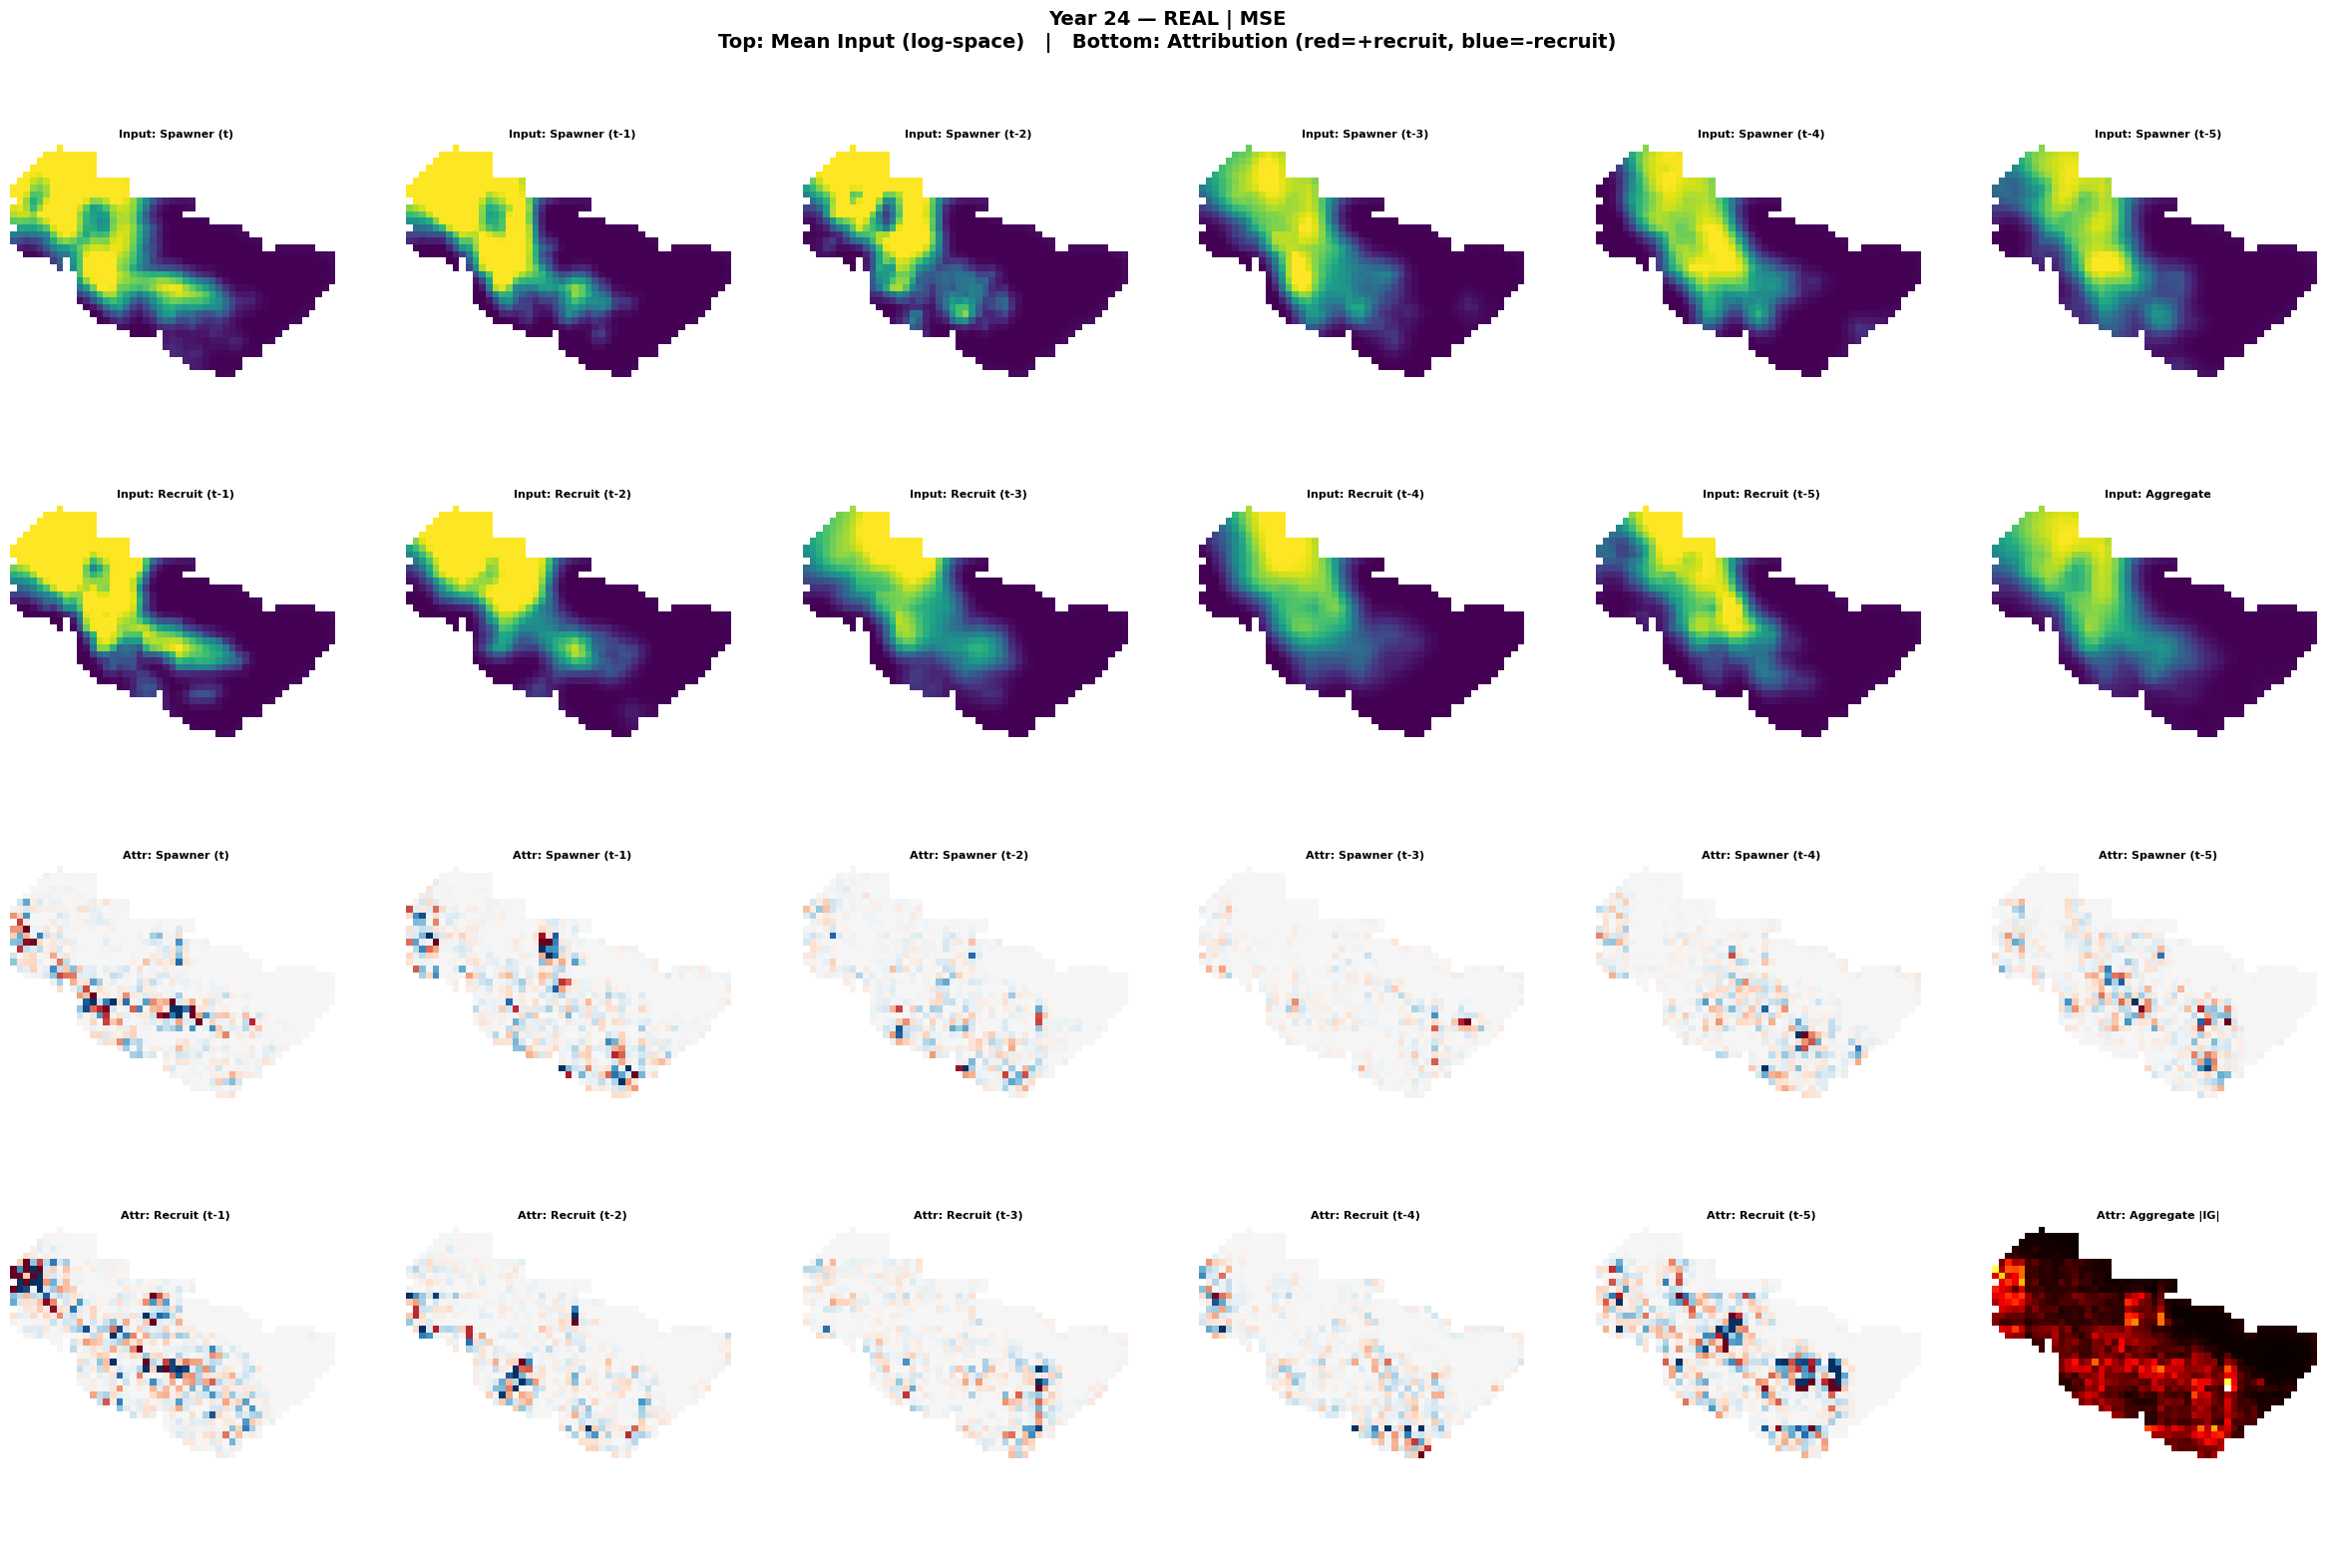

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year25_real_MSE.png


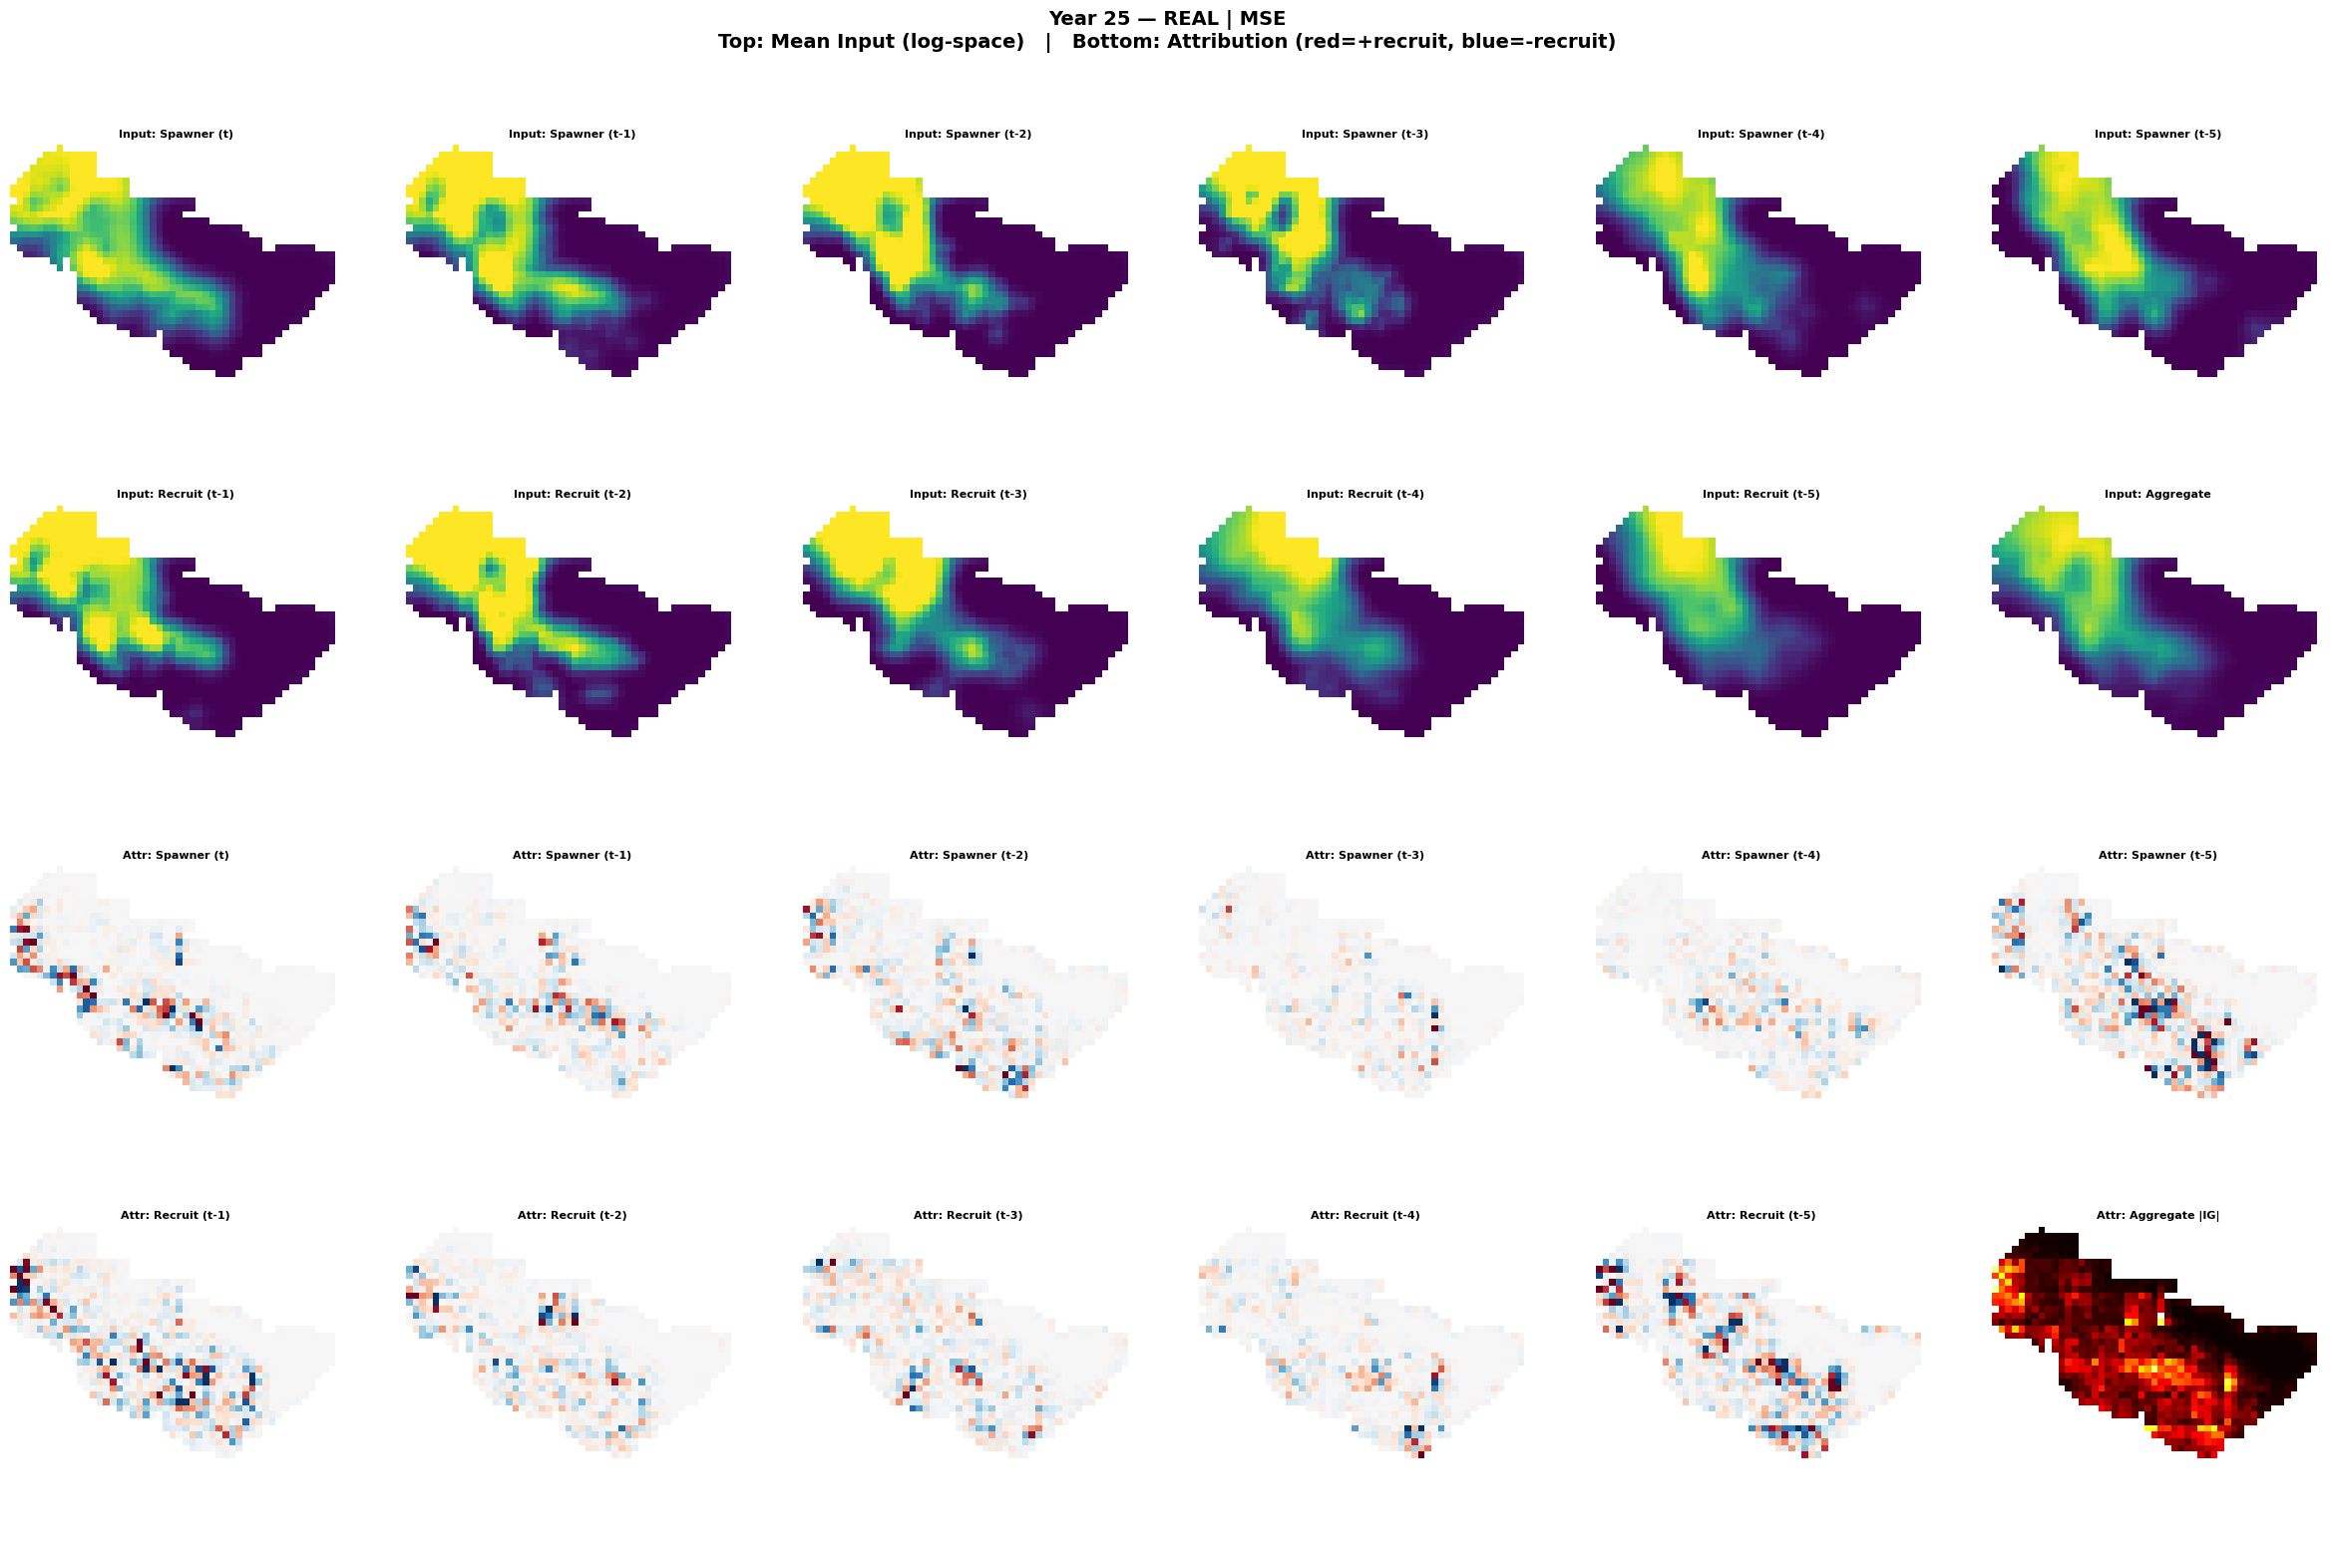

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year26_real_MSE.png


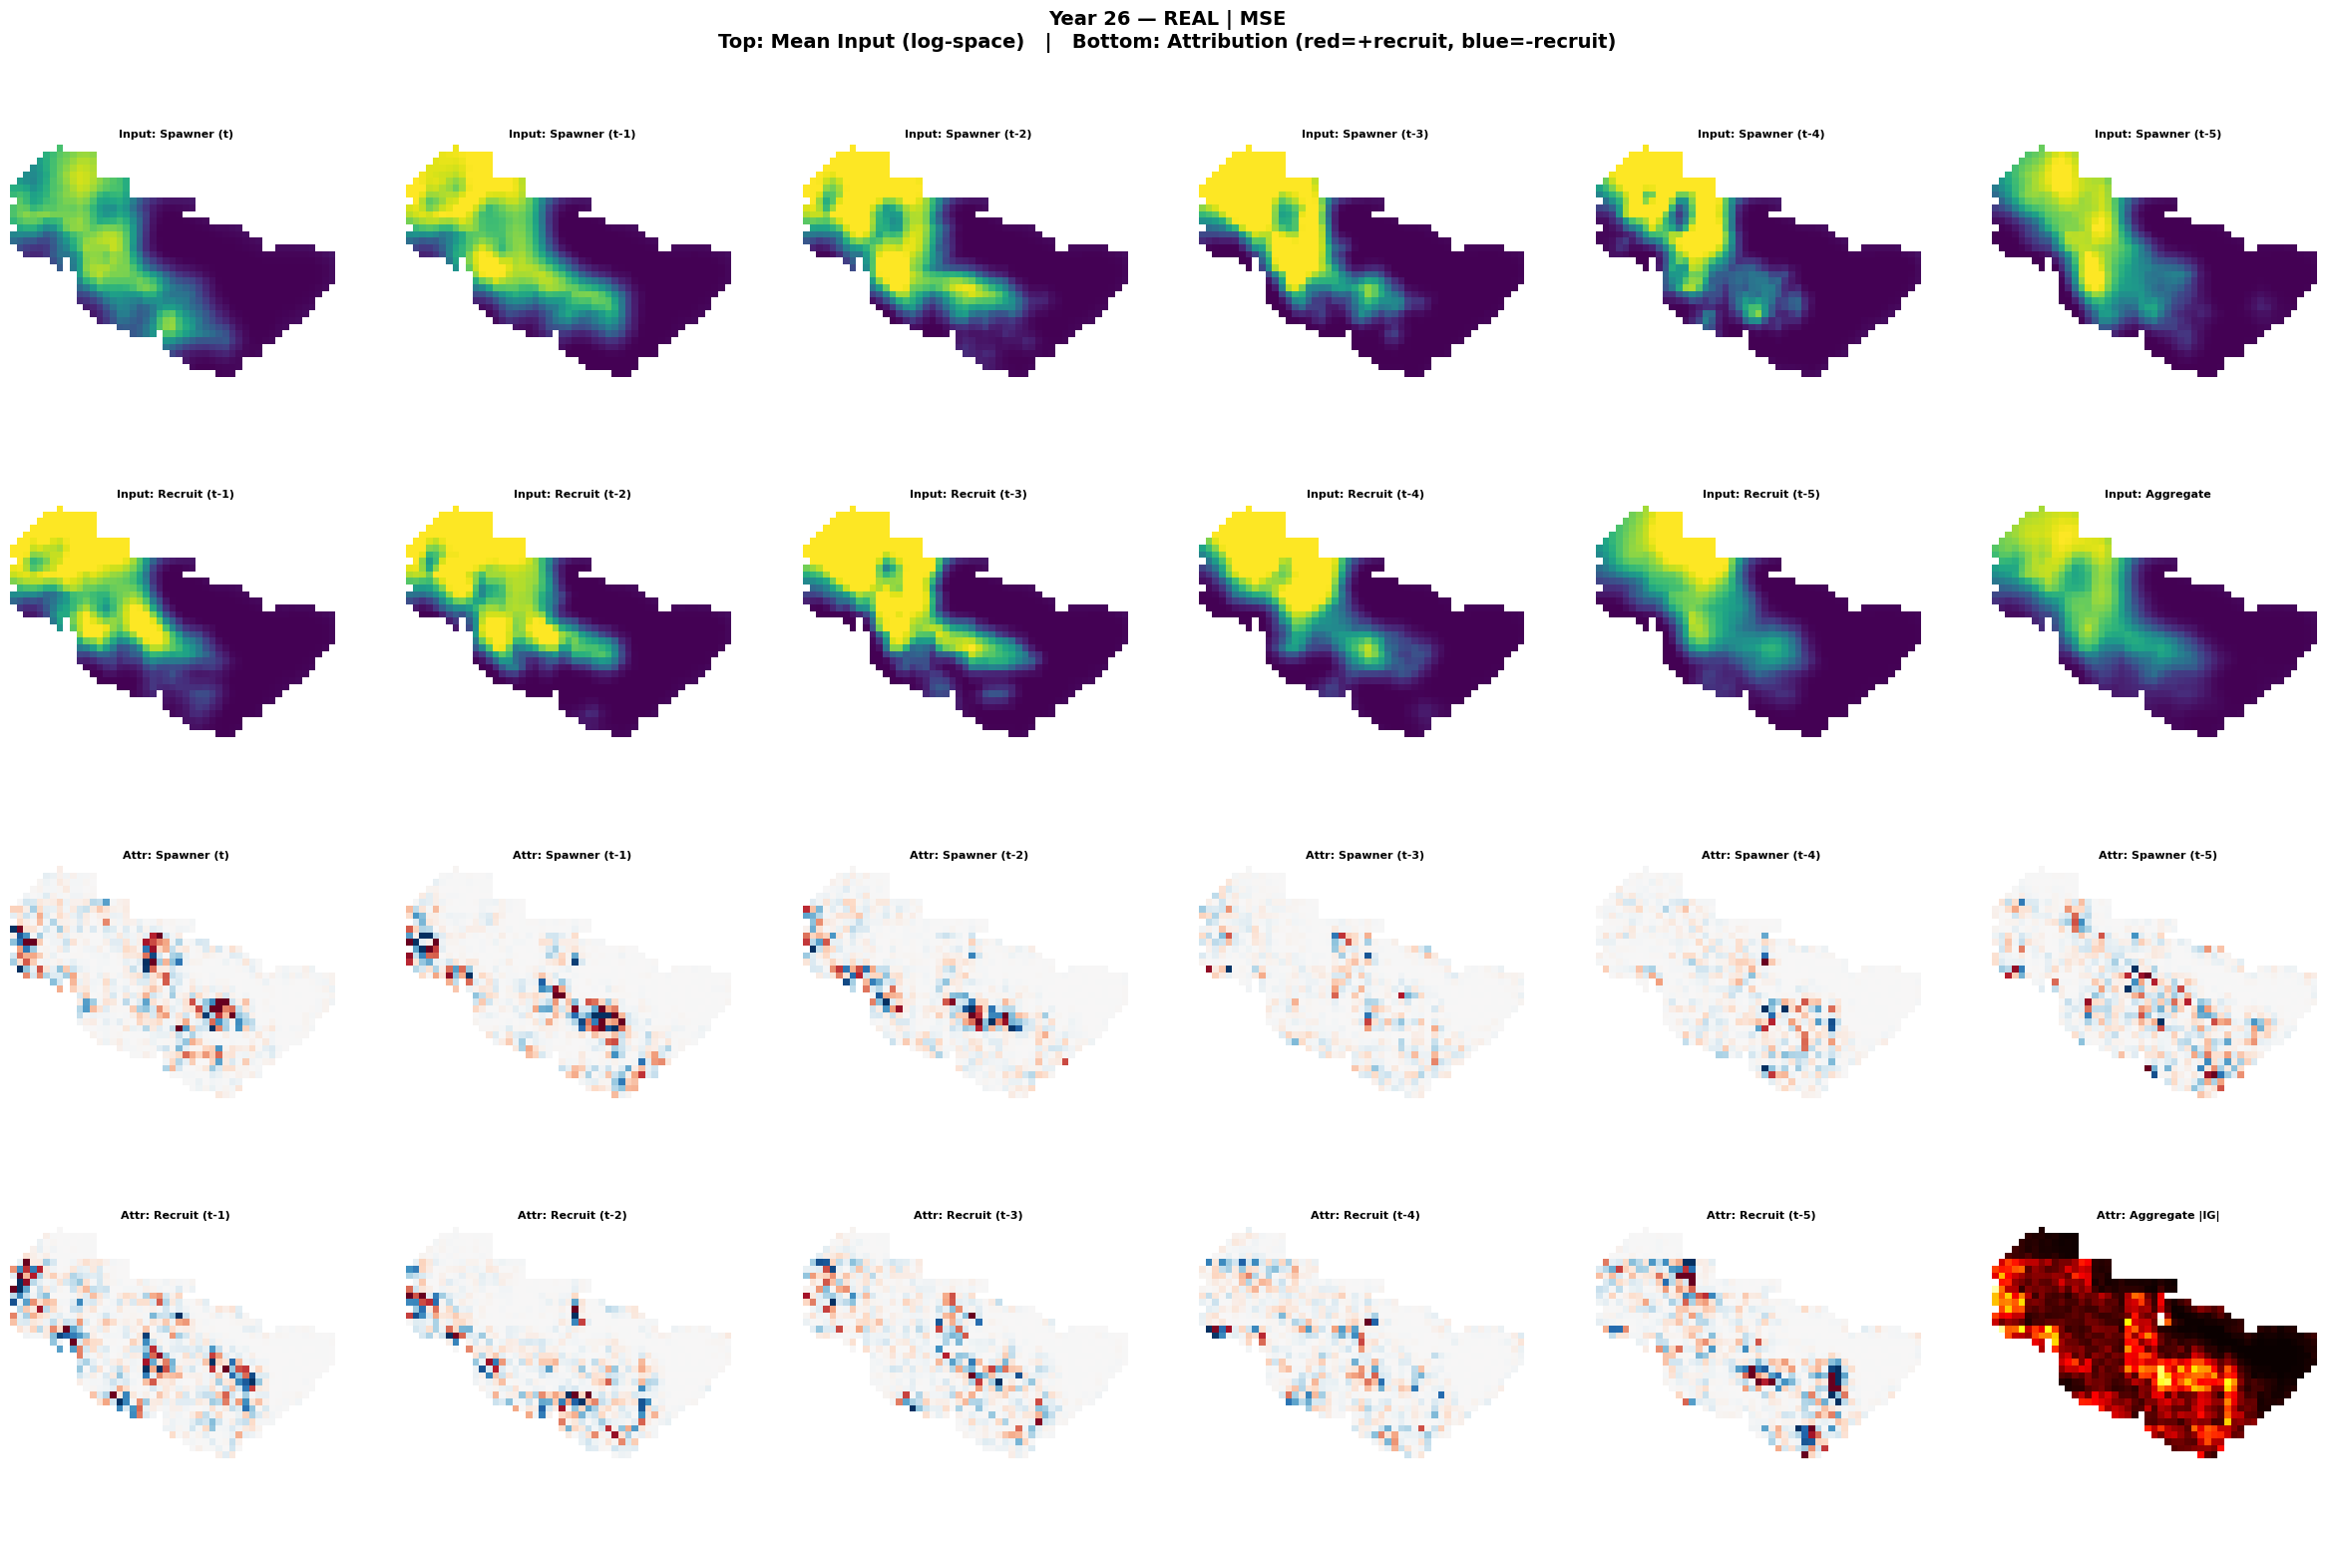

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year27_real_MSE.png


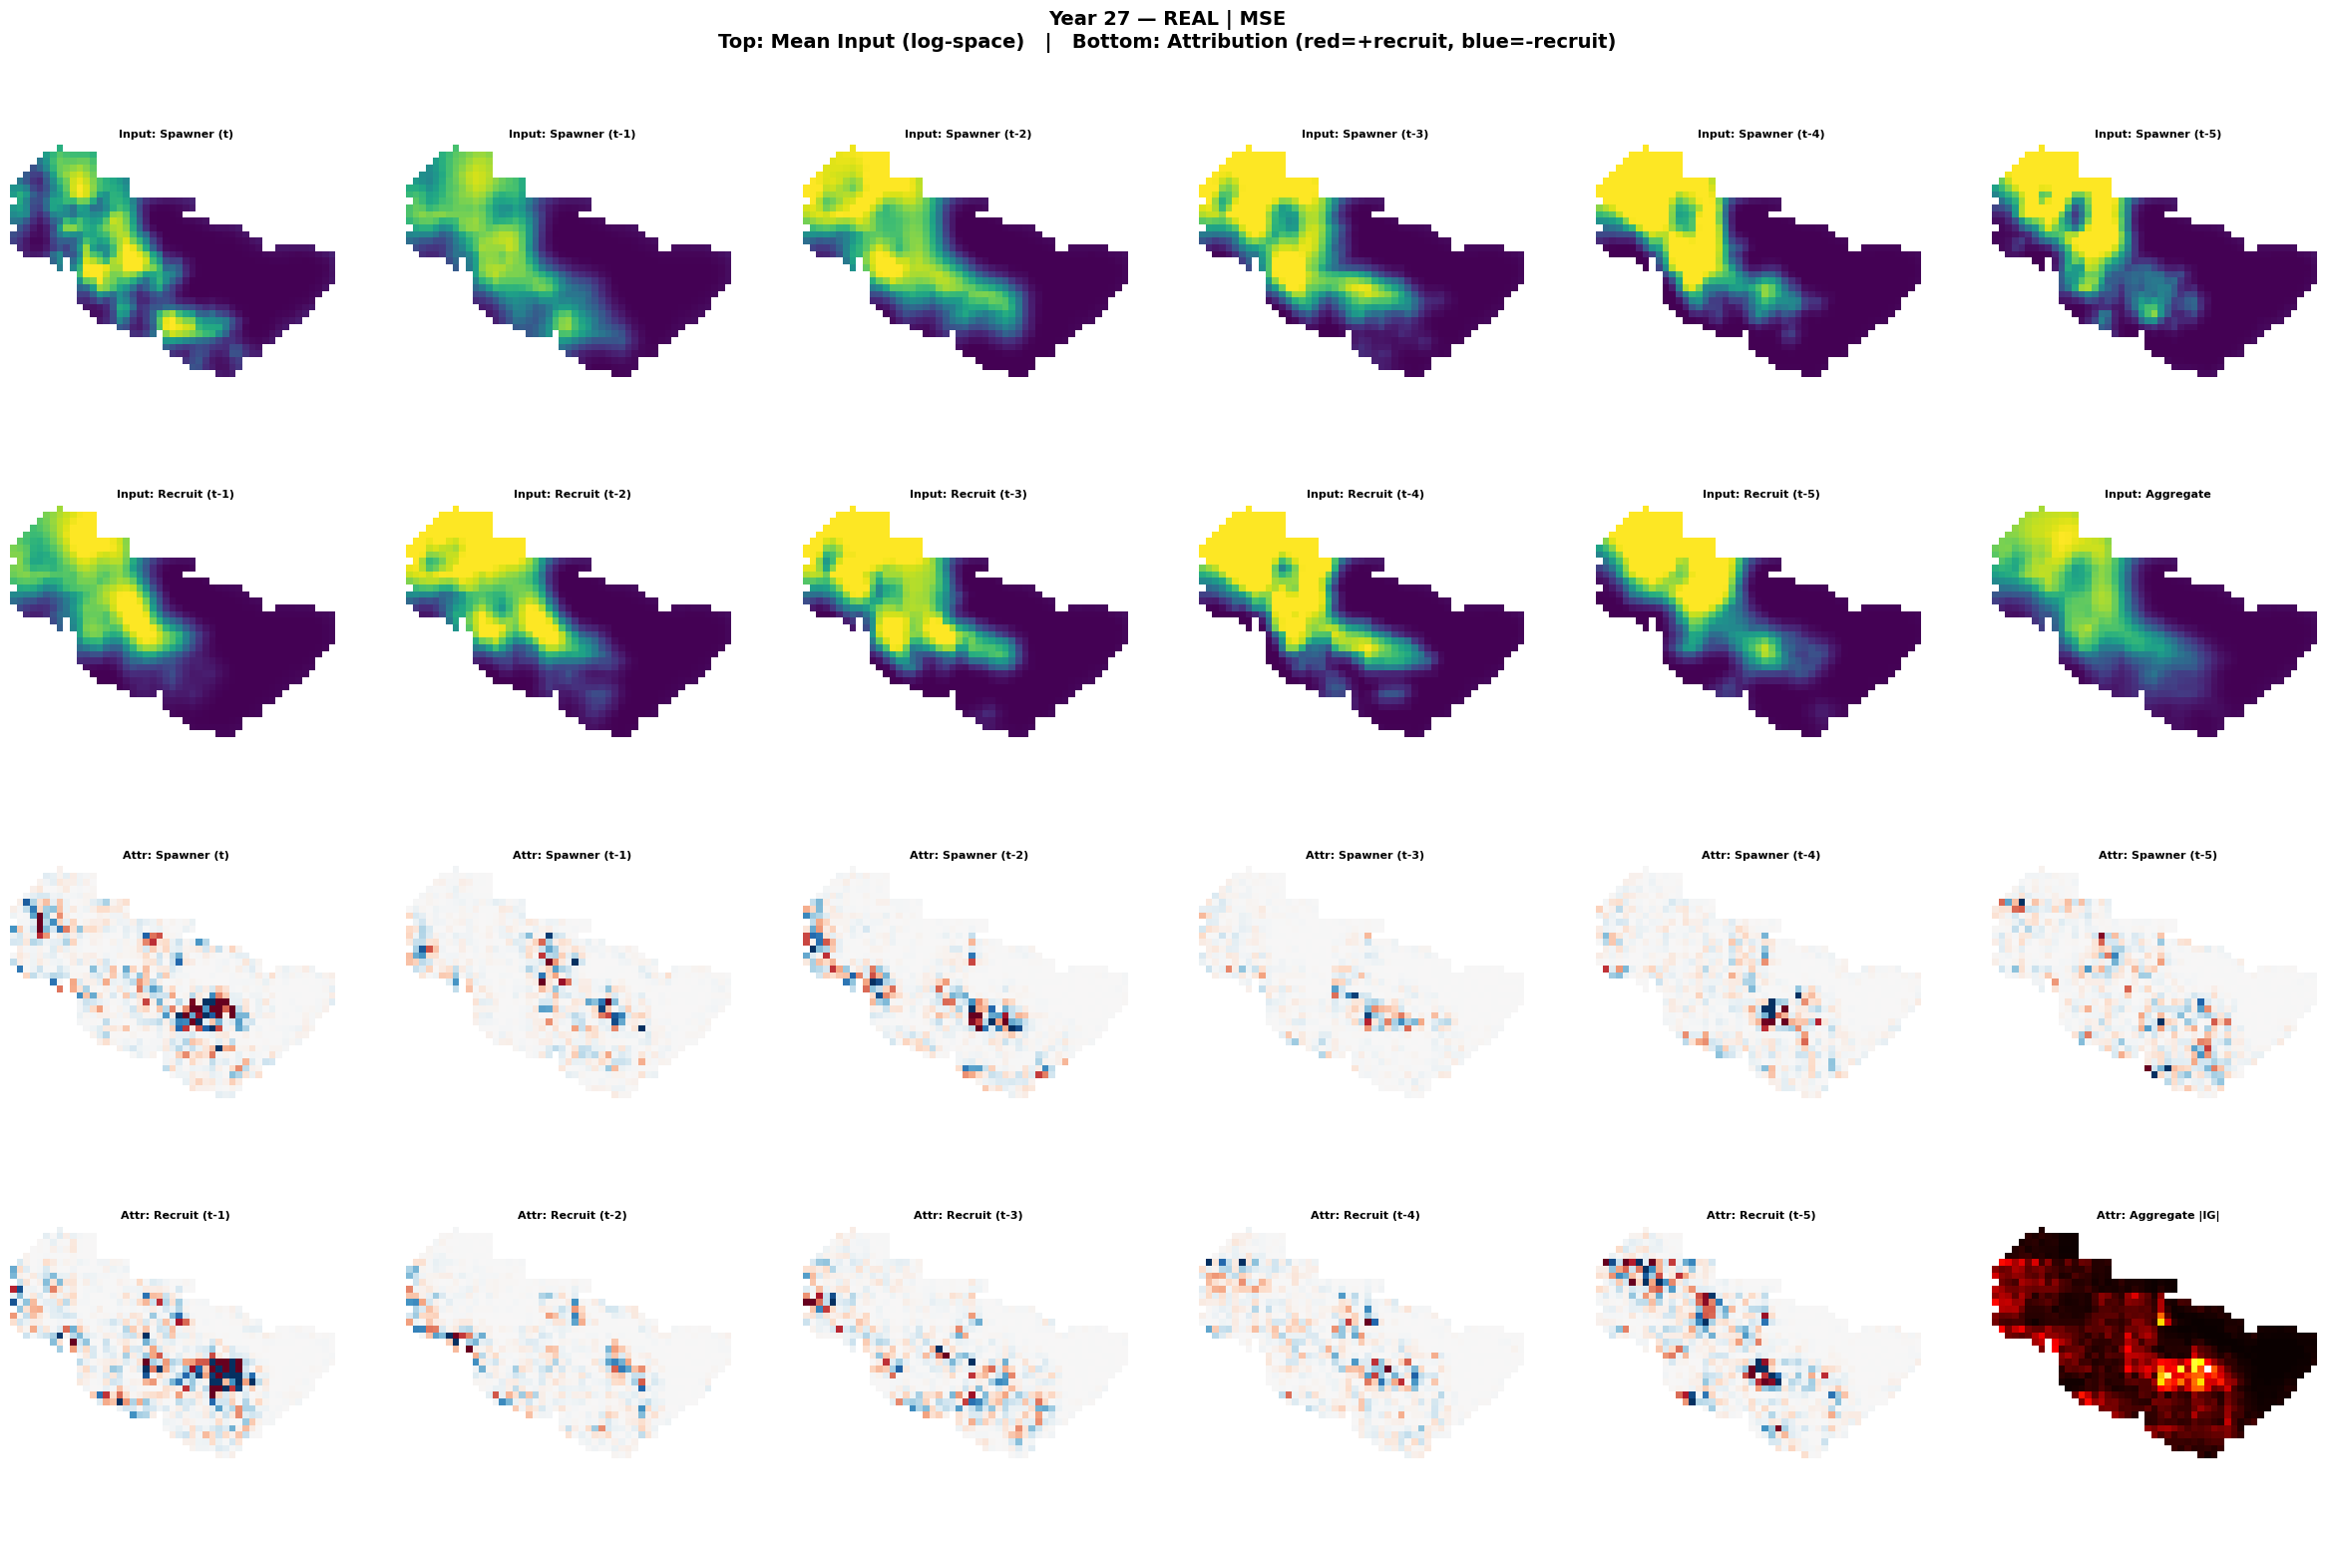

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year28_real_MSE.png


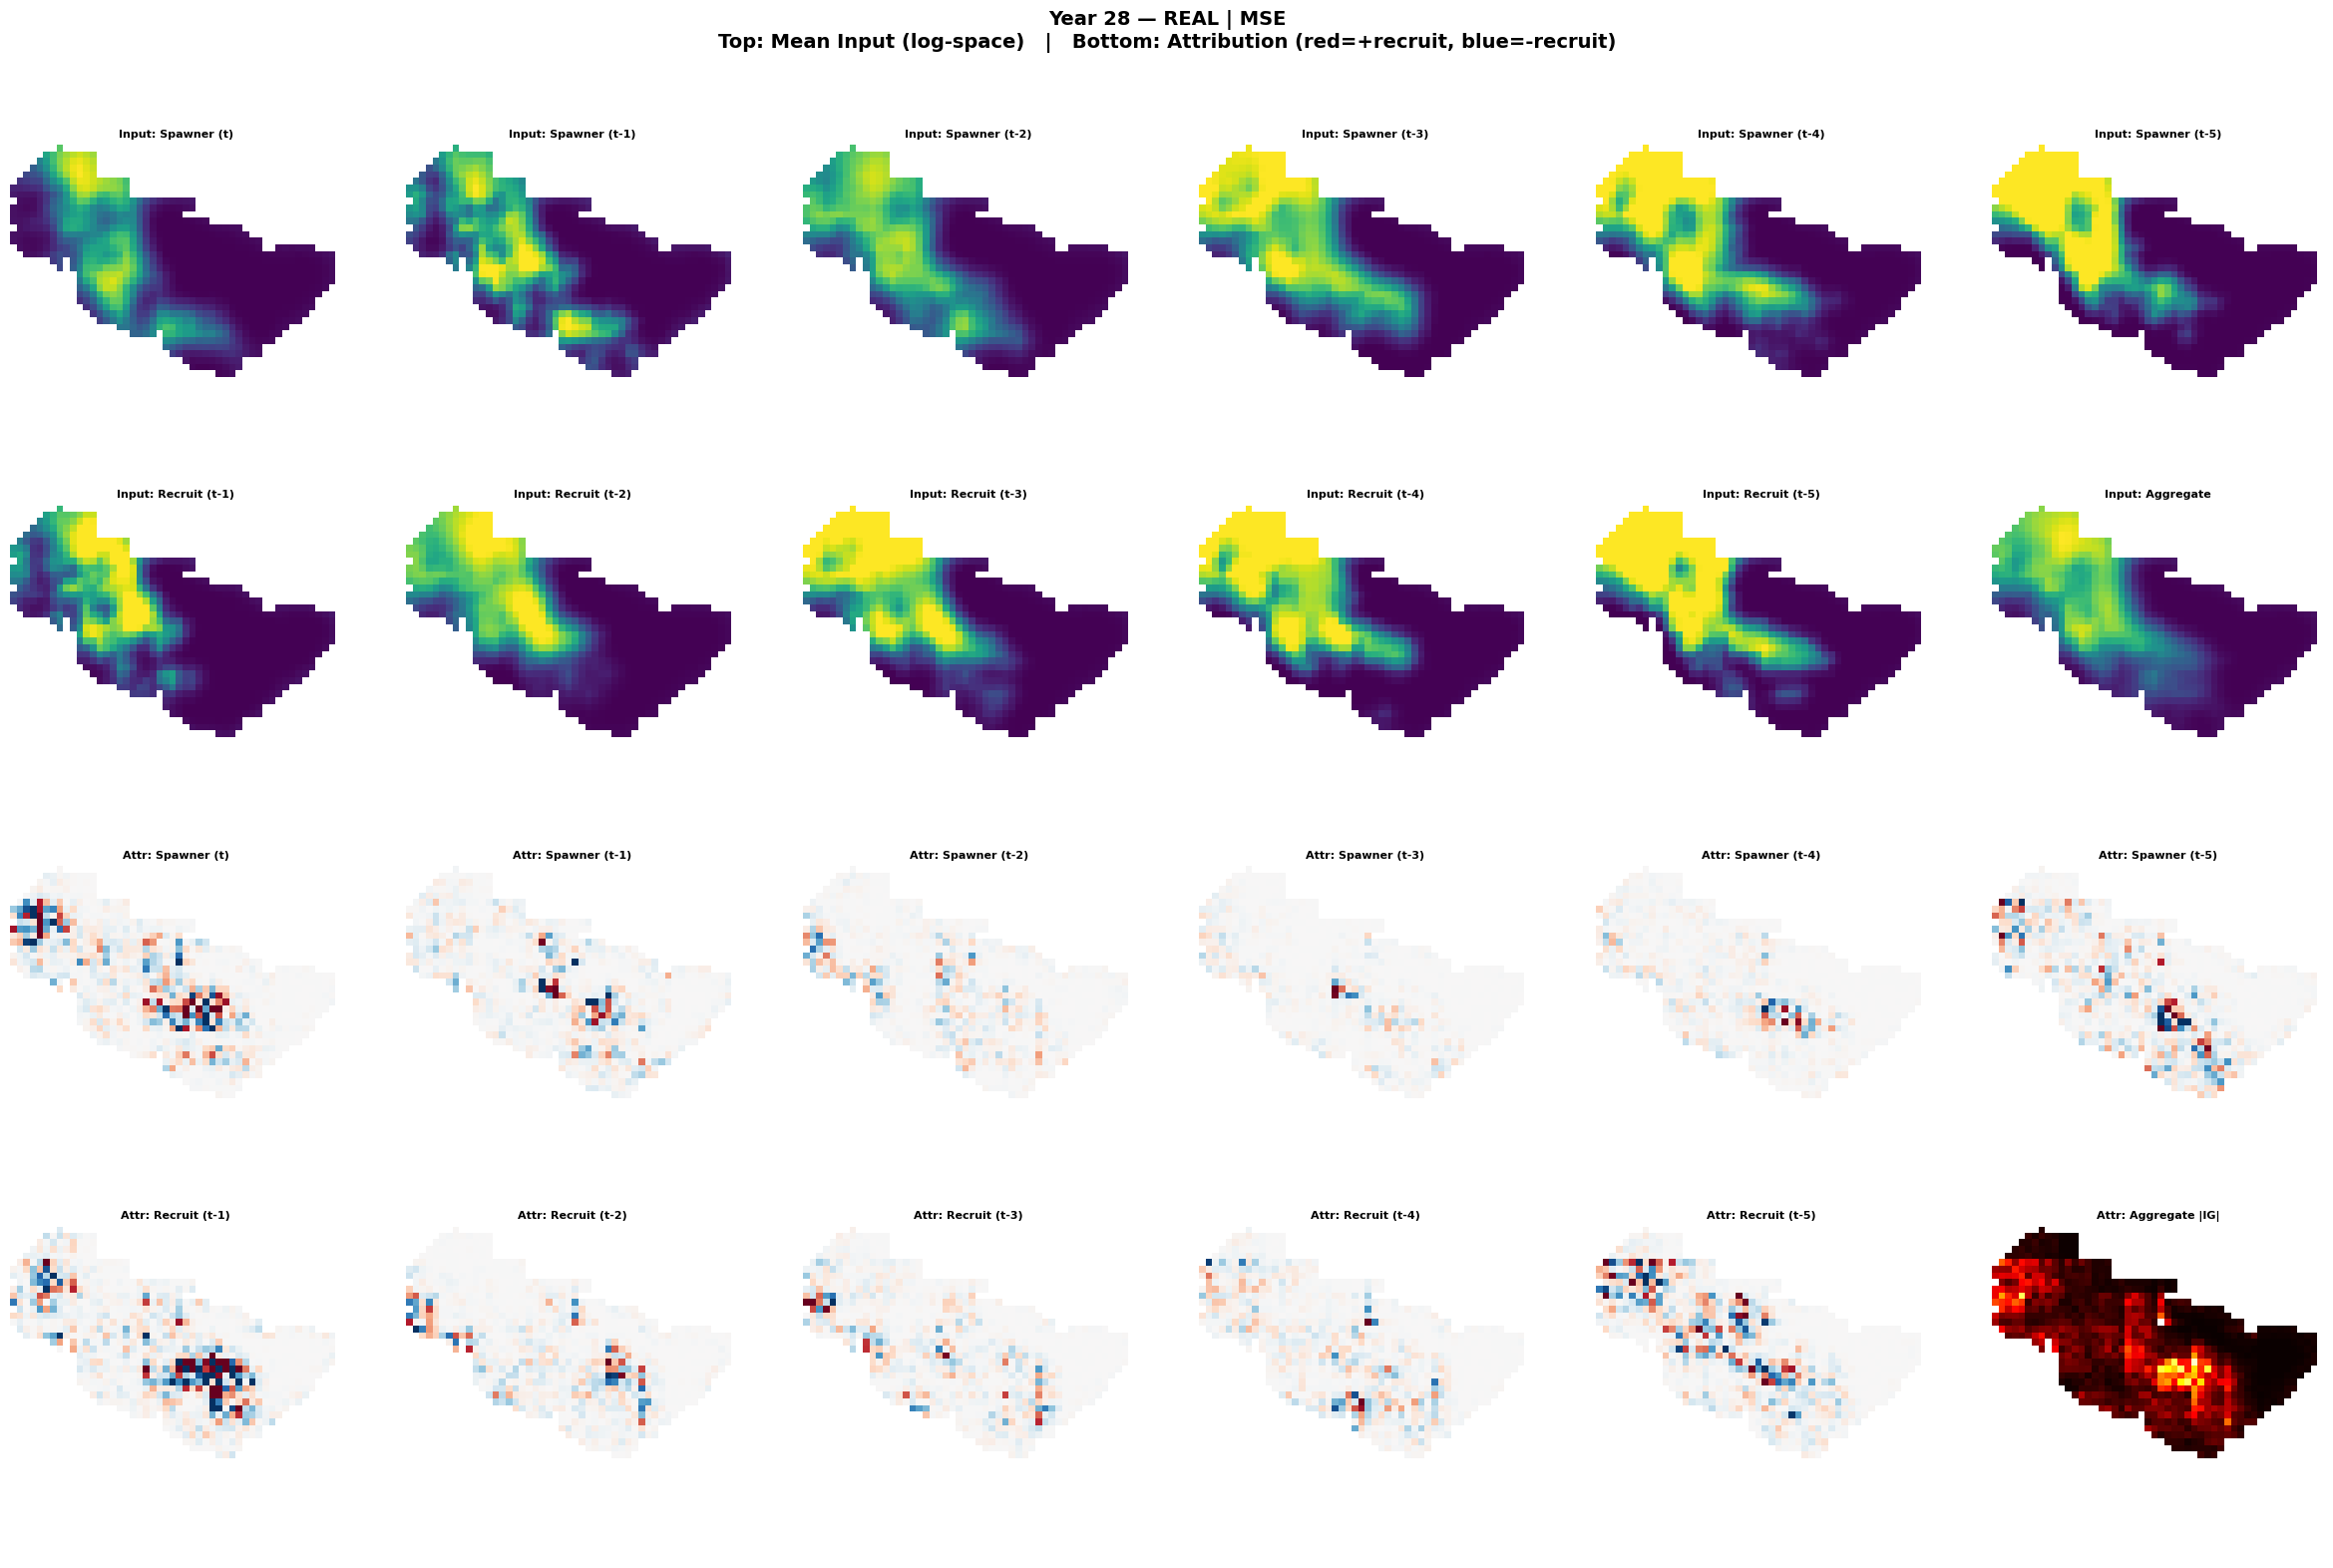

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year29_real_MSE.png


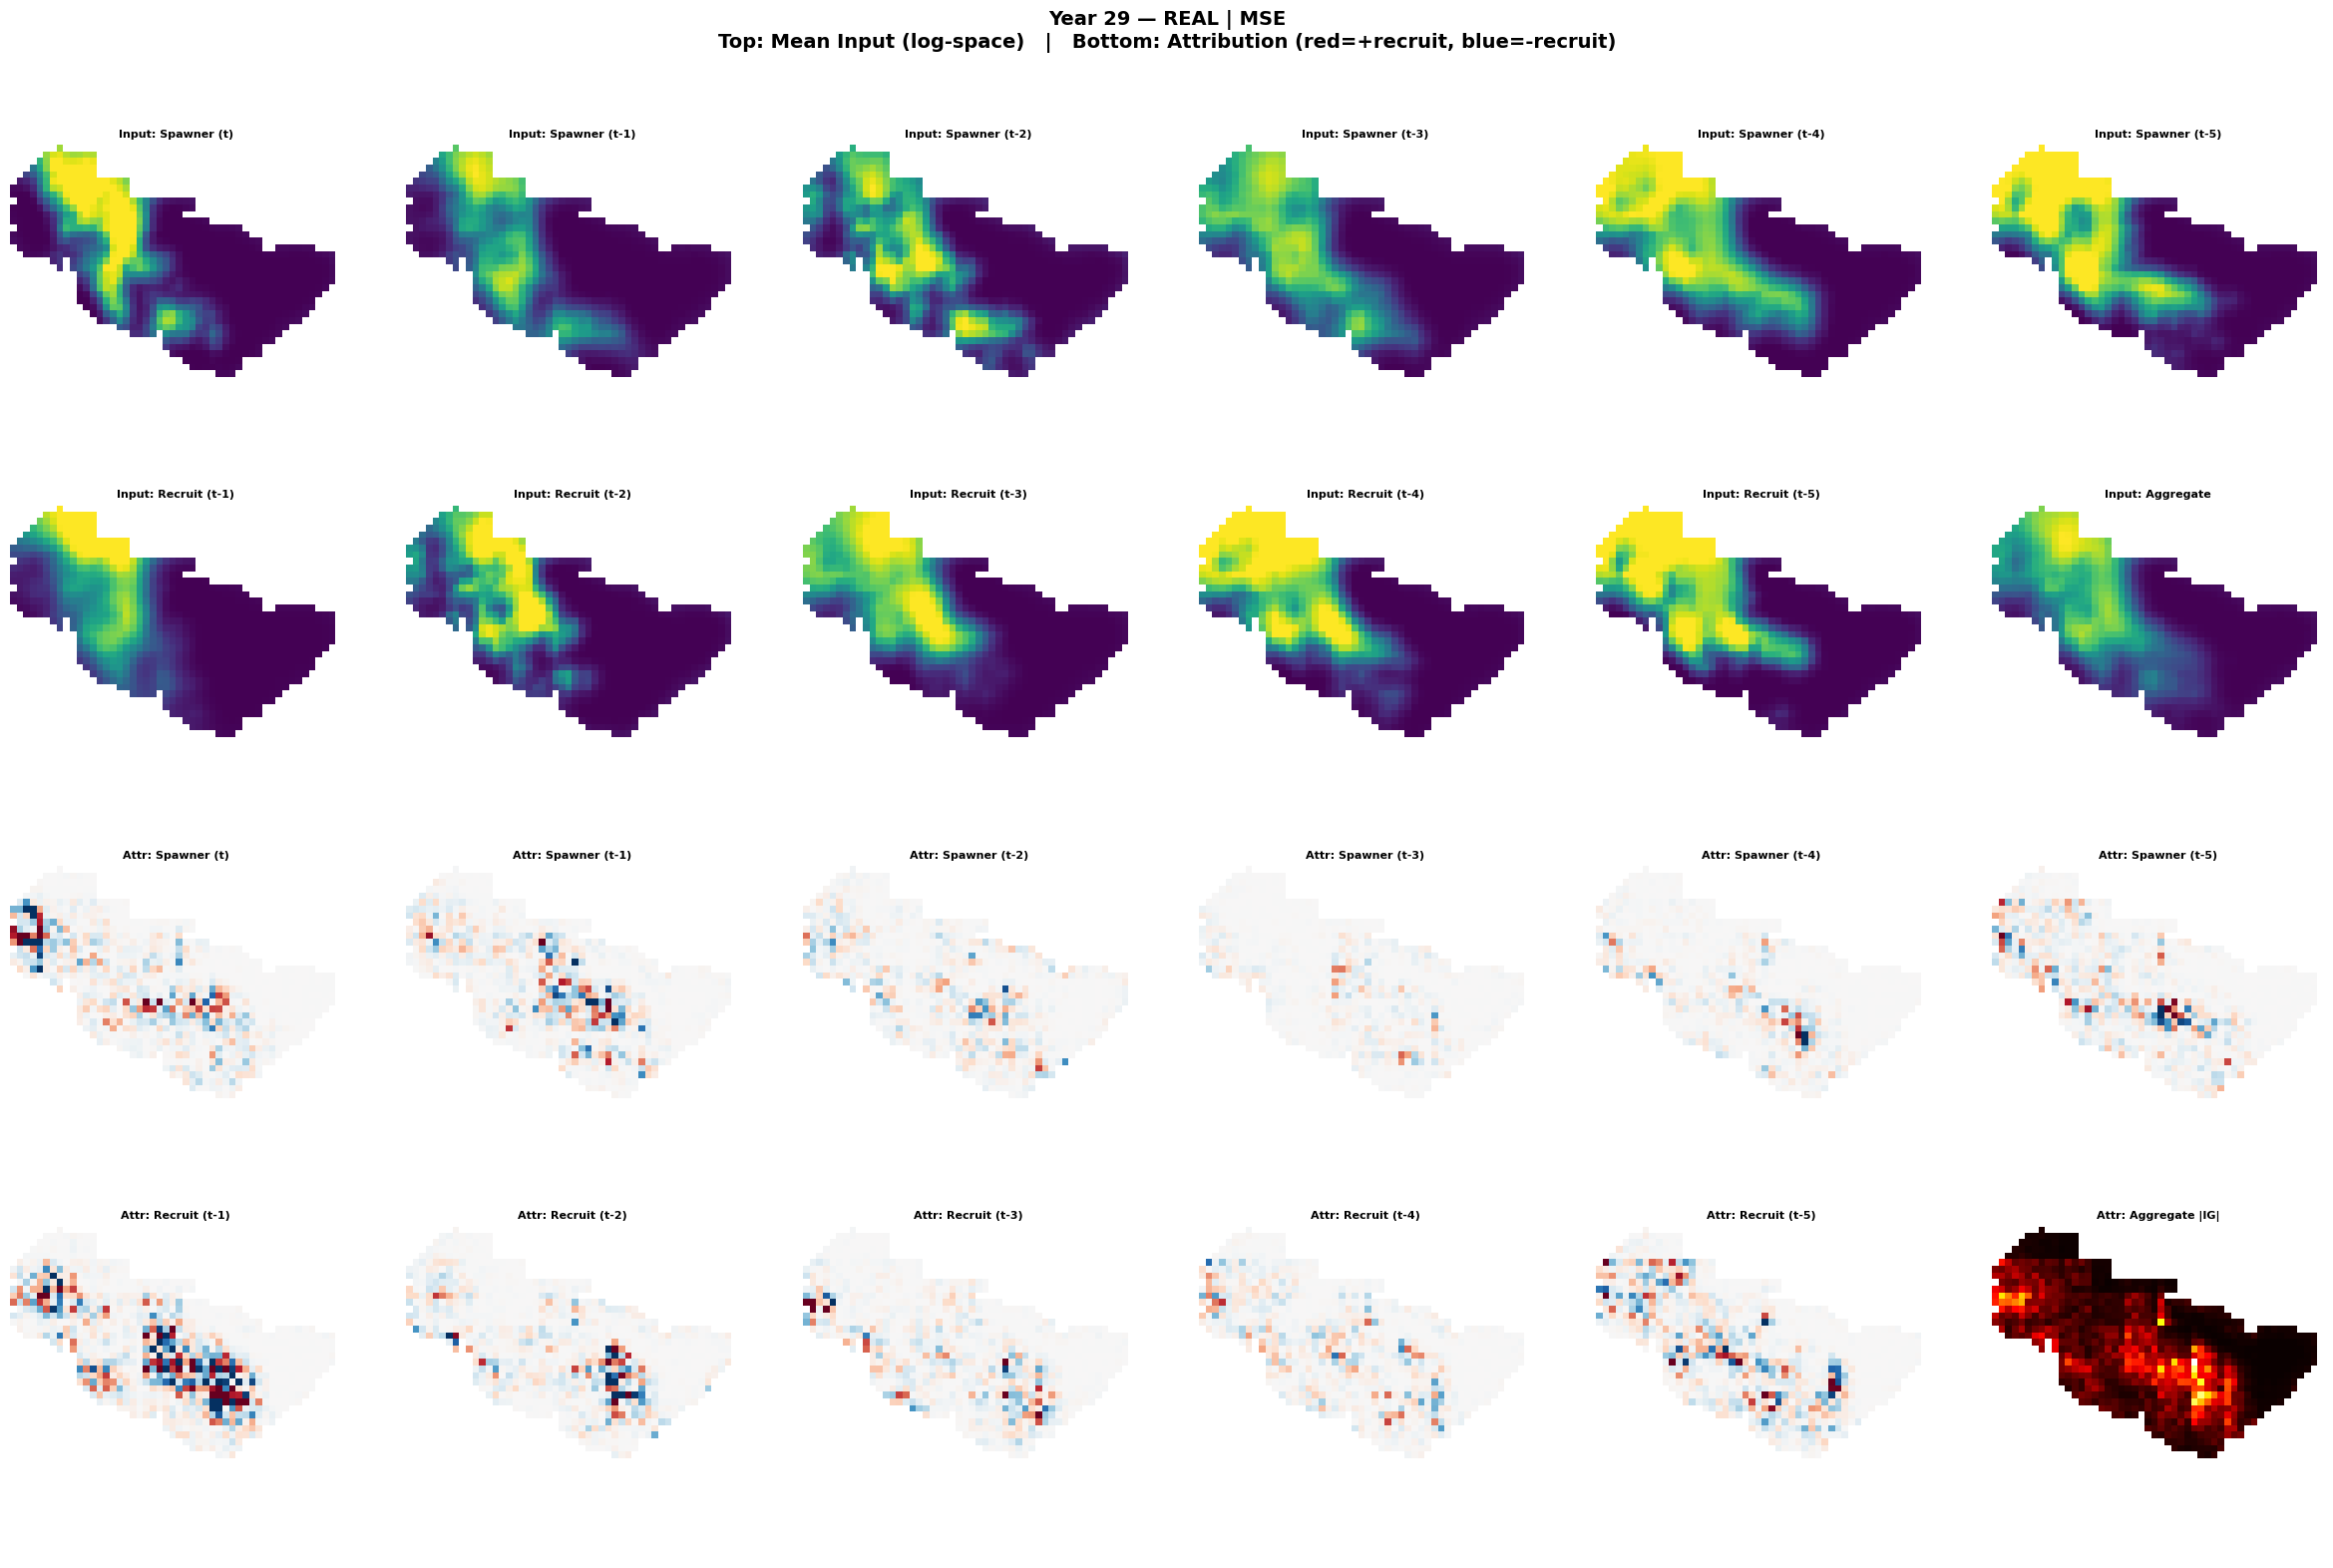

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year30_real_MSE.png


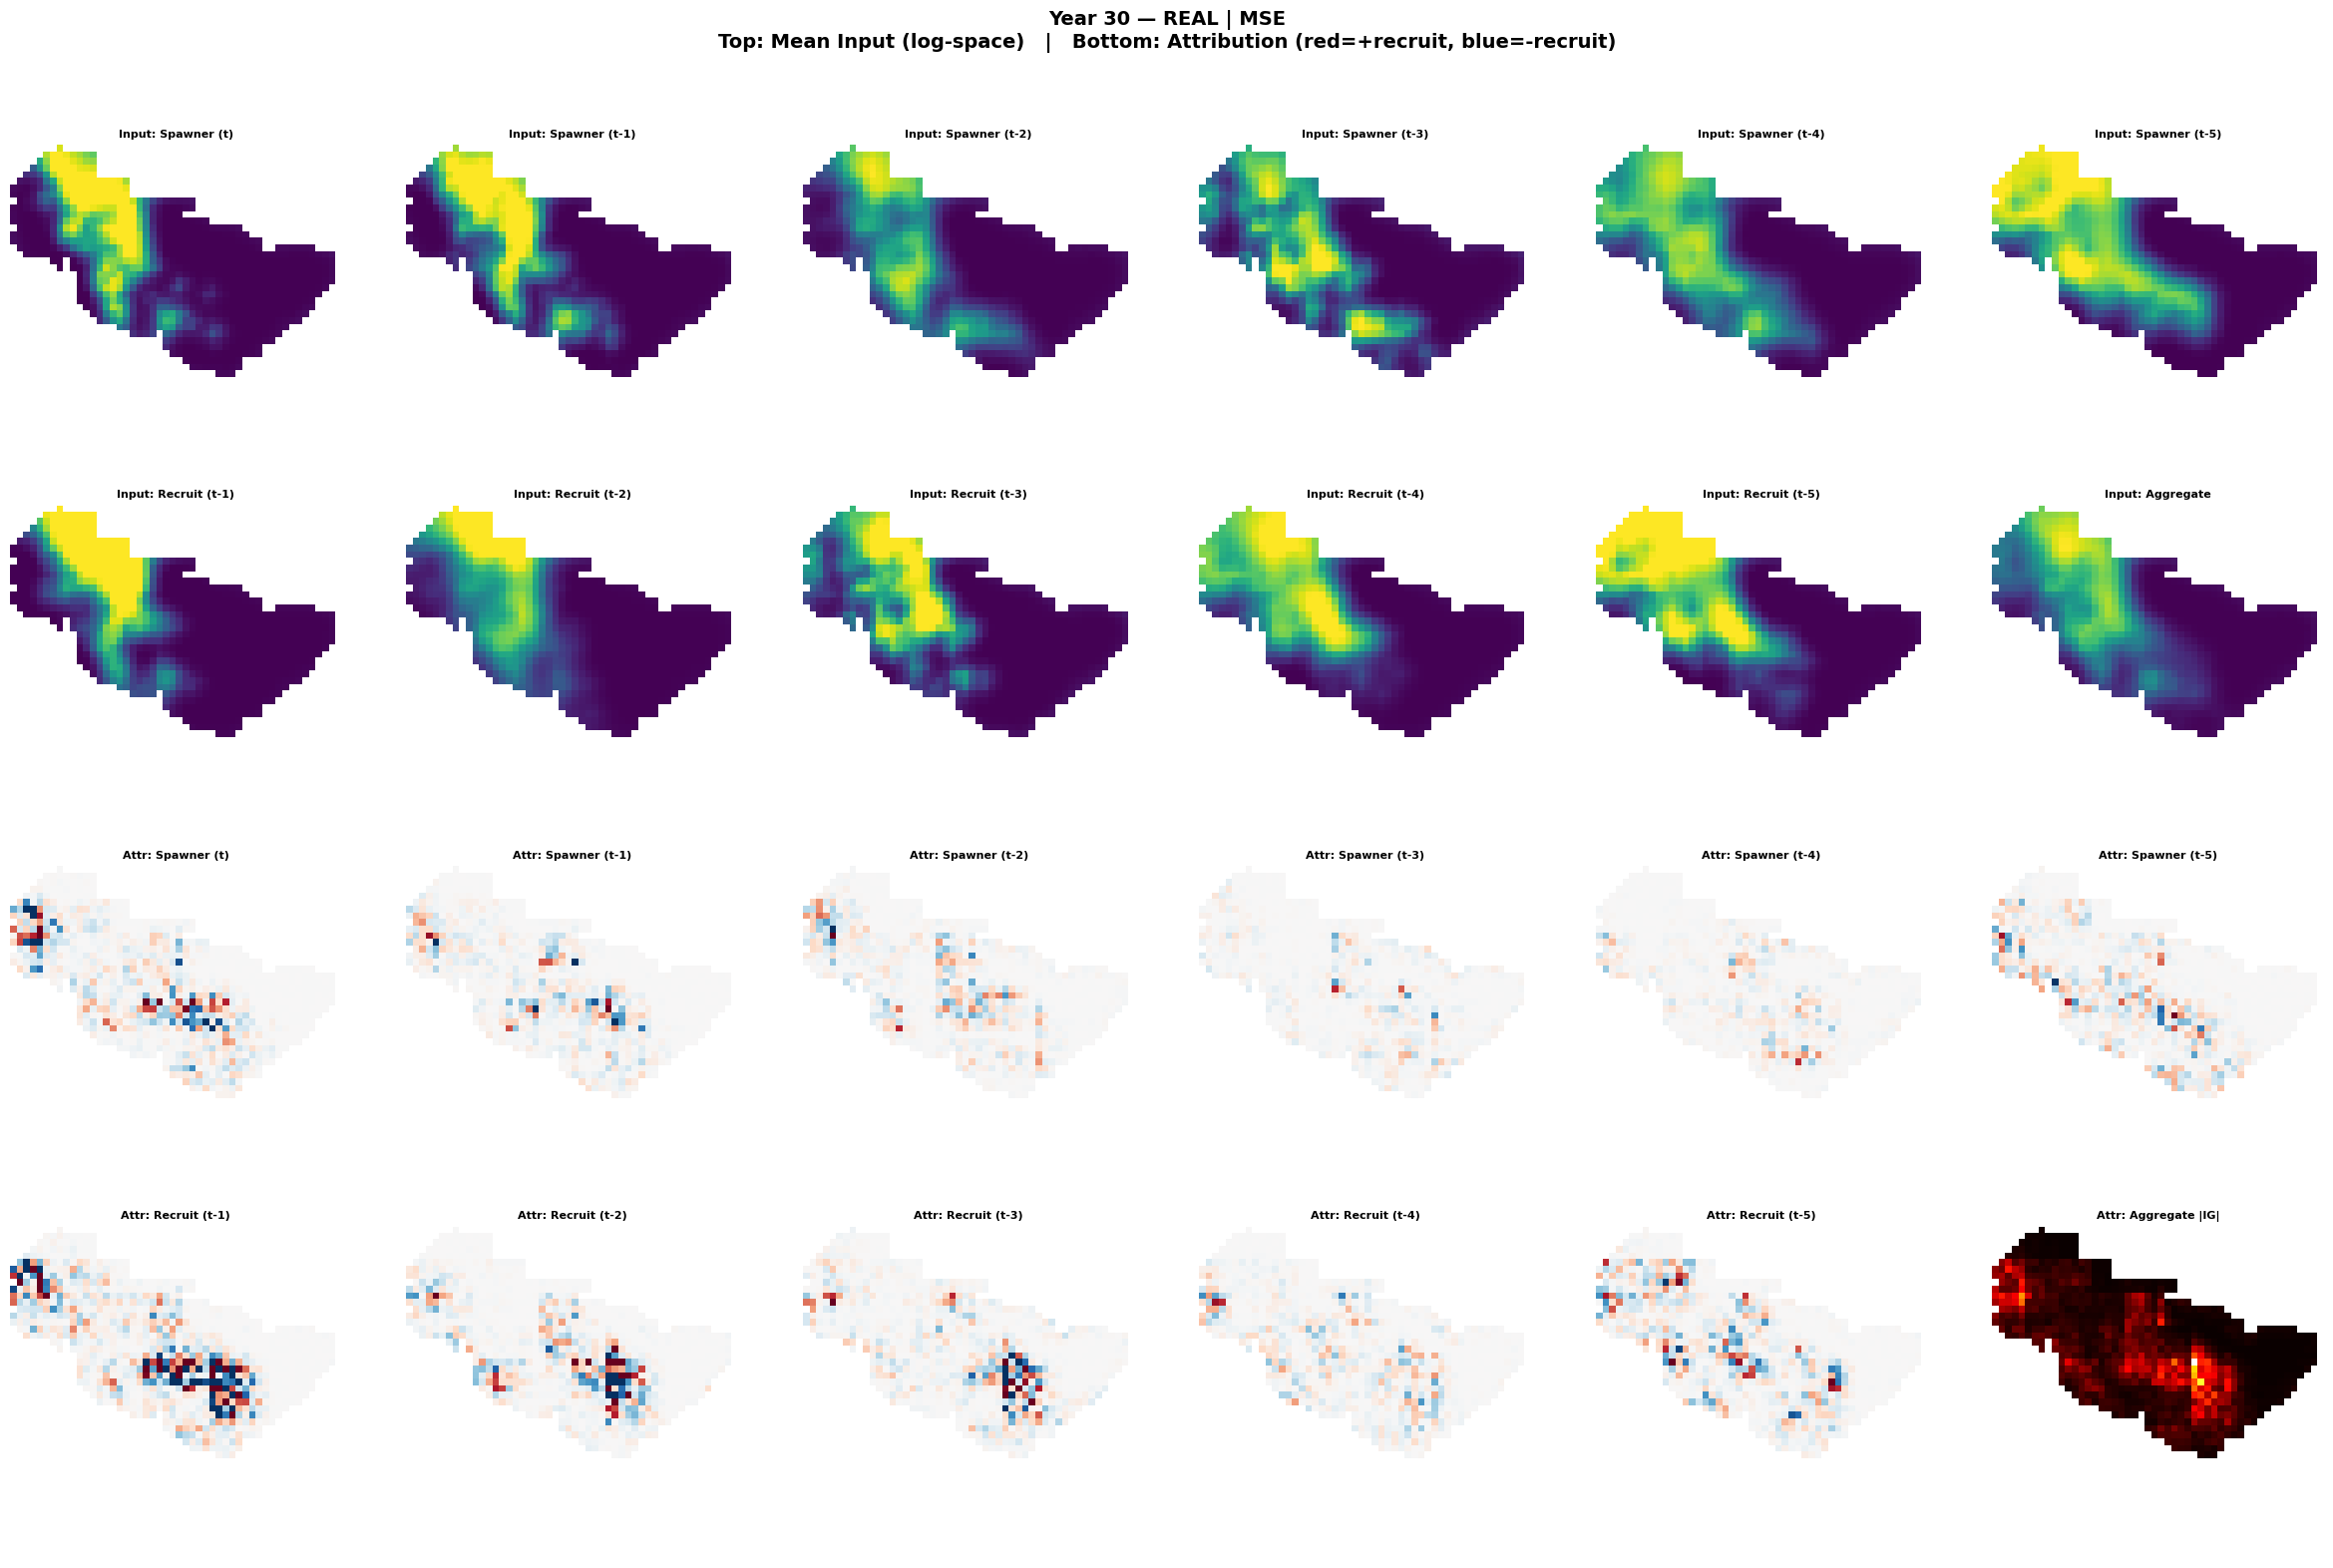

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year31_real_MSE.png


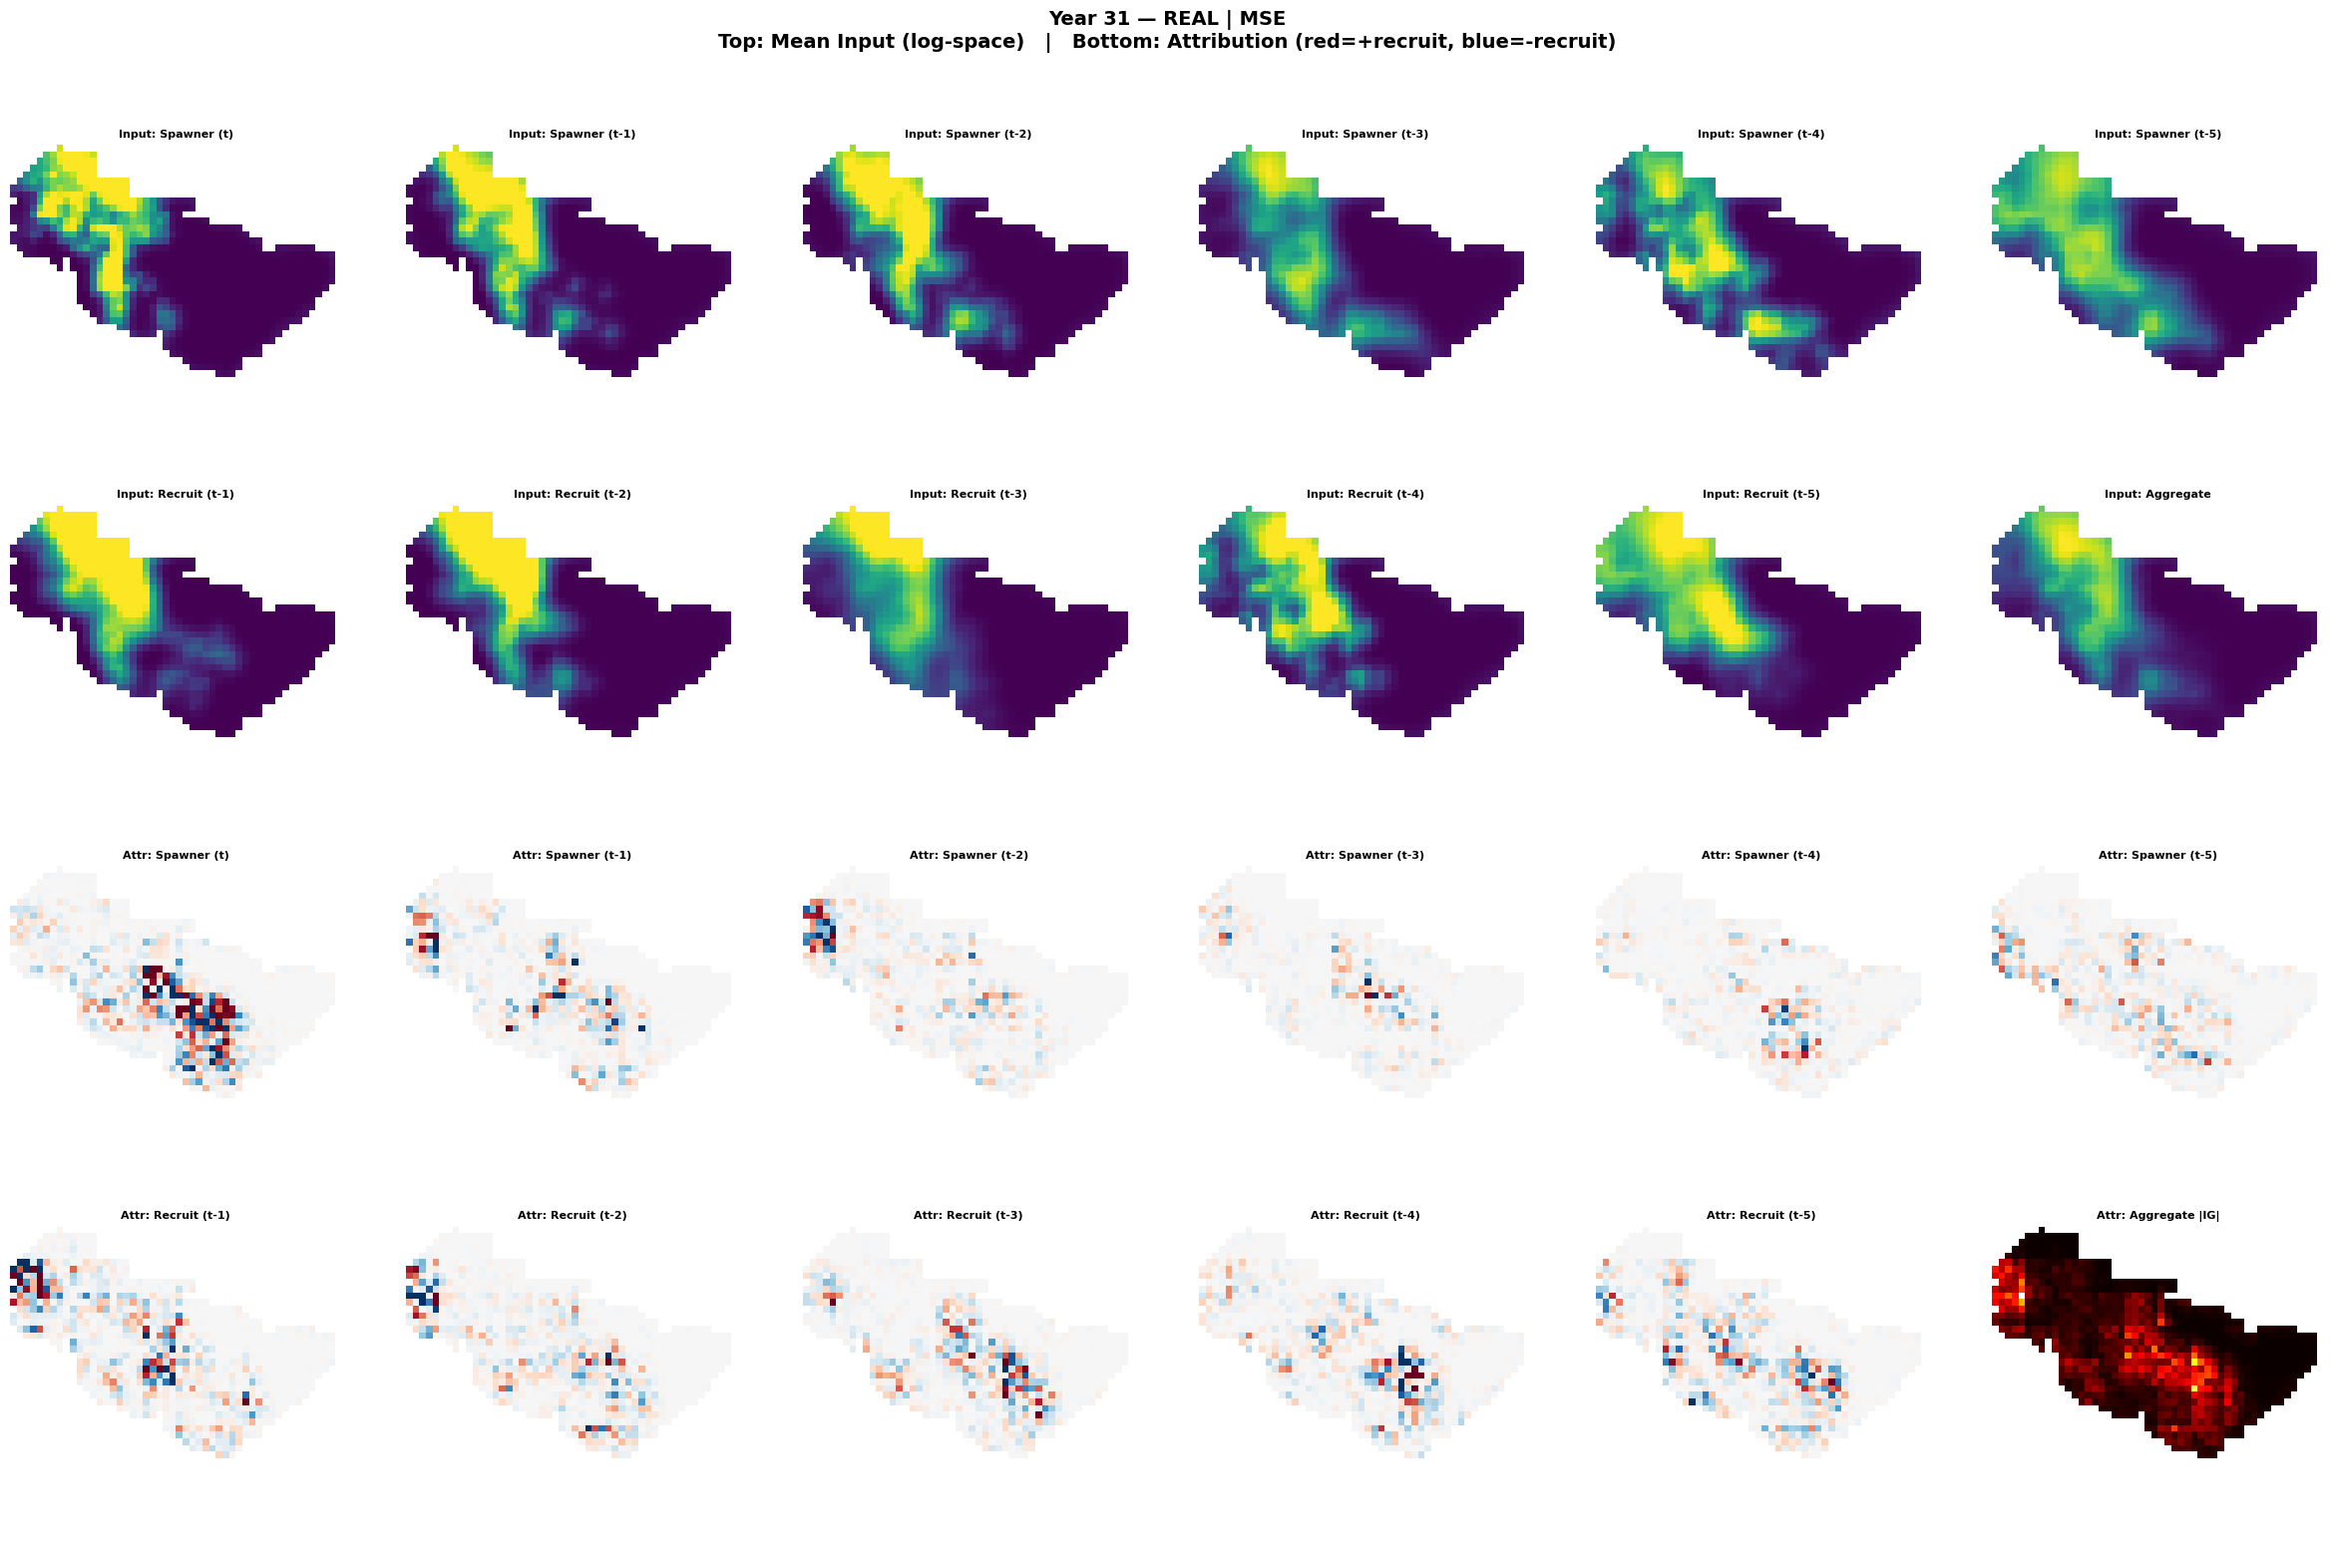


  Generating grand average...
  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_yearAVG_real_MSE.png


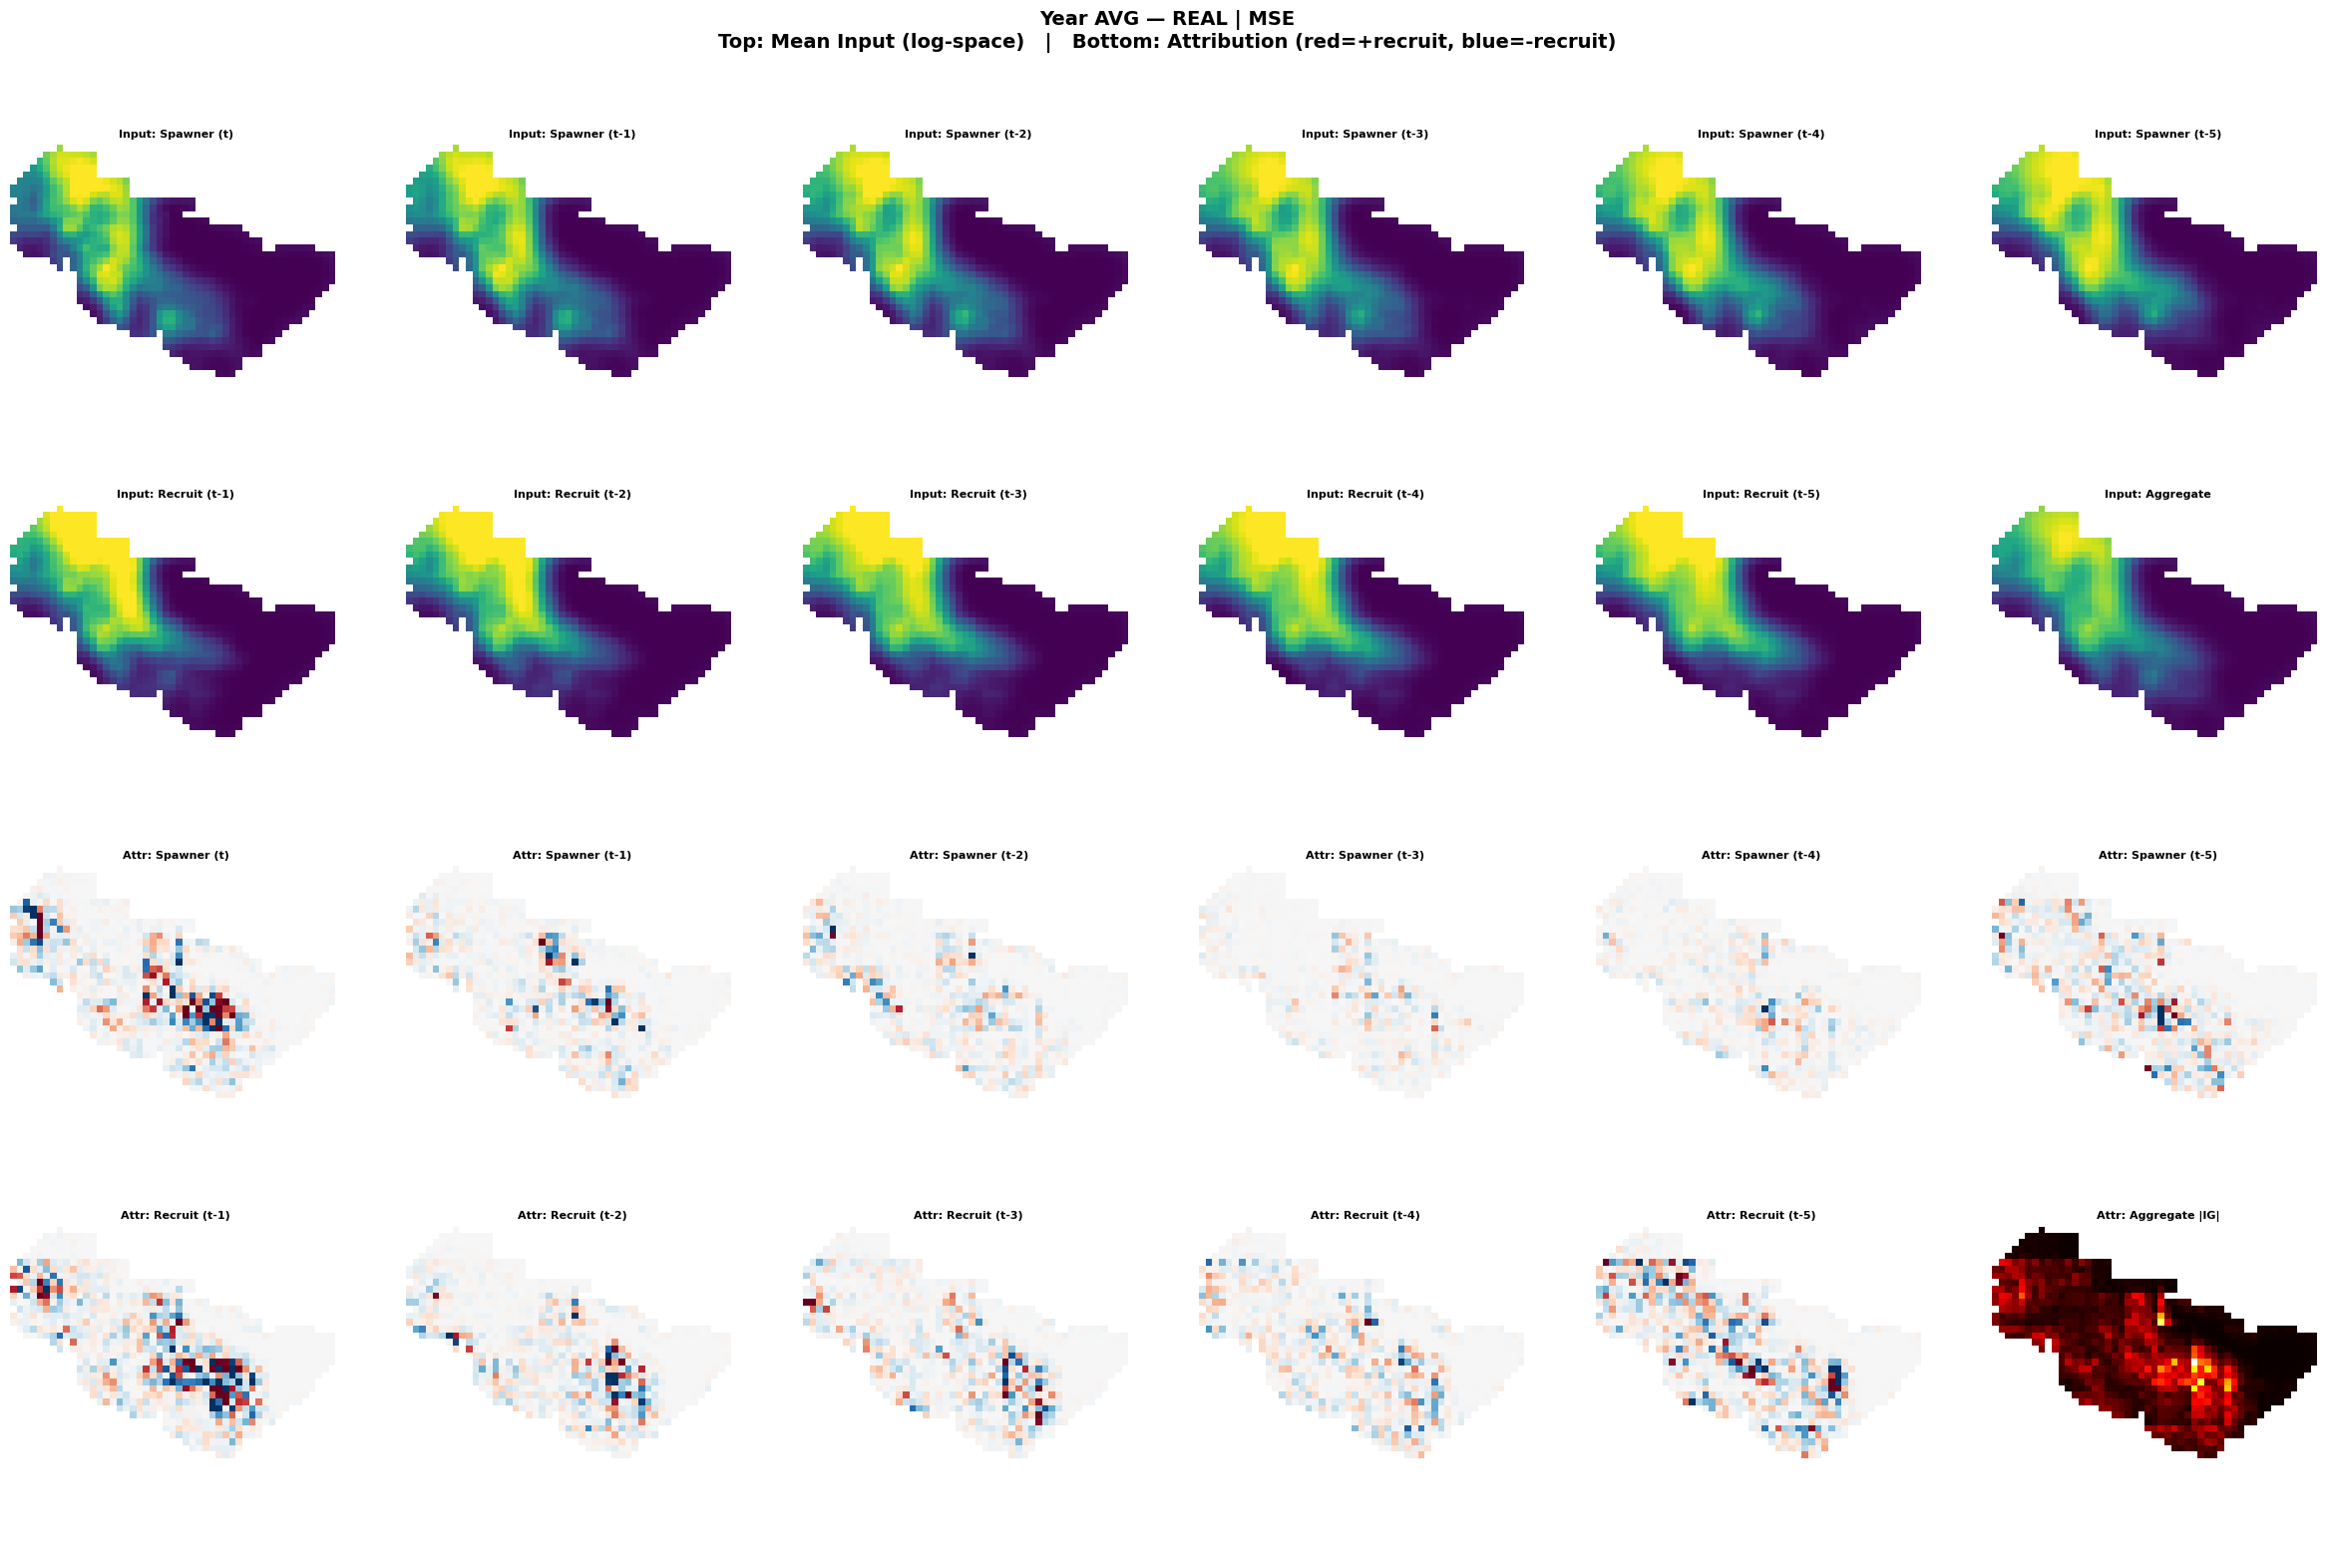


  Generating channel bar chart...
  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_bar_yearly_real_MSE.png


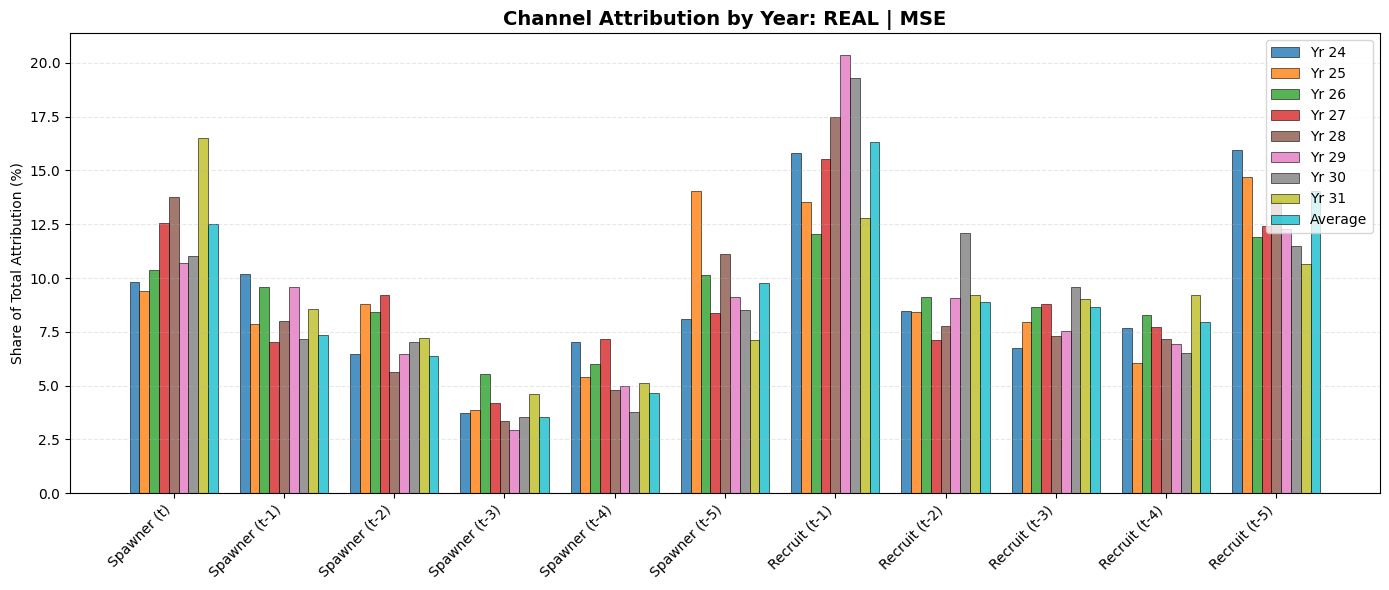

  Raw arrays saved to /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution

  Integrated Gradients: REAL | Tweedie | VAL
  Data type: real | Steps per sample: 50
  Spatial mask: 886 valid cells
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Loaded 100 bootstrap samples, 24 years each
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 8 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
Loaded 100 bootstrap samples, 4 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)
  Computing baseline (mean training field)...
    Baseline from 2400 valid samples
    Range: [0.000, 9.226]

    Year 24: 100 bootstrap samples
    Year 25: 100 bootstrap samples
    Year 26:

KeyboardInterrupt: 

In [18]:
"""
=============================================================================
Integrated Gradients for CrabTransformer (v3 — real data support)
=============================================================================
Post-hoc attribution analysis. Run AFTER training is complete.

For each validation year:
  - Averages IG attribution across all 100 bootstraps
  - Shows the mean input channels alongside attribution maps
  - Answers: "What spatial patterns drove recruitment prediction this year?"

Usage:
    from integrated_gradients import run_integrated_gradients
    run_integrated_gradients(level='easy', criterion='MSE', data_type='dummy')
    run_integrated_gradients(criterion='MSE', data_type='real')
"""

import os
import json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from models.model import CrabTransformer
from data.data_helper import get_dataloaders

# =============================================================================
# CONFIGURATION
# =============================================================================

REPO_DIR   = '/content/Teleconnections-ViT'
DRIVE_DIR  = '/content/drive/MyDrive/Teleconnection_ViT'
SAVE_DIR   = os.path.join(DRIVE_DIR, 'analysis/attribution')
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHANNEL_NAMES = [
    'Spawner (t)',
    'Spawner (t-1)',
    'Spawner (t-2)',
    'Spawner (t-3)',
    'Spawner (t-4)',
    'Spawner (t-5)',
    'Recruit (t-1)',
    'Recruit (t-2)',
    'Recruit (t-3)',
    'Recruit (t-4)',
    'Recruit (t-5)'
]

# =============================================================================
# STEP 1: COMPUTE BASELINE (mean field from training data)
# =============================================================================

def compute_baseline(train_loader):
    """
    Mean input field across all valid training samples.
    This is the "boring" reference — an average year.
    Returns: tensor [1, 11, 50, 50]
    """
    print('  Computing baseline (mean training field)...')
    all_inputs = []

    # Safely unpack and skip 2020
    for batch in train_loader:
        inputs = batch[0]
        valid_year = batch[5]

        # Only keep inputs where the year is valid (not 2020)
        valid_inputs = inputs[valid_year > 0]
        if len(valid_inputs) > 0:
            all_inputs.append(valid_inputs)

    stacked = torch.cat(all_inputs, dim=0)
    baseline = stacked.mean(dim=0, keepdim=True)

    print(f'    Baseline from {stacked.shape[0]} valid samples')
    print(f'    Range: [{baseline.min():.3f}, {baseline.max():.3f}]')
    return baseline

# =============================================================================
# STEP 2: ORGANIZE SAMPLES BY YEAR
# =============================================================================

def collect_samples_by_year(loader):
    """
    Iterate through loader and group samples by year index.
    Skips 2020 (valid_year == 0).

    Returns:
        dict: {year_int: [(input, target, mask, year_idx, spatial_mask), ...]}
    """
    by_year = {}

    for batch in loader:
        inputs = batch[0]
        targets = batch[1]
        mask = batch[2]
        year_idx = batch[3]
        spatial_mask = batch[4]
        valid_year = batch[5]

        batch_size = inputs.shape[0]
        for i in range(batch_size):
            # Skip 2020!
            if valid_year[i] == 0:
                continue

            yr = int(year_idx[i].item())
            if yr not in by_year:
                by_year[yr] = []

            sm = spatial_mask[i:i+1]
            by_year[yr].append((
                inputs[i:i+1],      # [1, 11, 50, 50]
                targets[i:i+1],     # [1, 1, 50, 50]
                mask[i:i+1],        # [1, 6]
                year_idx[i:i+1],    # [1]
                sm,                 # [1, 50, 50]
            ))

    for yr in sorted(by_year.keys()):
        print(f'    Year {yr}: {len(by_year[yr])} bootstrap samples')

    return by_year

# =============================================================================
# STEP 3: INTEGRATED GRADIENTS (core computation)
# =============================================================================

def integrated_gradients(model, actual_input, baseline, year_idx,
                         temporal_mask, spatial_mask,
                         n_steps=50, output_fn=None):
    """
    Compute integrated gradients for a SINGLE input sample.
    """
    if output_fn is None:
        if spatial_mask is not None:
            sm = spatial_mask.to(DEVICE)
            # Only aggregate over valid ocean cells
            def output_fn(out):
                mask_4d = sm.unsqueeze(1) if sm.dim() == 3 else sm  # [1, 1, 50, 50]
                return (out * mask_4d).sum()
        else:
            output_fn = lambda out: out.sum()

    delta = actual_input - baseline
    accumulated_grads = torch.zeros_like(actual_input)

    for step in range(n_steps):
        alpha = step / n_steps
        interpolated = baseline + alpha * delta
        interpolated = interpolated.detach().clone().requires_grad_(True)

        output = model(interpolated, year_idx, temporal_mask,
                       spatial_mask=spatial_mask)
        scalar_output = output_fn(output)

        model.zero_grad()
        scalar_output.backward()

        accumulated_grads += interpolated.grad.detach()

    attribution = (accumulated_grads / n_steps) * delta

    return attribution.squeeze(0).cpu().numpy()

# =============================================================================
# STEP 4: RUN IG PER YEAR, AVERAGE ACROSS BOOTSTRAPS
# =============================================================================

def compute_yearly_attributions(model, by_year, baseline, n_steps=50):
    """
    For each year, run IG on ALL bootstrap samples and average.
    """
    baseline = baseline.to(DEVICE)
    yearly_attr = {}
    yearly_inputs = {}

    for yr in sorted(by_year.keys()):
        samples = by_year[yr]
        n_bootstraps = len(samples)
        print(f'\n  Year {yr}: running IG on {n_bootstraps} bootstraps...')

        attr_list = []
        input_list = []

        for idx, (inp, tgt, msk, yr_idx, sp_mask) in enumerate(samples):
            inp_dev  = inp.to(DEVICE)
            yr_dev   = yr_idx.to(DEVICE)
            msk_dev  = msk.to(DEVICE)
            sp_dev   = sp_mask.to(DEVICE) if sp_mask is not None else None

            # Run integrated gradients for this bootstrap
            attr = integrated_gradients(
                model, inp_dev, baseline,
                yr_dev, msk_dev,
                spatial_mask=sp_dev,
                n_steps=n_steps
            )
            attr_list.append(attr)

            # Store the raw input (in log-space) for visualization
            input_list.append(inp.squeeze(0).numpy())  # [11, 50, 50]

            if (idx + 1) % 25 == 0:
                print(f'    {idx + 1}/{n_bootstraps} done')

        # Average across all bootstraps for this year
        yearly_attr[yr]   = np.stack(attr_list).mean(axis=0)    # [11, 50, 50]
        yearly_inputs[yr] = np.stack(input_list).mean(axis=0)   # [11, 50, 50]

        print(f'    Year {yr} done. '
              f'Attr range: [{yearly_attr[yr].min():.6f}, '
              f'{yearly_attr[yr].max():.6f}]')

    return yearly_attr, yearly_inputs

# =============================================================================
# STEP 5: VISUALIZATION
# =============================================================================

def plot_year_panel(yr, mean_input, mean_attr, level, criterion,
                    valid_mask=None, save=True):
    """
    For one year: top row = mean input channels, bottom row = attribution.
    """
    fig, axes = plt.subplots(4, 6, figsize=(24, 16))

    if valid_mask is not None:
        display_input = mean_input.copy()
        display_attr = mean_attr.copy()
        for c in range(11):
            display_input[c][~valid_mask] = np.nan
            display_attr[c][~valid_mask] = np.nan
    else:
        display_input = mean_input
        display_attr = mean_attr

    abs_attr = np.abs(mean_attr)
    if valid_mask is not None:
        valid_abs = abs_attr[:, valid_mask]
        vmax_attr = np.percentile(valid_abs, 99)
    else:
        vmax_attr = np.percentile(abs_attr, 99)

    # ── Top 2 rows: Mean Input Channels ──
    for c in range(11):
        row = c // 6
        col = c % 6
        ax = axes[row, col]
        ax.imshow(display_input[c], cmap='viridis', vmin=0, vmax=8)
        ax.set_title(f'Input: {CHANNEL_NAMES[c]}', fontsize=8, fontweight='bold')
        ax.axis('off')

    # 12th spot: aggregate input magnitude
    ax = axes[1, 5]
    input_agg = np.abs(display_input).sum(axis=0)
    ax.imshow(input_agg, cmap='viridis')
    ax.set_title('Input: Aggregate', fontsize=8, fontweight='bold')
    ax.axis('off')

    # ── Bottom 2 rows: Attribution Channels ──
    for c in range(11):
        row = 2 + c // 6
        col = c % 6
        ax = axes[row, col]
        im = ax.imshow(display_attr[c], cmap='RdBu_r', vmin=-vmax_attr, vmax=vmax_attr)
        ax.set_title(f'Attr: {CHANNEL_NAMES[c]}', fontsize=8, fontweight='bold')
        ax.axis('off')

    # 12th spot: aggregate |attribution|
    ax = axes[3, 5]
    agg_attr = np.abs(display_attr).sum(axis=0)
    ax.imshow(agg_attr, cmap='hot')
    ax.set_title('Attr: Aggregate |IG|', fontsize=8, fontweight='bold')
    ax.axis('off')

    fig.suptitle(
        f'Year {yr} — {level.upper()} | {criterion}\n'
        f'Top: Mean Input (log-space)   |   '
        f'Bottom: Attribution (red=+recruit, blue=-recruit)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        path = os.path.join(SAVE_DIR, f'ig_year{yr}_{level}_{criterion}.png')
        plt.savefig(path, dpi=150)
        print(f'  Saved: {path}')

    plt.show()

def plot_grand_average(yearly_attr, yearly_inputs, level, criterion,
                       valid_mask=None, save=True):
    years = sorted(yearly_attr.keys())
    grand_attr  = np.stack([yearly_attr[yr] for yr in years]).mean(axis=0)
    grand_input = np.stack([yearly_inputs[yr] for yr in years]).mean(axis=0)

    plot_year_panel(
        yr='AVG', mean_input=grand_input, mean_attr=grand_attr,
        level=level, criterion=criterion, valid_mask=valid_mask, save=save
    )

def plot_channel_bar_yearly(yearly_attr, level, criterion, valid_mask=None, save=True):
    """
    Grouped bar chart: per-channel attribution share for each year,
    plus the grand average.
    """
    years = sorted(yearly_attr.keys())

    data = {}
    for yr in years:
        if valid_mask is not None:
            totals = np.array([np.abs(yearly_attr[yr][c][valid_mask]).sum() for c in range(11)])
        else:
            totals = np.abs(yearly_attr[yr]).sum(axis=(1, 2))
        data[f'Yr {yr}'] = totals / totals.sum() * 100

    grand = np.stack([yearly_attr[yr] for yr in years]).mean(axis=0)
    if valid_mask is not None:
        grand_totals = np.array([np.abs(grand[c][valid_mask]).sum() for c in range(11)])
    else:
        grand_totals = np.abs(grand).sum(axis=(1, 2))
    data['Average'] = grand_totals / grand_totals.sum() * 100

    x = np.arange(11)
    n_groups = len(data)
    width = 0.8 / n_groups
    colors = plt.cm.tab10(np.linspace(0, 1, n_groups))

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, (label, pcts) in enumerate(data.items()):
        offset = (i - n_groups / 2 + 0.5) * width
        bars = ax.bar(x + offset, pcts, width, label=label,
                      color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right')
    ax.set_ylabel('Share of Total Attribution (%)')
    ax.set_title(
        f'Channel Attribution by Year: {level.upper()} | {criterion}',
        fontsize=14, fontweight='bold'
    )
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3, ls='--')
    plt.tight_layout()

    if save:
        path = os.path.join(SAVE_DIR, f'ig_bar_yearly_{level}_{criterion}.png')
        plt.savefig(path, dpi=150)
        print(f'  Saved: {path}')

    plt.show()

# =============================================================================
# MAIN ENTRY POINT
# =============================================================================

def run_integrated_gradients(level='easy', criterion='MSE',
                             data_type='dummy',
                             phase='VAL', n_steps=50,
                             embed_dim=128, num_heads=8,
                             num_layers=6, d_ff=512):

    eval_level = 'real' if data_type == 'real' else level

    print(f'\n{"="*60}')
    print(f'  Integrated Gradients: {eval_level.upper()} | {criterion} | {phase}')
    print(f'  Data type: {data_type} | Steps per sample: {n_steps}')
    print(f'{"="*60}')

    if data_type == 'real':
        # Make sure this points to your actual mask file!
        valid_mask = np.load(os.path.join(REPO_DIR, "data/real/output/spatial_mask.npy")) > 0
        print(f'  Spatial mask: {valid_mask.sum()} valid cells')
        t_years, v_years, te_years = 24, 8, 4
    else:
        valid_mask = None
        t_years, v_years, te_years = 18, 9, 3

    ckpt_path = os.path.join(DRIVE_DIR, f'checkpoints/best_model_{eval_level}_{criterion}.pt')
    if not os.path.exists(ckpt_path):
        print(f'  Checkpoint not found: {ckpt_path}')
        return

    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=embed_dim, num_heads=num_heads,
        num_layers=num_layers, d_ff=d_ff, dropout=0
    ).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=t_years, val_years=v_years, test_years=te_years,
        transform='log', level=eval_level, data_type=data_type
    )

    baseline = compute_baseline(train_loader)

    if phase == 'VAL':
        target_loader = val_loader
    elif phase == 'TEST':
        target_loader = test_loader
    else:
        target_loader = train_loader

    print(f'\n  Collecting {phase} samples by year...')
    by_year = collect_samples_by_year(target_loader)

    yearly_attr, yearly_inputs = compute_yearly_attributions(
        model, by_year, baseline, n_steps=n_steps
    )

    print(f'\n  Generating per-year plots...')
    for yr in sorted(yearly_attr.keys()):
        plot_year_panel(yr, yearly_inputs[yr], yearly_attr[yr],
                        eval_level, criterion, valid_mask=valid_mask)

    print(f'\n  Generating grand average...')
    plot_grand_average(yearly_attr, yearly_inputs, eval_level, criterion,
                       valid_mask=valid_mask)

    print(f'\n  Generating channel bar chart...')
    plot_channel_bar_yearly(yearly_attr, eval_level, criterion,
                            valid_mask=valid_mask)

    for yr in sorted(yearly_attr.keys()):
        np.save(os.path.join(SAVE_DIR, f'ig_attr_yr{yr}_{eval_level}_{criterion}.npy'), yearly_attr[yr])
        np.save(os.path.join(SAVE_DIR, f'ig_input_yr{yr}_{eval_level}_{criterion}.npy'), yearly_inputs[yr])

    print(f'  Raw arrays saved to {SAVE_DIR}')

    return yearly_attr, yearly_inputs

if __name__ == '__main__':
    # You can safely leave Tweedie in here, the script will just skip it
    # if you haven't trained/saved a Tweedie checkpoint yet.
    for criterion in ['MSE', 'Tweedie']:
        run_integrated_gradients(
            criterion=criterion,
            data_type='real', phase='VAL', n_steps=50
        )

In [ ]:

import numpy as np
from data.data_helper import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=1, memory_years=5, train_years=18, val_years=9,
    test_years=3, transform='log', level='medium'
)

CHANNEL_NAMES = [
    'Spawner (t)',
    'Spawner (t-1)',
    'Spawner (t-2)',
    'Spawner (t-3)',
    'Spawner (t-4)',
    'Spawner (t-5)',
    'Recruit (t-1)',
    'Recruit (t-2)',
    'Recruit (t-3)',
    'Recruit (t-4)',
    'Recruit (t-5)'
]

# Collect all samples
inputs_all = []
targets_all = []
for inputs, targets, mask, yr in train_loader:
    inputs_all.append(inputs.numpy())
    targets_all.append(targets.numpy())

inputs_all = np.concatenate(inputs_all)   # [N, 11, 50, 50]
targets_all = np.concatenate(targets_all) # [N, 1, 50, 50]

target_flat = targets_all[:, 0].reshape(len(targets_all), -1)  # [N, 2500]

print("="*65)
print(f"{'Channel':<20} {'Spatial_Corr':>12} {'Mean_Corr':>12} {'Total_Corr':>12}")
print("="*65)

for c in range(11):
    ch_flat = inputs_all[:, c].reshape(len(inputs_all), -1)  # [N, 2500]

    # 1. Per-pixel correlation averaged across pixels
    pixel_corrs = []
    for px in range(0, 2500, 25):  # sample every 25th pixel for speed
        r = np.corrcoef(ch_flat[:, px], target_flat[:, px])[0, 1]
        if not np.isnan(r):
            pixel_corrs.append(r)
    mean_pixel_corr = np.mean(pixel_corrs)

    # 2. Spatial pattern correlation (per-sample, averaged)
    spatial_corrs = []
    for i in range(0, len(ch_flat), 10):  # sample every 10th
        r = np.corrcoef(ch_flat[i], target_flat[i])[0, 1]
        if not np.isnan(r):
            spatial_corrs.append(r)
    mean_spatial_corr = np.mean(spatial_corrs)

    # 3. Total sum correlation (grid-wide abundance)
    ch_sums = ch_flat.sum(axis=1)
    tgt_sums = target_flat.sum(axis=1)
    total_corr = np.corrcoef(ch_sums, tgt_sums)[0, 1]

    print(f"{CHANNEL_NAMES[c]:<20} {mean_spatial_corr:>12.4f} {mean_pixel_corr:>12.4f} {total_corr:>12.4f}")

print("="*65)
print("\nSpatial_Corr: same sample, how similar are the spatial patterns")
print("Mean_Corr:    same pixel across samples, how correlated over time")
print("Total_Corr:   grid-wide sum, overall abundance tracking")

Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 18 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 9 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sample input shape (train): torch.Size([11, 50, 50])
Sample target shape (train): torch.Size([1, 50, 50])
Mask shape (train): torch.Size([6])
Year index (train): 0
Channel              Spatial_Corr    Mean_Corr   Total_Corr
Spawner (t)                0.1911       0.1828       0.0301
Spawner (t-1)              0.3242       0.2707       0.0041
Spawner (t-2)              0.4352    

In [ ]:
"""
=============================================================================
CrabTransformer Training Report Generator
=============================================================================
Generates a multi-page PDF report for each (level, criterion) combination.

Each report contains:
  Page 1:  Title + Training Config Summary
  Page 2:  Training Curves (Loss + LR)
  Page 3:  Channel Importance
  Page 4:  Abundance & Recruitment Deviations
  Page 5:  Spatial Trajectory (all years, first bootstrap)
  Page 6:  Attention Maps (one per phase)
  Page 7:  Summary Statistics Table
  Page 8:  Detailed Metrics Table (R-style loss function metrics)

Usage:
    from generate_report import generate_all_reports
    generate_all_reports()
"""

import os
import json
import numpy as np
import torch
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for PDF generation
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import spearmanr
from scipy.ndimage import zoom
from models.model import CrabTransformer
from data.data_helper import get_dataloaders

# =============================================================================
# CONFIGURATION
# =============================================================================

REPO_DIR  = '/content/Teleconnections-ViT'
DRIVE_DIR = '/content/drive/MyDrive/Teleconnection_ViT'
REPORT_DIR = os.path.join(DRIVE_DIR, 'reports')
os.makedirs(REPORT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TRAIN_END = 18
VAL_END   = 27
N_YEARS   = 30


# =============================================================================
# HELPER: Phase labels and colors
# =============================================================================

def phase_of(year):
    """Return (label, color) for a given year index."""
    if year < TRAIN_END:
        return 'TRAIN', 'green'
    elif year < VAL_END:
        return 'VAL', 'darkorange'
    else:
        return 'TEST', 'red'


def add_phase_regions(ax):
    """Add vertical dividers and shaded regions for train/val/test."""
    ax.axvline(TRAIN_END - 0.5, color='grey', ls=':', lw=1.2, alpha=0.8)
    ax.axvline(VAL_END   - 0.5, color='grey', ls=':', lw=1.2, alpha=0.8)
    ax.axvspan(-0.5, TRAIN_END - 0.5, color='green',      alpha=0.04)
    ax.axvspan(TRAIN_END - 0.5, VAL_END - 0.5, color='darkorange', alpha=0.04)
    ax.axvspan(VAL_END - 0.5, N_YEARS - 0.5,   color='red',        alpha=0.04)
    trans = ax.get_xaxis_transform()
    ax.text(TRAIN_END / 2,            0.97, 'TRAIN', transform=trans,
            ha='center', fontsize=8, color='green',      fontweight='bold', alpha=0.6)
    ax.text((TRAIN_END + VAL_END) / 2, 0.97, 'VAL',   transform=trans,
            ha='center', fontsize=8, color='darkorange', fontweight='bold', alpha=0.6)
    ax.text((VAL_END + N_YEARS) / 2,  0.97, 'TEST',  transform=trans,
            ha='center', fontsize=8, color='red',        fontweight='bold', alpha=0.6)


# =============================================================================
# METRIC HELPERS (Python equivalents of R loss_function)
# =============================================================================

def rmse_components(obs, pred):
    """RMSE decomposed into bias and pattern components."""
    se = (obs - pred) ** 2
    rmse = np.sqrt(np.nanmean(se))
    bias = np.nanmean(pred - obs)
    rmse_unbiased = np.sqrt(np.nanmean((obs - (pred - bias)) ** 2))
    bias_pct = (bias ** 2) / (rmse ** 2 + 1e-12) * 100
    return {
        'RMSE': rmse,
        'RMSE_unbiased': rmse_unbiased,
        'Bias': bias,
        'Bias_%_of_RMSE': bias_pct,
        'Pattern_%_of_RMSE': 100 - bias_pct,
    }


def zero_inflation_accuracy(obs, pred, threshold=14):
    """Precision / Recall / F1 for zero classification."""

    obs_z  = obs < threshold
    pred_z = pred < threshold
    tp = np.sum(obs_z & pred_z)
    fp = np.sum(~obs_z & pred_z)
    fn = np.sum(obs_z & ~pred_z)
    prec   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else np.nan
    return {'Zero_Precision': prec, 'Zero_Recall': recall, 'Zero_F1': f1}


def topk_accuracy(obs, pred, k_frac=0.1):
    """Overlap between top-k observed and predicted locations."""
    k = max(1, int(k_frac * len(obs)))
    obs_topk  = set(np.argsort(obs)[-k:])
    pred_topk = set(np.argsort(pred)[-k:])
    overlap = len(obs_topk & pred_topk)
    union   = len(obs_topk | pred_topk)
    return {
        'TopK_Accuracy': overlap / k,
        'TopK_Jaccard':  overlap / union if union > 0 else 0,
    }


def quantile_bin_error(obs, pred, n_bins=10):
    """Mean absolute quantile-bin difference."""
    def assign_bins(arr, n_bins):
        bins = np.zeros_like(arr, dtype=int)
        nonzero = arr > 0
        if nonzero.sum() > 0:
            try:
                edges = np.quantile(arr[nonzero], np.linspace(0, 1, n_bins + 1))
                edges = np.unique(edges)
                nz_bins = np.digitize(arr[nonzero], edges, right=True)
                nz_bins = np.clip(nz_bins, 1, len(edges) - 1)
                bins[nonzero] = nz_bins
            except Exception:
                pass
        return bins
    obs_q  = assign_bins(obs, n_bins)
    pred_q = assign_bins(pred, n_bins)
    diff = np.abs(obs_q - pred_q)
    return {'Quantile_Mean_Error': np.mean(diff)}


def skill_scores(obs, pred):
    """MSE and MAE skill scores vs. climatology baseline."""
    baseline = np.full_like(obs, np.nanmean(obs))
    mse_model    = np.nanmean((obs - pred) ** 2)
    mse_baseline = np.nanmean((obs - baseline) ** 2)
    mae_model    = np.nanmean(np.abs(obs - pred))
    mae_baseline = np.nanmean(np.abs(obs - baseline))
    return {
        'Skill_MSE': 1 - mse_model / (mse_baseline + 1e-12),
        'Skill_MAE': 1 - mae_model / (mae_baseline + 1e-12),
    }


def compute_all_metrics(obs, pred):
    """
    Compute the full suite of metrics for a single spatial field.
    obs, pred: 1D numpy arrays (flattened 50x50 grid).
    """
    # Threshold small predictions to zero (same as R loss_function)
    ZERO_THRESHOLD = 14.23  # Smallest nonzero value in observed data

    pred = pred.copy()
    pred[pred < ZERO_THRESHOLD] = 0

    obs = obs.copy()
    obs[obs < ZERO_THRESHOLD] = 0

    metrics = {}
    metrics['Spearman']      = spearmanr(obs, pred).statistic
    metrics['Pearson']       = np.corrcoef(obs, pred)[0, 1]
    metrics['MAE']           = np.nanmean(np.abs(obs - pred))
    metrics['Total_Obs']     = obs.sum()
    metrics['Total_Pred']    = pred.sum()
    metrics['Pct_Error']     = (pred.sum() - obs.sum()) / (obs.sum() + 1e-12) * 100

    metrics.update(rmse_components(obs, pred))
    metrics.update(zero_inflation_accuracy(obs, pred))
    metrics.update(topk_accuracy(obs, pred))
    metrics.update(quantile_bin_error(obs, pred))
    metrics.update(skill_scores(obs, pred))

    # Replace NaN with 0 for display
    return {k: (0.0 if np.isnan(v) else v) for k, v in metrics.items()}


# =============================================================================
# PAGE BUILDERS
# =============================================================================

def page_title(pdf, level, criterion, params, history, bias_correction, architecture_params):
    """Page 1: Title + config summary."""
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis('off')

    # Title
    ax.text(0.5, 0.92, 'CrabTransformer Training Report',
            ha='center', fontsize=24, fontweight='bold')
    ax.text(0.5, 0.86, f'Scenario: {level.upper()}  |  Loss: {criterion}',
            ha='center', fontsize=16, color='#444444')

    # Config box
    config_lines = [
        '─── Data Generation Parameters ───',
        f'  grid_size: {params.get("grid_size", "?")}     n_years: {params.get("n_years", "?")}     n_bootstraps: {params.get("n_bootstraps", "?")}',
        f'  mean_density: {params.get("mean_density", "?")}     mean_recruit_density: {params.get("mean_recruit_density", "?")}',
        f'  recruitment_correlation: {params.get("recruitment_correlation", "?")}     lag: {params.get("lag", "?")}',
        f'  spatial_kappa: {params.get("spatial_kappa", "?")}     temporal_rho: {params.get("temporal_rho", "?")}',
        '',
        '─── Training Configuration ───',
        f'  epochs_run: {len(history.get("train_loss", []))}     best_val_epoch: {np.argmin(history.get("val_loss", [0])) + 1}',
        f'  best_val_loss: {min(history.get("val_loss", [0])):.4f}     final_train_loss: {history.get("train_loss", [0])[-1]:.4f}',
        f'  bias_correction (MSE): {bias_correction:.4f}',
        '',
        '─── Model Architecture ───',
        f'  embed_dim: {architecture_params["embed_dim"]}     num_heads: {architecture_params["num_heads"]}     num_layers: {architecture_params["num_layers"]}',
        f'  d_ff: {architecture_params["d_ff"]}     dropout: {architecture_params["dropout"]}     patch_size: 5',
        f'  train/val/test years: {TRAIN_END}/{VAL_END - TRAIN_END}/{N_YEARS - VAL_END}',
    ]
    text_block = '\n'.join(config_lines)
    ax.text(0.08, 0.72, text_block, fontsize=10, fontfamily='monospace',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='#cccccc'))

    pdf.savefig(fig)
    plt.close(fig)


def page_training_curves(pdf, history, level, criterion):
    """Page 2: Loss curves + LR schedule."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

    # Loss
    ax1.plot(epochs, history['train_loss'], 'b-', lw=2, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-', lw=2, label='Val')
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val   = min(history['val_loss'])
    ax1.axvline(best_epoch, color='grey', ls='--', alpha=0.5)
    ax1.annotate(f'Best: {best_val:.4f}\n(epoch {best_epoch})',
                 xy=(best_epoch, best_val), fontsize=8,
                 xytext=(best_epoch + 1, best_val + 0.1),
                 arrowprops=dict(arrowstyle='->', color='grey'))
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel(f'Loss ({criterion})')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # LR
    ax2.plot(epochs, history['lr'], 'g-', lw=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning Rate')
    ax2.set_title('OneCycleLR Schedule')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'Training Curves: {level.upper()} | {criterion}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    pdf.savefig(fig)
    plt.close(fig)


def page_channel_importance(pdf, model, level, criterion):
    """Page 3: Channel projection weight magnitudes."""
    channel_names = ['Sp(t)', 'Sp(t-1)', 'Sp(t-2)', 'Sp(t-3)', 'Sp(t-4)', 'Sp(t-5)',
                 'Rec(t-1)', 'Rec(t-2)', 'Rec(t-3)', 'Rec(t-4)', 'Rec(t-5)']
    importances = []
    for c in range(len(model.patch_embed.channel_projections)):
        w = model.patch_embed.channel_projections[c][0].weight.data.abs().mean().item()
        importances.append(w)
    importances = np.array(importances)
    normed = (importances - importances.min()) / (importances.max() - importances.min() + 1e-6)

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(channel_names, normed, color='teal', edgecolor='black', alpha=0.8)
    bars[0].set_color('salmon')  # Highlight spawner
    ax.set_ylabel('Relative Importance (Normalized)')
    ax.set_title(f'Input Channel Priority: {level.upper()} | {criterion}',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, ls='--')
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def page_abundance_and_devs(pdf, records, level, criterion):
    """Page 4: Recruitment deviations + total abundance time series."""
    df = pd.DataFrame(records)
    df['p_sum'] = df['pred_raw'].map(np.sum)
    df['t_sum'] = df['target_raw'].map(np.sum)
    df['s_sum'] = df['spawner_log'].map(lambda x: np.sum(np.expm1(x)))
    df['rec_dev'] = (df['p_sum'] - df['t_sum']) / (df['t_sum'] + df['p_sum'] + 1e-6)

    def yearly_percentiles(df, col):
        grouped = df.groupby('year')[col]
        return {
            'p50': grouped.apply(lambda x: np.percentile(x, 50)).values,
            'p25': grouped.apply(lambda x: np.percentile(x, 25)).values,
            'p75': grouped.apply(lambda x: np.percentile(x, 75)).values,
            'p05': grouped.apply(lambda x: np.percentile(x, 5)).values,
            'p95': grouped.apply(lambda x: np.percentile(x, 95)).values,
        }

    years = sorted(df['year'].unique())

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9))
    for ax in [ax1, ax2]:
        add_phase_regions(ax)

    # RecDev
    rd = yearly_percentiles(df, 'rec_dev')
    ax1.fill_between(years, rd['p05'], rd['p95'], color='red', alpha=0.08, label='5th–95th')
    ax1.fill_between(years, rd['p25'], rd['p75'], color='red', alpha=0.18, label='25th–75th')
    ax1.plot(years, rd['p50'], 'r-o', lw=2, ms=4, label='Median')
    ax1.axhline(0, color='black', lw=1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_ylabel('Recruitment')
    ax1.set_title(f'Annual Recruitment Deviations: {level.upper()} ({criterion})')
    ax1.legend(fontsize=8)

    # Abundance
    t = yearly_percentiles(df, 't_sum')
    p = yearly_percentiles(df, 'p_sum')
    s = yearly_percentiles(df, 's_sum')

    # Target
    ax2.fill_between(years, t['p05'], t['p95'], color='black', alpha=0.06)
    ax2.fill_between(years, t['p25'], t['p75'], color='black', alpha=0.12)
    ax2.plot(years, t['p50'], 'k-', lw=3, label='Target')

    # Prediction
    ax2.fill_between(years, p['p05'], p['p95'], color='blue', alpha=0.06)
    ax2.fill_between(years, p['p25'], p['p75'], color='blue', alpha=0.12)
    ax2.plot(years, p['p50'], 'b--', lw=2, label='Prediction')

    # Spawner
    ax2.fill_between(years, s['p05'], s['p95'], color='green', alpha=0.06)
    ax2.fill_between(years, s['p25'], s['p75'], color='green', alpha=0.12)
    ax2.plot(years, s['p50'], 'g:', lw=1.5, alpha=0.5, label='Spawner')

    ax2.legend(fontsize=9)
    ax2.set_ylabel('Total Abundance')
    ax2.set_title('Annual Total Abundance (median, 25th–75th dark, 5th–95th light)')

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def page_spatial_trajectory(pdf, records, level, criterion):
    """Page 5: Spawner → Target → Prediction for each year (first bootstrap)."""
    years = sorted(set(r['year'] for r in records))
    n = len(years)
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 2))

    for i, yr in enumerate(years):
        r = next(row for row in records if row['year'] == yr)
        phase_label, border_color = phase_of(yr)

        axes[i, 0].imshow(r['spawner_log'], cmap='viridis', vmin=0, vmax=8)
        axes[i, 0].set_ylabel(f'Yr {yr}', fontsize=8)
        axes[i, 1].imshow(r['target_log'],  cmap='plasma',  vmin=0, vmax=8)
        axes[i, 2].imshow(r['pred_log'],    cmap='plasma',  vmin=0, vmax=8)

        for spine in axes[i, 2].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            spine.set_visible(True)
        axes[i, 2].text(0.95, 0.95, phase_label, transform=axes[i, 2].transAxes,
                        fontsize=7, color=border_color, ha='right', va='top',
                        fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        for j in range(3):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

        if i == 0:
            axes[i, 0].set_title('Spawner',       fontsize=10)
            axes[i, 1].set_title('True Recruits',  fontsize=10)
            axes[i, 2].set_title('Pred Recruits',  fontsize=10)

    fig.suptitle(f'Spatial Trajectory: {level.upper()} | {criterion}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    pdf.savefig(fig)
    plt.close(fig)


def page_attribution_maps(pdf, level, criterion):
    """
    Page 6+: Load pre-computed integrated gradient images from disk.
    Embeds the grand average and per-year panels into the PDF.
    """
    attr_dir = os.path.join(DRIVE_DIR, 'analysis/attribution')

    # Grand average
    grand_path = os.path.join(attr_dir, f'ig_yearAVG_{level}_{criterion}.png')
    if os.path.exists(grand_path):
        img = plt.imread(grand_path)
        fig, ax = plt.subplots(figsize=(11, 7.5))
        ax.imshow(img)
        ax.axis('off')
        pdf.savefig(fig)
        plt.close(fig)

    # Channel bar chart
    bar_path = os.path.join(attr_dir, f'ig_bar_yearly_{level}_{criterion}.png')
    if os.path.exists(bar_path):
        img = plt.imread(bar_path)
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    # Per-year panels
    for yr in range(22, 27):  # validation years
        yr_path = os.path.join(attr_dir, f'ig_year{yr}_{level}_{criterion}.png')
        if os.path.exists(yr_path):
            img = plt.imread(yr_path)
            fig, ax = plt.subplots(figsize=(11, 7.5))
            ax.imshow(img)
            ax.axis('off')
            pdf.savefig(fig)
            plt.close(fig)


def page_summary_table(pdf, records, level, criterion):
    """Page 7: Summary statistics table by phase."""
    df = pd.DataFrame(records)
    ZERO_THRESHOLD = 14

    rows = []
    for phase in ['TRAIN', 'VAL', 'TEST']:
        pf = df[df['phase'] == phase]
        preds   = np.stack(pf['pred_raw'].values).copy()
        targets = np.stack(pf['target_raw'].values).copy()
        preds[preds < ZERO_THRESHOLD] = 0
        targets[targets < ZERO_THRESHOLD] = 0

        rows.append({
            'Phase': phase,
            'Pred_Mean':   f'{preds.mean():.1f}',
            'Tgt_Mean':    f'{targets.mean():.1f}',
            'Pred_SD':     f'{preds.std():.1f}',
            'Pred_P50':    f'{np.median(preds):.1f}',
            'Pred_P95':    f'{np.quantile(preds, 0.95):.1f}',
            'Abundance_Capture': f'{preds.sum() / (targets.sum() + 1e-6):.3f}',
            'MAE':         f'{pf["mae_raw"].mean():.1f}',
            'Spearman':    f'{pf["spearman"].mean():.3f}',
        })

    table_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(11, 3))
    ax.axis('off')
    ax.set_title(f'Summary Statistics: {level.upper()} | {criterion}',
                 fontsize=14, fontweight='bold', pad=20)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.6)

    for j in range(len(table_df.columns)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(rows) + 1):
        color = '#f9f9f9' if i % 2 == 0 else 'white'
        for j in range(len(table_df.columns)):
            table[i, j].set_facecolor(color)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def page_detailed_metrics(pdf, records, level, criterion):
    """Page 8: Detailed per-phase metrics (R-style loss function)."""
    df = pd.DataFrame(records)

    all_rows = []
    for phase in ['TRAIN', 'VAL', 'TEST']:
        pf = df[df['phase'] == phase]

        # Compute metrics on the mean field across all bootstraps for each year
        phase_metrics = []
        for yr in sorted(pf['year'].unique()):
            yr_df = pf[pf['year'] == yr]
            # Average across bootstraps, then compute metrics
            obs_mean  = np.stack(yr_df['target_raw'].values).mean(axis=0).flatten()
            pred_mean = np.stack(yr_df['pred_raw'].values).mean(axis=0).flatten()
            m = compute_all_metrics(obs_mean, pred_mean)
            m['Year'] = yr
            phase_metrics.append(m)

        # Average metrics across years in this phase
        pm_df = pd.DataFrame(phase_metrics)
        avg = pm_df.drop(columns=['Year']).mean()

        all_rows.append({
            'Phase': phase,
            'RMSE':          f'{avg["RMSE"]:.1f}',
            'RMSE_unbias':   f'{avg["RMSE_unbiased"]:.1f}',
            'Bias':          f'{avg["Bias"]:.1f}',
            'Bias_%':        f'{avg["Bias_%_of_RMSE"]:.1f}%',
            'Spearman':      f'{avg["Spearman"]:.3f}',
            'Pearson':       f'{avg["Pearson"]:.3f}',
            'Pct_Error':     f'{avg["Pct_Error"]:.1f}%',
            'Zero_F1':       f'{avg["Zero_F1"]:.3f}',
            'TopK_Acc':      f'{avg["TopK_Accuracy"]:.3f}',
            'TopK_Jaccard':  f'{avg["TopK_Jaccard"]:.3f}',
            'Quant_Err':     f'{avg["Quantile_Mean_Error"]:.2f}',
            'Skill_MSE':     f'{avg["Skill_MSE"]:.3f}',
            'Skill_MAE':     f'{avg["Skill_MAE"]:.3f}',
        })

    table_df = pd.DataFrame(all_rows)

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.axis('off')
    ax.set_title(f'Detailed Metrics (R-style): {level.upper()} | {criterion}',
                 fontsize=14, fontweight='bold', pad=20)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.6)

    for j in range(len(table_df.columns)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(all_rows) + 1):
        color = '#f9f9f9' if i % 2 == 0 else 'white'
        for j in range(len(table_df.columns)):
            table[i, j].set_facecolor(color)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


# =============================================================================
# MAIN INFERENCE LOOP (collects records + attention maps)
# =============================================================================

def collect_records(model, loaders, bias_correction):
    records = []
    ZERO_THRESHOLD = 14

    with torch.no_grad():
        for phase, loader in loaders:
            for inputs, targets, mask, year_idx in loader:
                inputs  = inputs.to(DEVICE)
                targets = targets.to(DEVICE)
                mask    = mask.to(DEVICE)
                yr_dev  = year_idx.to(DEVICE)

                outputs = model(inputs, yr_dev, temporal_mask=mask)

                p_log = outputs.cpu().numpy()
                t_log = targets.cpu().numpy()
                s_log = inputs[:, 0].cpu().numpy()
                y_arr = year_idx.cpu().numpy()

                for i in range(p_log.shape[0]):
                    yr    = int(y_arr[i])
                    p_raw = np.expm1(p_log[i, 0]) * bias_correction
                    t_raw = np.expm1(t_log[i, 0])

                    # Apply zero threshold
                    p_thresh = p_raw.copy()
                    t_thresh = t_raw.copy()
                    p_thresh[p_thresh < ZERO_THRESHOLD] = 0
                    t_thresh[t_thresh < ZERO_THRESHOLD] = 0

                    corr, _ = spearmanr(p_thresh.flatten(), t_thresh.flatten())

                    records.append({
                        'year': yr,
                        'phase': phase,
                        'pred_log': p_log[i, 0],
                        'target_log': t_log[i, 0],
                        'spawner_log': s_log[i],
                        'pred_raw': p_raw,
                        'target_raw': t_raw,
                        'mae_raw': np.mean(np.abs(p_thresh - t_thresh)),
                        'spearman': corr if not np.isnan(corr) else 0.0,
                    })

    return records

def page_appendix(pdf):
    """
    Appendix: Metric definitions and plot methodology.
    Spans multiple pages using matplotlib text rendering.
    """

    def make_text_page(pdf, title, text_block):
        fig = plt.figure(figsize=(11, 8.5))
        fig.text(0.5, 0.97, title,
                ha='center', fontsize=16, fontweight='bold')
        fig.text(0.05, 0.93, text_block,
                fontsize=9, fontfamily='monospace',
                verticalalignment='top',
                linespacing=1.5)
        pdf.savefig(fig)
        plt.close(fig)

    # =====================================================================
    # APPENDIX A: Table Metric Definitions
    # =====================================================================

    appendix_a = (
        "APPENDIX A: Table Metric Definitions\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "All metrics computed on ORIGINAL DENSITY SCALE (after expm1 and bias\n"
        "correction for MSE). Zero threshold = 14 (smallest nonzero observed value):\n"
        "predictions AND observations below 14 are set to 0 before ALL metric\n"
        "computation. Both Page 7 and Page 8 apply this threshold.\n"
        "\n"
        "─────────────────── Summary Table (Page 7) ───────────────────\n"
        "\n"
        "Computed per bootstrap sample, then averaged across all samples in the phase.\n"
        "\n"
        "Pred_Mean, Tgt_Mean\n"
        "  Arithmetic mean of all cell values across all bootstraps (after thresholding).\n"
        "\n"
        "Pred_SD\n"
        "  Standard deviation of all cell values.\n"
        "\n"
        "Pred_P50, Pred_P95\n"
        "  Median and 95th percentile of all cells.\n"
        "\n"
        "Abundance_Capture\n"
        "  sum(pred) / sum(target) across all cells and bootstraps. 1.0 = perfect match.\n"
        "\n"
        "MAE\n"
        "  mean(|pred - target|) per grid cell, then averaged across grid cells, years and,\n"
        "  bootstraps.\n"
        "\n"
        "Spearman\n"
        "  Spearman rank correlation between flattened 50x50 pred and target grids.\n"
        "  Computed per sample on thresholded original-scale values, then averaged."
    )

    make_text_page(pdf, 'Appendix A: Summary Metrics', appendix_a)

    appendix_a2 = (
        "APPENDIX A (cont): Detailed Metrics (Page 8)\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "For Page 8, metrics are computed per-year by first AVERAGING the 50x50 spatial\n"
        "field across all 100 bootstraps (both target and pred), then applying the zero\n"
        "threshold, then computing metrics on that mean field. Per-year metrics are\n"
        "averaged across years within each phase (TRAIN/VAL/TEST).\n"
        "\n"
        "RMSE\n"
        "  sqrt(mean((obs - pred)^2)) across all 2500 cells.\n"
        "\n"
        "RMSE_unbiased\n"
        "  RMSE after subtracting mean bias:\n"
        "    corrected = pred - mean(pred - obs)\n"
        "    RMSE_ub  = sqrt(mean((obs - corrected)^2))\n"
        "  Isolates spatial pattern error from overall level error.\n"
        "\n"
        "Bias\n"
        "  mean(pred - obs). Positive = systematic overprediction.\n"
        "\n"
        "Bias_%\n"
        "  bias^2 / rmse^2 * 100\n"
        "  High (>50%): main error is wrong overall level.\n"
        "  Low: spatial pattern errors dominate.\n"
        "\n"
        "Spearman\n"
        "  Rank correlation on the thresholded, original-scale, bootstrap-averaged field.\n"
        "\n"
        "Pearson\n"
        "  Linear correlation on the same field. Sensitive to magnitude unlike Spearman.\n"
        "\n"
        "Pct_Error\n"
        "  (sum(pred) - sum(obs)) / sum(obs) * 100\n"
        "\n"
        "Zero_F1\n"
        "  F1 for zero-classification (threshold = 14):\n"
        "    TP: obs < 14 AND pred < 14\n"
        "    FP: obs >= 14 AND pred < 14\n"
        "    FN: obs < 14 AND pred >= 14\n"
        "    Prec = TP / (TP + FP),  Rec = TP / (TP + FN)\n"
        "    F1   = 2 * Prec * Rec / (Prec + Rec)"
    )

    make_text_page(pdf, 'Appendix A (cont): Detailed Metrics', appendix_a2)

    appendix_a3 = (
        "APPENDIX A (cont): Detailed Metrics (Page 8)\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "TopK_Accuracy\n"
        "  Top 10% of cells by obs vs pred density:\n"
        "    k = ceil(0.1 * 2500) = 250 cells\n"
        "    Acc = |obs_top250 & pred_top250| / 250\n"
        "  Measures whether the model correctly identifies spatial hotspots.\n"
        "\n"
        "TopK_Jaccard\n"
        "  Jaccard index for the same top-k sets: |intersection| / |union|\n"
        "  More conservative: penalizes both missed and false hotspots.\n"
        "\n"
        "Quantile_Mean_Error\n"
        "  Obs and pred independently binned into 10 quantile bins:\n"
        "    - Cells < 14 get bin 0\n"
        "    - Nonzero cells get bins 1-10 by quantile rank within nonzero values\n"
        "  Metric = mean(|obs_bin - pred_bin|) across all 2500 cells.\n"
        "  0 = perfect distributional match, 3 = cells are avg 3 bins off.\n"
        "  NOTE: obs and pred use their OWN quantile edges, measuring distributional\n"
        "  shape agreement, not just rank order.\n"
        "\n"
        "Skill_MSE\n"
        "  1 - MSE_model / MSE_climatology, where climatology = mean(obs) everywhere.\n"
        "  Positive = beats the mean prediction. Negative = worse than the mean.\n"
        "  Primary 'is the model useful' metric.\n"
        "\n"
        "Skill_MAE\n"
        "  1 - MAE_model / MAE_climatology. Less sensitive to outlier cells.\n"
        "\n"
        "────────────── Difference between Page 7 and Page 8 ─────────────\n"
        "\n"
        "Both apply the same zero threshold (14) on the same original density scale.\n"
        "They differ in aggregation order:\n"
        "  Page 7: compute metric per bootstrap, then average metrics\n"
        "  Page 8: average bootstraps into mean field, then compute metric\n"
        "Page 8 gives model performance on the expected spatial field (less noisy)."
    )

    make_text_page(pdf, 'Appendix A (cont): Ranking & Skill', appendix_a3)

    appendix_b = (
        "APPENDIX B: Plot Methodology\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "── Page 2: Training Curves ────────────────────────────────────\n"
        "\n"
        "Left: per-epoch train and val loss.\n"
        "  MSE: loss in LOG-SPACE (on log(1+x) transformed values).\n"
        "  Tweedie: loss on ORIGINAL SCALE (expm1 applied before loss function).\n"
        "  Arrow marks epoch with lowest validation loss.\n"
        "\n"
        "Right: OneCycleLR learning rate schedule (log scale).\n"
        "  Ramps max_lr/10 -> max_lr (first 10%), then cosine-anneals to max_lr/1000.\n"
        "\n"
        "── Page 3: Embedding Weight Magnitudes ────────────────────────\n"
        "\n"
        "For each of 11 input channels (Spawner + 5 historical spawner-recruit pairs):\n"
        "  importance = mean(|weights|) of channel's linear projection in PatchEmbedding.\n"
        "  Min-max normalized to [0, 1] for comparison.\n"
        "\n"
        "This reflects signal AMPLIFICATION at the embedding layer — a static property\n"
        "of the trained weights, NOT causal importance or input-dependent attribution.\n"
        "Compare with the IG attribution bar chart for the gradient-based view.\n"
        "\n"
        "── Page 4: RecDev & Abundance ─────────────────────────────────\n"
        "\n"
        "Top panel (RecDev):\n"
        "  RecDev = (pred_sum - target_sum) / (target_sum + pred_sum) per sample.\n"
        "  Red line = median across bootstraps. Ribbon = 5th to 95th percentile.\n"
        "  Near 0 = balanced. Positive = underprediction. Negative = overprediction.\n"
        "\n"
        "Bottom panel (Abundance):\n"
        "  Median of grid-wide sums per year. Ribbons = 5th to 95th percentile.\n"
        "  Target (black): sum(expm1(target_log))\n"
        "  Pred (blue): sum(expm1(pred_log) * bias_correction)\n"
        "  Spawner (green): sum(expm1(spawner_log))"
    )

    make_text_page(pdf, 'Appendix B: Plot Methodology', appendix_b)

    appendix_b2 = (
        "APPENDIX B (cont): Plot Methodology\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "── Page 5: Spatial Trajectory ─────────────────────────────────\n"
        "\n"
        "Three columns per year: spawner input | true recruits | predicted recruits.\n"
        "All displayed in LOG-SPACE with shared color scale (vmin=0, vmax=8).\n"
        "Only the first bootstrap replicate is shown.\n"
        "\n"
        "Prediction borders indicate phase:\n"
        "  Green = TRAIN,  Orange = VAL,  Red = TEST\n"
        "\n"
        "── Page 6: Integrated Gradients Attribution ───────────────────\n"
        "\n"
        "Attribution computed via integrated gradients (Sundararajan et al. 2017).\n"
        "For each validation year:\n"
        "\n"
        "  1. Baseline = mean training input field (the 'boring' average-year reference)\n"
        "  2. Interpolate from baseline to actual input in 50 steps (alpha: 0 -> 1)\n"
        "  3. At each step, compute gradient of mean predicted recruitment w.r.t.\n"
        "     the interpolated input: d(mean_pred) / d(input)\n"
        "  4. Average gradients across all 50 steps\n"
        "  5. Scale by (actual_input - baseline) to convert rate to total contribution\n"
        "\n"
        "Result: attribution tensor [11, 50, 50] with same shape as input.\n"
        "Each value = estimated contribution of that pixel/channel to mean predicted\n"
        "recruitment. Averaged across bootstrap replicates per year to reveal stable\n"
        "spatial patterns.\n"
        "\n"
        "Top rows: mean input channels (log-space)\n"
        "Bottom rows: attribution per channel (RdBu colormap)\n"
        "  Red = increases recruitment prediction,  Blue = decreases\n"
        "Aggregate panel = sum(|attribution|) across all 11 channels"
    )

    make_text_page(pdf, 'Appendix B (cont): Spatial & Attribution', appendix_b2)

    appendix_b3 = (
        "APPENDIX B (cont): Plot Methodology\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "── IG Channel Bar Chart ───────────────────────────────────────\n"
        "\n"
        "Total |attribution| summed across all spatial cells for each of the 11\n"
        "channels, expressed as percentage of total. Grouped by validation year\n"
        "plus grand average across years.\n"
        "\n"
        "This is the gradient-based, input-dependent counterpart to the static\n"
        "embedding weight magnitudes on Page 3. Agreement between the two provides\n"
        "converging evidence for channel importance; disagreement indicates the\n"
        "transformer layers modulate channel usage beyond what embedding weights suggest.\n"
        "\n"
        "── Phase Region Markers ───────────────────────────────────────\n"
        "\n"
        "All time-series plots include:\n"
        "  - Vertical dashed lines at year 21.5 (train/val) and 26.5 (val/test)\n"
        "  - Shaded backgrounds: green (train), orange (val), red (test)\n"
        "  - Text labels at top of each region\n"
        "\n"
        "Year indices are 0-based:\n"
        "  0-21 = TRAIN (22 years),  22-26 = VAL (5 years),  27-29 = TEST (3 years)\n"
        "\n"
        "── Bias Correction (MSE only) ─────────────────────────────────\n"
        "\n"
        "  pred_original = expm1(pred_log) * exp(sigma^2 / 2)\n"
        "\n"
        "where sigma^2 = var(target_log - pred_log) computed on the training set\n"
        "using the best checkpoint. Corrects Jensen's inequality: E[exp(X)] > exp(E[X])\n"
        "when X has variance.\n"
        "\n"
        "Tweedie: no correction needed — loss is computed on the original scale\n"
        "(expm1 is applied inside the forward pass before loss), so gradients\n"
        "naturally optimize for the correct conditional mean."
    )

    make_text_page(pdf, 'Appendix B (cont): Bars & Corrections', appendix_b3)

# =============================================================================
# REPORT GENERATOR
# =============================================================================

def generate_report(level, criterion):
    """Generate a complete PDF report for one (level, criterion) combination."""
    print(f'\n{"="*60}')
    print(f'  Generating report: {level.upper()} | {criterion}')
    print(f'{"="*60}')

    # --- Load checkpoint ---
    ckpt_path = os.path.join(DRIVE_DIR, f'checkpoints/best_model_{level}_{criterion}.pt')
    if not os.path.exists(ckpt_path):
        print(f'  SKIP: checkpoint not found at {ckpt_path}')
        return

    # --- Load training history ---
    hist_path = os.path.join(DRIVE_DIR, f'checkpoints/training_history_{level}_{criterion}.json')
    history = {}
    if os.path.exists(hist_path):
        with open(hist_path) as f:
            history = json.load(f)
    bias_correction = history.get('bias_correction', 1.0)

    # --- Load GMRF params ---
    params_path = os.path.join(REPO_DIR, f'data/dummy/output/gmrf_params_{level}.json')
    params = {}
    if os.path.exists(params_path):
        with open(params_path) as f:
            params = json.load(f)

    # --- Load data ---
    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5, train_years=18, val_years=9, test_years=3, transform='log', level=level
    )
    EMBED_DIM = 128
    NUM_HEADS = 8
    NUM_LAYERS = 6
    D_FF = 512
    DROPOUT = 0.05
    # --- Load model ---
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS, d_ff=D_FF, dropout=0
    ).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    architecture_params = {
        'embed_dim': EMBED_DIM,
        'num_heads': NUM_HEADS,
        'num_layers': NUM_LAYERS,
        'd_ff': D_FF,
        'dropout': DROPOUT
    }

    # --- Collect predictions ---
    loaders = [('TRAIN', train_loader), ('VAL', val_loader), ('TEST', test_loader)]
    records = collect_records(model, loaders, bias_correction)

    # --- Build PDF ---
    pdf_path = os.path.join(REPORT_DIR, f'report_{level}_{criterion}.pdf')
    with PdfPages(pdf_path) as pdf:
        print('  Page 1: Title & config...')
        page_title(pdf, level, criterion, params, history, bias_correction, architecture_params)

        print('  Page 2: Training curves...')
        if history.get('train_loss'):
            page_training_curves(pdf, history, level, criterion)

        print('  Page 3: Channel importance...')
        page_channel_importance(pdf, model, level, criterion)

        print('  Page 4: Abundance & RecDevs...')
        page_abundance_and_devs(pdf, records, level, criterion)

        print('  Page 5: Spatial trajectory...')
        page_spatial_trajectory(pdf, records, level, criterion)

        print('  Page 6: Attention maps...')
        page_attribution_maps(pdf, level, criterion)

        print('  Page 7: Summary table...')
        page_summary_table(pdf, records, level, criterion)

        print('  Page 8: Detailed metrics...')
        page_detailed_metrics(pdf, records, level, criterion)

        print('  Appendix: Metric definitions...')
        page_appendix(pdf)


    print(f'  ✓ Saved: {pdf_path}')
    return pdf_path


def generate_all_reports(levels=('easy', 'medium', 'hard'),
                         criteria=('MSE', 'Tweedie')):
    """Generate reports for all level/criterion combinations."""
    paths = []
    for level in levels:
        for criterion in criteria:
            path = generate_report(level, criterion)
            if path:
                paths.append(path)

    print(f'\n{"="*60}')
    print(f'  All reports generated: {len(paths)} PDFs')
    print(f'  Location: {REPORT_DIR}')
    print(f'{"="*60}')
    return paths


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    generate_all_reports()


  Generating report: EASY | MSE
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 18 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 9 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sample input shape (train): torch.Size([11, 50, 50])
Sample target shape (train): torch.Size([1, 50, 50])
Mask shape (train): torch.Size([6])
Year index (train): 0
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to 

In [5]:
"""
=============================================================================
CrabTransformer Training Report Generator
=============================================================================
Generates a multi-page PDF report for each (level, criterion) combination.

Each report contains:
  Page 1:  Title + Training Config Summary
  Page 2:  Training Curves (Loss + LR)
  Page 3:  Channel Importance
  Page 4:  Abundance & Recruitment Deviations
  Page 5:  Spatial Trajectory (all years, first bootstrap)
  Page 6:  Attention Maps (one per phase)
  Page 7:  Summary Statistics Table
  Page 8:  Detailed Metrics Table (R-style loss function metrics)
"""

import os
import json
import numpy as np
import torch
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for PDF generation
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import spearmanr
from scipy.ndimage import zoom
from models.model import CrabTransformer
from data.data_helper import get_dataloaders

# =============================================================================
# CONFIGURATION
# =============================================================================

REPO_DIR  = '/content/Teleconnections-ViT'
DRIVE_DIR = '/content/drive/MyDrive/Teleconnection_ViT'
REPORT_DIR = os.path.join(DRIVE_DIR, 'reports')
os.makedirs(REPORT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# =============================================================================
# HELPER: Phase labels and colors
# =============================================================================

def phase_of(year, train_end, val_end):
    """Return (label, color) for a given year index."""
    if year < train_end:
        return 'TRAIN', 'green'
    elif year < val_end:
        return 'VAL', 'darkorange'
    else:
        return 'TEST', 'red'


def add_phase_regions(ax, train_end, val_end, n_years):
    """Add vertical dividers and shaded regions for train/val/test."""
    ax.axvline(train_end - 0.5, color='grey', ls=':', lw=1.2, alpha=0.8)
    ax.axvline(val_end   - 0.5, color='grey', ls=':', lw=1.2, alpha=0.8)
    ax.axvspan(-0.5, train_end - 0.5, color='green',      alpha=0.04)
    ax.axvspan(train_end - 0.5, val_end - 0.5, color='darkorange', alpha=0.04)
    ax.axvspan(val_end - 0.5, n_years - 0.5,   color='red',        alpha=0.04)
    trans = ax.get_xaxis_transform()
    ax.text(train_end / 2,            0.97, 'TRAIN', transform=trans,
            ha='center', fontsize=8, color='green',      fontweight='bold', alpha=0.6)
    ax.text((train_end + val_end) / 2, 0.97, 'VAL',   transform=trans,
            ha='center', fontsize=8, color='darkorange', fontweight='bold', alpha=0.6)
    ax.text((val_end + n_years) / 2,  0.97, 'TEST',  transform=trans,
            ha='center', fontsize=8, color='red',        fontweight='bold', alpha=0.6)


# =============================================================================
# METRIC HELPERS (Python equivalents of R loss_function)
# =============================================================================

def rmse_components(obs, pred):
    """RMSE decomposed into bias and pattern components."""
    se = (obs - pred) ** 2
    rmse = np.sqrt(np.nanmean(se))
    bias = np.nanmean(pred - obs)
    rmse_unbiased = np.sqrt(np.nanmean((obs - (pred - bias)) ** 2))
    bias_pct = (bias ** 2) / (rmse ** 2 + 1e-12) * 100
    return {
        'RMSE': rmse,
        'RMSE_unbiased': rmse_unbiased,
        'Bias': bias,
        'Bias_%_of_RMSE': bias_pct,
        'Pattern_%_of_RMSE': 100 - bias_pct,
    }


def zero_inflation_accuracy(obs, pred, threshold=14):
    """Precision / Recall / F1 for zero classification."""
    obs_z  = obs < threshold
    pred_z = pred < threshold
    tp = np.sum(obs_z & pred_z)
    fp = np.sum(~obs_z & pred_z)
    fn = np.sum(obs_z & ~pred_z)
    prec   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else np.nan
    return {'Zero_Precision': prec, 'Zero_Recall': recall, 'Zero_F1': f1}


def topk_accuracy(obs, pred, k_frac=0.1):
    """Overlap between top-k observed and predicted locations."""
    k = max(1, int(k_frac * len(obs)))
    obs_topk  = set(np.argsort(obs)[-k:])
    pred_topk = set(np.argsort(pred)[-k:])
    overlap = len(obs_topk & pred_topk)
    union   = len(obs_topk | pred_topk)
    return {
        'TopK_Accuracy': overlap / k,
        'TopK_Jaccard':  overlap / union if union > 0 else 0,
    }


def quantile_bin_error(obs, pred, n_bins=10):
    """Mean absolute quantile-bin difference."""
    def assign_bins(arr, n_bins):
        bins = np.zeros_like(arr, dtype=int)
        nonzero = arr > 0
        if nonzero.sum() > 0:
            try:
                edges = np.quantile(arr[nonzero], np.linspace(0, 1, n_bins + 1))
                edges = np.unique(edges)
                nz_bins = np.digitize(arr[nonzero], edges, right=True)
                nz_bins = np.clip(nz_bins, 1, len(edges) - 1)
                bins[nonzero] = nz_bins
            except Exception:
                pass
        return bins
    obs_q  = assign_bins(obs, n_bins)
    pred_q = assign_bins(pred, n_bins)
    diff = np.abs(obs_q - pred_q)
    return {'Quantile_Mean_Error': np.mean(diff)}


def skill_scores(obs, pred):
    """MSE and MAE skill scores vs. climatology baseline."""
    baseline = np.full_like(obs, np.nanmean(obs))
    mse_model    = np.nanmean((obs - pred) ** 2)
    mse_baseline = np.nanmean((obs - baseline) ** 2)
    mae_model    = np.nanmean(np.abs(obs - pred))
    mae_baseline = np.nanmean(np.abs(obs - baseline))
    return {
        'Skill_MSE': 1 - mse_model / (mse_baseline + 1e-12),
        'Skill_MAE': 1 - mae_model / (mae_baseline + 1e-12),
    }


def compute_all_metrics(obs, pred):
    """
    Compute the full suite of metrics for a single spatial field.
    obs, pred: 1D numpy arrays (flattened valid cells).
    """
    ZERO_THRESHOLD = 14.23

    pred = pred.copy()
    pred[pred < ZERO_THRESHOLD] = 0

    obs = obs.copy()
    obs[obs < ZERO_THRESHOLD] = 0

    metrics = {}
    metrics['Spearman']      = spearmanr(obs, pred).statistic
    metrics['Pearson']       = np.corrcoef(obs, pred)[0, 1]
    metrics['MAE']           = np.nanmean(np.abs(obs - pred))
    metrics['Total_Obs']     = obs.sum()
    metrics['Total_Pred']    = pred.sum()
    metrics['Pct_Error']     = (pred.sum() - obs.sum()) / (obs.sum() + 1e-12) * 100

    metrics.update(rmse_components(obs, pred))
    metrics.update(zero_inflation_accuracy(obs, pred))
    metrics.update(topk_accuracy(obs, pred))
    metrics.update(quantile_bin_error(obs, pred))
    metrics.update(skill_scores(obs, pred))

    return {k: (0.0 if np.isnan(v) else v) for k, v in metrics.items()}


# =============================================================================
# PAGE BUILDERS
# =============================================================================

def page_title(pdf, level, criterion, params, history, bias_correction,
               architecture_params, data_type, train_years, val_years, test_years,
               n_valid_cells=None):
    """Page 1: Title + config summary."""
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis('off')

    ax.text(0.5, 0.92, 'CrabTransformer Training Report',
            ha='center', fontsize=24, fontweight='bold')
    ax.text(0.5, 0.86, f'Data: {data_type.upper()}  |  Scenario: {level.upper()}  |  Loss: {criterion}',
            ha='center', fontsize=16, color='#444444')

    config_lines = []
    if data_type == 'dummy':
        config_lines += [
            '─── Data Generation Parameters ───',
            f'  grid_size: {params.get("grid_size", "?")}     n_years: {params.get("n_years", "?")}     n_bootstraps: {params.get("n_bootstraps", "?")}',
            f'  mean_density: {params.get("mean_density", "?")}     mean_recruit_density: {params.get("mean_recruit_density", "?")}',
            f'  recruitment_correlation: {params.get("recruitment_correlation", "?")}     lag: {params.get("lag", "?")}',
            f'  spatial_kappa: {params.get("spatial_kappa", "?")}     temporal_rho: {params.get("temporal_rho", "?")}',
            '',
        ]
    else:
        config_lines += [
            '─── Real Data ───',
            f'  Source: Eastern Bering Sea Snow Crab Survey',
            f'  Grid: 50x50 (25km cells, SPDE interpolation)',
            f'  Valid ocean cells: {n_valid_cells if n_valid_cells else "?"}',
            f'  Bootstraps: 100 (subsampling from ~349 stations)',
            '',
        ]

    config_lines += [
        '─── Training Configuration ───',
        f'  epochs_run: {len(history.get("train_loss", []))}     best_val_epoch: {np.argmin(history.get("val_loss", [0])) + 1}',
        f'  best_val_loss: {min(history.get("val_loss", [0])):.4f}     final_train_loss: {history.get("train_loss", [0])[-1]:.4f}',
        f'  bias_correction (MSE): {bias_correction:.4f}',
        '',
        '─── Model Architecture ───',
        f'  embed_dim: {architecture_params["embed_dim"]}     num_heads: {architecture_params["num_heads"]}     num_layers: {architecture_params["num_layers"]}',
        f'  d_ff: {architecture_params["d_ff"]}     dropout: {architecture_params["dropout"]}     patch_size: 5',
        f'  train/val/test years: {train_years}/{val_years}/{test_years}',
    ]
    text_block = '\n'.join(config_lines)
    ax.text(0.08, 0.72, text_block, fontsize=10, fontfamily='monospace',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='#cccccc'))

    pdf.savefig(fig)
    plt.close(fig)


def page_training_curves(pdf, history, level, criterion):
    """Page 2: Loss curves + LR schedule."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

    ax1.plot(epochs, history['train_loss'], 'b-', lw=2, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-', lw=2, label='Val')
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val   = min(history['val_loss'])
    ax1.axvline(best_epoch, color='grey', ls='--', alpha=0.5)
    ax1.annotate(f'Best: {best_val:.4f}\n(epoch {best_epoch})',
                 xy=(best_epoch, best_val), fontsize=8,
                 xytext=(best_epoch + 1, best_val + 0.1),
                 arrowprops=dict(arrowstyle='->', color='grey'))
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel(f'Loss ({criterion})')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['lr'], 'g-', lw=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning Rate')
    ax2.set_title('OneCycleLR Schedule')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f'Training Curves: {level.upper()} | {criterion}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    pdf.savefig(fig)
    plt.close(fig)


def page_channel_importance(pdf, model, level, criterion):
    """Page 3: Channel projection weight magnitudes."""
    channel_names = ['Sp(t)', 'Sp(t-1)', 'Sp(t-2)', 'Sp(t-3)', 'Sp(t-4)', 'Sp(t-5)',
                     'Rec(t-1)', 'Rec(t-2)', 'Rec(t-3)', 'Rec(t-4)', 'Rec(t-5)']
    importances = []
    for c in range(len(model.patch_embed.channel_projections)):
        w = model.patch_embed.channel_projections[c][0].weight.data.abs().mean().item()
        importances.append(w)
    importances = np.array(importances)
    normed = (importances - importances.min()) / (importances.max() - importances.min() + 1e-6)

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(channel_names, normed, color='teal', edgecolor='black', alpha=0.8)
    bars[0].set_color('salmon')
    ax.set_ylabel('Relative Importance (Normalized)')
    ax.set_title(f'Input Channel Priority: {level.upper()} | {criterion}',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, ls='--')
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def page_abundance_and_devs(pdf, records, level, criterion, train_end, val_end, n_years,
                            valid_mask=None):
    """Page 4: Recruitment deviations + total abundance time series."""
    df = pd.DataFrame(records)

    if valid_mask is not None:
        df['p_sum'] = df['pred_raw'].map(lambda x: x[valid_mask].sum())
        df['t_sum'] = df['target_raw'].map(lambda x: x[valid_mask].sum())
        df['s_sum'] = df['spawner_log'].map(lambda x: np.expm1(x)[valid_mask].sum())
    else:
        df['p_sum'] = df['pred_raw'].map(np.sum)
        df['t_sum'] = df['target_raw'].map(np.sum)
        df['s_sum'] = df['spawner_log'].map(lambda x: np.sum(np.expm1(x)))

    df['rec_dev'] = (df['p_sum'] - df['t_sum']) / (df['t_sum'] + df['p_sum'] + 1e-6)

    def yearly_percentiles(df, col):
        grouped = df.groupby('year')[col]
        return {
            'p50': grouped.apply(lambda x: np.percentile(x, 50)).values,
            'p25': grouped.apply(lambda x: np.percentile(x, 25)).values,
            'p75': grouped.apply(lambda x: np.percentile(x, 75)).values,
            'p05': grouped.apply(lambda x: np.percentile(x, 5)).values,
            'p95': grouped.apply(lambda x: np.percentile(x, 95)).values,
        }

    years = sorted(df['year'].unique())

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9))
    for ax in [ax1, ax2]:
        add_phase_regions(ax, train_end, val_end, n_years)

    rd = yearly_percentiles(df, 'rec_dev')
    ax1.fill_between(years, rd['p05'], rd['p95'], color='red', alpha=0.08, label='5th–95th')
    ax1.fill_between(years, rd['p25'], rd['p75'], color='red', alpha=0.18, label='25th–75th')
    ax1.plot(years, rd['p50'], 'r-o', lw=2, ms=4, label='Median')
    ax1.axhline(0, color='black', lw=1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_ylabel('Recruitment')
    ax1.set_title(f'Annual Recruitment Deviations: {level.upper()} ({criterion})')
    ax1.legend(fontsize=8)

    t = yearly_percentiles(df, 't_sum')
    p = yearly_percentiles(df, 'p_sum')
    s = yearly_percentiles(df, 's_sum')

    ax2.fill_between(years, t['p05'], t['p95'], color='black', alpha=0.06)
    ax2.fill_between(years, t['p25'], t['p75'], color='black', alpha=0.12)
    ax2.plot(years, t['p50'], 'k-', lw=3, label='Target')

    ax2.fill_between(years, p['p05'], p['p95'], color='blue', alpha=0.06)
    ax2.fill_between(years, p['p25'], p['p75'], color='blue', alpha=0.12)
    ax2.plot(years, p['p50'], 'b--', lw=2, label='Prediction')

    ax2.fill_between(years, s['p05'], s['p95'], color='green', alpha=0.06)
    ax2.fill_between(years, s['p25'], s['p75'], color='green', alpha=0.12)
    ax2.plot(years, s['p50'], 'g:', lw=1.5, alpha=0.5, label='Spawner')

    ax2.legend(fontsize=9)
    ax2.set_ylabel('Total Abundance')
    ax2.set_title('Annual Total Abundance (median, 25th–75th dark, 5th–95th light)')

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def page_spatial_trajectory(pdf, records, level, criterion, train_end, val_end):
    """Page 5: Spawner → Target → Prediction for each year (first bootstrap)."""
    years = sorted(set(r['year'] for r in records))
    n = len(years)

    if n == 0:
        return

    fig, axes = plt.subplots(n, 3, figsize=(10, n * 2))

    # Handle single year edge case
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, yr in enumerate(years):
        r = next(row for row in records if row['year'] == yr)
        phase_label, border_color = phase_of(yr, train_end, val_end)

        axes[i, 0].imshow(r['spawner_log'], cmap='viridis', vmin=0, vmax=8)
        axes[i, 0].set_ylabel(f'Yr {yr}', fontsize=8)
        axes[i, 1].imshow(r['target_log'],  cmap='plasma',  vmin=0, vmax=8)
        axes[i, 2].imshow(r['pred_log'],    cmap='plasma',  vmin=0, vmax=8)

        for spine in axes[i, 2].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            spine.set_visible(True)
        axes[i, 2].text(0.95, 0.95, phase_label, transform=axes[i, 2].transAxes,
                        fontsize=7, color=border_color, ha='right', va='top',
                        fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        for j in range(3):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

        if i == 0:
            axes[i, 0].set_title('Spawner',       fontsize=10)
            axes[i, 1].set_title('True Recruits',  fontsize=10)
            axes[i, 2].set_title('Pred Recruits',  fontsize=10)

    fig.suptitle(f'Spatial Trajectory: {level.upper()} | {criterion}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    pdf.savefig(fig)
    plt.close(fig)


def page_attribution_maps(pdf, level, criterion, val_year_start, val_year_end):
    """
    Page 6+: Load pre-computed integrated gradient images from disk.
    """
    attr_dir = os.path.join(DRIVE_DIR, 'analysis/attribution')

    grand_path = os.path.join(attr_dir, f'ig_yearAVG_{level}_{criterion}.png')
    if os.path.exists(grand_path):
        img = plt.imread(grand_path)
        fig, ax = plt.subplots(figsize=(11, 7.5))
        ax.imshow(img)
        ax.axis('off')
        pdf.savefig(fig)
        plt.close(fig)

    bar_path = os.path.join(attr_dir, f'ig_bar_yearly_{level}_{criterion}.png')
    if os.path.exists(bar_path):
        img = plt.imread(bar_path)
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

    for yr in range(val_year_start, val_year_end):
        yr_path = os.path.join(attr_dir, f'ig_year{yr}_{level}_{criterion}.png')
        if os.path.exists(yr_path):
            img = plt.imread(yr_path)
            fig, ax = plt.subplots(figsize=(11, 7.5))
            ax.imshow(img)
            ax.axis('off')
            pdf.savefig(fig)
            plt.close(fig)


def page_summary_table(pdf, records, level, criterion, valid_mask=None):
    """Page 7: Summary statistics table by phase."""
    df = pd.DataFrame(records)
    ZERO_THRESHOLD = 14

    rows = []
    for phase in ['TRAIN', 'VAL', 'TEST']:
        pf = df[df['phase'] == phase]
        if len(pf) == 0:
            continue

        if valid_mask is not None:
            preds   = np.stack([p[valid_mask] for p in pf['pred_raw'].values]).copy()
            targets = np.stack([t[valid_mask] for t in pf['target_raw'].values]).copy()
        else:
            preds   = np.stack(pf['pred_raw'].values).copy()
            targets = np.stack(pf['target_raw'].values).copy()

        preds[preds < ZERO_THRESHOLD] = 0
        targets[targets < ZERO_THRESHOLD] = 0

        rows.append({
            'Phase': phase,
            'Pred_Mean':   f'{preds.mean():.1f}',
            'Tgt_Mean':    f'{targets.mean():.1f}',
            'Pred_SD':     f'{preds.std():.1f}',
            'Pred_P50':    f'{np.median(preds):.1f}',
            'Pred_P95':    f'{np.quantile(preds, 0.95):.1f}',
            'Abundance':   f'{preds.sum() / (targets.sum() + 1e-6):.3f}',
            'MAE':         f'{pf["mae"].mean():.1f}',
            'Spearman':    f'{pf["spearman"].mean():.3f}',
        })

    table_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(11, 3))
    ax.axis('off')
    ax.set_title(f'Summary Statistics: {level.upper()} | {criterion}',
                 fontsize=14, fontweight='bold', pad=20)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.6)

    for j in range(len(table_df.columns)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(rows) + 1):
        color = '#f9f9f9' if i % 2 == 0 else 'white'
        for j in range(len(table_df.columns)):
            table[i, j].set_facecolor(color)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


def page_detailed_metrics(pdf, records, level, criterion, valid_mask=None):
    """Page 8: Detailed per-phase metrics (R-style loss function)."""
    df = pd.DataFrame(records)

    all_rows = []
    for phase in ['TRAIN', 'VAL', 'TEST']:
        pf = df[df['phase'] == phase]
        if len(pf) == 0:
            continue

        phase_metrics = []
        for yr in sorted(pf['year'].unique()):
            yr_df = pf[pf['year'] == yr]

            if valid_mask is not None:
                obs_mean  = np.stack([t[valid_mask] for t in yr_df['target_raw'].values]).mean(axis=0)
                pred_mean = np.stack([p[valid_mask] for p in yr_df['pred_raw'].values]).mean(axis=0)
            else:
                obs_mean  = np.stack(yr_df['target_raw'].values).mean(axis=0).flatten()
                pred_mean = np.stack(yr_df['pred_raw'].values).mean(axis=0).flatten()

            m = compute_all_metrics(obs_mean, pred_mean)
            m['Year'] = yr
            phase_metrics.append(m)

        pm_df = pd.DataFrame(phase_metrics)
        avg = pm_df.drop(columns=['Year']).mean()

        all_rows.append({
            'Phase': phase,
            'RMSE':          f'{avg["RMSE"]:.1f}',
            'RMSE_unbias':   f'{avg["RMSE_unbiased"]:.1f}',
            'Bias':          f'{avg["Bias"]:.1f}',
            'Bias_%':        f'{avg["Bias_%_of_RMSE"]:.1f}%',
            'Spearman':      f'{avg["Spearman"]:.3f}',
            'Pearson':       f'{avg["Pearson"]:.3f}',
            'Pct_Error':     f'{avg["Pct_Error"]:.1f}%',
            'Zero_F1':       f'{avg["Zero_F1"]:.3f}',
            'TopK_Acc':      f'{avg["TopK_Accuracy"]:.3f}',
            'TopK_Jaccard':  f'{avg["TopK_Jaccard"]:.3f}',
            'Quant_Err':     f'{avg["Quantile_Mean_Error"]:.2f}',
            'Skill_MSE':     f'{avg["Skill_MSE"]:.3f}',
            'Skill_MAE':     f'{avg["Skill_MAE"]:.3f}',
        })

    table_df = pd.DataFrame(all_rows)

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.axis('off')
    ax.set_title(f'Detailed Metrics (R-style): {level.upper()} | {criterion}',
                 fontsize=14, fontweight='bold', pad=20)

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.6)

    for j in range(len(table_df.columns)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(all_rows) + 1):
        color = '#f9f9f9' if i % 2 == 0 else 'white'
        for j in range(len(table_df.columns)):
            table[i, j].set_facecolor(color)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)


# =============================================================================
# MAIN INFERENCE LOOP (collects records)
# =============================================================================

def collect_records(model, loaders, bias_correction, valid_mask=None):
    """Collect per-sample records across all phases."""
    records = []
    ZERO_THRESHOLD = 14

    if valid_mask is None:
        eval_mask = np.ones((50, 50), dtype=bool)
    else:
        eval_mask = valid_mask

    with torch.no_grad():
        for phase, loader in loaders:
            # FIX 1: UNPACK ALL 6 VARIABLES
            for batch in loader:
                inputs       = batch[0].to(DEVICE)
                targets      = batch[1].to(DEVICE)
                mask         = batch[2].to(DEVICE)
                yr_dev       = batch[3].to(DEVICE)
                spatial_mask = batch[4].to(DEVICE)
                valid_year   = batch[5].to(DEVICE)

                outputs = model(inputs, yr_dev, temporal_mask=mask,
                                spatial_mask=spatial_mask)

                p_log = outputs.cpu().numpy()
                t_log = targets.cpu().numpy()
                s_log = inputs[:, 0].cpu().numpy()
                y_arr = batch[3].cpu().numpy()
                v_year_arr = valid_year.cpu().numpy()

                for i in range(p_log.shape[0]):
                    # FIX 2: SKIP 2020!
                    if v_year_arr[i] == 0:
                        continue

                    yr    = int(y_arr[i])
                    p_raw = np.expm1(p_log[i, 0]) * bias_correction
                    t_raw = np.expm1(t_log[i, 0])

                    # Threshold on valid cells only
                    p_valid = p_raw[eval_mask].copy()
                    t_valid = t_raw[eval_mask].copy()
                    p_valid[p_valid < ZERO_THRESHOLD] = 0
                    t_valid[t_valid < ZERO_THRESHOLD] = 0

                    corr, _ = spearmanr(p_valid, t_valid)

                    records.append({
                        'year': yr,
                        'phase': phase,
                        'pred_log': p_log[i, 0],
                        'target_log': t_log[i, 0],
                        'spawner_log': s_log[i],
                        'pred_raw': p_raw,
                        'target_raw': t_raw,
                        'mae': np.mean(np.abs(p_valid - t_valid)),
                        'spearman': corr if not np.isnan(corr) else 0.0,
                    })

    return records


def page_appendix(pdf, data_type, train_years, val_years, test_years):
    """Appendix: Metric definitions and plot methodology."""

    def make_text_page(pdf, title, text_block):
        fig = plt.figure(figsize=(11, 8.5))
        fig.text(0.5, 0.97, title,
                ha='center', fontsize=16, fontweight='bold')
        fig.text(0.05, 0.93, text_block,
                fontsize=9, fontfamily='monospace',
                verticalalignment='top',
                linespacing=1.5)
        pdf.savefig(fig)
        plt.close(fig)

    mask_note = ""
    if data_type == 'real':
        mask_note = (
            "\nSpatial masking: All metrics computed ONLY over valid ocean cells (~886)\n"
            "in the 50x50 grid. Padding cells are excluded from all computations.\n"
        )

    appendix_a = (
        "APPENDIX A: Table Metric Definitions\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        f"Data type: {data_type.upper()}\n"
        f"Split: {train_years} train / {val_years} val / {test_years} test years\n"
        f"{mask_note}\n"
        "All metrics computed on ORIGINAL DENSITY SCALE (after expm1 and bias\n"
        "correction for MSE). Zero threshold = 14 (smallest nonzero observed value):\n"
        "predictions AND observations below 14 are set to 0 before ALL metric\n"
        "computation. Both Page 7 and Page 8 apply this threshold.\n"
        "\n"
        "─────────────────── Summary Table (Page 7) ───────────────────\n"
        "\n"
        "Computed per bootstrap sample, then averaged across all samples in phase.\n"
        "\n"
        "Pred_Mean, Tgt_Mean: Arithmetic mean of valid cell values.\n"
        "Pred_SD: Standard deviation of valid cell values.\n"
        "Pred_P50, Pred_P95: Median and 95th percentile.\n"
        "Abundance: sum(pred) / sum(target). 1.0 = perfect.\n"
        "MAE: mean(|pred - target|) per valid cell, averaged across samples.\n"
        "Spearman: Rank correlation over valid cells, averaged across samples."
    )
    make_text_page(pdf, 'Appendix A: Summary Metrics', appendix_a)

    appendix_a2 = (
        "APPENDIX A (cont): Detailed Metrics (Page 8)\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "Per-year: average spatial field across bootstraps, then compute metrics\n"
        "on that mean field over valid cells. Average across years per phase.\n"
        "\n"
        "RMSE: sqrt(mean((obs - pred)^2)) over valid cells.\n"
        "RMSE_unbiased: RMSE after subtracting mean bias.\n"
        "Bias: mean(pred - obs). Positive = overprediction.\n"
        "Bias_%: bias^2 / rmse^2 * 100.\n"
        "Spearman / Pearson: Rank and linear correlation.\n"
        "Pct_Error: (sum(pred) - sum(obs)) / sum(obs) * 100.\n"
        "Zero_F1: F1 for zero-classification (threshold = 14).\n"
        "TopK_Accuracy / Jaccard: Overlap of top-10% density cells.\n"
        "Quantile_Mean_Error: Mean |bin diff| across 10 quantile bins.\n"
        "Skill_MSE / Skill_MAE: 1 - error/climatology. Positive = beats mean."
    )
    make_text_page(pdf, 'Appendix A (cont): Detailed Metrics', appendix_a2)

    appendix_b = (
        "APPENDIX B: Plot Methodology\n"
        "═══════════════════════════════════════════════════════════════\n"
        "\n"
        "Page 2: Training Curves\n"
        "  MSE loss in log-space; Tweedie on original scale.\n"
        "  OneCycleLR: max_lr/10 -> max_lr (10%), cosine to max_lr/1000.\n"
        "\n"
        "Page 3: Channel Importance\n"
        "  mean(|weights|) of each channel's projection. Static, not causal.\n"
        "\n"
        "Page 4: RecDev & Abundance\n"
        "  RecDev = (pred - target) / (target + pred). Sums over valid cells.\n"
        "  Ribbons: 5th-95th and 25th-75th percentiles across bootstraps.\n"
        "\n"
        "Page 5: Spatial Trajectory\n"
        "  Log-space grids, first bootstrap, shared colorscale 0-8.\n"
        "\n"
        "Page 6: Integrated Gradients\n"
        "  Pre-computed, averaged across bootstraps per year.\n"
        "  Output function sums over valid cells only (real data).\n"
        "\n"
        "Bias Correction (MSE only)\n"
        "  pred = expm1(pred_log) * exp(sigma^2 / 2)\n"
        "  Tweedie: no correction needed."
    )
    make_text_page(pdf, 'Appendix B: Plot Methodology', appendix_b)


# =============================================================================
# REPORT GENERATOR
# =============================================================================

def generate_report(level, criterion, data_type='dummy'):
    """Generate a complete PDF report for one (level, criterion) combination."""
    eval_level = 'real' if data_type == 'real' else level

    # FIX 3: UPDATE REAL DATA SPLITS TO 24, 8, 4
    if data_type == 'real':
        train_years, val_years, test_years = 24, 8, 4
    else:
        train_years, val_years, test_years = 18, 9, 3

    train_end = train_years
    val_end = train_years + val_years
    n_years = train_years + val_years + test_years

    print(f'\n{"="*60}')
    print(f'  Generating report: {eval_level.upper()} | {criterion} | {data_type}')
    print(f'{"="*60}')

    # --- Load spatial mask ---
    if data_type == 'real':
        valid_mask = np.load(os.path.join(REPO_DIR, "data/real/output/spatial_mask.npy")) > 0
        n_valid_cells = int(valid_mask.sum())
        print(f'  Spatial mask: {n_valid_cells} valid cells')
    else:
        valid_mask = None
        n_valid_cells = 2500

    # --- Load checkpoint ---
    ckpt_path = os.path.join(DRIVE_DIR, f'checkpoints/best_model_{eval_level}_{criterion}.pt')
    if not os.path.exists(ckpt_path):
        print(f'  SKIP: checkpoint not found at {ckpt_path}')
        return

    # --- Load training history ---
    hist_path = os.path.join(DRIVE_DIR, f'checkpoints/training_history_{eval_level}_{criterion}.json')
    history = {}
    if os.path.exists(hist_path):
        with open(hist_path) as f:
            history = json.load(f)
    bias_correction = history.get('bias_correction', 1.0)

    # --- Load params (dummy only) ---
    params = {}
    if data_type == 'dummy':
        params_path = os.path.join(REPO_DIR, f'data/dummy/output/gmrf_params_{level}.json')
        if os.path.exists(params_path):
            with open(params_path) as f:
                params = json.load(f)

    # --- Load data ---
    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=train_years, val_years=val_years, test_years=test_years,
        transform='log', level=eval_level, data_type=data_type
    )

    EMBED_DIM = 128
    NUM_HEADS = 8
    NUM_LAYERS = 6
    D_FF = 512
    DROPOUT = 0.05

    # --- Load model ---
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS, d_ff=D_FF, dropout=0
    ).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    architecture_params = {
        'embed_dim': EMBED_DIM,
        'num_heads': NUM_HEADS,
        'num_layers': NUM_LAYERS,
        'd_ff': D_FF,
        'dropout': DROPOUT
    }

    # --- Collect predictions ---
    loaders = [('TRAIN', train_loader), ('VAL', val_loader), ('TEST', test_loader)]
    records = collect_records(model, loaders, bias_correction, valid_mask=valid_mask)

    # --- Build PDF ---
    pdf_path = os.path.join(REPORT_DIR, f'report_{eval_level}_{criterion}.pdf')
    with PdfPages(pdf_path) as pdf:
        print('  Page 1: Title & config...')
        page_title(pdf, eval_level, criterion, params, history, bias_correction,
                   architecture_params, data_type, train_years, val_years, test_years,
                   n_valid_cells=n_valid_cells)

        print('  Page 2: Training curves...')
        if history.get('train_loss'):
            page_training_curves(pdf, history, eval_level, criterion)

        print('  Page 3: Channel importance...')
        page_channel_importance(pdf, model, eval_level, criterion)

        print('  Page 4: Abundance & RecDevs...')
        page_abundance_and_devs(pdf, records, eval_level, criterion,
                                train_end, val_end, n_years, valid_mask=valid_mask)

        print('  Page 5: Spatial trajectory...')
        page_spatial_trajectory(pdf, records, eval_level, criterion, train_end, val_end)

        print('  Page 6: Attribution maps...')
        page_attribution_maps(pdf, eval_level, criterion,
                              val_year_start=train_end, val_year_end=val_end)

        print('  Page 7: Summary table...')
        page_summary_table(pdf, records, eval_level, criterion, valid_mask=valid_mask)

        print('  Page 8: Detailed metrics...')
        page_detailed_metrics(pdf, records, eval_level, criterion, valid_mask=valid_mask)

        print('  Appendix...')
        page_appendix(pdf, data_type, train_years, val_years, test_years)

    print(f'  ✓ Saved: {pdf_path}')
    return pdf_path


def generate_all_reports(levels=('easy', 'medium', 'hard'),
                         criteria=('MSE', 'Tweedie'),
                         data_type='dummy'):
    """Generate reports for all level/criterion combinations."""
    paths = []
    for level in levels:
        for criterion in criteria:
            path = generate_report(level, criterion, data_type=data_type)
            if path:
                paths.append(path)

    print(f'\n{"="*60}')
    print(f'  All reports generated: {len(paths)} PDFs')
    print(f'  Location: {REPORT_DIR}')
    print(f'{"="*60}')
    return paths


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    # Real data
    generate_all_reports(levels=['real'], criteria=['MSE', 'Tweedie'], data_type='real')


  Generating report: REAL | MSE | real
  Spatial mask: 886 valid cells
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 9 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sample input shape (train): torch.Size([11, 50, 50])
Sample target shape (train): torch.Size([1, 50, 50])
Mask shape (train): torch.Size([6])
Year index (train): 0
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ A

Attribution maps


  Integrated Gradients: HARD | MSE | VAL
  Steps per sample: 50
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sample input shape (train): torch.Size([11, 50, 50])
Sample target shape (train): to

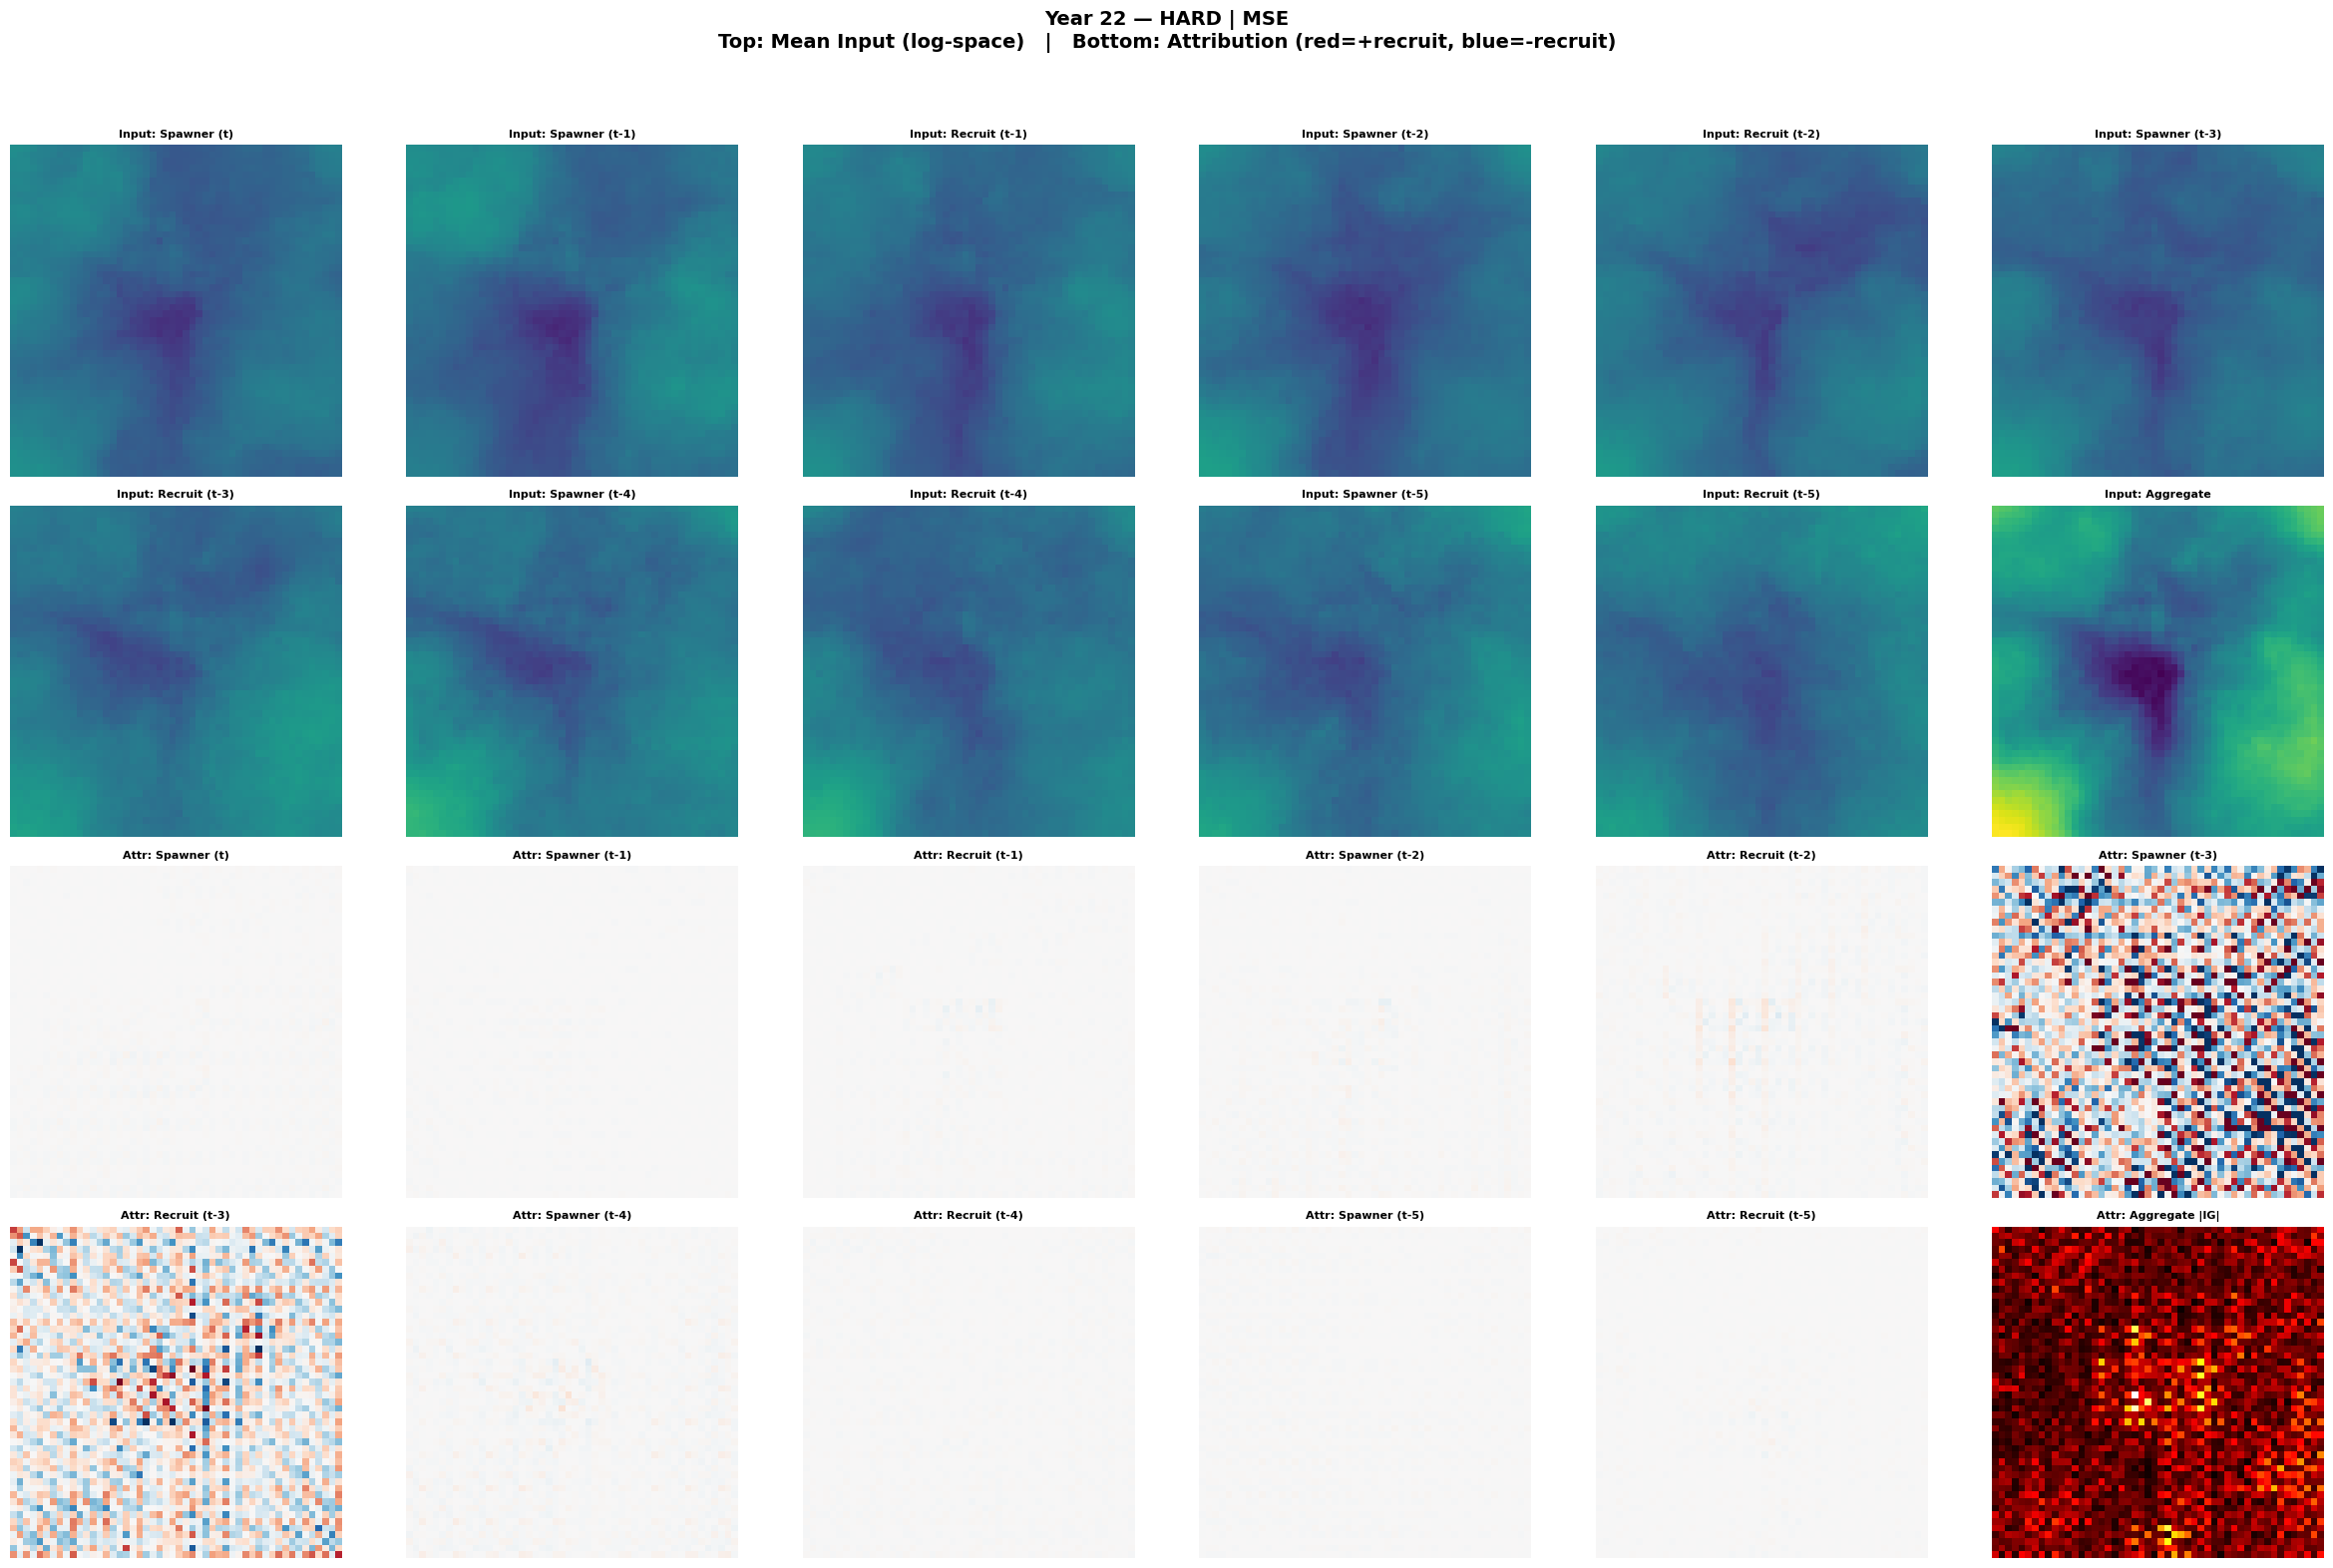

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year23_hard_MSE.png


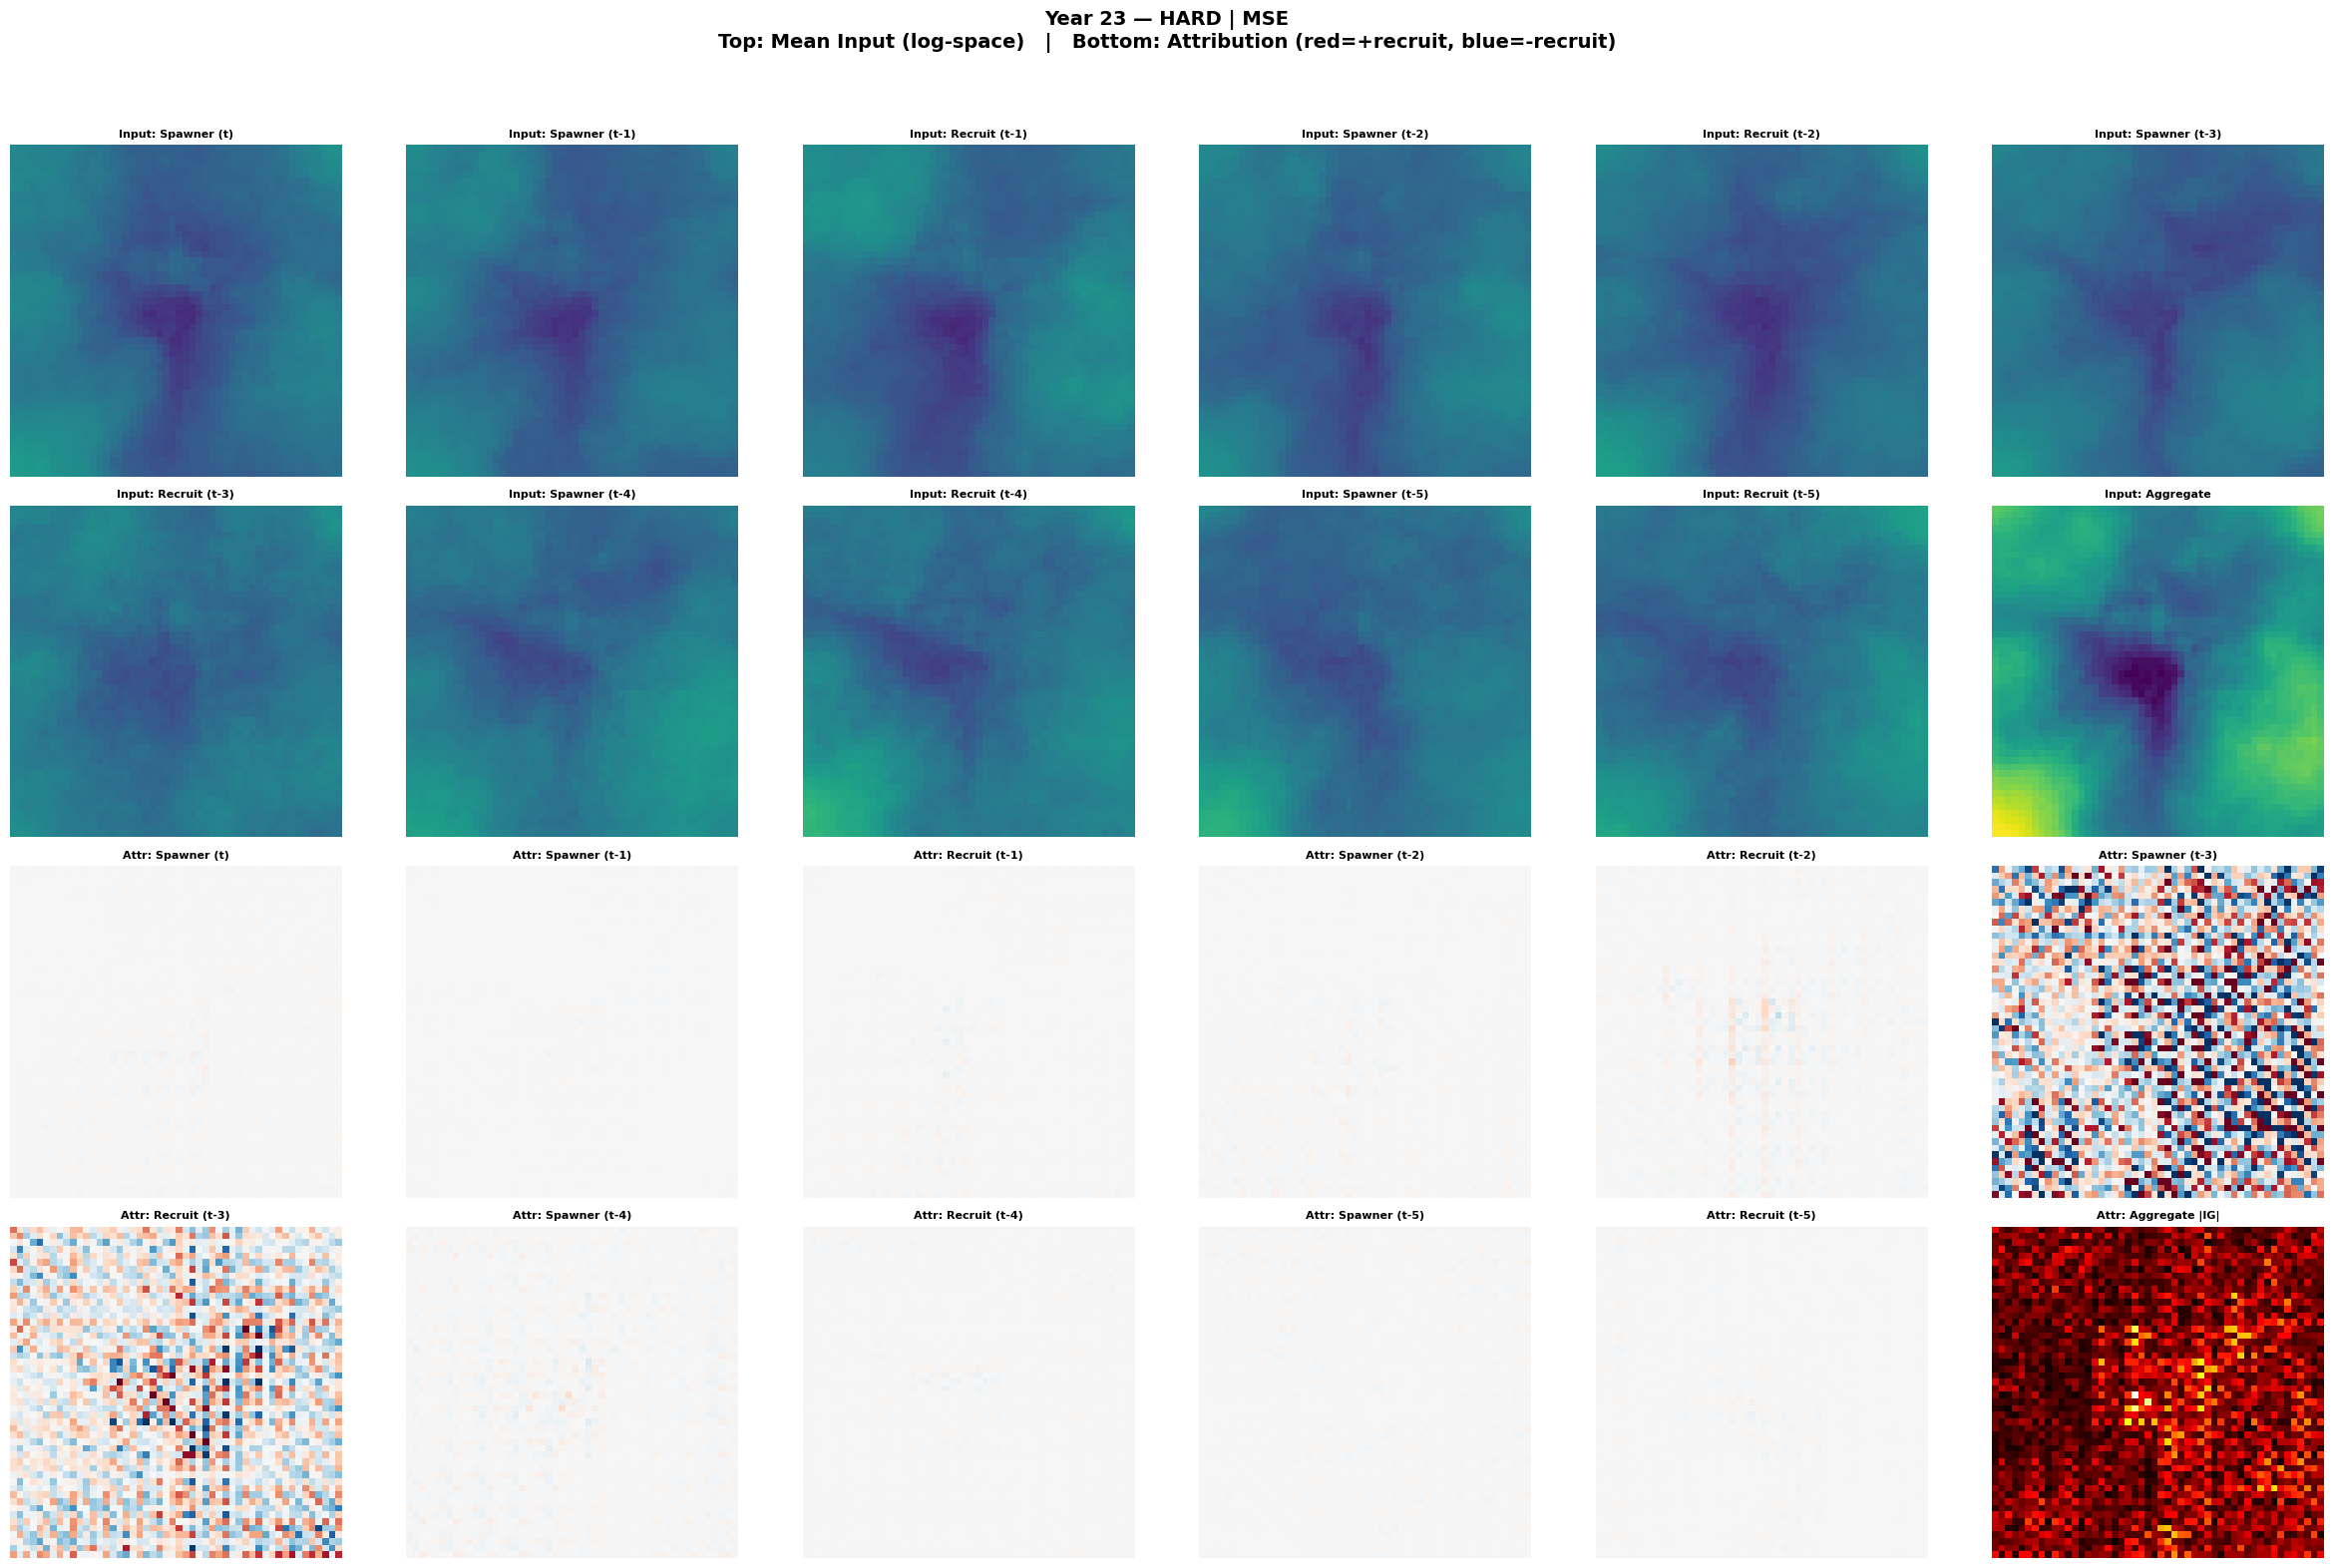

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year24_hard_MSE.png


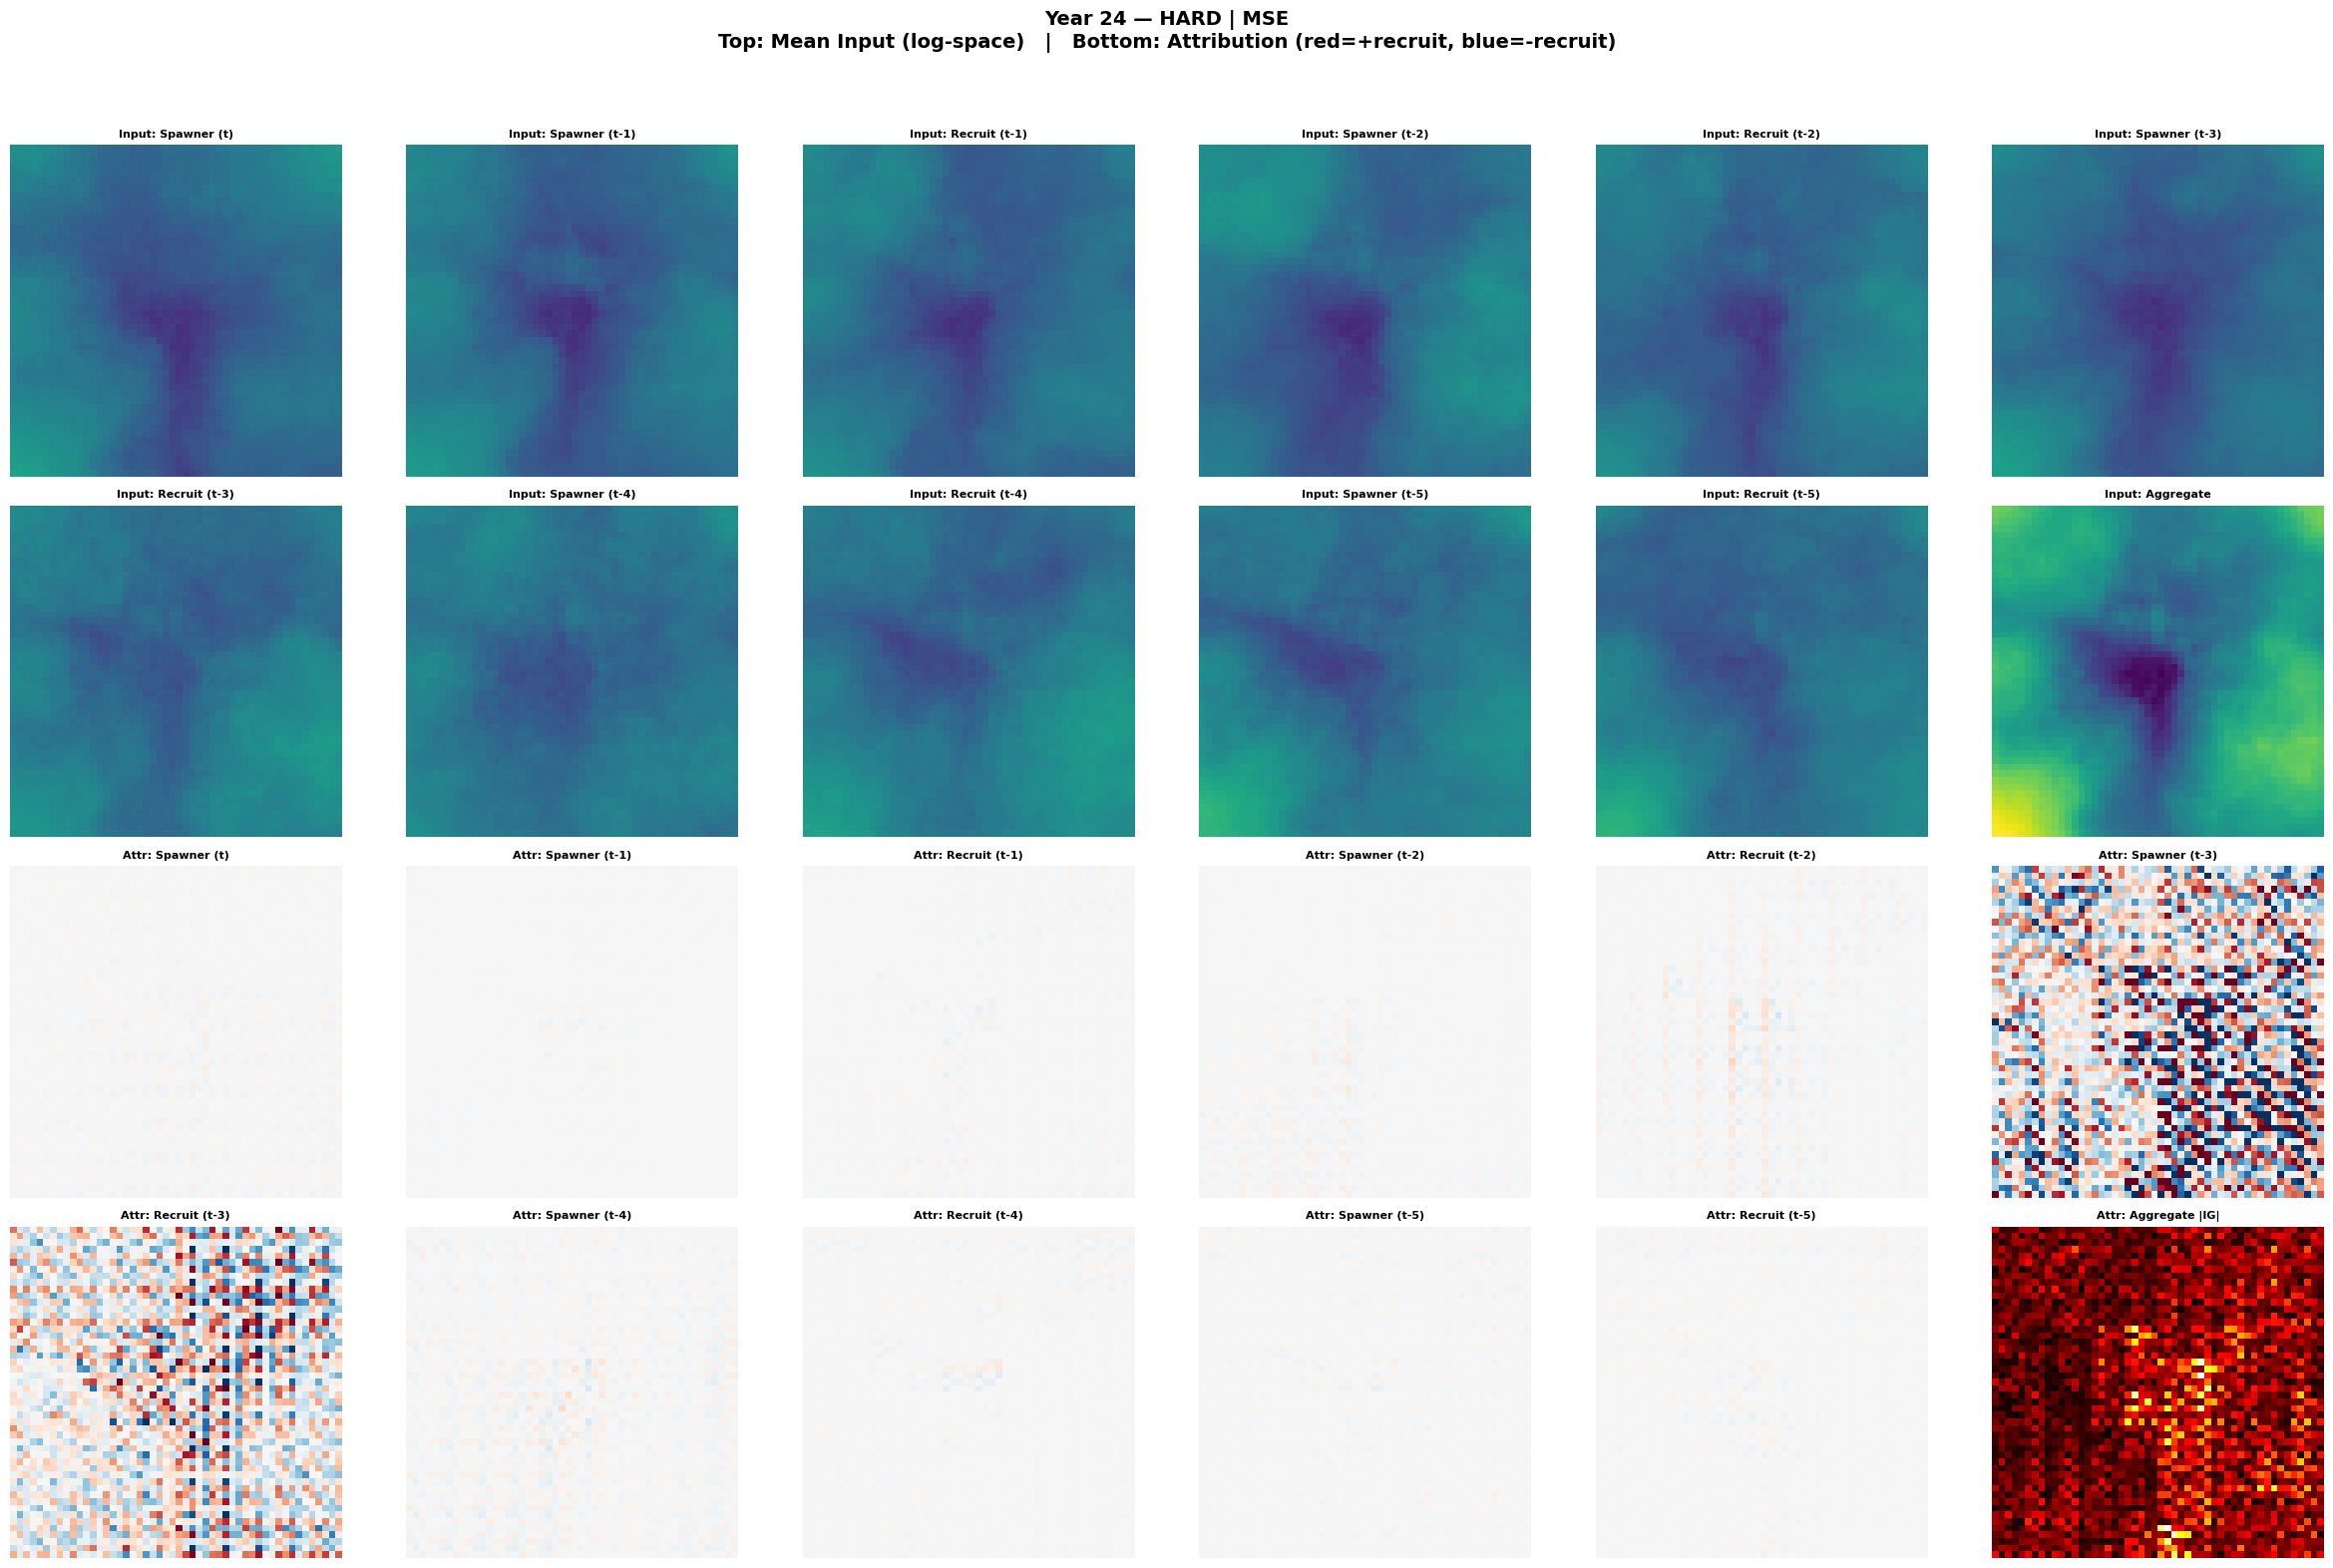

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year25_hard_MSE.png


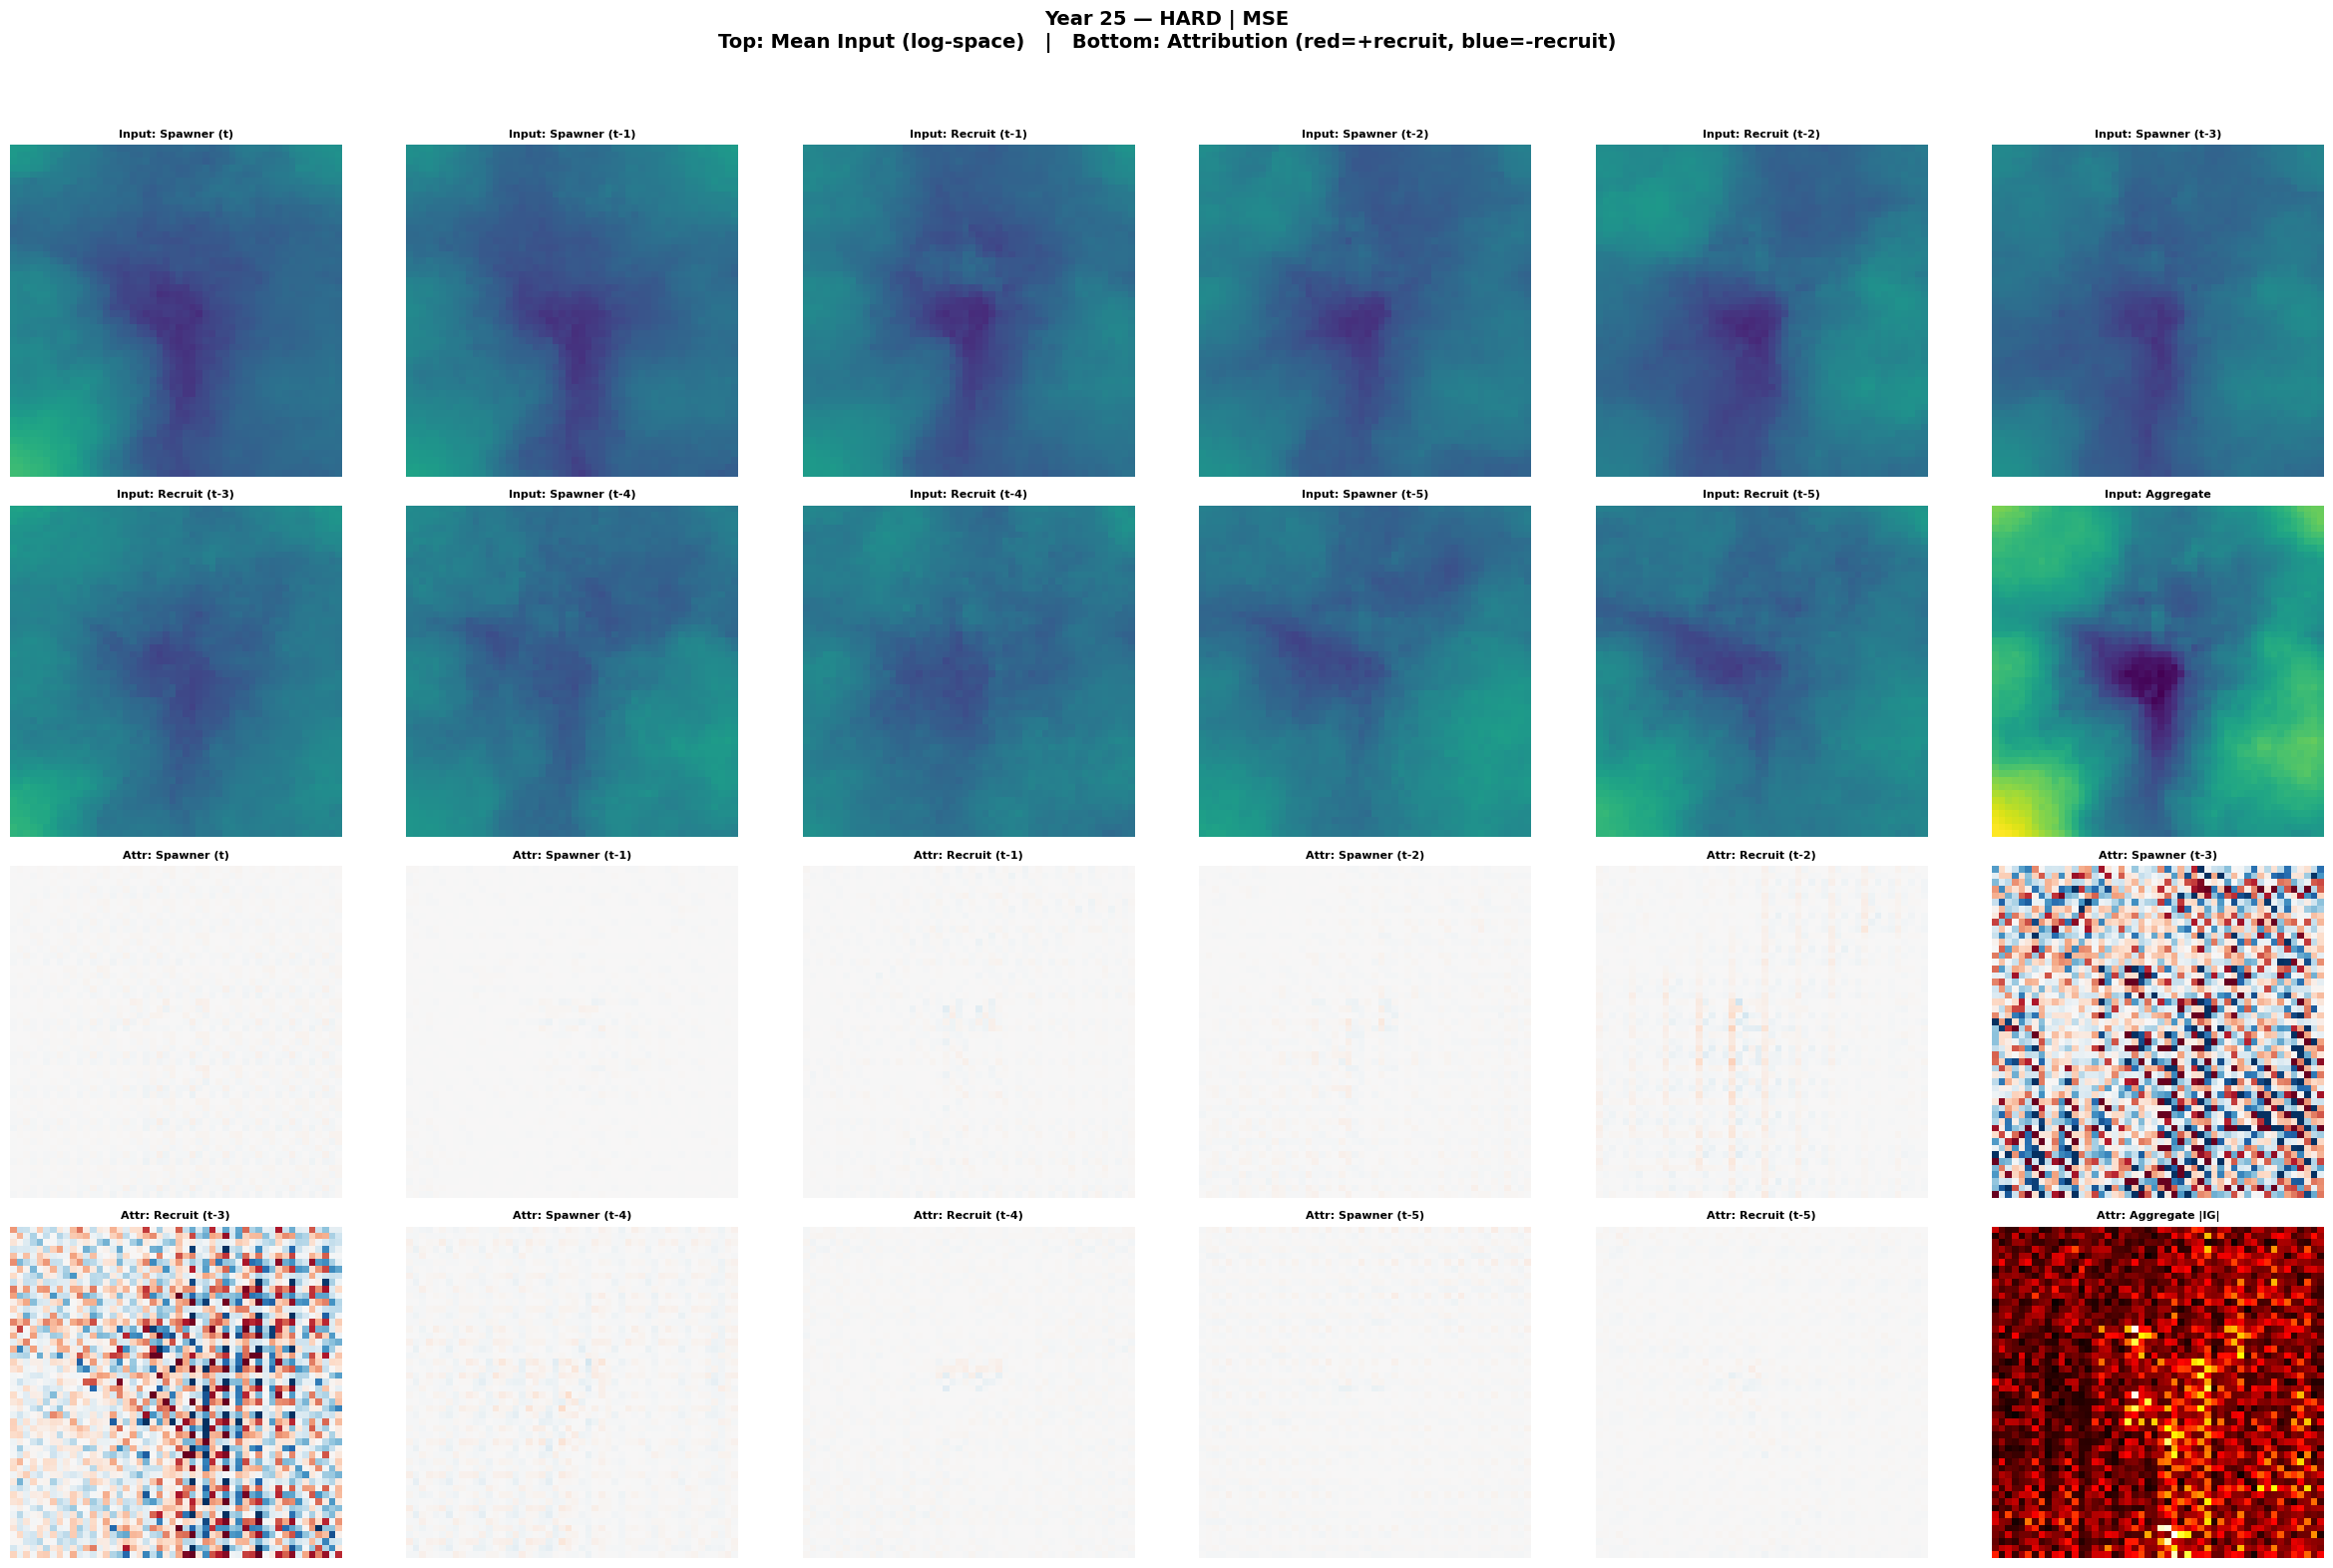

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_year26_hard_MSE.png


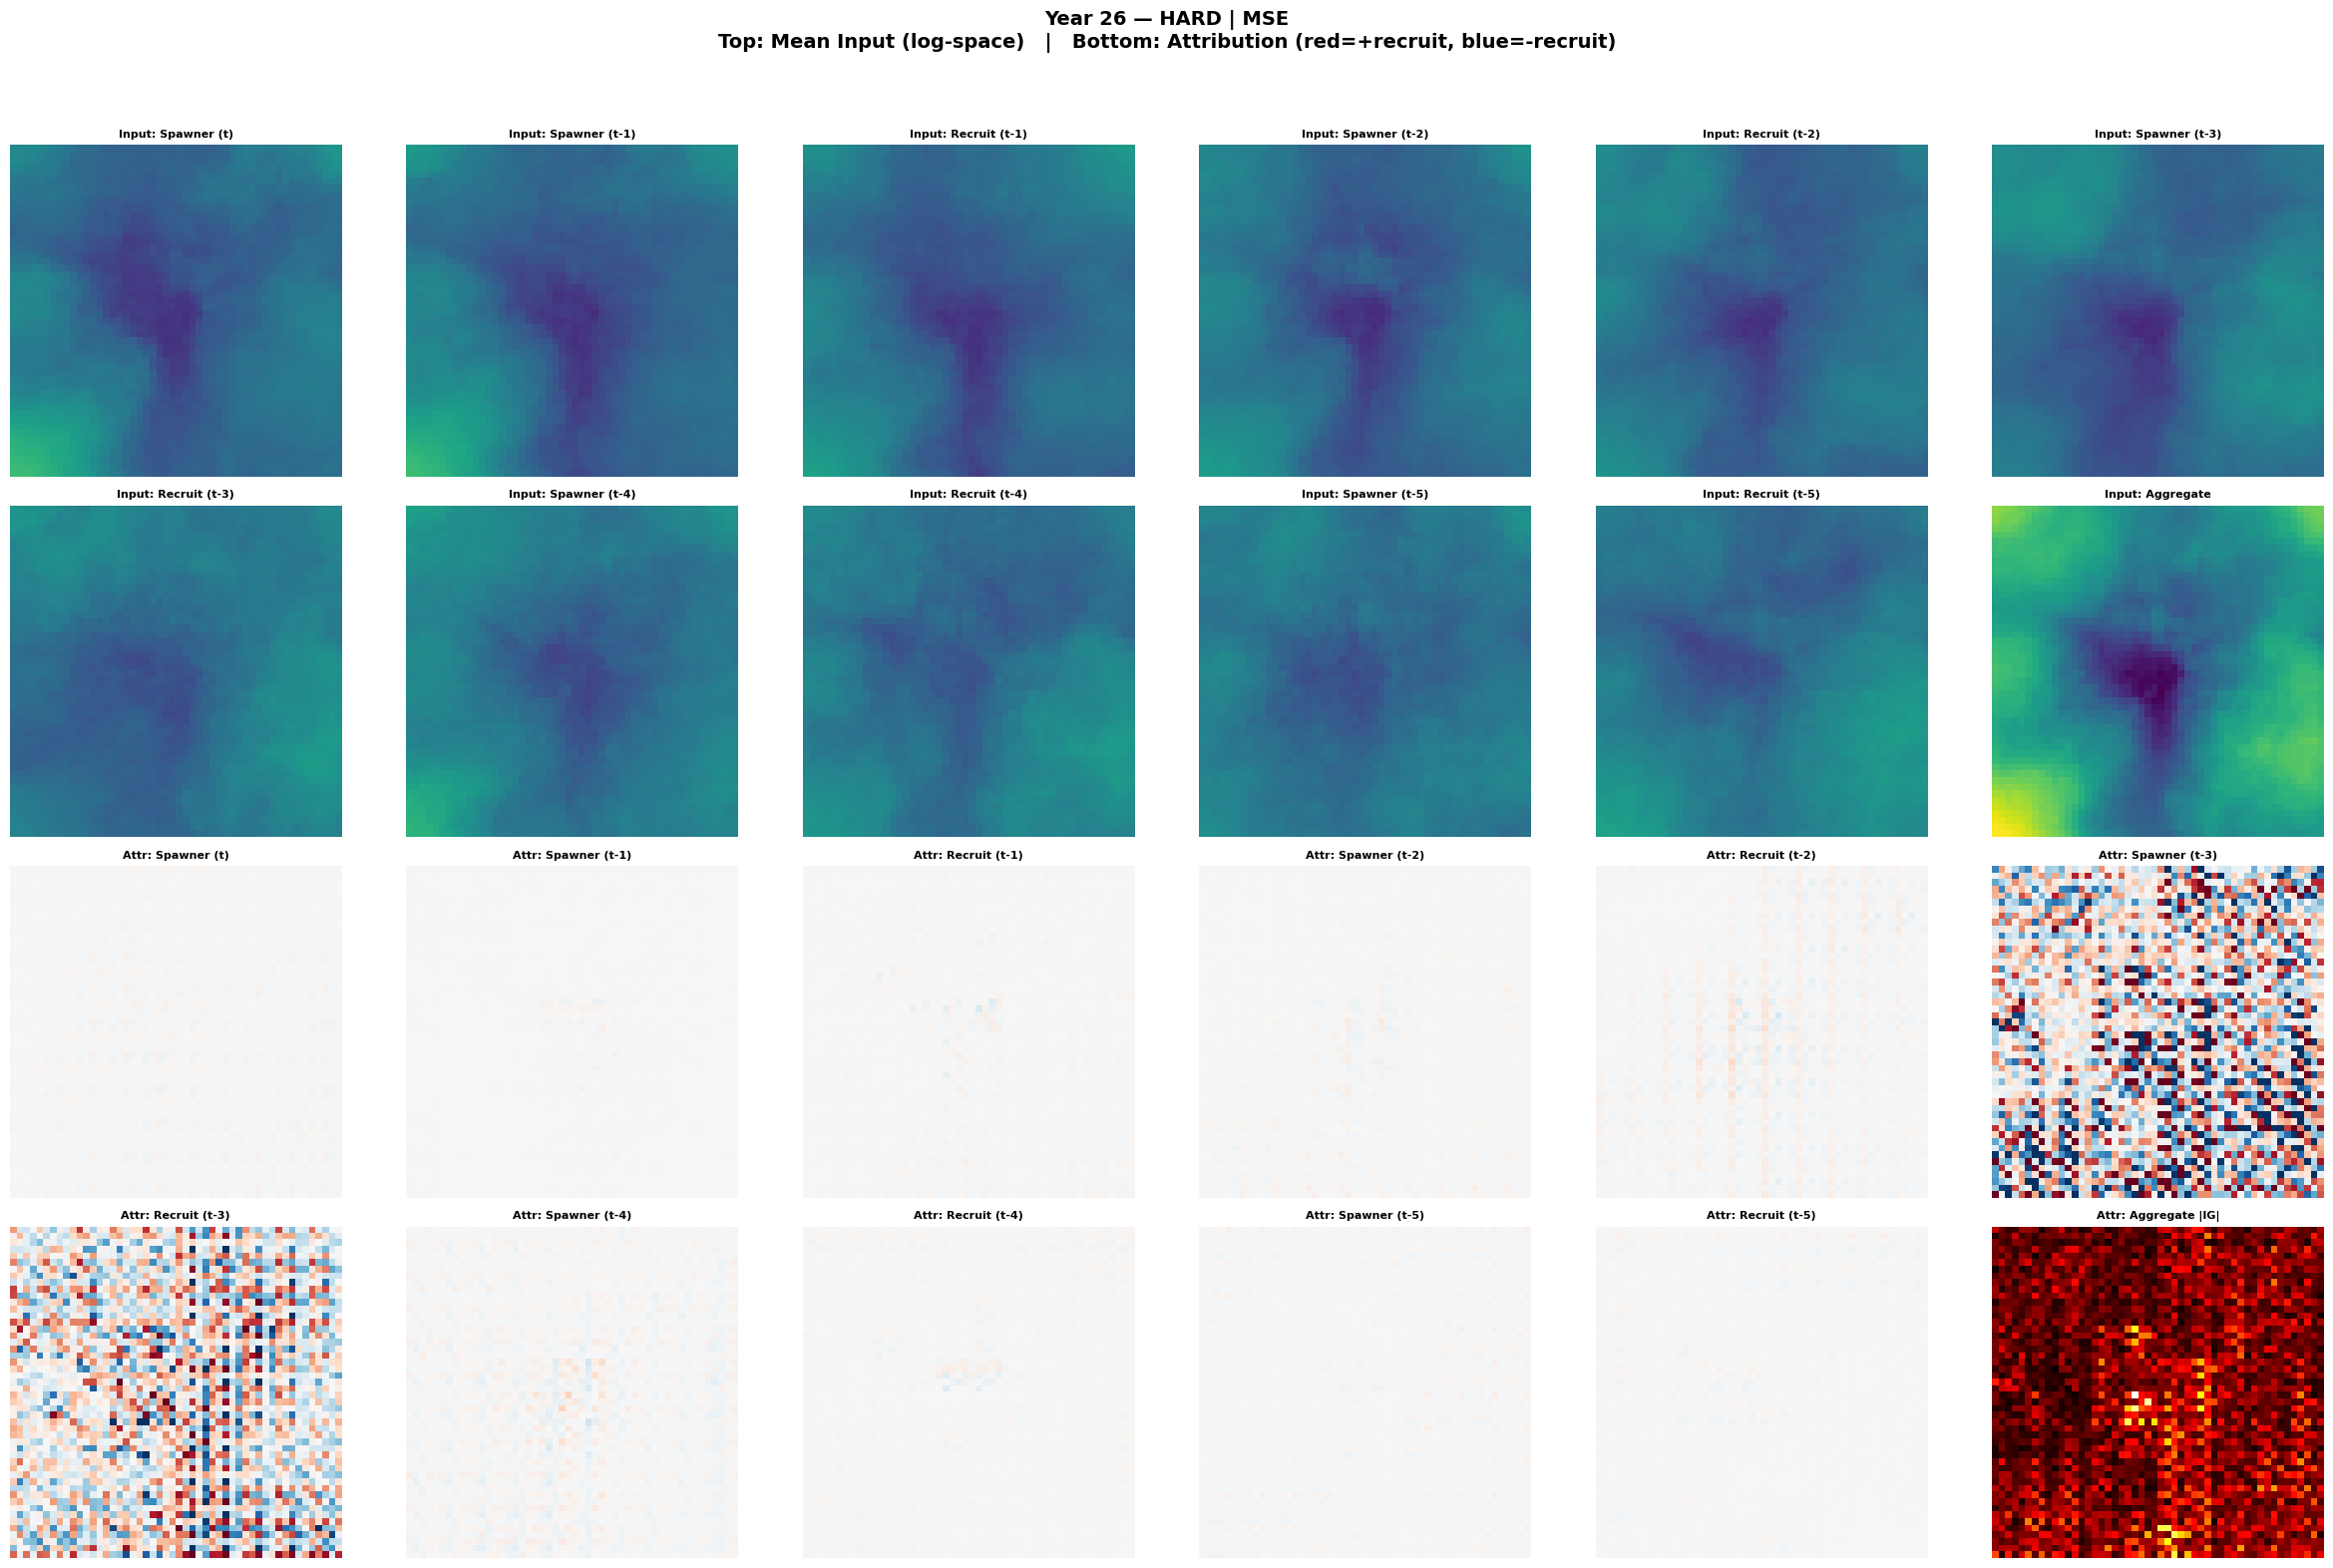


  Generating grand average...


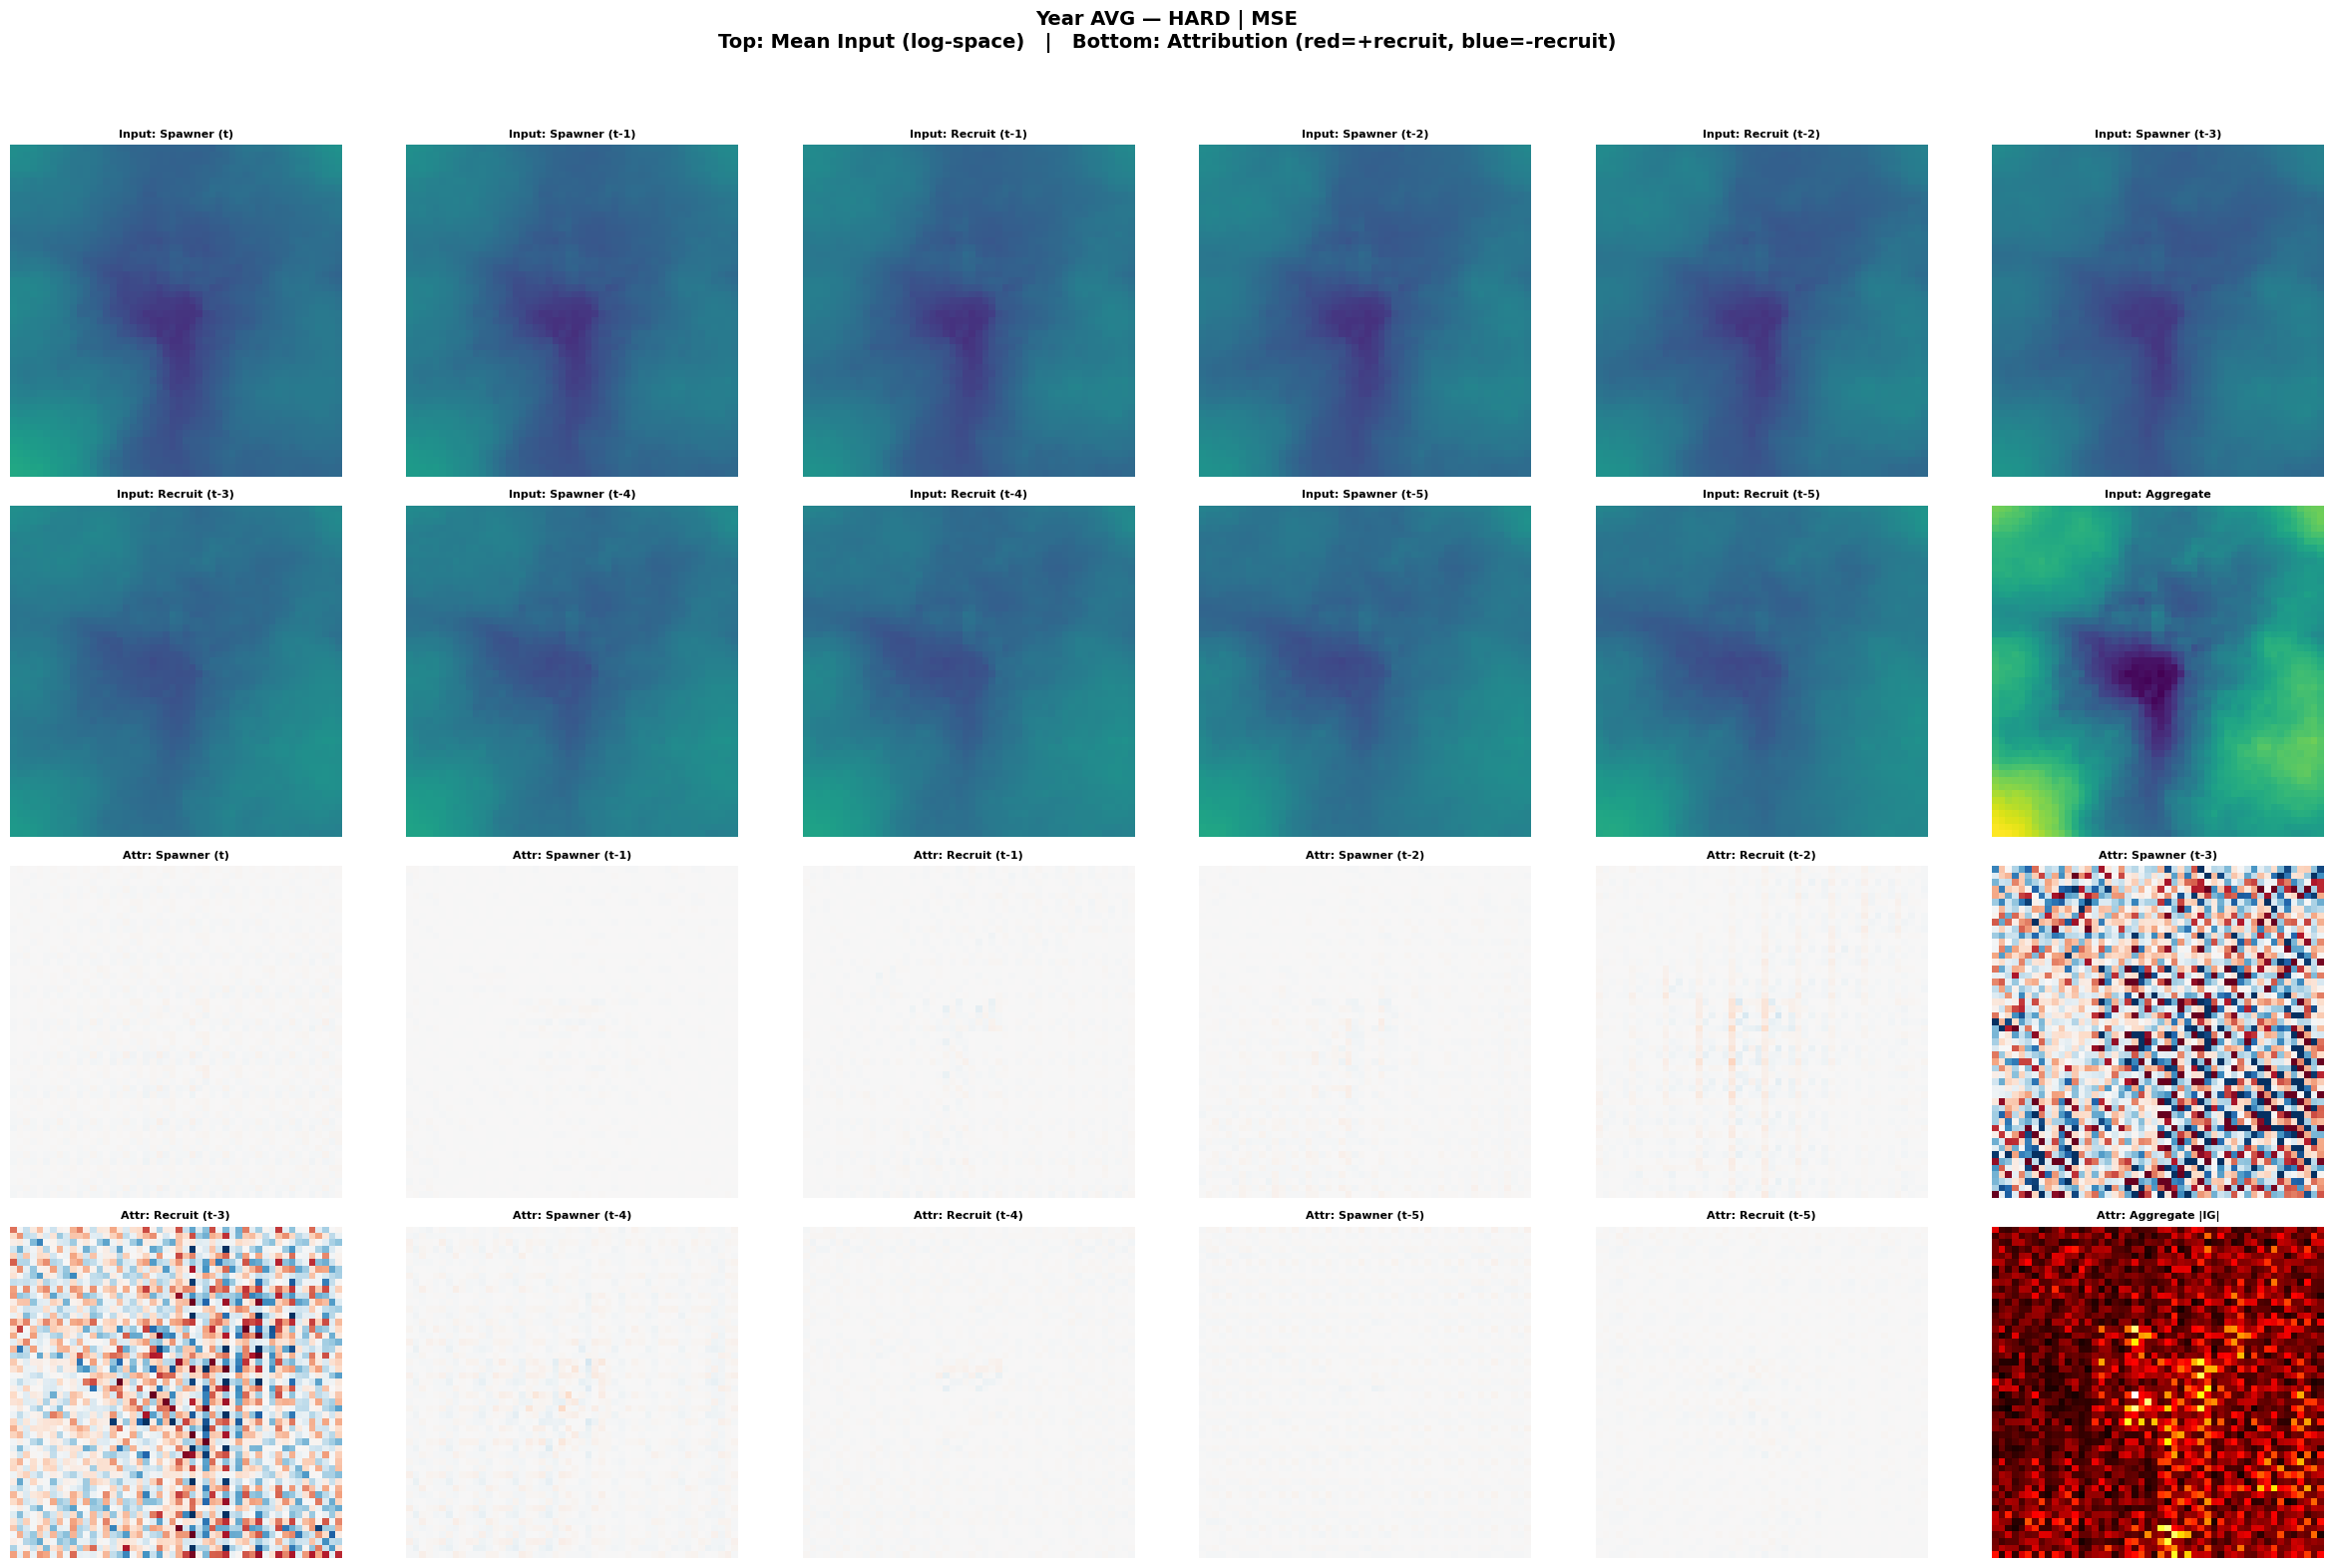

  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_grand_avg_hard_MSE.png

  Generating channel bar chart...
  Saved: /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution/ig_bar_yearly_hard_MSE.png


<Figure size 640x480 with 0 Axes>

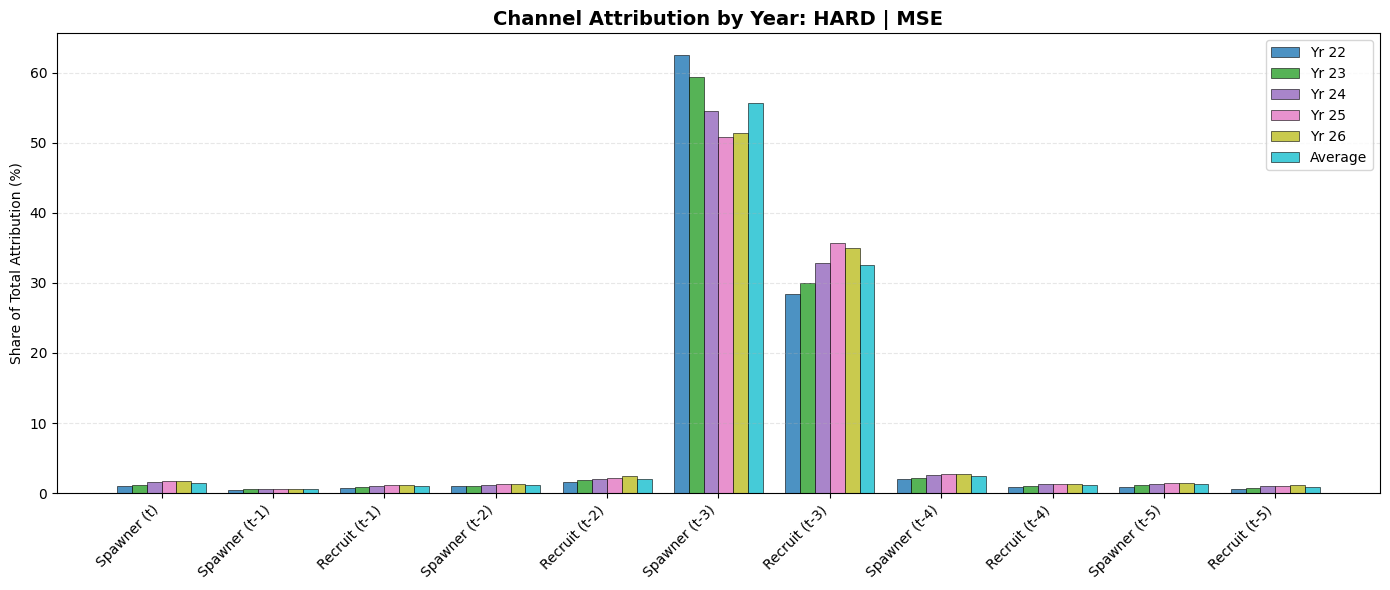

  Raw arrays saved to /content/drive/MyDrive/Teleconnection_ViT/analysis/attribution
Year 22: mean=2.8051, std=0.5489
Year 23: mean=2.7990, std=0.6202
Year 24: mean=2.7630, std=0.6376
Year 25: mean=2.7925, std=0.7685
Year 26: mean=2.8141, std=0.7264


In [ ]:
yearly_attr, yearly_inputs = run_integrated_gradients(
    level='hard', criterion='MSE'
)

# Check if years are actually different
for yr in sorted(yearly_inputs.keys()):
    ch0 = yearly_inputs[yr][0]  # spawner channel
    print(f'Year {yr}: mean={ch0.mean():.4f}, std={ch0.std():.4f}')

In [ ]:
single_boot = {}
count = 0
for inputs, targets, mask, yr in loader[1]:  # val loader
    y = int(yr.item())
    if count < 5:  # first 5 samples = bootstrap 0, all 5 years
        single_boot[y] = inputs[0, 0].numpy()
    else:
        break
    count += 1

for yr in sorted(single_boot.keys()):
    ch0 = single_boot[yr]
    print(f'Year {yr} (boot 0): mean={ch0.mean():.4f}, std={ch0.std():.4f}')

Year 22 (boot 0): mean=3.2458, std=3.5291
Year 23 (boot 0): mean=1.5671, std=2.6592
Year 24 (boot 0): mean=2.7640, std=3.0935
Year 25 (boot 0): mean=1.7672, std=2.6760
Year 26 (boot 0): mean=2.1722, std=2.9640


--- 1. Setup & Normalization ---
--- 2. Creating Full 30-Year Dataset ---
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sample input shape (train): torch.Size([11, 50, 50])
Sample target shape (train): torch.Size([1, 50, 50])
Mask shape (train): torch.Size([6])
Year index (train): 0
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓

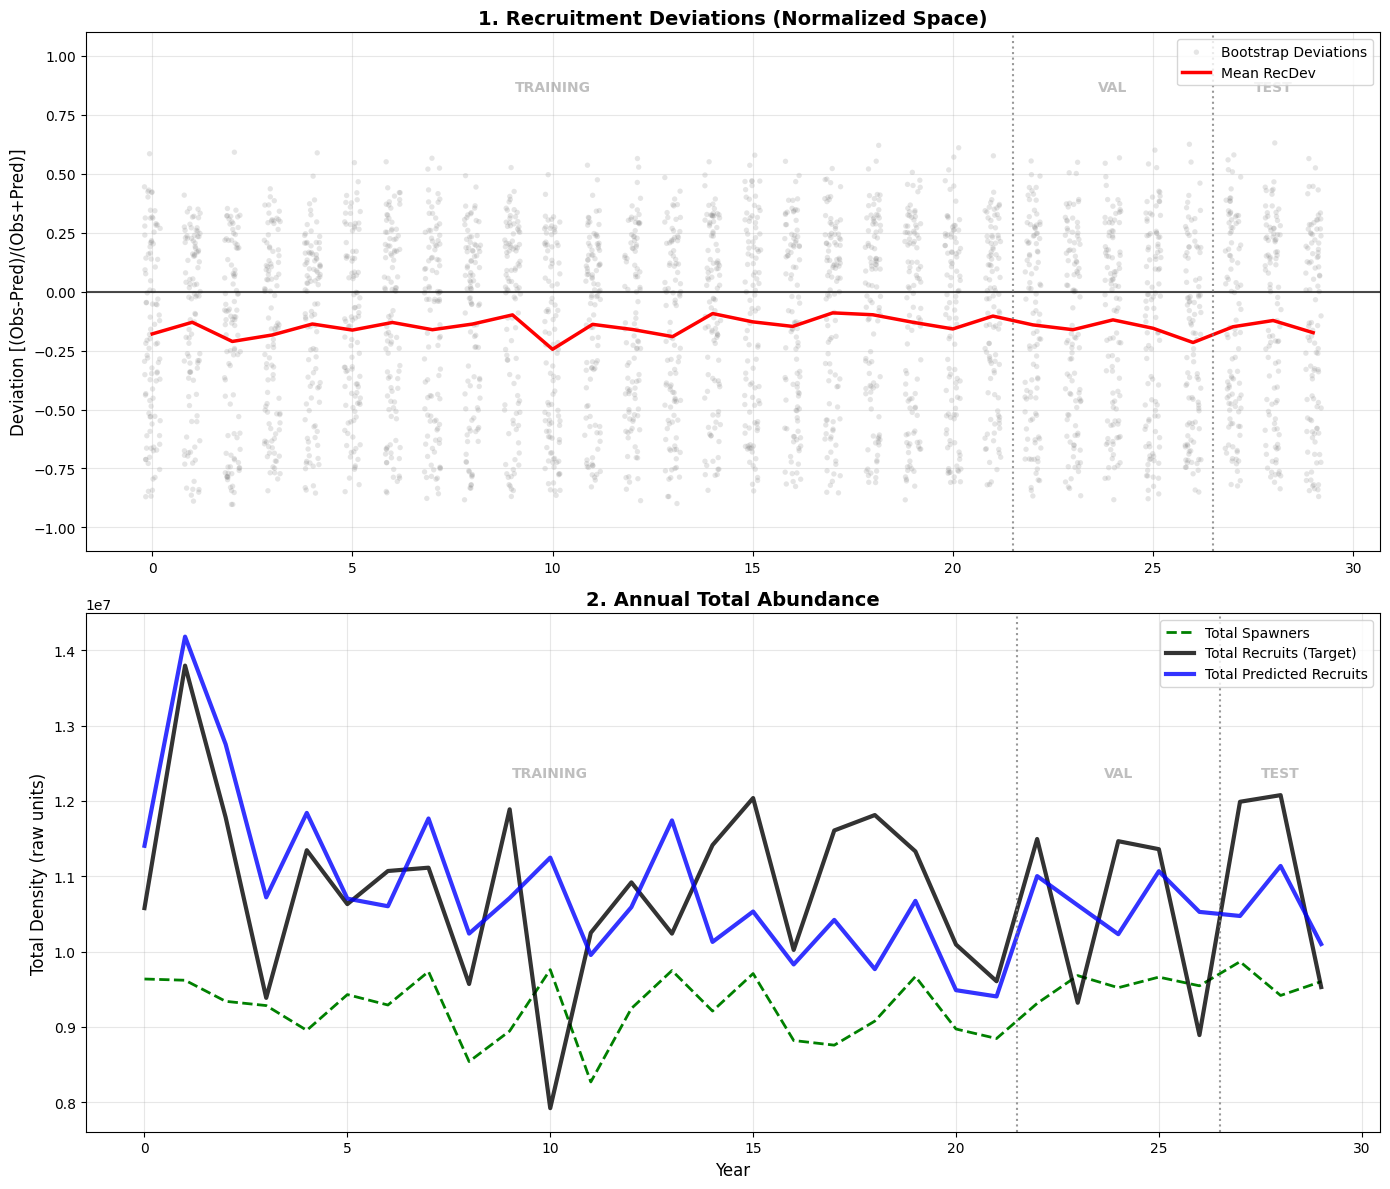

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import pandas as pd
from torch.utils.data import DataLoader
from models.model import CrabTransformer
from data.data_helper import CrabDataset, get_dataloaders

# --- CONFIGURATION ---
REPO_DIR = '/content/Teleconnections-ViT'
DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"
DATA_PATH = os.path.join(DRIVE_DIR, f"data/{level}")
RAW_DATA_PATH = os.path.join(REPO_DIR, "data/dummy/output")



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def analyze_full_history_abundance(level = "easy", loss_criterion = "Tweedie"):
    CHECKPOINT_PATH = os.path.join(DRIVE_DIR, f"checkpoints/best_model_{level}_{loss_criterion}.pt")

    print("--- 1. Setup & Normalization ---")
    # Load training data to get MAX constants for DENORMALIZATION
    train_spawners = np.load(os.path.join(DATA_PATH, f"train_spawners_{level}.npy"))
    train_recruits = np.load(os.path.join(DATA_PATH, f"train_recruits_{level}.npy"))


    print("--- 2. Creating Full 30-Year Dataset ---")
    # Load RAW data (100 bootstraps * 30 years)
    train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=8, memory_years=5,
    train_years=22, val_years=5, test_years=3,
    transform='log', level = level
    )

    # Override train loader to not shuffle for evaluation
    train_loader = DataLoader(train_loader.dataset, batch_size=12, shuffle=False)

    # Load the model
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0
    ).to(device)


    if os.path.exists(CHECKPOINT_PATH):
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        print("✓ Weights loaded.")
    else:
        print("⚠️ Checkpoint not found! Using random weights.")

    model.eval()

    scatter_years = []
    scatter_recdev = [] # Renamed from scatter_mae for clarity
    abundance_records = []

    print("--- 3. Running Inference ---")

    loaders = [
        ("TRAIN", train_loader, 0),
        ("VAL",   val_loader,   22),
        ("TEST",  test_loader,  27),
    ]

    for phase, loader, year_offset in loaders:
        with torch.no_grad():
            for inputs, targets, temporal_mask, year_indices in loader:
                inputs, targets = inputs.to(device), targets.to(device)
                temporal_mask = temporal_mask.to(device)
                year_indices = year_indices.to(device)

                outputs = model(inputs, year_indices, temporal_mask=temporal_mask)

                preds_np = outputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                inputs_np = inputs.cpu().numpy()
                years_np = year_indices.cpu().numpy()

                for i in range(preds_np.shape[0]):
                    year_absolute = years_np[i] + year_offset

                    # 1. Back-transform to real space
                    # We take the SUM (or MEAN) of the grid to get total abundance for that bootstrap
                    pred_total = np.sum(np.expm1(preds_np[i, 0]))
                    target_total = np.sum(np.expm1(targets_np[i, 0]))
                    input_total = np.sum(np.expm1(inputs_np[i, 0]))

                    # 2. Calculate Recruitment Deviation (-1 to 1)
                    # Based on total annual abundance per bootstrap
                    recdev = (target_total - pred_total) / (target_total + pred_total + 1e-6)

                    # Append SCALARS to the lists
                    scatter_years.append(year_absolute)
                    scatter_recdev.append(recdev)

                    abundance_records.append({
                        'year': year_absolute,
                        'phase': phase,
                        'rec_dev': recdev,
                        'total_spawner': input_total,
                        'total_recruit': target_total,
                        'total_pred': pred_total,
                    })

        print(f"  ✓ {phase} done")

    # --- 4. Generating Plots ---
    print("--- 4. Generating Plots ---")

    df = pd.DataFrame(abundance_records)
    df_annual = df.groupby('year').mean(numeric_only=True).reset_index()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Plot 1: RecDev Plot (Bounded -1 to 1)
    jitter = np.random.uniform(-0.2, 0.2, size=len(scatter_years))
    ax1.scatter(np.array(scatter_years) + jitter, scatter_recdev,
                alpha=0.2, s=15, c='gray', edgecolors='none', label='Bootstrap Deviations')

    unique_years = sorted(list(set(scatter_years)))
    avg_recdev = [np.mean([d for y, d in zip(scatter_years, scatter_recdev) if y==uy]) for uy in unique_years]

    ax1.plot(unique_years, avg_recdev, 'r-', linewidth=2.5, label='Mean RecDev')
    ax1.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7) # Zero line

    add_regions(ax1, recdev_mode=True)
    ax1.set_title("1. Recruitment Deviations (Normalized Space)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Deviation [(Obs-Pred)/(Obs+Pred)]", fontsize=12)
    ax1.set_ylim(-1.1, 1.1) # Strict bounds for recdev
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Abundance (Same as your previous request)
    ax2.plot(df_annual['year'], df_annual['total_spawner'], 'g--', linewidth=2, label='Total Spawners')
    ax2.plot(df_annual['year'], df_annual['total_recruit'], 'k-', linewidth=3, alpha=0.8, label='Total Recruits (Target)')
    ax2.plot(df_annual['year'], df_annual['total_pred'], 'b-', linewidth=3, alpha=0.8, label='Total Predicted Recruits')

    add_regions(ax2, recdev_mode=False)
    ax2.set_title("2. Annual Total Abundance", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Year", fontsize=12)
    ax2.set_ylabel("Total Density (raw units)", fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def add_regions(ax, recdev_mode=False):
    """Helper to draw Train/Val/Test regions"""
    # Use explicit limits to avoid text disappearing if ylim changes
    ymin, ymax = ax.get_ylim()
    text_y = ymax * 0.85 if not recdev_mode else 0.85

    ax.axvline(21.5, color='gray', linestyle=':', alpha=0.8)
    ax.axvline(26.5, color='gray', linestyle=':', alpha=0.8)

    # Labels
    ax.text(10, text_y, "TRAINING", ha='center', color='gray', fontweight='bold', alpha=0.5)
    ax.text(24, text_y, "VAL", ha='center', color='gray', fontweight='bold', alpha=0.5)
    ax.text(28, text_y, "TEST", ha='center', color='gray', fontweight='bold', alpha=0.5)

if __name__ == "__main__":
    analyze_full_history_abundance(level = "easy", loss_criterion = "Tweedie")

--- Building datasets with proper historical context ---
Detected 100 bootstrap samples
Loaded 100 bootstrap samples, 22 years each
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from training data for validation...
Loaded 100 bootstrap samples, 5 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Extracting historical context from validation data for test...
Loaded 100 bootstrap samples, 3 years each
  Using 5 years of historical data from previous split
Applying Log-Scaling: x_scaled = log(1 + x)

Data shapes:
(100, 5, 50, 50) (100, 5, 50, 50)
(100, 5, 50, 50) (100, 5, 50, 50) 

Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Applying Bias Initialization Surgery to Decoder (-1.0)
✓ Weight initialization complete
✓ Checkpoint loaded
--- Running inference ---
  ✓ TRAIN: 2200 samples
  ✓ VAL: 500 samples
 

/tmp/ipython-input-3523084644.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 0.92, 0.97])


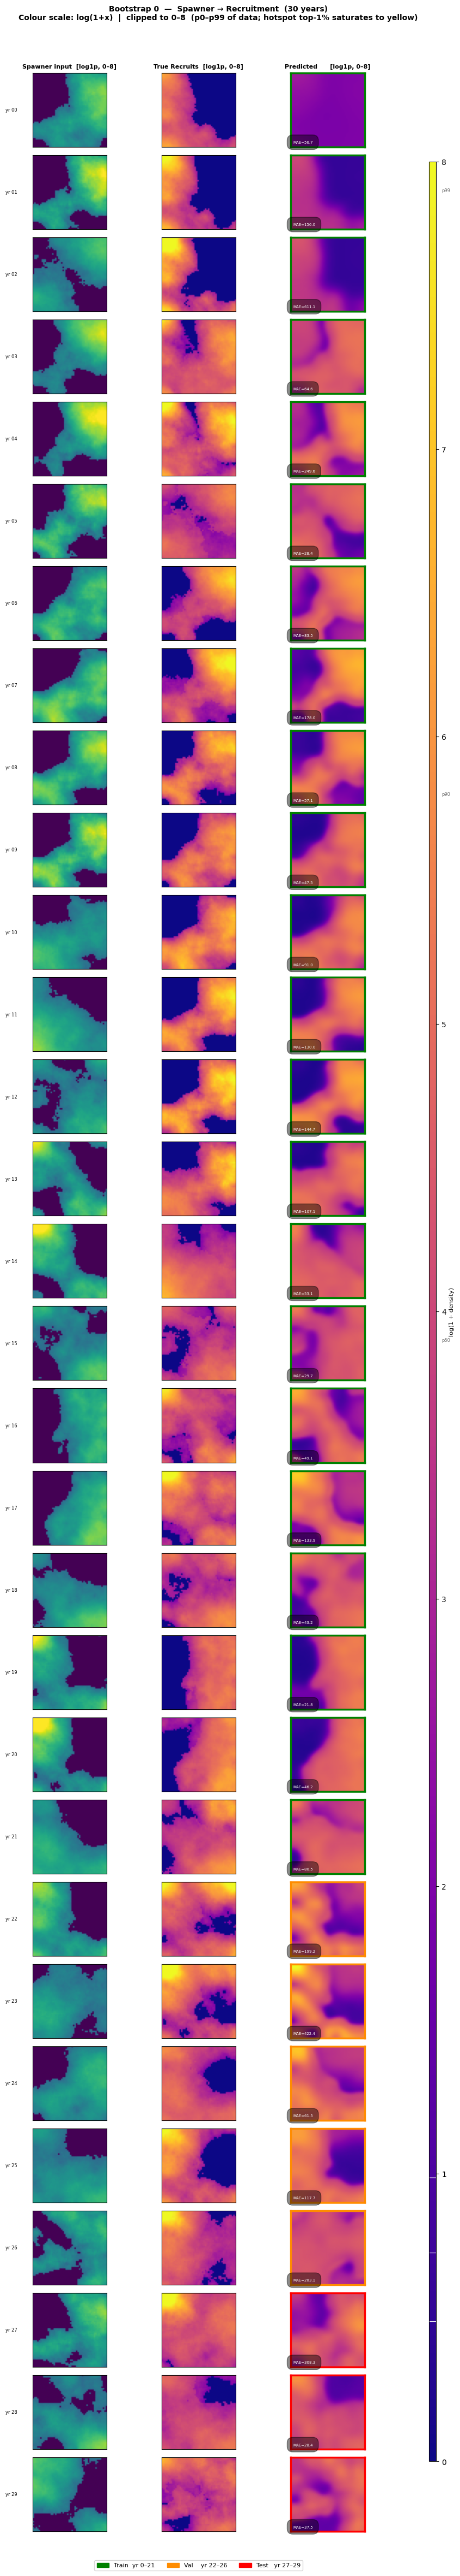

✓  Saved → /content/drive/MyDrive/Teleconnection_ViT/analysis/final_evaluation/spatial_trajectory_boot0.png


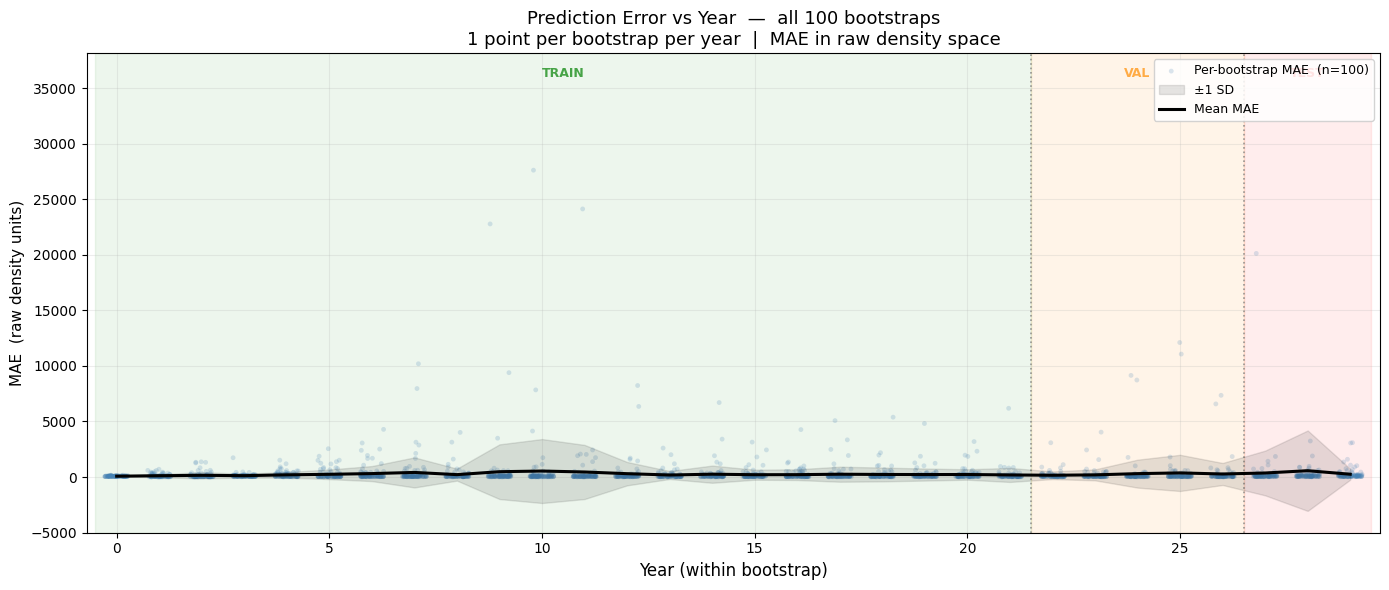

✓  Saved → /content/drive/MyDrive/Teleconnection_ViT/analysis/final_evaluation/error_scatter.png

Year summary (MAE in raw density space):
 Year  Phase      Mean MAE          SD
    0  TRAIN         76.04       29.49
    1  TRAIN        118.96      142.92
    2  TRAIN        154.88      278.07
    3  TRAIN        124.06      180.85
    4  TRAIN        198.20      246.58
    5  TRAIN        246.67      434.04
    6  TRAIN        311.49      677.32
    7  TRAIN        415.16     1353.04
    8  TRAIN        217.68      539.89
    9  TRAIN        480.96     2461.63
   10  TRAIN        540.39     2878.64
   11  TRAIN        455.34     2435.73
   12  TRAIN        303.34     1052.13
   13  TRAIN        182.44      358.84
   14  TRAIN        256.80      774.70
   15  TRAIN        209.34      452.31
   16  TRAIN        214.69      483.26
   17  TRAIN        254.21      675.73
   18  TRAIN        232.11      620.78
   19  TRAIN        224.16      542.51
   20  TRAIN        229.04      469.43
   

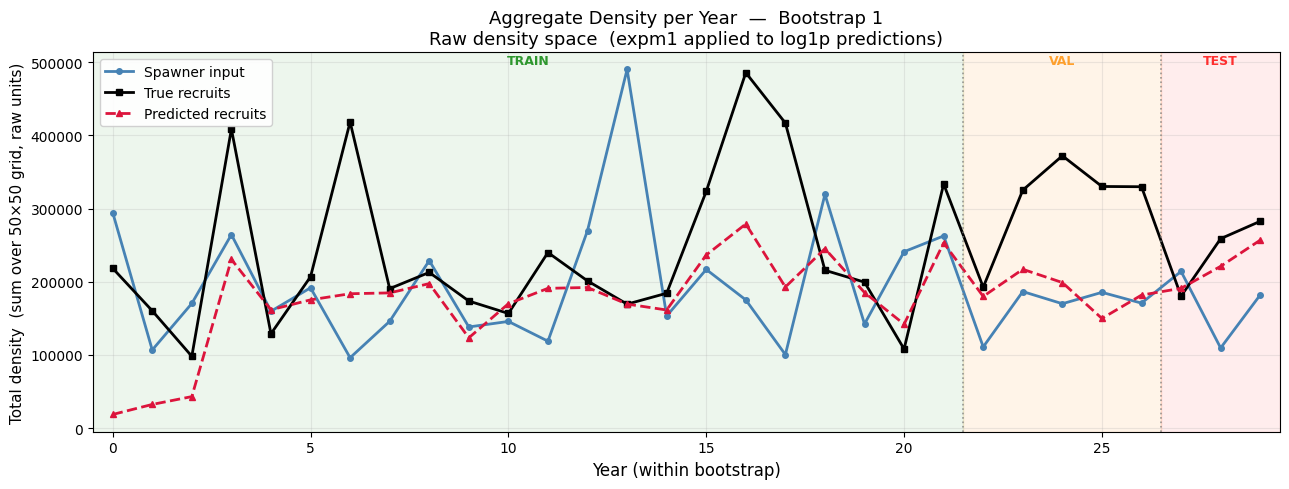

✓  Saved → /content/drive/MyDrive/Teleconnection_ViT/analysis/final_evaluation/aggregate_timeseries_boot1.png

Aggregate density summary — Bootstrap 1:
 Year  Phase         Spawner        True Rec        Pred Rec
    0  TRAIN        294628.2        218451.1         18772.8
    1  TRAIN        106870.7        160373.6         32475.3
    2  TRAIN        170407.4         98210.0         43177.6
    3  TRAIN        264412.8        408689.2        230574.7
    4  TRAIN        159778.3        129044.5        161767.9
    5  TRAIN        191793.7        206862.9        175340.3
    6  TRAIN         96254.0        418277.0        183681.5
    7  TRAIN        146000.8        190640.2        184835.8
    8  TRAIN        228925.2        212822.0        197501.1
    9  TRAIN        138292.9        173722.8        123466.3
   10  TRAIN        145858.6        156733.7        170012.6
   11  TRAIN        118884.5        239975.2        191058.9
   12  TRAIN        269942.9        201198.4        192

In [ ]:
"""
evaluate_spatial_trajectory.py  (updated colormap)
----------------------------------------------------
Key change from previous version:
  • Plots are shown in log1p space  (NOT inverted back to raw)
  • Fixed colour limits:
      recruits/predictions : vmin=0, vmax=8.0   (covers p0–p99 in log space)
      spawners             : vmin=0, vmax=8.0
  • This stops the rare extreme hotspot cells (max ~15.6) from collapsing
    the rest of the colormap to a nearly-uniform dark band.

Transform assumption: log(1 + x) — NO max-scaling.
"""

import os
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader
from scipy.stats import spearmanr
from models.model import CrabTransformer
from data.data_helper import CrabDataset

# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------
REPO_DIR        = "/content/Teleconnections-ViT"
DRIVE_DIR       = "/content/drive/MyDrive/Teleconnection_ViT"
DATA_PATH       = os.path.join(DRIVE_DIR, f"data/{level}")
RAW_DATA_PATH   = os.path.join(REPO_DIR, "data/dummy/output")
CHECKPOINT_PATH = os.path.join(DRIVE_DIR, f"checkpoints/best_model_{level}_{loss_criterion}.pt")
SAVE_DIR        = os.path.join(DRIVE_DIR, "analysis/final_evaluation")
os.makedirs(SAVE_DIR, exist_ok=True)

N_YEARS   = 30
N_HIST    = 5
TRAIN_END = 22
VAL_END   = 27

# ---  Colour limits in log1p space  ---
# From diagnostics:
#   p50  recruits log1p ≈ 3.9   p90 ≈ 5.8   p99 ≈ 7.9   max ≈ 15.5
# Setting vmax=8 shows 99% of cells with full colour range.
# The top 1% of extreme hotspot cells saturates to yellow — intentional.
VMAX_RC = 8.0    # recruits + predictions
VMAX_SP = 8.0    # spawner input (same scale for easy comparison)
VMIN    = 0.0    # zero cells map to black in plasma/viridis

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------

def phase_of(year):
    if year < TRAIN_END:
        return "TRAIN", "green"
    elif year < VAL_END:
        return "VAL", "darkorange"
    else:
        return "TEST", "red"


def add_phase_regions(ax):
    ax.axvline(TRAIN_END - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    ax.axvline(VAL_END   - 0.5, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    trans = ax.get_xaxis_transform()
    ax.text(TRAIN_END / 2 - 0.5,              0.95, "TRAIN", transform=trans,
            ha="center", fontsize=9, color="green",      fontweight="bold", alpha=0.7)
    ax.text((TRAIN_END + VAL_END) / 2 - 0.5,  0.95, "VAL",   transform=trans,
            ha="center", fontsize=9, color="darkorange", fontweight="bold", alpha=0.7)
    ax.text((VAL_END + N_YEARS) / 2 - 0.5,    0.95, "TEST",  transform=trans,
            ha="center", fontsize=9, color="red",         fontweight="bold", alpha=0.7)


# ---------------------------------------------------------------------------
# LOAD MODEL + RUN INFERENCE
# ---------------------------------------------------------------------------

def load_model(level = "easy", loss_criterion="Tweedie"):
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=11,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.0,
    ).to(device)
    if os.path.exists(CHECKPOINT_PATH):
        ckpt  = torch.load(os.path.join(DRIVE_DIR, f"checkpoints/best_model_{level}_{loss_criterion}.pt"), map_location=device)
        state = ckpt.get("model_state_dict", ckpt)
        model.load_state_dict(state)
        print("✓ Checkpoint loaded")
    else:
        print("⚠️  No checkpoint found — using random weights")
    model.eval()
    return model


def run_inference(level = level, loss_criterion = "Tweedie"):
    print("--- Building datasets with proper historical context ---")
    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=8, memory_years=5,
        train_years=22, val_years=5, test_years=3,
        transform='log', level = level
    )
    train_loader = DataLoader(train_loader.dataset, batch_size=12, shuffle=False)
    model = load_model()

    records = []

    loaders = [
        ("TRAIN", train_loader, 0),
        ("VAL",   val_loader,   22),
        ("TEST",  test_loader,  27),
    ]

    if loss_criterion == "Tweedie":
      targets = torch.expm1(targets).clamp(min=1e-6)

    print("--- Running inference ---")
    with torch.no_grad():
        for phase, loader, year_offset in loaders:
            sample_count = 0
            for inputs, targets, temporal_mask, year_indices in loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                temporal_mask = temporal_mask.to(device)
                year_indices = year_indices.to(device)

                outputs = model(inputs, year_indices, temporal_mask = temporal_mask)
                if loss_criterion == 'Tweedie':
                  outputs = torch.expm1(outputs)

                preds_np   = outputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                inputs_np  = inputs.cpu().numpy()
                years_np   = year_indices.cpu().numpy()

                for i in range(preds_np.shape[0]):
                    year_absolute = int(years_np[i]) + year_offset
                    bootstrap = sample_count // loader.dataset.n_years
                    sample_count += 1

                    pred_log    = preds_np[i, 0]   if preds_np.ndim   == 4 else preds_np[i]
                    target_log  = targets_np[i, 0] if targets_np.ndim == 4 else targets_np[i]
                    spawner_log = inputs_np[i, 0]  if inputs_np.ndim  == 4 else inputs_np[i]


                    if loss_criterion == "MSE":
                      pred_raw = np.expm1(pred_log)
                      target_raw = np.expm1(target_log)
                      spawner_raw = np.expm1(spawner_log)
                    elif loss_criterion == "L1":
                      pred_raw = np.expm1(pred_log)
                      target_raw = np.expm1(target_log)
                      spawner_raw = np.expm1(spawner_log)
                    elif loss_criterion == "Tweedie":
                      pred_raw = pred_log
                      target_raw = target_log
                      spawner_raw = spawner_log





                    # Flatten the 50x50 grids to 1D arrays for correlation
                    p_flat = pred_raw.flatten()
                    t_flat = target_raw.flatten()

                    # Calculate Spearman Correlation
                    # We use a small handle for cases with zero variance (rare but possible)
                    corr, _ = spearmanr(p_flat, t_flat)
                    if np.isnan(corr): corr = 0.0

                    records.append({
                        "bootstrap":   bootstrap,
                        "year":        year_absolute,
                        "phase":       phase,
                        "pred":    pred_raw,
                        "target":  target_raw,
                        "spawner": spawner_raw,
                        "mae_raw":     float(np.mean(np.abs(pred_raw - target_raw))),
                        "spearman":    float(corr),
                        "level": level,
                        "loss_criterion": loss_criterion
                    })

            print(f"  ✓ {phase}: {sample_count} samples")

    print(f"✓  {len(records)} total records")
    return records


# ---------------------------------------------------------------------------
# PLOT 1: SPATIAL TRAJECTORY  (one bootstrap, all 30 years)
# ---------------------------------------------------------------------------

def plot_spatial_trajectory(records, bootstrap_idx=0):
    """
    30 rows × 3 columns, all in log1p space with fixed colour limits.
    Border colour = green/orange/red for train/val/test.
    Per-cell MAE annotated on each prediction panel.
    """
    boot_rows = sorted(
        [r for r in records if r["bootstrap"] == bootstrap_idx],
        key=lambda r: r["year"],
    )
    if not boot_rows:
        print(f"Bootstrap {bootstrap_idx} not found.")
        return

    n_rows = len(boot_rows)
    fig, axes = plt.subplots(n_rows, 3, figsize=(9, n_rows * 1.6))
    fig.suptitle(
        f"Bootstrap {bootstrap_idx}  —  Spawner → Recruitment  ({n_rows} years)\n"
        f"Colour scale: log(1+x)  |  clipped to 0–{VMAX_RC:.0f}  "
        f"(p0–p99 of data; hotspot top-1% saturates to yellow)",
        fontsize=10, fontweight="bold",
    )

    col_titles = [
        f"Spawner input  [log1p, 0–{VMAX_SP:.0f}]",
        f"True Recruits  [log1p, 0–{VMAX_RC:.0f}]",
        f"Predicted      [log1p, 0–{VMAX_RC:.0f}]",
    ]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=8, fontweight="bold")

    for row_idx, r in enumerate(boot_rows):
        _, border_color = phase_of(r["year"])

        # col 0 — spawner
        axes[row_idx, 0].imshow(
            r["spawner_log"], cmap="viridis",
            vmin=VMIN, vmax=VMAX_SP, origin="lower", aspect="equal",
        )
        axes[row_idx, 0].set_ylabel(
            f"yr {r['year']:02d}",
            fontsize=6, rotation=0, labelpad=28, va="center",
        )

        # col 1 — true recruits
        axes[row_idx, 1].imshow(
            r["target_raw"], cmap="plasma",
            vmin=VMIN, vmax=VMAX_RC, origin="lower", aspect="equal",
        )

        # col 2 — prediction + coloured border + MAE label
        im = axes[row_idx, 2].imshow(
            r["pred_raw"], cmap="plasma",
            vmin=VMIN, vmax=VMAX_RC, origin="lower", aspect="equal",
        )
        for spine in axes[row_idx, 2].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.5)
            spine.set_visible(True)

        axes[row_idx, 2].text(
            0.03, 0.04, f"MAE={r['mae_raw']:.1f}",
            transform=axes[row_idx, 2].transAxes,
            fontsize=5, color="white", va="bottom",
            bbox=dict(facecolor="black", alpha=0.45, pad=1.5, boxstyle="round"),
        )

        for j in range(3):
            axes[row_idx, j].set_xticks([])
            axes[row_idx, j].set_yticks([])

    # Shared recruit colourbar with percentile markers
    cbar_ax = fig.add_axes([0.93, 0.04, 0.015, 0.88])
    cbar    = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("log(1 + density)", fontsize=8)
    for pval, plabel in [(3.9, "p50"), (5.8, "p90"), (7.9, "p99")]:
        norm_pos = pval / VMAX_RC
        cbar.ax.axhline(norm_pos, color="white", lw=0.9, alpha=0.9)
        cbar.ax.text(1.7, norm_pos, plabel, fontsize=6,
                     color="dimgrey", va="center",
                     transform=cbar.ax.transAxes)

    # Phase legend
    legend_handles = [
        mpatches.Patch(color="green",      label=f"Train  yr 0–{TRAIN_END-1}"),
        mpatches.Patch(color="darkorange", label=f"Val    yr {TRAIN_END}–{VAL_END-1}"),
        mpatches.Patch(color="red",        label=f"Test   yr {VAL_END}–{N_YEARS-1}"),
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=3, fontsize=8, bbox_to_anchor=(0.46, -0.003))

    plt.tight_layout(rect=[0, 0.01, 0.92, 0.97])
    save_path = os.path.join(SAVE_DIR, f"spatial_trajectory_boot{bootstrap_idx}.png")
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved → {save_path}")
    plt.close()


# ---------------------------------------------------------------------------
# PLOT 2: ERROR SCATTER  (all bootstraps, all years)
# ---------------------------------------------------------------------------

def plot_error_scatter(records):
    """
    One point per (bootstrap, year).
    y = MAE in raw density space (expm1 applied to both pred and target).
    x = year 0–29.
    """
    df = pd.DataFrame([
        {"year": r["year"], "bootstrap": r["bootstrap"], "mae": r["mae_raw"]}
        for r in records
    ])

    years_arr = df["year"].values
    mae_arr   = df["mae"].values
    rng       = np.random.default_rng(42)
    jitter    = rng.uniform(-0.28, 0.28, size=len(years_arr))
    df_stats  = df.groupby("year")["mae"].agg(["mean", "std"]).reset_index()
    n_boots   = df["bootstrap"].nunique()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.axvspan(-0.5,            TRAIN_END - 0.5, color="green",      alpha=0.07)
    ax.axvspan(TRAIN_END - 0.5, VAL_END   - 0.5, color="darkorange", alpha=0.09)
    ax.axvspan(VAL_END   - 0.5, N_YEARS   - 0.5, color="red",        alpha=0.07)

    ax.scatter(
        years_arr + jitter, mae_arr,
        alpha=0.20, s=12, color="steelblue", edgecolors="none",
        zorder=2, label=f"Per-bootstrap MAE  (n={n_boots})",
    )
    ax.fill_between(
        df_stats["year"],
        df_stats["mean"] - df_stats["std"],
        df_stats["mean"] + df_stats["std"],
        color="black", alpha=0.10, zorder=3, label="±1 SD",
    )
    ax.plot(df_stats["year"], df_stats["mean"],
            color="black", linewidth=2.2, zorder=4, label="Mean MAE")

    add_phase_regions(ax)

    ax.set_xlabel("Year (within bootstrap)", fontsize=12)
    ax.set_ylabel("MAE  (raw density units)", fontsize=11)
    ax.set_title(
        f"Prediction Error vs Year  —  all {n_boots} bootstraps\n"
        f"1 point per bootstrap per year  |  MAE in raw density space",
        fontsize=13,
    )
    ax.set_xlim(-0.7, N_YEARS - 0.3)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.22)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, "error_scatter.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved → {save_path}")
    plt.close()

    # Summary table
    print("\nYear summary (MAE in raw density space):")
    print(f"{'Year':>5}  {'Phase':>5}  {'Mean MAE':>12}  {'SD':>10}")
    for _, row in df_stats.iterrows():
        t = int(row["year"])
        ph, _ = phase_of(t)
        print(f"{t:>5}  {ph:>5}  {row['mean']:>12.2f}  {row['std']:>10.2f}")


# ---------------------------------------------------------------------------
# PLOT 3: AGGREGATE DENSITY TIME SERIES  (one bootstrap)
# ---------------------------------------------------------------------------

def plot_aggregate_timeseries(records, bootstrap_idx=1):
    """
    For one bootstrap: sum all grid cells per year for spawner input,
    true recruits, and predicted recruits.  Plotted in raw density space
    (log1p inverted via expm1).
    """
    boot_rows = sorted(
        [r for r in records if r["bootstrap"] == bootstrap_idx],
        key=lambda r: r["year"],
    )
    if not boot_rows:
        print(f"Bootstrap {bootstrap_idx} not found.")
        return

    years       = [r["year"]                          for r in boot_rows]
    spawner_agg = [np.sum(np.expm1(r["spawner_log"])) for r in boot_rows]
    true_agg    = [np.sum(np.expm1(r["target_log"]))  for r in boot_rows]
    pred_agg    = [np.sum(np.expm1(r["pred_log"]))    for r in boot_rows]

    fig, ax = plt.subplots(figsize=(13, 5))

    # phase shading
    ax.axvspan(-0.5,            TRAIN_END - 0.5, color="green",      alpha=0.07)
    ax.axvspan(TRAIN_END - 0.5, VAL_END   - 0.5, color="darkorange", alpha=0.09)
    ax.axvspan(VAL_END   - 0.5, max(years) + 0.5, color="red",       alpha=0.07)

    ax.plot(years, spawner_agg, color="steelblue",  linewidth=2.0,
            marker="o", markersize=4, label="Spawner input")
    ax.plot(years, true_agg,    color="black",      linewidth=2.0,
            marker="s", markersize=4, label="True recruits")
    ax.plot(years, pred_agg,    color="crimson",    linewidth=2.0,
            linestyle="--", marker="^", markersize=4, label="Predicted recruits")

    # phase divider lines + labels
    for xv in [TRAIN_END - 0.5, VAL_END - 0.5]:
        ax.axvline(xv, color="grey", linestyle=":", lw=1.2, alpha=0.8)
    trans = ax.get_xaxis_transform()
    ax.text(TRAIN_END / 2 - 0.5,              0.97, "TRAIN",
            transform=trans, ha="center", fontsize=9,
            color="green", fontweight="bold", alpha=0.8)
    ax.text((TRAIN_END + VAL_END) / 2 - 0.5,  0.97, "VAL",
            transform=trans, ha="center", fontsize=9,
            color="darkorange", fontweight="bold", alpha=0.8)
    ax.text((VAL_END + max(years)) / 2,        0.97, "TEST",
            transform=trans, ha="center", fontsize=9,
            color="red", fontweight="bold", alpha=0.8)

    ax.set_xlabel("Year (within bootstrap)", fontsize=12)
    ax.set_ylabel("Total density  (sum over 50×50 grid, raw units)", fontsize=11)
    ax.set_title(
        f"Aggregate Density per Year  —  Bootstrap {bootstrap_idx}\n"
        f"Raw density space  (expm1 applied to log1p predictions)",
        fontsize=13,
    )
    ax.set_xlim(-0.5, max(years) + 0.5)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, f"aggregate_timeseries_boot{bootstrap_idx}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved → {save_path}")
    plt.close()

    # Print summary table
    print(f"\nAggregate density summary — Bootstrap {bootstrap_idx}:")
    print(f"{'Year':>5}  {'Phase':>5}  {'Spawner':>14}  {'True Rec':>14}  {'Pred Rec':>14}")
    for yr, sp, tr, pr in zip(years, spawner_agg, true_agg, pred_agg):
        ph, _ = phase_of(yr)
        print(f"{yr:>5}  {ph:>5}  {sp:>14.1f}  {tr:>14.1f}  {pr:>14.1f}")

def print_correlation_summary(records):
    df = pd.DataFrame(records)

    # Group by Phase to get the overall performance
    summary = df.groupby("phase")["spearman"].agg(["mean", "std", "count"]).reset_index()

    print("\n" + "="*50)
    print("GLOBAL SPEARMAN CORRELATION SUMMARY")
    print("="*50)
    # Reorder to logical flow: Train -> Val -> Test
    phase_order = {"TRAIN": 0, "VAL": 1, "TEST": 2}
    summary["sort_idx"] = summary["phase"].map(phase_order)
    summary = summary.sort_values("sort_idx").drop("sort_idx", axis=1)

    for _, row in summary.iterrows():
        print(f"Phase: {row['phase']:<6} | Mean ρ: {row['mean']:.4f} | SD: {row['std']:.4f} (n={int(row['count'])})")
    print("="*50)
# ---------------------------------------------------------------------------
# ENTRY POINT
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    records = run_inference()
    print_correlation_summary(records)
    plot_spatial_trajectory(records, bootstrap_idx=0)
    plot_error_scatter(records)
    plot_aggregate_timeseries(records, bootstrap_idx=1)


  SPAWNERS  (raw)   (n = 7,500,000)
  min       = 0.0000
  max       = 6122734.0664
  mean      = 316.6324
  std       = 12352.6609
  % zeros          = 34.0%
  % near-zero(<1e-6) = 34.0%

  Percentiles:
    p  0.0 =       0.0000  
    p  1.0 =       0.0000  
    p  5.0 =       0.0000  
    p 25.0 =       0.0000  
    p 50.0 =      35.2298  
    p 75.0 =     103.1423  
    p 90.0 =     279.5602  
    p 95.0 =     544.4576  
    p 99.0 =    2446.7867  
    p 99.9 =   29078.5738  
    p100.0 = 6122734.0664  ██████████████████████████████

  RECRUITS  (raw)   (n = 7,500,000)
  min       = 0.0000
  max       = 5510460.6598
  mean      = 334.0718
  std       = 11191.3741
  % zeros          = 20.0%
  % near-zero(<1e-6) = 20.0%

  Percentiles:
    p  0.0 =       0.0000  
    p  1.0 =       0.0000  
    p  5.0 =       0.0000  
    p 25.0 =      14.7130  
    p 50.0 =      49.2268  
    p 75.0 =     125.7083  
    p 90.0 =     317.9621  
    p 95.0 =     594.5631  
    p 99.0 =    2672.5533  


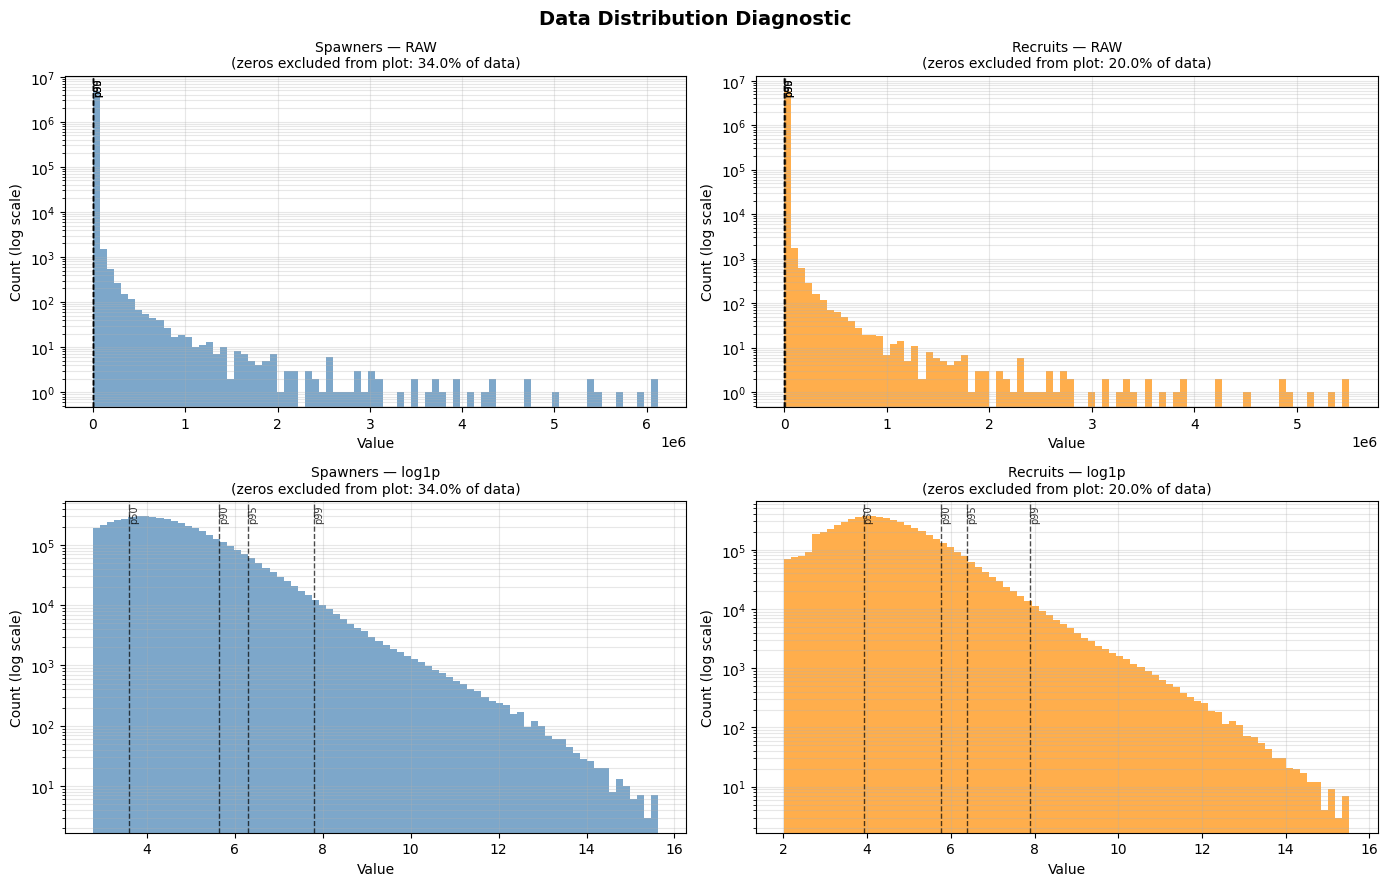

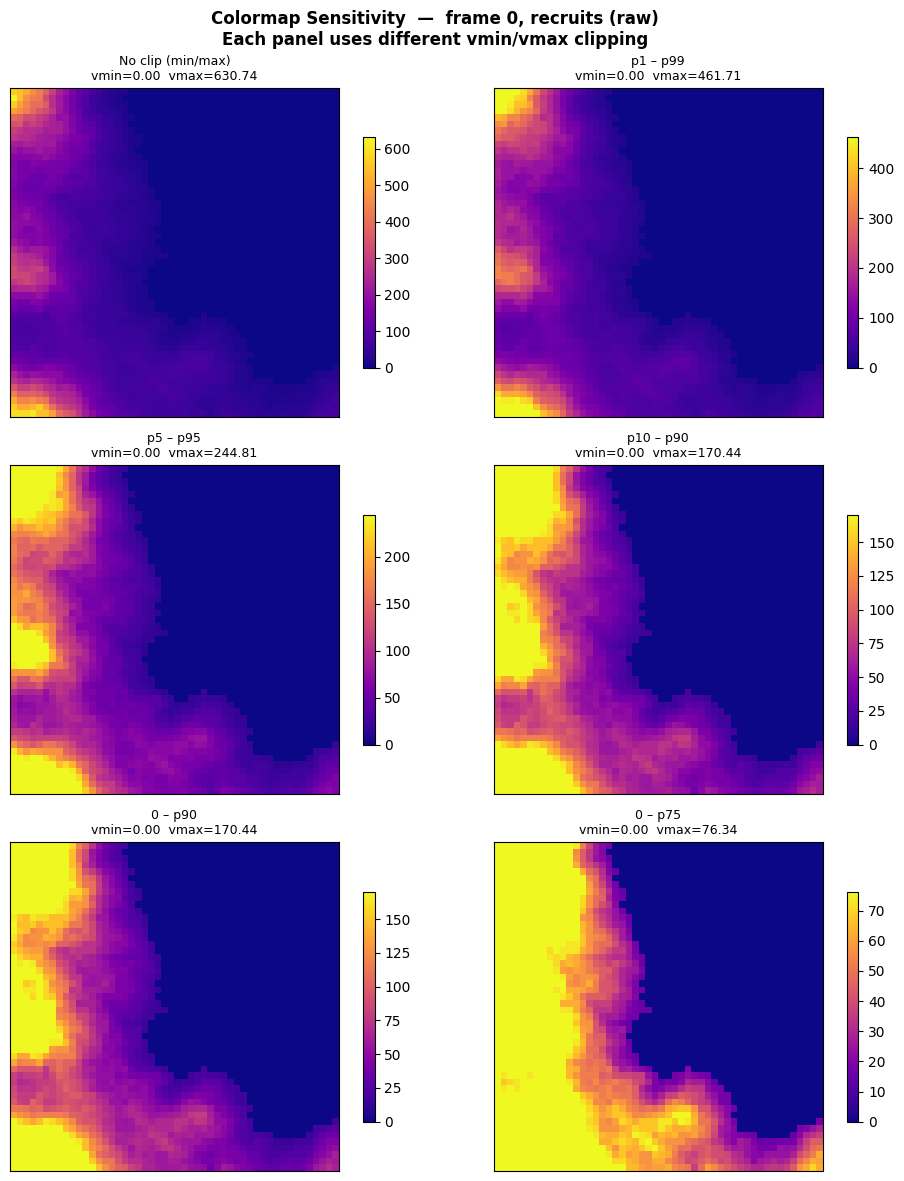


✓  Both diagnostic plots saved to your Drive.

Once you see these, the fix is usually one of:
  • Your data is heavily zero-inflated → use vmin=0, vmax=p90 or p95
  • A few extreme outliers stretch the scale → clip to p1–p99
  • log1p helps but the non-zero values are still right-skewed → try sqrt


In [ ]:
"""
data_distribution_diagnostic.py
---------------------------------
Run this in Colab to understand your data distribution before deciding
how to fix the color scales in the spatial plots.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

REPO_DIR    = "/content/Teleconnections-ViT"
RAW_DATA    = os.path.join(REPO_DIR, "data/dummy/output")
DRIVE_DIR   = "/content/drive/MyDrive/Teleconnection_ViT"

# Load raw arrays
spawners = np.load(os.path.join(RAW_DATA, "gmrf_spawners_50x50.npy"))
recruits = np.load(os.path.join(RAW_DATA, "gmrf_recruits_50x50.npy"))

sp = spawners.ravel()
rc = recruits.ravel()
sp_log = np.log1p(sp)   # log(1+x)
rc_log = np.log1p(rc)

# ---------------------------------------------------------------------------
# PRINT SUMMARY TABLE
# ---------------------------------------------------------------------------

def summarize(arr, name):
    pcts = [0, 1, 5, 25, 50, 75, 90, 95, 99, 99.9, 100]
    vals = np.percentile(arr, pcts)
    zero_frac = np.mean(arr == 0) * 100
    near_zero_frac = np.mean(arr < 1e-6) * 100

    print(f"\n{'='*55}")
    print(f"  {name}   (n = {len(arr):,})")
    print(f"{'='*55}")
    print(f"  min       = {arr.min():.4f}")
    print(f"  max       = {arr.max():.4f}")
    print(f"  mean      = {arr.mean():.4f}")
    print(f"  std       = {arr.std():.4f}")
    print(f"  % zeros          = {zero_frac:.1f}%")
    print(f"  % near-zero(<1e-6) = {near_zero_frac:.1f}%")
    print(f"\n  Percentiles:")
    for p, v in zip(pcts, vals):
        bar = "█" * int(v / arr.max() * 30) if arr.max() > 0 else ""
        print(f"    p{p:>5.1f} = {v:>12.4f}  {bar}")

summarize(sp,     "SPAWNERS  (raw)")
summarize(rc,     "RECRUITS  (raw)")
summarize(sp_log, "SPAWNERS  (log1p)")
summarize(rc_log, "RECRUITS  (log1p)")

# ---------------------------------------------------------------------------
# PLOT: histograms + percentile markers
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Data Distribution Diagnostic", fontsize=14, fontweight="bold")

# Key percentiles to mark
mark_pcts = [50, 90, 95, 99]

def plot_hist(ax, arr, title, color, log_yscale=True):
    # Use log y-scale to see the tail
    arr_nonzero = arr[arr > 1e-6]
    zero_pct = np.mean(arr == 0) * 100

    ax.hist(arr_nonzero, bins=80, color=color, alpha=0.7, edgecolor="none")

    # Mark percentiles
    for p in mark_pcts:
        v = np.percentile(arr, p)
        ax.axvline(v, color="black", lw=1.0, linestyle="--", alpha=0.7)
        ax.text(v, ax.get_ylim()[1] * 0.8, f"p{p}", fontsize=7,
                ha="left", rotation=90, alpha=0.8)

    if log_yscale:
        ax.set_yscale("log")

    ax.set_title(f"{title}\n(zeros excluded from plot: {zero_pct:.1f}% of data)", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count (log scale)")
    ax.grid(True, alpha=0.3, which="both")

plot_hist(axes[0, 0], sp,     "Spawners — RAW",    "steelblue")
plot_hist(axes[0, 1], rc,     "Recruits — RAW",    "darkorange")
plot_hist(axes[1, 0], sp_log, "Spawners — log1p",  "steelblue")
plot_hist(axes[1, 1], rc_log, "Recruits — log1p",  "darkorange")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "data_distribution.png"), dpi=120)
plt.show()

# ---------------------------------------------------------------------------
# PLOT: what different vmin/vmax choices look like on a single example frame
# ---------------------------------------------------------------------------

fig2, axes2 = plt.subplots(3, 2, figsize=(10, 12))
fig2.suptitle(
    "Colormap Sensitivity  —  frame 0, recruits (raw)\n"
    "Each panel uses different vmin/vmax clipping",
    fontsize=12, fontweight="bold",
)

example_frame = recruits[0]   # first frame

clip_choices = [
    ("No clip (min/max)",  example_frame.min(),         example_frame.max()),
    ("p1 – p99",           np.percentile(example_frame, 1),  np.percentile(example_frame, 99)),
    ("p5 – p95",           np.percentile(example_frame, 5),  np.percentile(example_frame, 95)),
    ("p10 – p90",          np.percentile(example_frame, 10), np.percentile(example_frame, 90)),
    ("0 – p90",            0,                               np.percentile(example_frame, 90)),
    ("0 – p75",            0,                               np.percentile(example_frame, 75)),
]

for ax, (label, vmin, vmax) in zip(axes2.ravel(), clip_choices):
    im = ax.imshow(example_frame, cmap="plasma", vmin=vmin, vmax=vmax,
                   origin="lower", aspect="equal")
    fig2.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(f"{label}\nvmin={vmin:.2f}  vmax={vmax:.2f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, "colormap_sensitivity.png"), dpi=120)
plt.show()

print("\n✓  Both diagnostic plots saved to your Drive.")
print("\nOnce you see these, the fix is usually one of:")
print("  • Your data is heavily zero-inflated → use vmin=0, vmax=p90 or p95")
print("  • A few extreme outliers stretch the scale → clip to p1–p99")
print("  • log1p helps but the non-zero values are still right-skewed → try sqrt")

✓ Plot saved to /content/drive/MyDrive/Teleconnection_ViT/checkpoints/training_history.png


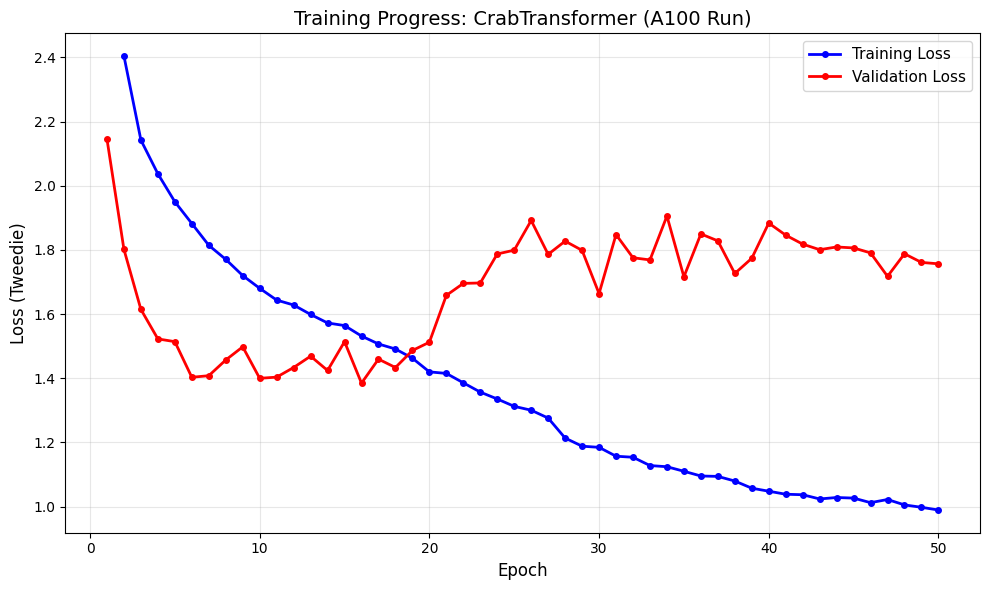

In [ ]:
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

# 1. Use a regular expression to extract the number and sort numerically
def get_epoch_num(filename):
    match = re.search(r'epoch_(\d+)', filename)
    return int(match.group(1)) if match else 0

# Load and sort files correctly
checkpoint_files = glob.glob(os.path.join(DATA_PATH, "checkpoints/checkpoint_epoch_*.pt"))
checkpoint_files.sort(key=get_epoch_num) # Sorts 2 before 10

epochs = []
train_losses = []
val_losses = []

for cp_file in checkpoint_files:
    try:
        cp = torch.load(cp_file, map_location='cpu')
        epochs.append(cp['epoch'])
        train_losses.append(cp['train_loss'])
        val_losses.append(cp['val_loss'])
    except Exception as e:
        print(f"Skipping corrupted file {cp_file}: {e}")

# 2. Final safety check: Sort the lists together in case files were messy
# This ensures that even if filenames are weird, the x-axis (epochs) is strictly increasing
sorted_data = sorted(zip(epochs, train_losses, val_losses))
epochs, train_losses, val_losses = zip(*sorted_data)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs[1:], train_losses[1:], 'b-o', label='Training Loss', linewidth=2, markersize=4)
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Tweedie)', fontsize=12)
plt.title('Training Progress: CrabTransformer (A100 Run)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and Show
save_path = os.path.join(DATA_PATH, 'checkpoints/training_history.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to {save_path}")
plt.show()

Computed new Spawner Max: 889.5182
Computed new Recruit Max: 604.8356
Batch Correlation: 0.6957 (Should be > 0.7)


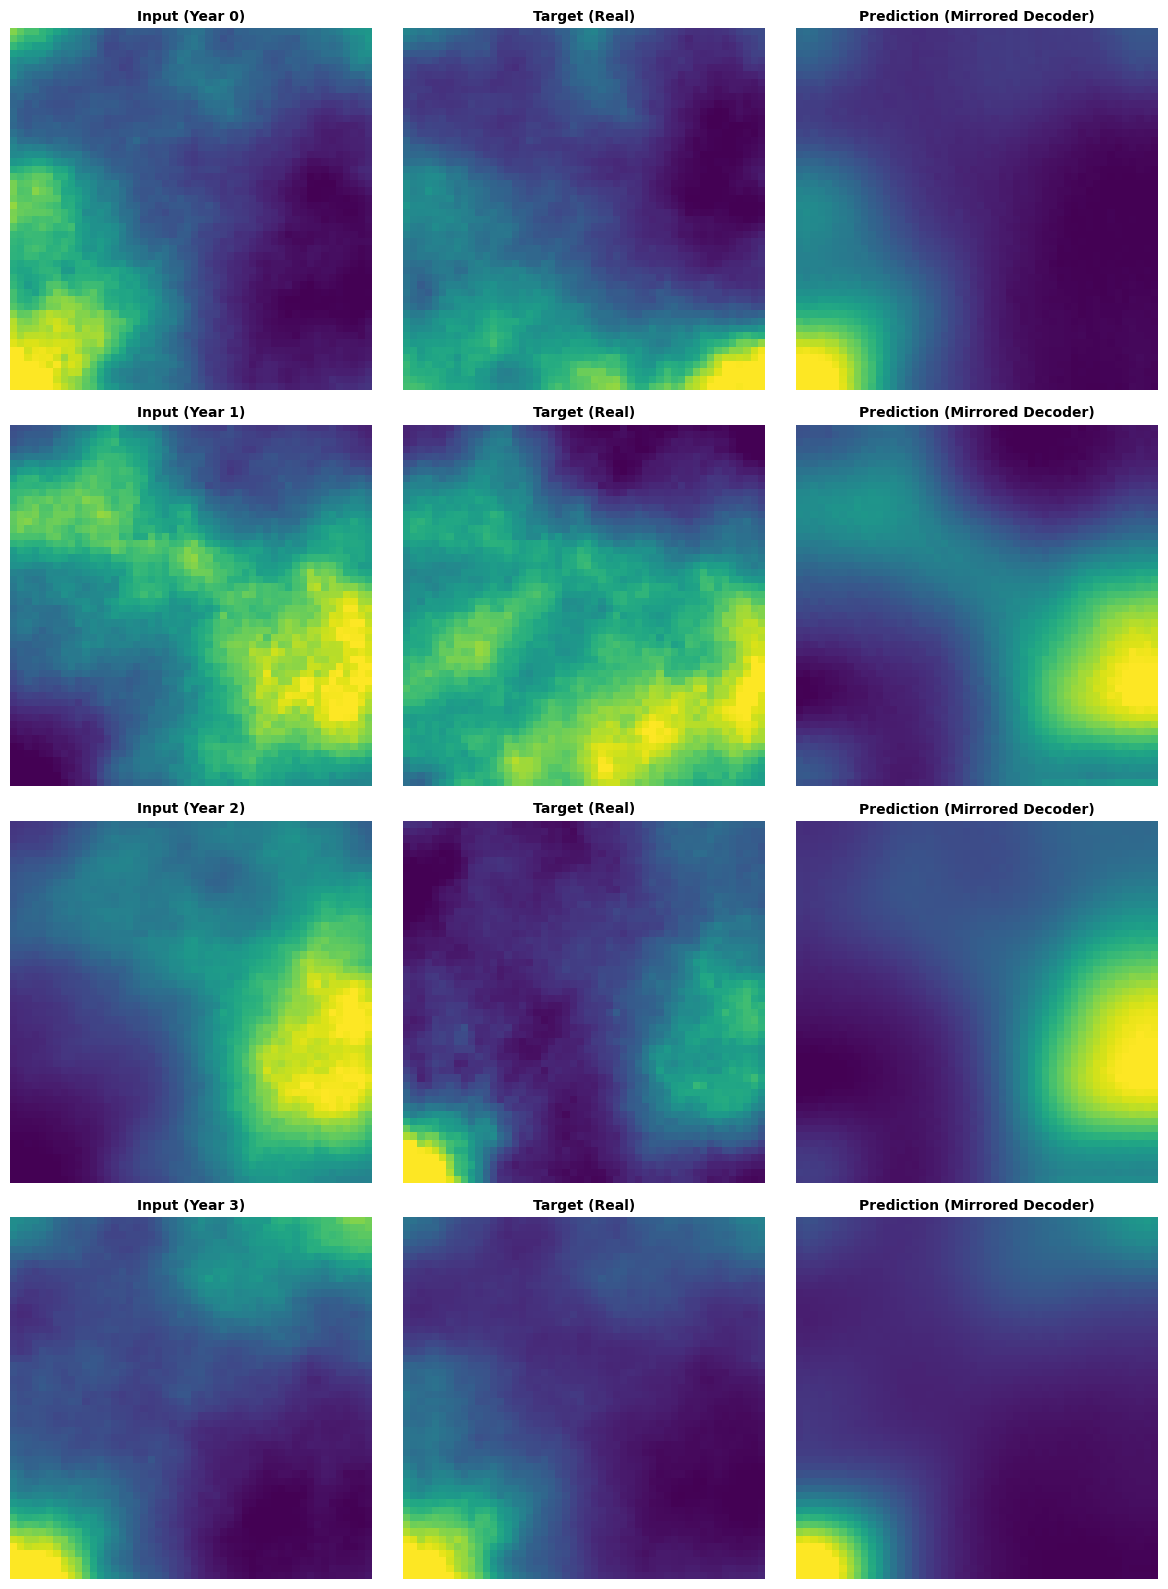

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Constants (from your new run logs)
train_ds = CrabDataset(
        os.path.join(DATA_PATH, "train_spawners.npy"),
        os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=22, spawner_max=None, recruit_max=None
    )

SPAWN_MAX = train_ds.spawner_max
RECRUIT_MAX = train_ds.recruit_max

# 2. Get a batch
model.eval()
with torch.no_grad():
    inputs, targets, year_indices = next(iter(val_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# 3. Denormalize
inputs_np = inputs.cpu().numpy() * SPAWN_MAX
targets_np = targets.cpu().numpy() * RECRUIT_MAX
preds_np = predictions.cpu().numpy() * RECRUIT_MAX

# 4. Calculate Correlation for this batch (Sanity Check)
batch_corr = np.corrcoef(preds_np.flatten(), targets_np.flatten())[0, 1]
print(f"Batch Correlation: {batch_corr:.4f} (Should be > 0.7)")

# 5. Plot
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Helper to remove ticks
def clean_plot(ax, data, title):
    # Use robust scaling (1st-99th percentile) to ignore any remaining outliers
    vmin, vmax = np.percentile(data, [1, 99])
    im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')
    return im

for i in range(4):
    clean_plot(axes[i, 0], inputs_np[i, 0], f"Input (Year {year_indices[i].item()})")
    clean_plot(axes[i, 1], targets_np[i, 0], "Target (Real)")
    clean_plot(axes[i, 2], preds_np[i, 0], "Prediction (Mirrored Decoder)")

plt.tight_layout()
plt.show()

📊 Calculating Global Metrics...

✅ Global Correlation: 0.7796


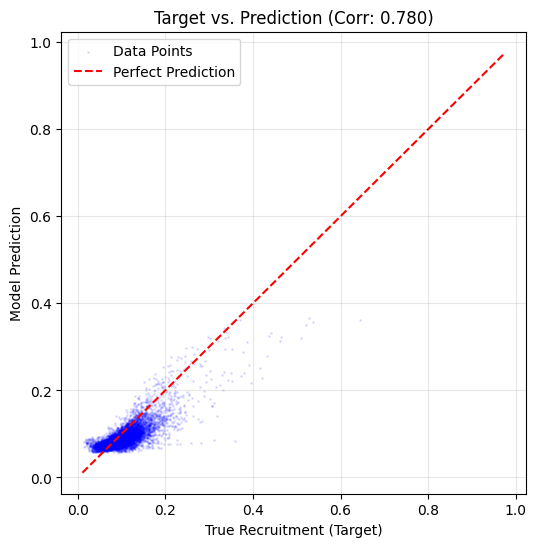

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Calculating Global Metrics...")

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for inputs, targets, year_indices in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Get predictions
        outputs = model(inputs, year_indices)

        # Collect data (flattened)
        all_preds.append(outputs.cpu().numpy().flatten())
        all_targets.append(targets.cpu().numpy().flatten())

# Concatenate all batches
global_preds = np.concatenate(all_preds)
global_targets = np.concatenate(all_targets)

# 1. Calculate Global Correlation
global_corr = np.corrcoef(global_preds, global_targets)[0, 1]

print(f"\n✅ Global Correlation: {global_corr:.4f}")

# 2. Scatter Plot (The Truth Detector)
# We plot a random subset of points to keep it fast
sample_indices = np.random.choice(len(global_preds), size=10000, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(global_targets[sample_indices], global_preds[sample_indices],
            alpha=0.1, s=1, c='blue', label='Data Points')

# Add 1:1 Line (Perfect Prediction)
min_val = min(global_targets.min(), global_preds.min())
max_val = max(global_targets.max(), global_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title(f"Target vs. Prediction (Corr: {global_corr:.3f})")
plt.xlabel("True Recruitment (Target)")
plt.ylabel("Model Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Rectangle
from google.colab import drive

# --- 1. MOUNT DRIVE (If not already mounted) ---
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

# --- 2. CONFIGURATION ---
BOOTSTRAP_IDX = 0
GRID_SIZE = 50

# PATH 1: The Local GitHub Repo (Contains the 50x50 dummy data)
REPO_DIR = '/content/Teleconnections-ViT'

# PATH 2: Google Drive (Contains Splits and Checkpoints)
# ⚠️ UPDATE THIS LINE to match your Drive folder structure!
# It likely looks like: "/content/drive/MyDrive/Teleconnections-ViT"
DRIVE_DIR = "/content/drive/MyDrive/Teleconnection_ViT"

# Construct absolute paths
DUMMY_DATA_DIR = os.path.join(REPO_DIR, "data/dummy/output")      # From GitHub
SPLIT_DIR = DRIVE_DIR        # From Drive
CHECKPOINT_PATH = os.path.join(DRIVE_DIR, "checkpoints/best_model_maxscaled.pt") # From Drive
SAVE_DIR = os.path.join(DRIVE_DIR, "analysis/full_bootstrap_viz") # Save back to Drive

# Split boundaries
TRAIN_END = 22
VAL_END = 27
TEST_END = 30

def visualize_full_trajectory():
    os.makedirs(SAVE_DIR, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- DIAGNOSTIC CHECKS ---
    print("\n--- Checking Paths ---")
    if not os.path.exists(DUMMY_DATA_DIR):
        print(f"❌ ERROR: Dummy data not found at: {DUMMY_DATA_DIR}")
        print("   Did the git clone finish successfully?")
        return
    if not os.path.exists(SPLIT_DIR):
        print(f"❌ ERROR: Splits not found at: {SPLIT_DIR}")
        print("   Check your DRIVE_DIR path.")
        return
    if not os.path.exists(CHECKPOINT_PATH):
        print(f"❌ ERROR: Checkpoint not found at: {CHECKPOINT_PATH}")
        print("   Check your DRIVE_DIR path.")
        return
    print("✅ All paths verified.\n")

    # 1. Load Normalization Constants (From Drive Splits)
    print("Loading training stats for normalization...")
    train_spawners = np.load(os.path.join(SPLIT_DIR, "train_spawners.npy"))
    train_recruits = np.load(os.path.join(SPLIT_DIR, "train_recruits.npy"))

    SPAWN_MAX = np.max(train_spawners) + 1e-6
    RECRUIT_MAX = np.max(train_recruits) + 1e-6
    print(f"Normalization Max | Spawners: {SPAWN_MAX:.2f} | Recruits: {RECRUIT_MAX:.2f}")

    # 2. Load the Model
    print(f"Loading model...")
    # Make sure we are in the repo dir so Python can find 'model.py' or 'components.py'
    # if your CrabTransformer class is defined in a file there.
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)

    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=1,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.0
    ).to(device)

    # Load weights from Drive
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.eval()

    # 3. Load the Full Bootstrap Data (From Local GitHub)
    print(f"Loading Bootstrap {BOOTSTRAP_IDX} from full dataset...")
    all_spawners = np.load(os.path.join(DUMMY_DATA_DIR, "gmrf_spawners_50x50.npy"))
    all_recruits = np.load(os.path.join(DUMMY_DATA_DIR, "gmrf_recruits_50x50.npy"))

    start_idx = BOOTSTRAP_IDX * 30
    end_idx = start_idx + 30

    b_spawners = all_spawners[start_idx:end_idx]
    b_recruits = all_recruits[start_idx:end_idx]

    # 4. Run Predictions Loop
    print("Running predictions...")
    preds_denorm = []

    with torch.no_grad():
        for t in range(30):
            # Prepare Input
            raw_sp = b_spawners[t]
            norm_sp = raw_sp / SPAWN_MAX

            input_tensor = torch.tensor(norm_sp, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            year_tensor = torch.tensor([t], dtype=torch.long).to(device)

            output = model(input_tensor, year_tensor)

            pred_val = output.cpu().numpy().squeeze() * RECRUIT_MAX
            preds_denorm.append(pred_val)

    preds_denorm = np.array(preds_denorm)

    # 5. GENERATE PLOTS
    print("Generating visualization...")

    # --- PLOT A: Time Series ---
    center_y, center_x = GRID_SIZE // 2, GRID_SIZE // 2
    ts_target = b_recruits[:, center_y, center_x]
    ts_pred = preds_denorm[:, center_y, center_x]

    plt.figure(figsize=(12, 6))
    plt.axvspan(0, TRAIN_END-1, color='green', alpha=0.1, label='Training')
    plt.axvspan(TRAIN_END-1, VAL_END-1, color='orange', alpha=0.1, label='Validation')
    plt.axvspan(VAL_END-1, TEST_END-1, color='red', alpha=0.1, label='Test')

    plt.plot(ts_target, 'k-o', linewidth=2, label='True Recruitment')
    plt.plot(ts_pred, 'b--', linewidth=2, label='Model Prediction')

    plt.title(f"30-Year Trajectory (Bootstrap {BOOTSTRAP_IDX}) - Center Pixel", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(SAVE_DIR, "bootstrap_timeseries.png"))
    plt.close()

    # --- PLOT B: Spatial Grid ---
    fig, axes = plt.subplots(30, 3, figsize=(10, 60))
    vmin_r, vmax_r = np.percentile(b_recruits, [1, 99])

    for t in range(30):
        if t < TRAIN_END: phase = "TRAIN"
        elif t < VAL_END: phase = "VAL"
        else: phase = "TEST"

        axes[t, 0].imshow(b_spawners[t], cmap='viridis')
        axes[t, 0].set_ylabel(f"Year {t}\n({phase})", fontsize=12, fontweight='bold')
        axes[t, 0].set_xticks([]); axes[t, 0].set_yticks([])

        axes[t, 1].imshow(b_recruits[t], cmap='plasma', vmin=vmin_r, vmax=vmax_r)
        axes[t, 1].axis('off')

        axes[t, 2].imshow(preds_denorm[t], cmap='plasma', vmin=vmin_r, vmax=vmax_r)
        axes[t, 2].axis('off')

        color = 'green' if phase == 'TRAIN' else ('orange' if phase == 'VAL' else 'red')
        rect = Rectangle((0,0), 49, 49, linewidth=3, edgecolor=color, facecolor='none')
        axes[t, 2].add_patch(rect)

    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, "bootstrap_spatial_frames.png")
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()

    print(f"✓ Analysis complete!")
    print(f"  Files saved in: {SAVE_DIR}")

if __name__ == "__main__":
    visualize_full_trajectory()

Using device: cuda

--- Checking Paths ---
✅ All paths verified.

Loading training stats for normalization...
Normalization Max | Spawners: 889.52 | Recruits: 604.84
Loading model...
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
Loading Bootstrap 0 from full dataset...
Running predictions...
Generating visualization...
✓ Analysis complete!
  Files saved in: /content/drive/MyDrive/Teleconnection_ViT/analysis/full_bootstrap_viz


Hooking into model to capture attention...


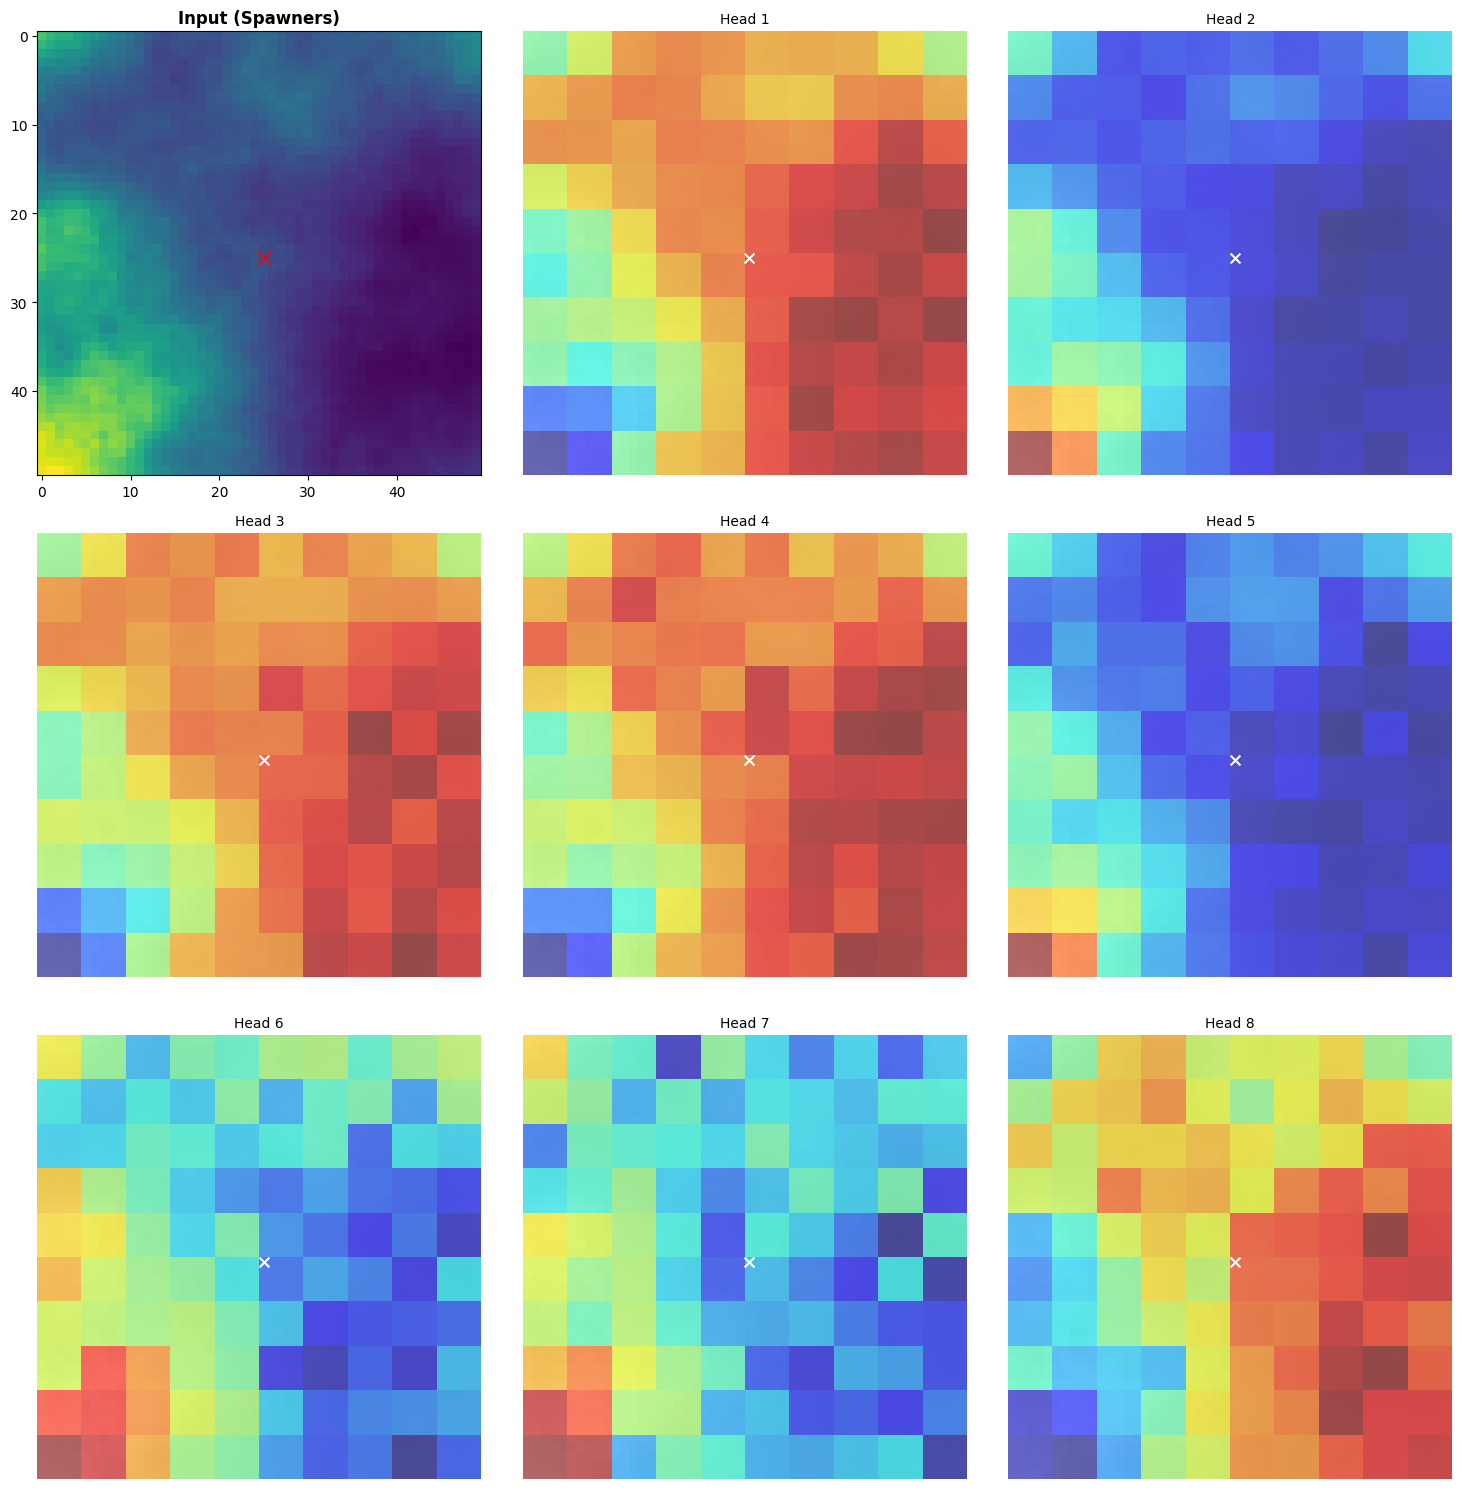

In [ ]:
def visualize_all_heads(model, val_loader, device):
    print("Hooking into model to capture attention...")

    # Storage for the weights
    captured_weights = []
    def hook_fn(module, input, output):
        captured_weights.append(input[0].detach().cpu())

    # 1. Register Hook (Same as before)
    block_list = [m for m in model.children() if isinstance(m, torch.nn.ModuleList)][0]
    target_layer = block_list[-1].attention.dropout
    hook_handle = target_layer.register_forward_hook(hook_fn)

    # 2. Run Batch
    model.eval()
    try:
        inputs, targets, year_idx = next(iter(val_loader))
        inputs = inputs.to(device)
        year_idx = year_idx.to(device)
        with torch.no_grad():
            _ = model(inputs, year_idx)
    finally:
        hook_handle.remove()

    # 3. Process Heads
    # attn_matrix shape: [Batch, 8, 100, 100]
    attn_matrix = captured_weights[0]
    batch_idx = 0
    center_patch_idx = 55 # Approx center of 10x10 grid

    # 4. PLOT GRID (1 Input + 8 Heads)
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    # Plot 0: The Input
    input_img = inputs[batch_idx, 0].cpu().numpy()
    axes[0].imshow(input_img, cmap='viridis')
    axes[0].scatter([25], [25], c='red', marker='x', s=100)
    axes[0].set_title("Input (Spawners)", fontweight='bold')

    # Plot 1-8: The Attention Heads
    for head_idx in range(8):
        ax = axes[head_idx + 1]

        # Get this head's attention for the center patch
        head_attn = attn_matrix[batch_idx, head_idx, center_patch_idx, :] # [100]

        # Reshape to 10x10
        grid = head_attn.view(10, 10).numpy()

        # Normalize per head for visibility
        grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)

        # Resize to 50x50
        grid_resized = cv2.resize(grid, (50, 50), interpolation=cv2.INTER_NEAREST)

        # Overlay
        ax.imshow(input_img, cmap='gray', alpha=0.3)
        ax.imshow(grid_resized, cmap='jet', alpha=0.6)
        ax.scatter([25], [25], c='white', marker='x', s=50)
        ax.set_title(f"Head {head_idx+1}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run it
visualize_all_heads(model, val_loader, device)

In [ ]:
# 1. Recreate the Validation Loader (using constants from your logs)
print("--- Recreating Validation Loader ---")
# print the current directory:
print(os.getcwd())
SPAWN_MAX = train_ds.spawner_max
RECRUIT_MAX = train_ds.recruit_max

val_ds = CrabDataset(
    os.path.join(DATA_PATH, "val_spawners.npy"),
    os.path.join(DATA_PATH, "val_recruits.npy"),
    n_years=5,
    spawner_max=SPAWN_MAX,
    recruit_max=RECRUIT_MAX
)
val_loader = DataLoader(val_ds, batch_size=5, shuffle=False)

# 2. Load your saved model
print("--- Loading Saved Model ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.1
).to(device)

# Load the best weights saved during your run
checkpoint_path = os.path.join(DATA_PATH, "checkpoints/best_model_maxscaled.pt")
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

# 3. Run Correlation Analysis
print("\n📊 Running Correlation Analysis...")
all_preds = []
all_inputs = []
all_targets = []

with torch.no_grad():
    for inputs, targets, year_idx in val_loader:
        inputs, targets, year_idx = inputs.to(device), targets.to(device), year_idx.to(device)
        outputs = model(inputs, year_idx)

        all_preds.append(outputs.cpu().numpy())
        all_inputs.append(inputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

# Flatten arrays
preds_np = np.concatenate(all_preds).flatten()
inputs_np = np.concatenate(all_inputs).flatten()
targets_np = np.concatenate(all_targets).flatten()

# Calculate
input_corr = np.corrcoef(preds_np, inputs_np)[0, 1]
print(f"Correlation (Input vs Prediction):  {input_corr:.4f}")

target_corr = np.corrcoef(preds_np, targets_np)[0, 1]
print(f"Correlation (Target vs Prediction): {target_corr:.4f}")

# Verdict
if input_corr > 0.9 and target_corr < 0.1:
    print("⚠️  WARNING: Model is stuck in Identity Trap.")
elif target_corr > 0.2:
    print("✅  SUCCESS: Model is learning recruitment patterns!")
else:
    print("ℹ️  Model is stable, but struggling to find strong signal.")

--- Recreating Validation Loader ---
/content/Teleconnections-ViT
Using provided Spawner Max: 889.5182
Using provided Recruit Max: 604.8356
--- Loading Saved Model ---
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete

📊 Running Correlation Analysis...
Correlation (Input vs Prediction):  0.9573
Correlation (Target vs Prediction): 0.7869
✅  SUCCESS: Model is learning recruitment patterns!


In [ ]:
import glob
import torch
import os

checkpoint_dir = os.path.join(DATA_PATH, "checkpoints")
checkpoints = glob.glob(os.path.join(checkpoint_dir, "*.pt"))

if checkpoints:
    print(f"Found {len(checkpoints)} checkpoint(s):\n")
    for cp in sorted(checkpoints):
        name = os.path.basename(cp)
        try:
            chkpt = torch.load(cp, map_location='cpu')
            print(f"  {name:30s} | Epoch {chkpt['epoch']:2d} | Train: {chkpt['train_loss']:.4f} | Val: {chkpt['val_loss']:.4f}")
        except:
            print(f"  {name:30s} | (Loading...)")
else:
    print("No checkpoints yet - training hasn't reached epoch 5")

Found 13 checkpoint(s):

  best_model.pt                  | Epoch 49 | Train: 0.7560 | Val: 0.7048
  best_model_maxscaled.pt        | (Loading...)
  checkpoint_epoch_10.pt         | Epoch 10 | Train: 0.8647 | Val: 0.7766
  checkpoint_epoch_15.pt         | (Loading...)
  checkpoint_epoch_20.pt         | Epoch 20 | Train: 0.7960 | Val: 0.7393
  checkpoint_epoch_25.pt         | Epoch 25 | Train: 0.7823 | Val: 0.7326
  checkpoint_epoch_30.pt         | Epoch 30 | Train: 0.7739 | Val: 0.7213
  checkpoint_epoch_35.pt         | Epoch 35 | Train: 0.7664 | Val: 0.7199
  checkpoint_epoch_40.pt         | Epoch 40 | Train: 0.7616 | Val: 0.7177
  checkpoint_epoch_45.pt         | Epoch 45 | Train: 0.7571 | Val: 0.7106
  checkpoint_epoch_5.pt          | Epoch  5 | Train: 1.0191 | Val: 0.8446
  checkpoint_epoch_50.pt         | Epoch 50 | Train: 0.7556 | Val: 0.7104
  final_model.pt                 | Epoch 50 | Train: 0.7556 | Val: 0.7104


In [ ]:
# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6,
    d_ff=512, mask=None, dropout=0.1
).to(device)

checkpoint = torch.load(os.path.join(DATA_PATH, "checkpoints/best_model.pt"))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")

Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
✓ Loaded best model from epoch 49
  Validation Loss: 0.7048


In [ ]:
from torch.utils.data import DataLoader
from data.data_helper import CrabDataset
from models.losses import TweedieLoss

# Load test data
test_ds = CrabDataset(
    spawner_path=os.path.join(DATA_PATH, "test_spawners.npy"),
    recruit_path=os.path.join(DATA_PATH, "test_recruits.npy"),
    n_years=3,
    spawner_max=train_ds.spawner_max,
    recruit_max=train_ds.recruit_max
)
test_loader = DataLoader(test_ds, batch_size=5, shuffle=False)

# Evaluate
criterion = TweedieLoss(power=1.5)
#criterion = torch.nn.MSELoss()
total_test_loss = 0

with torch.no_grad():
    for inputs, targets, year_indices in test_loader:
        inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
        outputs = model(inputs, year_indices)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.4f}")

Computed new Spawner Max: 506.9257
Computed new Recruit Max: 465.9379
Test Loss: 1.4803


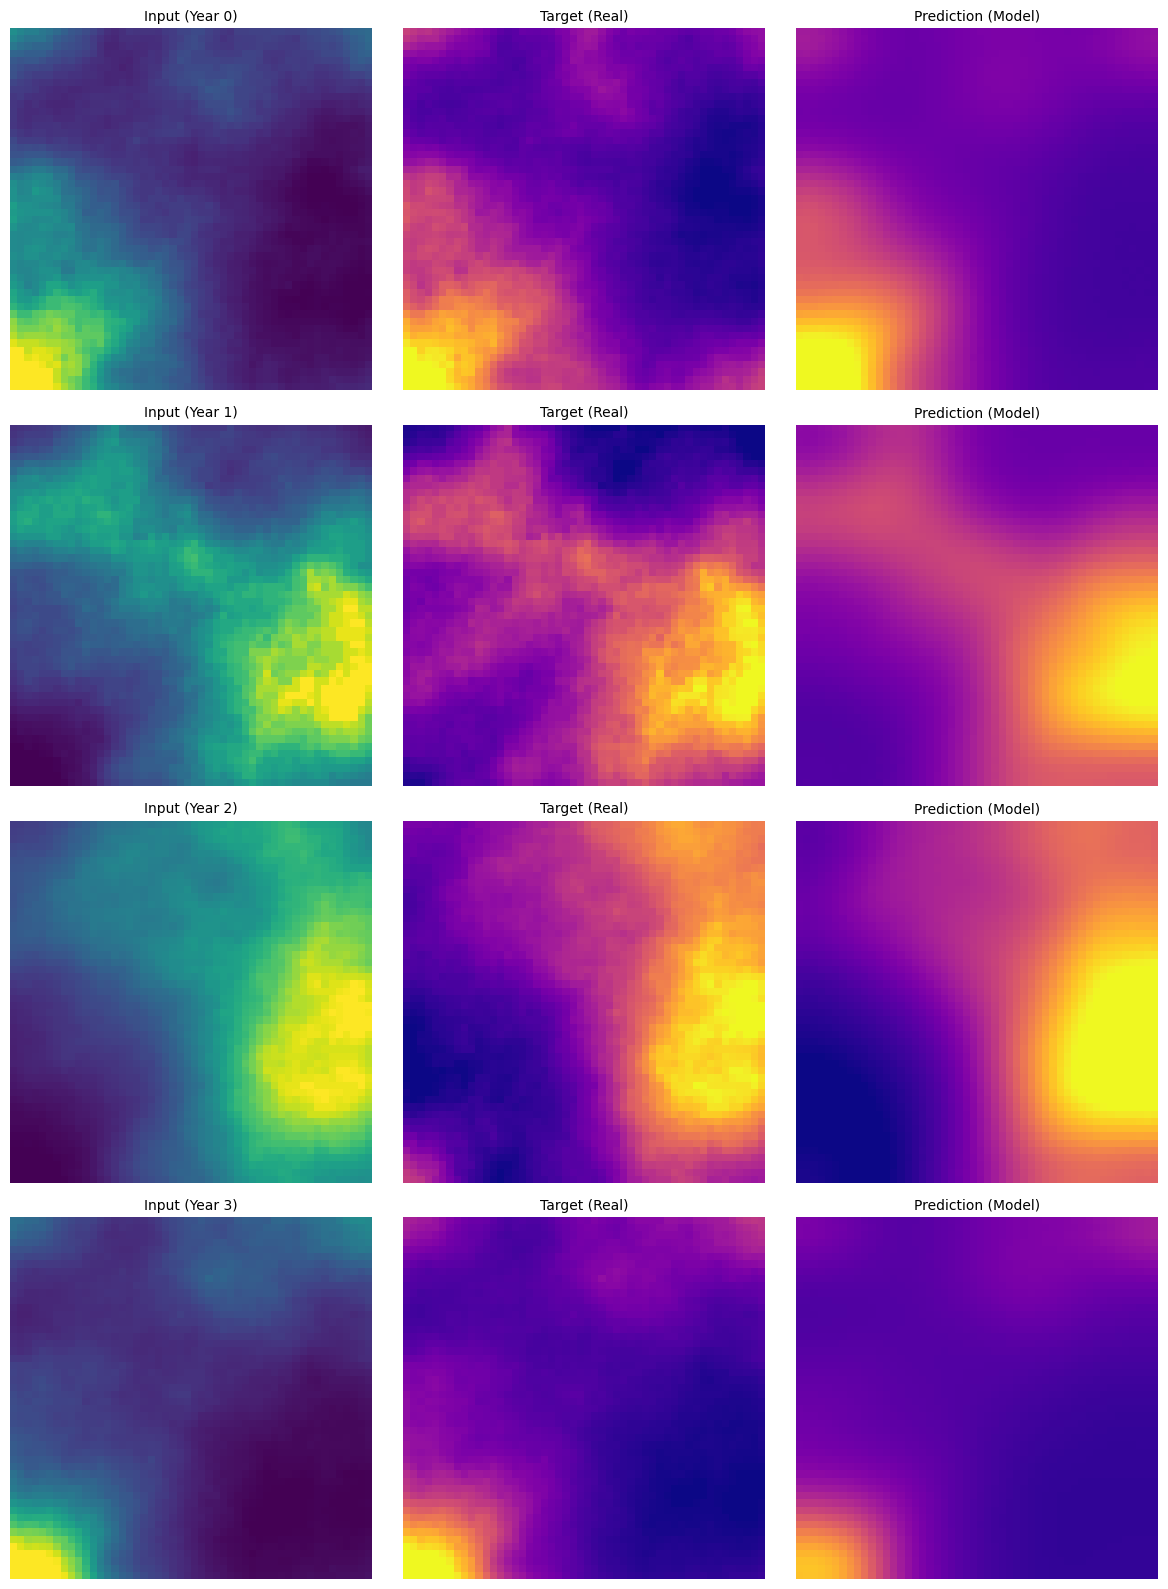

--- Debugging Values ---
Target Range:    9.69 to 364.10
Prediction Range:34.03 to 244.32


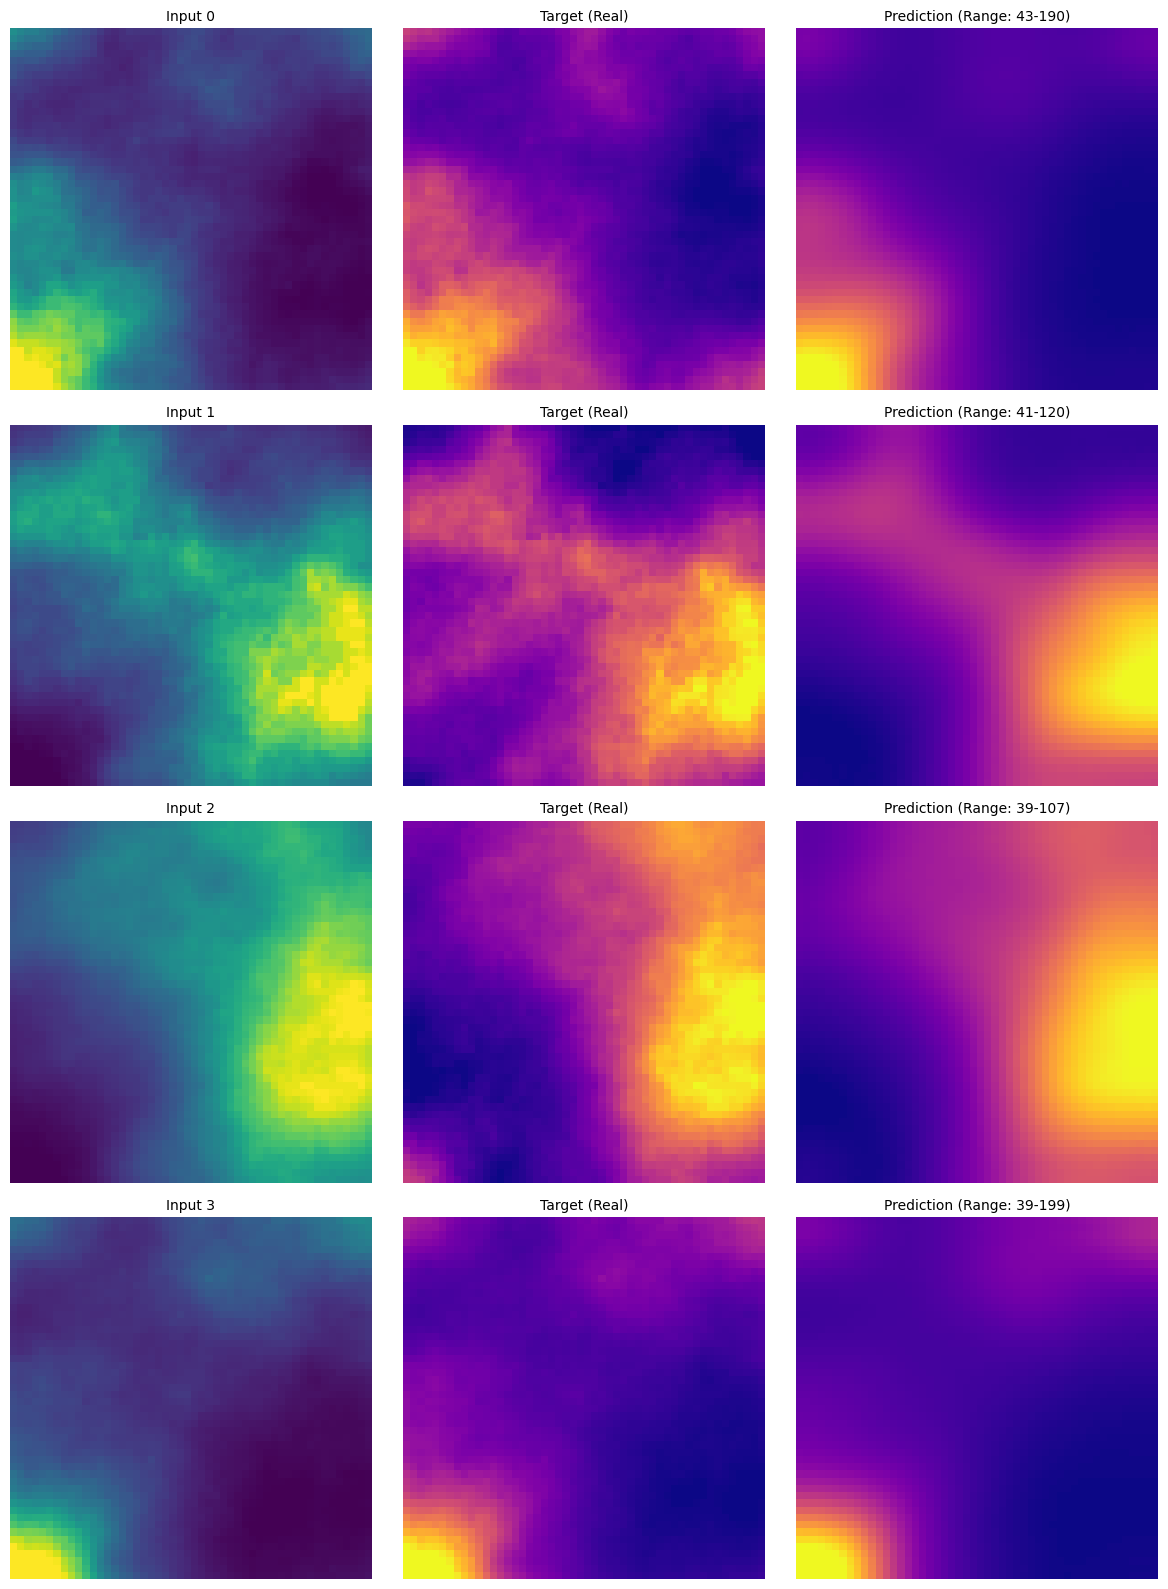

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get a fresh batch
model.eval()
with torch.no_grad():
    inputs, targets, year_indices = next(iter(val_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# 2. Convert and Scale
inputs_np = inputs.cpu().numpy()
targets_np = targets.cpu().numpy()
preds_np = predictions.cpu().numpy()

# ⚠️ scaling by the constants you found
SPAWN_MAX = train_ds.spawner_max
RECRUIT_MAX = train_ds.recruit_max

inputs_real = inputs_np * SPAWN_MAX
targets_real = targets_np * RECRUIT_MAX
preds_real = preds_np * RECRUIT_MAX

# 3. ROBUST PLOTTING FUNCTION
def robust_plot(ax, data, title, cmap='viridis'):
    # Calculate the 99th percentile to ignore extreme outliers/borders
    vmin = np.percentile(data, 1)
    vmax = np.percentile(data, 99)

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    return im

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Plot rows
for i in range(4):
    # Input
    robust_plot(axes[i, 0], inputs_real[i, 0], f"Input (Year {year_indices[i].item()})", cmap='viridis')

    # Target
    robust_plot(axes[i, 1], targets_real[i, 0], "Target (Real)", cmap='plasma')

    # Prediction
    # We use the Target's vmin/vmax for the Prediction to make them comparable
    target_min = np.percentile(targets_real[i, 0], 1)
    target_max = np.percentile(targets_real[i, 0], 99)

    im = axes[i, 2].imshow(preds_real[i, 0], cmap='plasma', vmin=target_min, vmax=target_max)
    axes[i, 2].set_title("Prediction (Model)", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# 4. Debug Prints
print("--- Debugging Values ---")
print(f"Target Range:    {targets_real.min():.2f} to {targets_real.max():.2f}")
print(f"Prediction Range:{preds_real.min():.2f} to {preds_real.max():.2f}")


# Use the robust_plot function again, but this time...
# Let predictions determine their OWN vmin/vmax
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    # Input
    robust_plot(axes[i, 0], inputs_real[i, 0], f"Input {year_indices[i].item()}", cmap='viridis')

    # Target (Real)
    robust_plot(axes[i, 1], targets_real[i, 0], "Target (Real)", cmap='plasma')

    # Prediction (Model) - SCALED INDEPENDENTLY
    # We calculate percentiles from the PREDICTION data, not the target
    pred_data = preds_real[i, 0]
    p_min = np.percentile(pred_data, 1)
    p_max = np.percentile(pred_data, 99)

    im = axes[i, 2].imshow(pred_data, cmap='plasma', vmin=p_min, vmax=p_max)
    axes[i, 2].set_title(f"Prediction (Range: {p_min:.0f}-{p_max:.0f})", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

Using Constants -> Spawner Max: 529.08, Recruit Max: 524.01
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
Computed new Spawner Max: 506.9257
Computed new Recruit Max: 465.9379


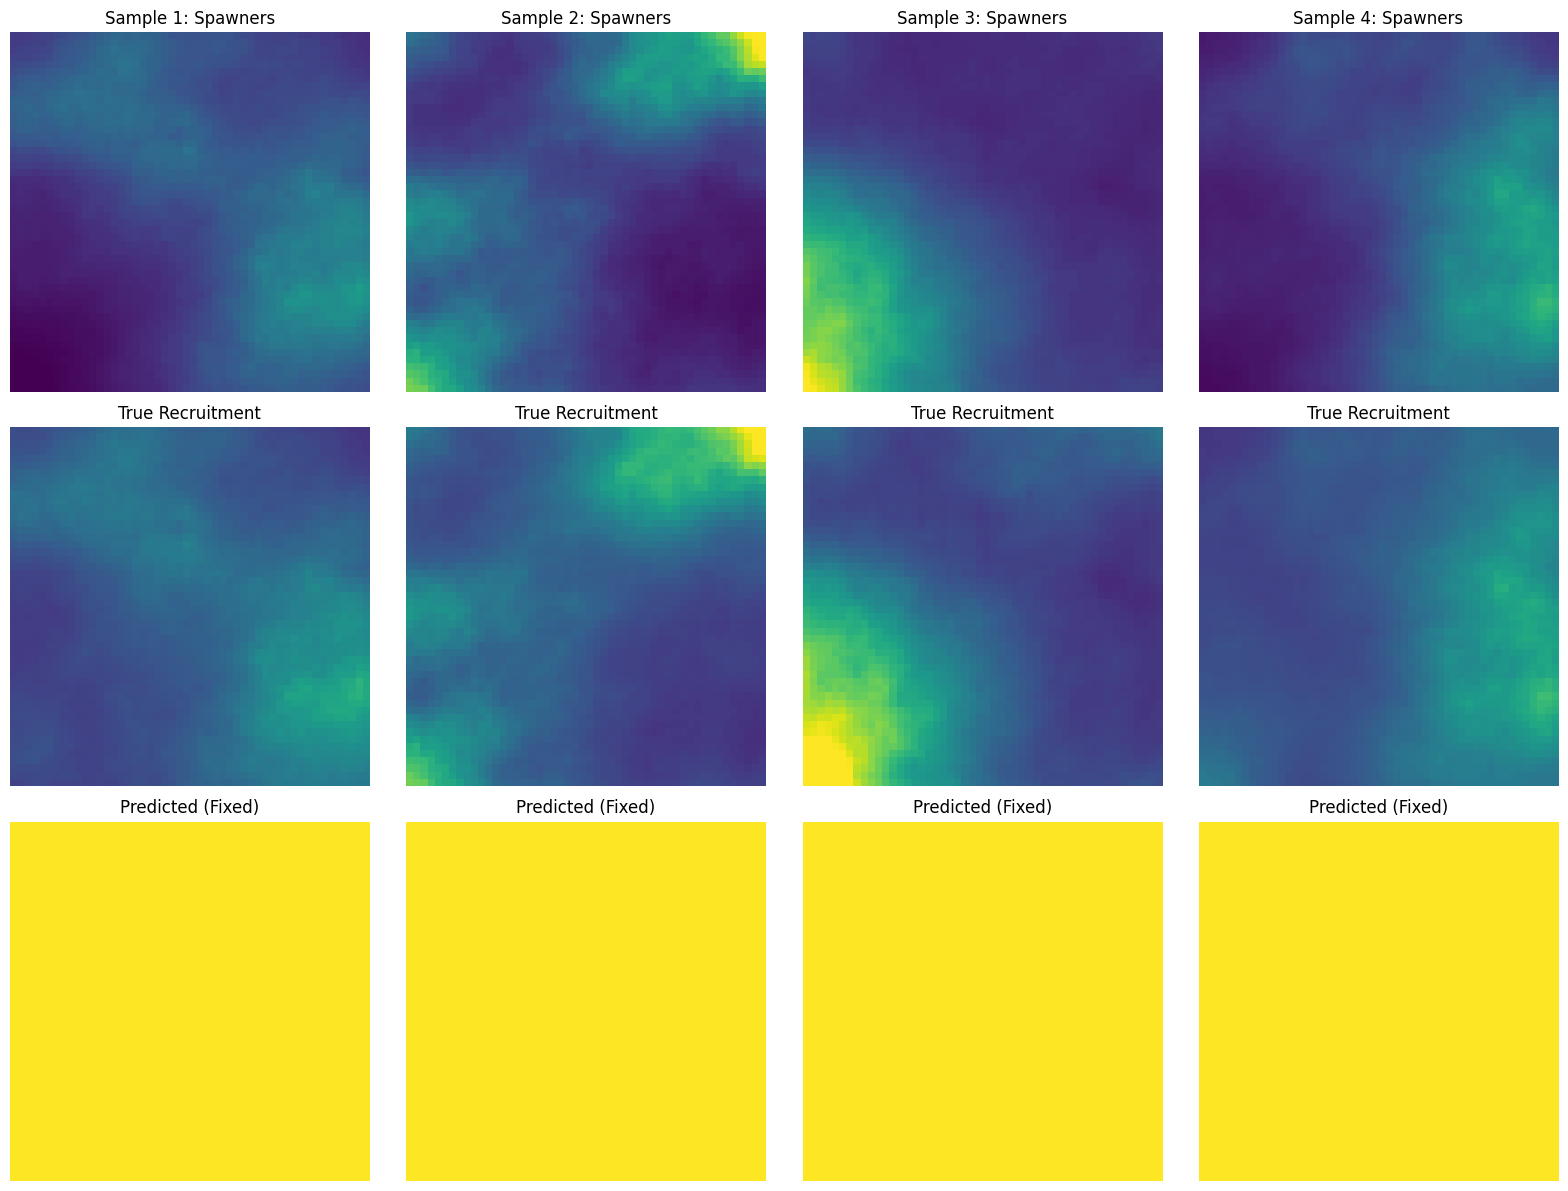

Prediction range: [226.19, 299.95]
Target range: [21.61, 268.02]


In [ ]:
# THIS ONE - Run after training completes
import numpy as np
import matplotlib.pyplot as plt


train_spawners = np.load(os.path.join(DATA_PATH, "train_spawners.npy"))
train_recruits = np.load(os.path.join(DATA_PATH, "train_recruits.npy"))
SPAWN_MAX = np.max(train_spawners) + 1e-6
RECRUIT_MAX = np.max(train_recruits) + 1e-6

print(f"Using Constants -> Spawner Max: {SPAWN_MAX:.2f}, Recruit Max: {RECRUIT_MAX:.2f}")


# Load model
checkpoint = torch.load(os.path.join(DATA_PATH, "checkpoints/best_model.pt"))
model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6,
    d_ff=512, mask=None, dropout=0.1
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get test data
test_ds = CrabDataset(
    os.path.join(DATA_PATH, "test_spawners.npy"),
    os.path.join(DATA_PATH, "test_recruits.npy"),
    n_years=3
)
test_loader = DataLoader(test_ds, batch_size=5, shuffle=False)

# Get predictions
with torch.no_grad():
    inputs, targets, year_indices = next(iter(test_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# Convert to numpy
inputs_np = inputs.cpu().numpy()
targets_np = targets.cpu().numpy()
preds_np = predictions.cpu().numpy()

# Denormalize
#SPAWN_MEAN, SPAWN_STD = 57.3167, 38.3864
#RECRUIT_MEAN, RECRUIT_STD = 49.9369, 24.3599

#inputs_denorm = inputs_np.copy()
#inputs_denorm[:, 0] = inputs_np[:, 0] * SPAWN_STD + SPAWN_MEAN
#inputs_denorm[:, 0] = inputs_np[:, 0] *
#inputs_denorm[:, 1] = inputs_np[:, 1] * RECRUIT_STD + RECRUIT_MEAN

#targets_denorm = targets_np * RECRUIT_STD + RECRUIT_MEAN
#preds_denorm = preds_np * RECRUIT_STD + RECRUIT_MEAN

inputs_denorm = inputs_np.copy()
inputs_denorm[:, 0] = inputs_np[:, 0] * SPAWN_MAX

targets_denorm = targets_np * RECRUIT_MAX
preds_denorm = preds_np * RECRUIT_MAX

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    axes[0, i].imshow(inputs_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[0, i].set_title(f'Sample {i+1}: Spawners')
    axes[0, i].axis('off')

    axes[1, i].imshow(targets_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[1, i].set_title('True Recruitment')
    axes[1, i].axis('off')

    axes[2, i].imshow(preds_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[2, i].set_title('Predicted (Fixed)')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'checkpoints/predictions_fixed.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Prediction range: [{preds_denorm.min():.2f}, {preds_denorm.max():.2f}]")
print(f"Target range: [{targets_denorm.min():.2f}, {targets_denorm.max():.2f}]")

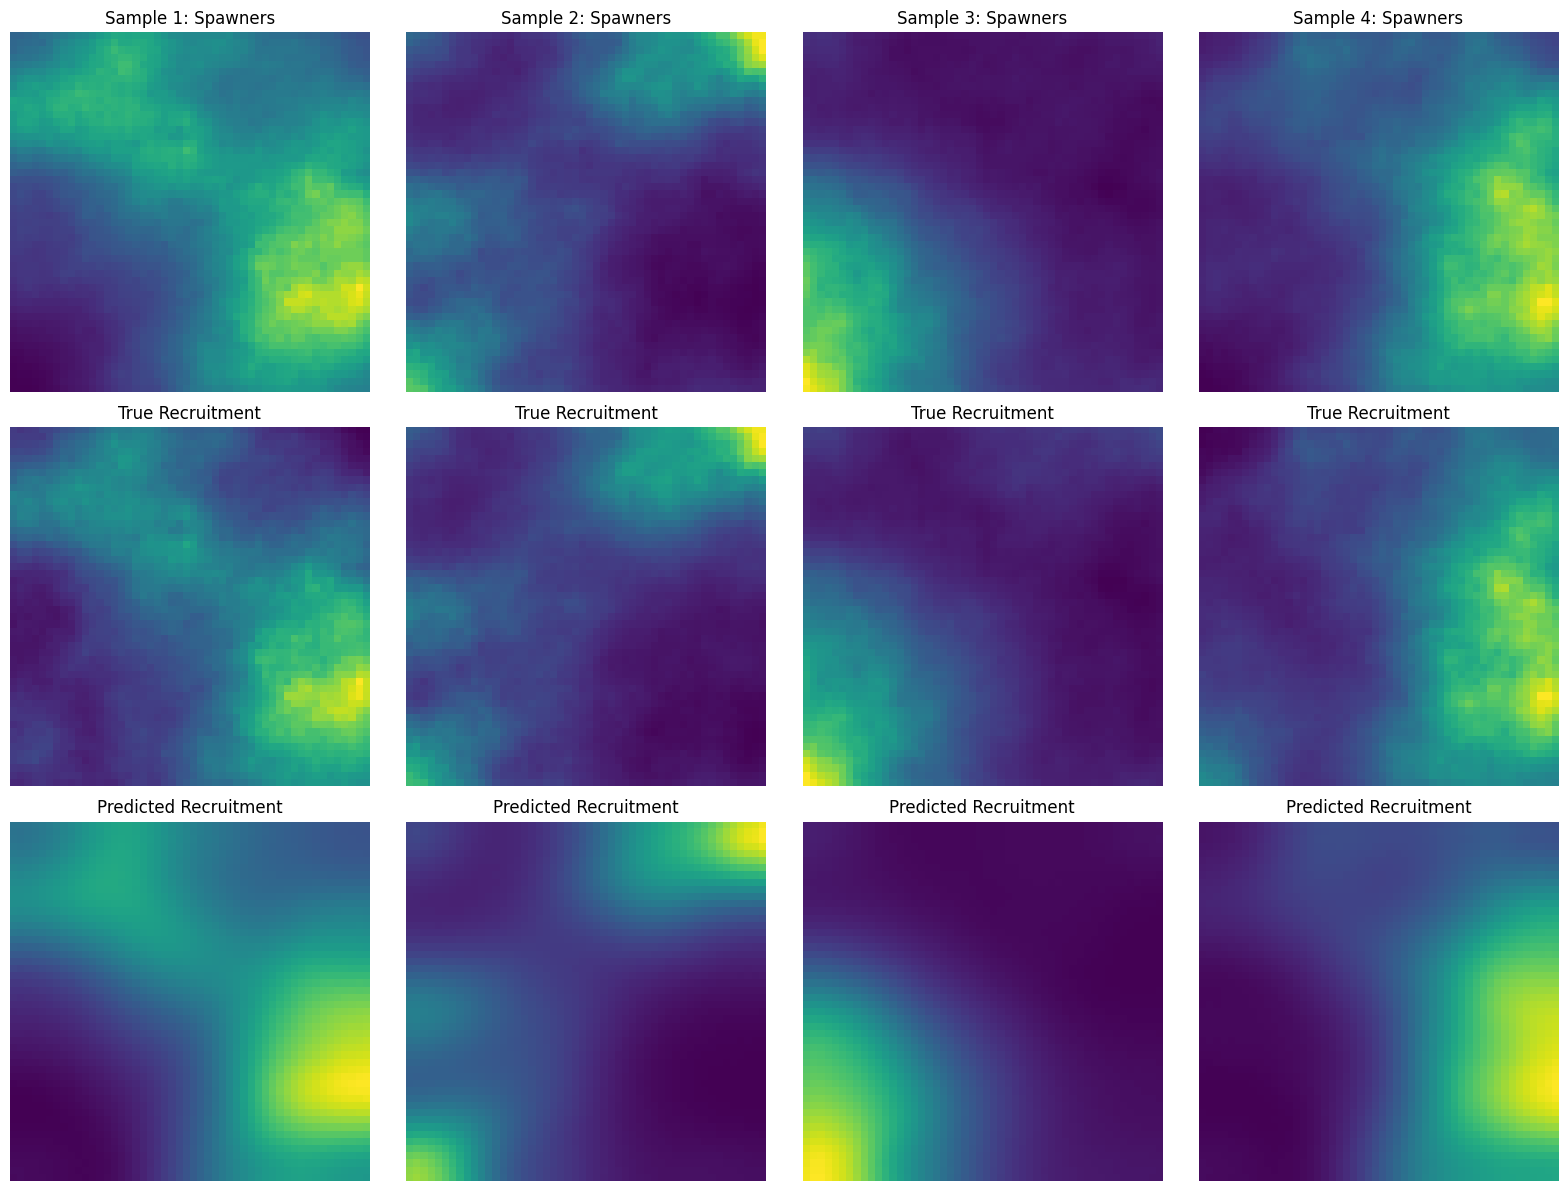

✓ Visualization saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of predictions
model.eval()
with torch.no_grad():
    # Get first batch from test set
    inputs, targets, year_indices = next(iter(test_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# Move to CPU and convert to numpy
predictions = predictions.cpu().numpy()
targets = targets.cpu().numpy()
inputs = inputs.cpu().numpy()

# Plot a few examples
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    # Row 1: Spawner input (channel 0)
    axes[0, i].imshow(inputs[i, 0], cmap='viridis')
    axes[0, i].set_title(f'Sample {i+1}: Spawners')
    axes[0, i].axis('off')

    # Row 2: True recruitment
    axes[1, i].imshow(targets[i, 0], cmap='viridis')
    axes[1, i].set_title('True Recruitment')
    axes[1, i].axis('off')

    # Row 3: Predicted recruitment
    axes[2, i].imshow(predictions[i, 0], cmap='viridis')
    axes[2, i].set_title('Predicted Recruitment')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'checkpoints/predictions_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualization saved!")

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import torch

# =============================================================================
# FUNCTION 1: Basic Visualization
# =============================================================================

def show_predictions(model, dataloader, device, n_samples=3):
    """
    Show predictions vs ground truth side-by-side.

    Usage:
        show_predictions(model, val_loader, device='cuda', n_samples=3)
    """
    model.eval()

    # Get data
    inputs, targets, year_indices = next(iter(dataloader))
    inputs = inputs[:n_samples].to(device)
    targets = targets[:n_samples].to(device)
    year_indices = year_indices[:n_samples].to(device)

    # Get predictions
    with torch.no_grad():
        preds = model(inputs, year_indices)

    # Move to numpy
    inputs = inputs.cpu().numpy()
    targets = targets.cpu().numpy()
    preds = preds.cpu().numpy()

    # Plot
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    for i in range(n_samples):
        # Input spawners
        ax = axes[i, 0] if n_samples > 1 else axes[0]
        im = ax.imshow(inputs[i, 0], cmap='viridis')
        ax.set_title('Input: Spawners')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Target
        ax = axes[i, 1] if n_samples > 1 else axes[1]
        im = ax.imshow(targets[i, 0], cmap='plasma')
        ax.set_title('Ground Truth')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Prediction
        ax = axes[i, 2] if n_samples > 1 else axes[2]
        im = ax.imshow(preds[i, 0], cmap='plasma')
        ax.set_title('Prediction')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Error
        ax = axes[i, 3] if n_samples > 1 else axes[3]
        error = preds[i, 0] - targets[i, 0]
        im = ax.imshow(error, cmap='RdBu_r',
                      vmin=-np.abs(error).max(),
                      vmax=np.abs(error).max())
        ax.set_title(f'Error (MAE={np.abs(error).mean():.2f})')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

def check_artifacts(model, dataloader, device):
    """
    Check for ring/grid artifacts in decoder output.

    Usage:
        check_artifacts(model, val_loader, device='cuda')
    """
    model.eval()

    # Get one sample
    inputs, targets, year_indices = next(iter(dataloader))
    inputs = inputs[0:1].to(device)
    targets = targets[0:1].to(device)
    year_indices = year_indices[0:1].to(device)

    with torch.no_grad():
        pred = model(inputs, year_indices)

    pred = pred[0, 0].cpu().numpy()
    target = targets[0, 0].cpu().numpy()

    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Prediction (full)
    ax = axes[0, 0]
    im = ax.imshow(pred, cmap='plasma')
    ax.set_title('Full Prediction\n(Look for rings/patterns)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 2. Ground truth (full)
    ax = axes[0, 1]
    im = ax.imshow(target, cmap='plasma')
    ax.set_title('Ground Truth\n(Should be smooth)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 3. Zoomed corner (prediction)
    ax = axes[0, 2]
    zoom = pred[:20, :20]
    im = ax.imshow(zoom, cmap='plasma', interpolation='none')
    ax.set_title('Zoomed Corner\n(Artifacts visible here)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # Add patch grid at boundaries (every 5 pixels = patch size)
    for i in range(0, 20, 5):
        ax.axhline(i-0.5, color='white', linewidth=1, alpha=0.7)
        ax.axvline(i-0.5, color='white', linewidth=1, alpha=0.7)

    # 4. Horizontal slice through middle
    ax = axes[1, 0]
    middle = pred.shape[0] // 2
    ax.plot(pred[middle, :], 'b-', linewidth=2, label='Prediction')
    ax.plot(target[middle, :], 'r--', linewidth=2, alpha=0.7, label='Ground Truth')
    ax.set_title('Horizontal Slice (Middle Row)', fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark patch boundaries
    for i in range(0, 50, 5):
        ax.axvline(i, color='gray', linestyle=':', alpha=0.3)

    # 5. Vertical slice through middle
    ax = axes[1, 1]
    middle = pred.shape[1] // 2
    ax.plot(pred[:, middle], 'b-', linewidth=2, label='Prediction')
    ax.plot(target[:, middle], 'r--', linewidth=2, alpha=0.7, label='Ground Truth')
    ax.set_title('Vertical Slice (Middle Column)', fontsize=12)
    ax.set_xlabel('Row')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark patch boundaries
    for i in range(0, 50, 5):
        ax.axvline(i, color='gray', linestyle=':', alpha=0.3)

    # 6. Gradient magnitude (shows edges)
    ax = axes[1, 2]
    grad_y = np.abs(np.diff(pred, axis=0, prepend=pred[0:1, :]))
    grad_x = np.abs(np.diff(pred, axis=1, prepend=pred[:, 0:1]))
    grad_mag = np.sqrt(grad_y**2 + grad_x**2)

    im = ax.imshow(grad_mag, cmap='hot')
    ax.set_title('Gradient Magnitude\n(Bright = sharp edges)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Gradient')

    # Overlay patch grid
    for i in range(0, 50, 5):
        ax.axhline(i, color='cyan', linestyle=':', alpha=0.3, linewidth=0.5)
        ax.axvline(i, color='cyan', linestyle=':', alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # Print diagnostics
    print("\n" + "="*60)
    print("ARTIFACT DIAGNOSTIC")
    print("="*60)

    # Check if gradients are high at patch boundaries
    boundary_grad = []
    interior_grad = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            # Is this a patch boundary?
            if (i % 5 == 0 or j % 5 == 0) and i > 0 and j > 0 and i < 49 and j < 49:
                boundary_grad.append(grad_mag[i, j])
            elif i % 5 != 0 and j % 5 != 0:
                interior_grad.append(grad_mag[i, j])

    boundary_avg = np.mean(boundary_grad)
    interior_avg = np.mean(interior_grad)

    print(f"Average gradient at patch boundaries: {boundary_avg:.4f}")
    print(f"Average gradient in interior:         {interior_avg:.4f}")
    print(f"Ratio (boundary/interior):            {boundary_avg/interior_avg:.2f}x")

    if boundary_avg > interior_avg * 1.3:
        print("\n⚠️  WARNING: Patch boundaries are visible!")
        print("   Your decoder is creating grid artifacts.")
        print("   Recommendation: Use improved decoder (see below)")
    else:
        print("\n✓ Patch boundaries look smooth!")

    print("="*60)



Training on: cuda
Spawner norm: mean=56.8944, std=36.6632
Recruit norm: mean=49.6799, std=24.0246
Spawner norm: mean=57.3120, std=39.2794
Recruit norm: mean=49.6271, std=23.0386


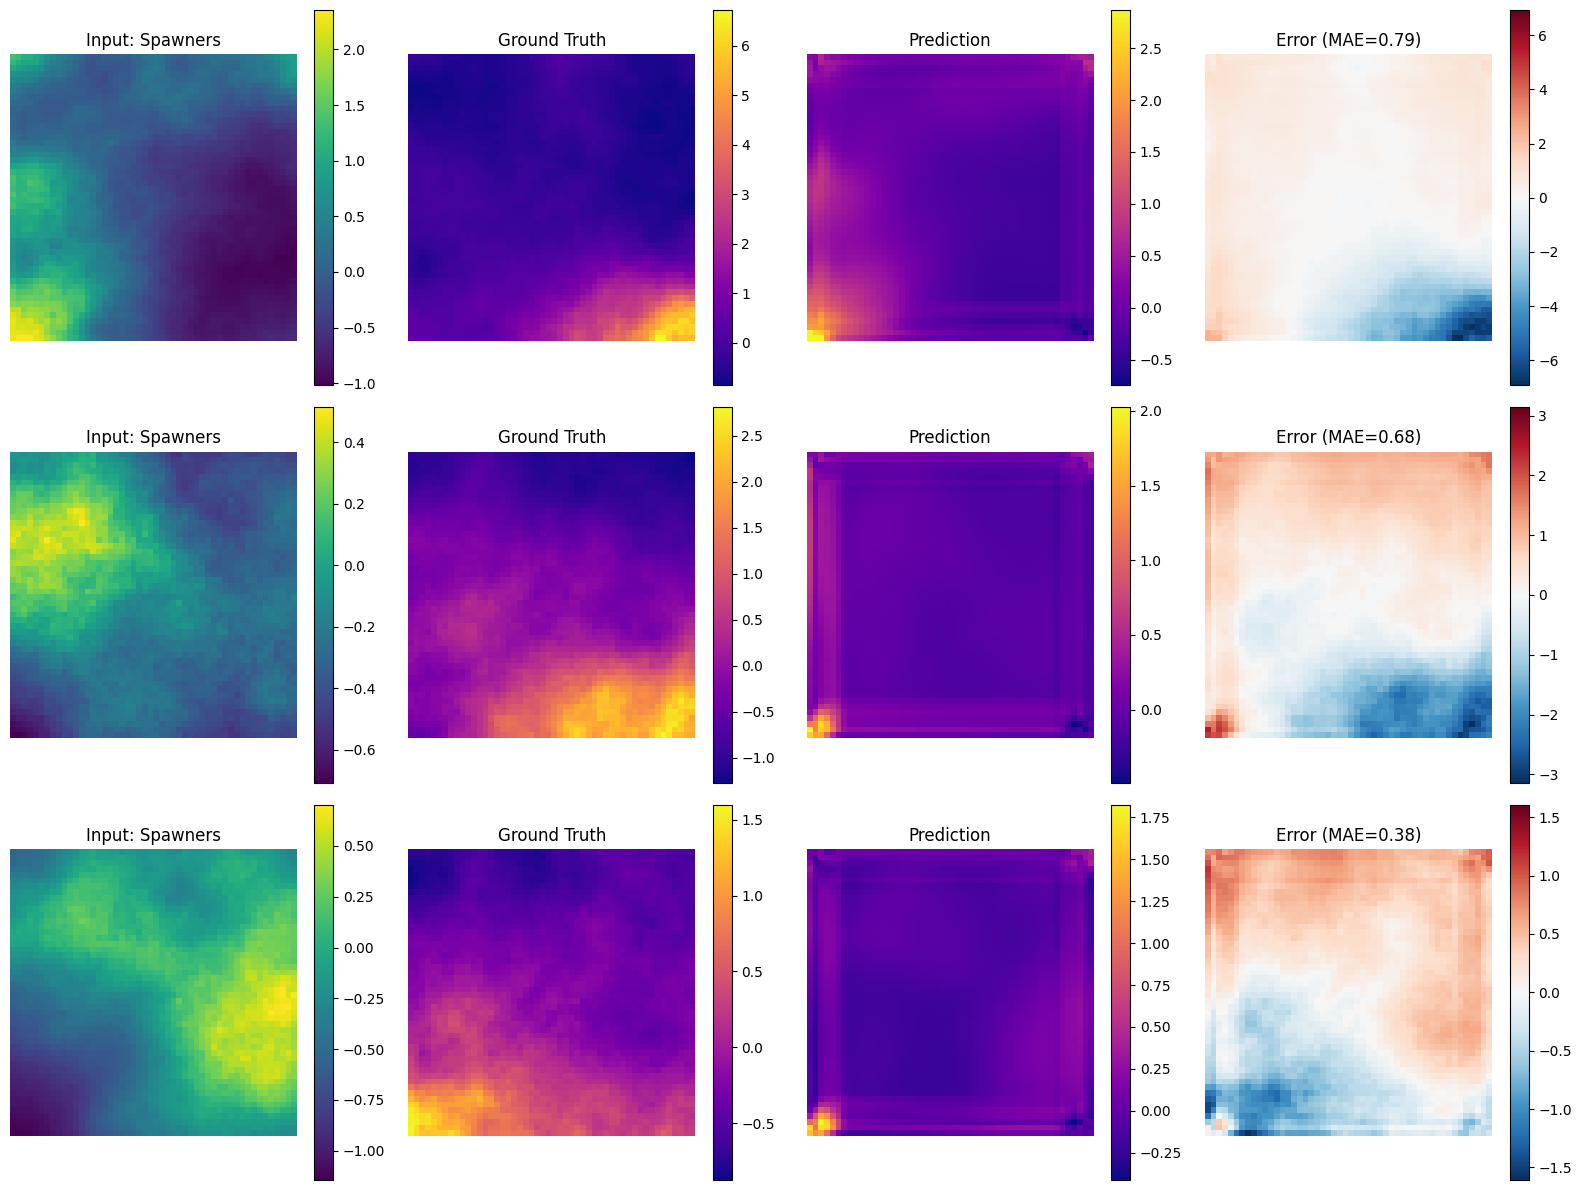

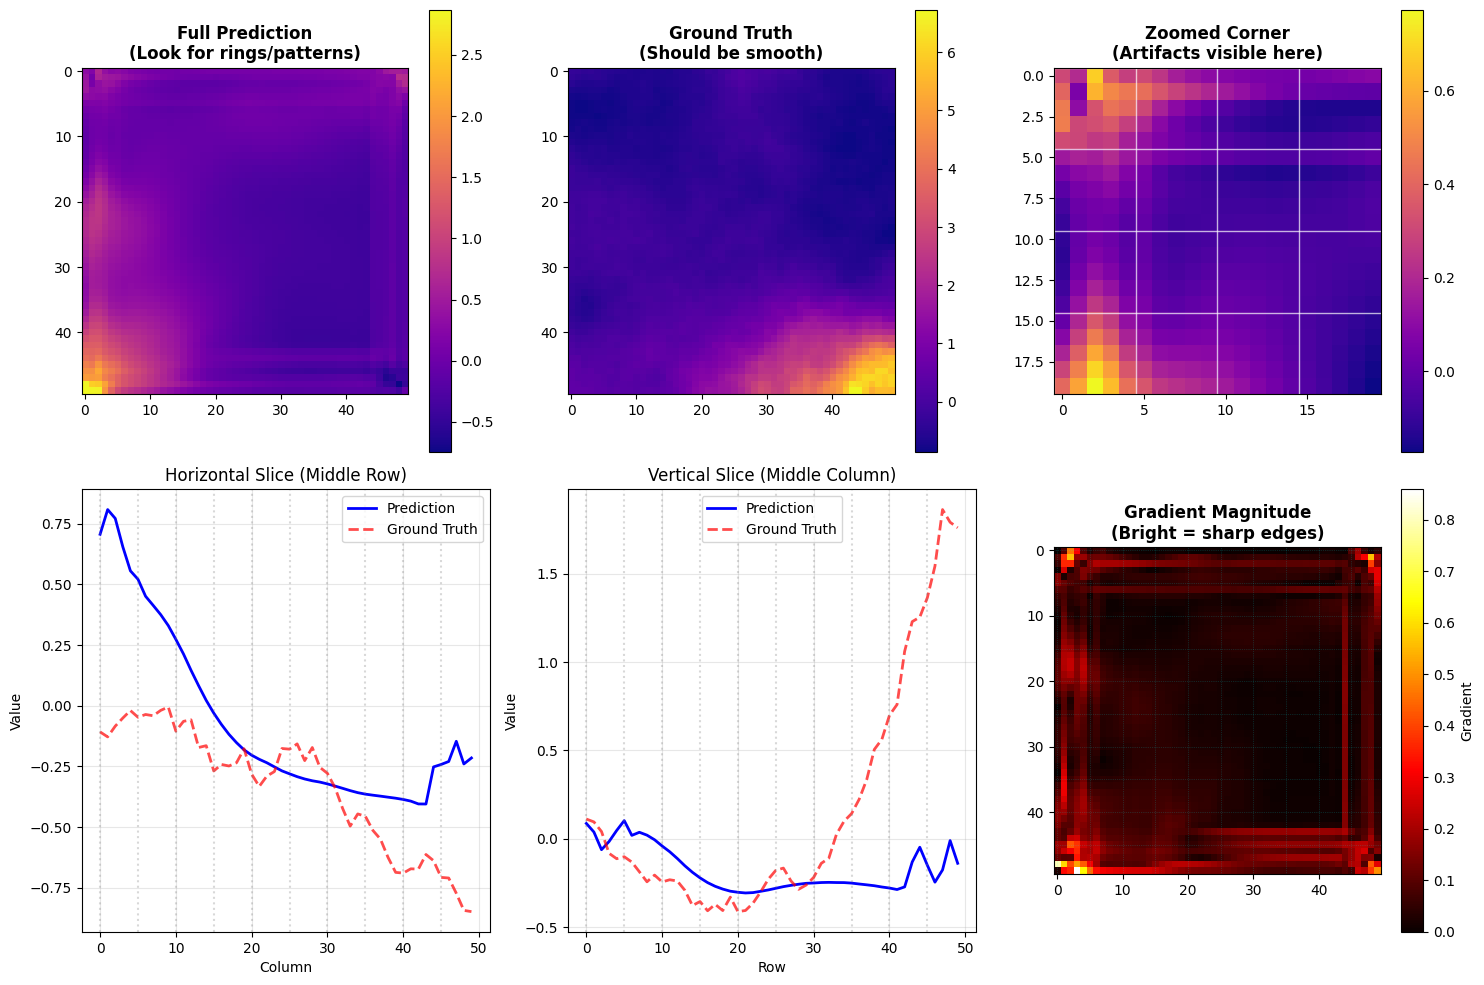


ARTIFACT DIAGNOSTIC
Average gradient at patch boundaries: 0.0527
Average gradient in interior:         0.0676
Ratio (boundary/interior):            0.78x

✓ Patch boundaries look smooth!


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
batch_size = 5
epochs = 50
learning_rate = 1e-4
grid_size = 50
patch_size = 5
in_channels = 1
embed_dim = 128
num_heads = 8
d_ff = 512
num_layers = 6
mask = None
dropout = 0.1

weight_decay = 1e-5
max_grad_norm = 1



    # prepare data
train_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "train_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=22
    )

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

val_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "val_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=5
    )

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


show_predictions(model, val_loader, 'cuda', n_samples=3)
check_artifacts(model, val_loader, 'cuda')

In [ ]:
## stop! is the data from github updated in the google drive?

def train_model():

    # set hyperparameters:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    batch_size = 5
    epochs = 50
    learning_rate = 1e-4
    grid_size = 50
    patch_size = 5
    in_channels = 1
    embed_dim = 128
    num_heads = 8
    d_ff = 512
    num_layers = 6
    mask = None
    dropout = 0.1

    weight_decay = 1e-5
    max_grad_norm = 1

    patience = 15  # Number of epochs to wait for improvement
    min_delta = 1e-4  # Minimum change to qualify as improvement

    # Create checkpoint directory in Google Drive
    CHECKPOINT_DIR = os.path.join(DATA_PATH, "checkpoints")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

    # prepare data
    train_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "train_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=22
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "val_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=5
    )

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # initialize the model, loss, and optimizer
    model = CrabTransformer(grid_size, patch_size, in_channels, embed_dim, num_heads, num_layers, d_ff, mask, dropout).to(device)
    #criterion = TweedieLoss(power=1.5)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    from torch.optim.lr_scheduler import ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=10
    )

    # Initialize best validation loss tracker
    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False
    final_epoch = 0


    # training loop

    for epoch in range(epochs):
        if early_stop:
            print("Early stopping triggered.")
            print(f"Training stopped after {epoch} epochs.")
            print(f"Best Val Loss: {best_val_loss:.4f}")
            break

        # --- TRAINING PHASE ---
        model.train() # Set model to training mode
        total_train_loss = 0
        epoch_grad_norms = []
        for batch_idx, (inputs, targets, year_indices) in enumerate(train_loader):
            # 'data' is already the [Batch, 2, 50, 50] tensor
            # 'target' is the [Batch, 1, 50, 50] recruitment density
            inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)

            # clear the gradients
            optimizer.zero_grad()
            # forward pass
            outputs = model(inputs, year_indices)  # [batch_size, 1, 50, 50]
            # calculate loss
            loss = criterion(outputs, targets)
            # backward pass (calculate gradients)
            loss.backward()

            total_norm = 0.0
            #for p in model.parameters():
            #    if p.grad is not None:
            #        param_norm = p.grad.data.norm(2)
            #        total_norm += param_norm.item() ** 2
            #total_norm = total_norm ** 0.5
            #epoch_grad_norms.append(total_norm)

            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            epoch_grad_norms.append(norm.item())

            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            # update weights
            optimizer.step()

            total_train_loss += loss.item()

        avg_train = total_train_loss / len(train_loader)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)

        # --- VALIDATION PHASE ---
        model.eval() # Set model to evaluation mode
        total_val_loss = 0

        with torch.no_grad(): # Disable gradient calculation (saves memory/time)
            for inputs, targets, year_indices in val_loader:
                inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
                outputs = model(inputs, year_indices)  # [batch_size, 1, 50, 50]
                loss = criterion(outputs, targets)
                total_val_loss += loss.item()


        avg_val = total_val_loss / len(val_loader)

        scheduler.step(avg_val)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train:.4f} | "
              f"Val Loss: {avg_val:.4f} | "
              f"Grad Norm: {avg_grad_norm:.2f}")

        # Warning if gradients are large
        if avg_grad_norm > 10.0:
            print(f"  ⚠️  Large gradient norm detected: {avg_grad_norm:.2f}")


        # --- CHECKPOINT SAVING ---
        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train,
                'val_loss': avg_val,
            }, checkpoint_path)
            print(f"✓ Checkpoint saved: {checkpoint_path}")

        # Save best model
        if avg_val < best_val_loss - min_delta:
            # Improvement detected
            best_val_loss = avg_val
            epochs_no_improve = 0

            best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train,
                'val_loss': avg_val,
            }, best_model_path)
            print(f"✓ New best model saved! Val Loss: {avg_val:.4f}")
        else:
            # No improvement
            epochs_no_improve += 1
            print(f"  ⚠️  No improvement for {epochs_no_improve} epoch(s)")
            if epochs_no_improve >= patience:
                early_stop = True

        final_epoch = epoch + 1  # Track the last completed epoch

    # --- LOAD BEST MODEL ---
    best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
    if os.path.exists(best_model_path):
        print(f"\n📦 Loading best model weights...")
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Best model loaded (epoch {checkpoint['epoch']}, val loss: {checkpoint['val_loss']:.4f})")

    # Save final model
    final_model_path = os.path.join(CHECKPOINT_DIR, "final_model.pt")
    torch.save({
        'epoch': final_epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': avg_train,
        'val_loss': avg_val,
        'best_val_loss': best_val_loss,
        'stopped_early': early_stop,
    }, final_model_path)
    print(f"✓ Final model saved: {final_model_path}")

    return model


def load_checkpoint(checkpoint_path, model, optimizer=None):
    """
    Load a saved checkpoint.

    Args:
        checkpoint_path: Path to the .pt file
        model: Model instance to load weights into
        optimizer: (Optional) Optimizer to load state into

    Returns:
        epoch: Epoch number from checkpoint
    """
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    epoch = checkpoint['epoch']
    train_loss = checkpoint['train_loss']
    val_loss = checkpoint['val_loss']

    print(f"Loaded checkpoint from epoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return epoch